# 🏪 Proyecto Aurelion - Análisis Integral de Datos Comerciales

Este notebook documenta el **proceso completo de análisis, limpieza, transformación y consolidación de datos** del proyecto *Aurelion*, trabajando con **4 tablas relacionales**: `CLIENTES`, `VENTAS`, `DETALLE_VENTAS` y `PRODUCTOS`.

El objetivo es preparar un **ecosistema de datos estructurado** que incluye:
- Base consolidada `base_final` para análisis exploratorio
- Datasets optimizados para Machine Learning (`df_ticket_ml`, `df_cliente_ml`)
- Exportación de datos limpios en formato CSV para uso posterior

## 📊 Descripción General del Proyecto

Este proyecto trabaja con **4 tablas relacionales** que contienen información comercial completa:

- **`CLIENTES`**: Información demográfica y de registro (id, nombre, email, ciudad, fecha_alta)
- **`VENTAS`**: Transacciones comerciales (id_venta, id_cliente, fecha, medios de pago)
- **`DETALLE_VENTAS`**: Líneas de venta detalladas (id_detalle, id_venta, id_producto, cantidad, precio, importe)
- **`PRODUCTOS`**: Catálogo de productos (id_producto, nombre, categoría, precio)

### 🎯 Objetivos del Análisis

1. **Carga y limpieza** individual de las 4 tablas desde archivos Excel
2. **Consolidación** mediante merge para crear `base_final` integrada
3. **Generación de datasets ML** a nivel ticket y cliente con targets binarios
4. **Exportación** de datos limpios para análisis posteriores

## ⚙️ Metodología de Trabajo

El proceso de transformación sigue una estructura ETL (Extract-Transform-Load) adaptada:

### 1. **Extracción (Extract)**
   - Carga de 4 archivos Excel desde directorio `db/`
   - Creación de dataframes base: `df_clientes_c`, `df_ventas_c`, `df_detalle_ventas_c`, `df_productos_c`

### 2. **Transformación (Transform)**
   - **Limpieza individual** por tabla:
     - Normalización de texto (mayúsculas/minúsculas, espacios)
     - Conversión de tipos de datos (fechas, categorías, numéricos)
     - Validación de nulos y duplicados
     - Generación de dataframes limpios: `df_*_True`
   
   - **Consolidación relacional**:
     - Merge secuencial: CLIENTES → VENTAS → DETALLE_VENTAS → PRODUCTOS
     - Resultado: `base_final` con todas las dimensiones integradas

### 3. **Carga (Load)**
   - Creación de datasets derivados para ML
   - Exportación a CSV de la base consolidada

## 📦 1. Importación de Librerías

Configuración del entorno de análisis con las herramientas necesarias para ETL, estadística y visualización.

In [1]:
# Importa paquetes de an?lisis (pandas/numpy) y visualizaci?n (matplotlib/seaborn) con rutas portables
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 📥 2. Importación y Carga de los 4 Dataframes Limpios

En esta sección se realiza la **importación del dataset principal** utilizando **rutas relativas** y la librería `pathlib.Path`. Esto garantiza **portabilidad** entre sistemas operativos (Windows, macOS, Linux).

### 📂 Estructura de Archivos
Todos los archivos fuente se encuentran en el directorio `db/`:
- `clientes.xlsx`
- `ventas.xlsx`
- `detalle_ventas.xlsx`
- `productos.xlsx`

La lectura se efectúa mediante `pd.read_excel()` de pandas, creando los dataframes base con sufijo `_c` (crudo).

In [2]:
# Lee el listado de clientes desde la carpeta db usando rutas relativas
path_dataset = Path('db') / 'clientes.xlsx'
df_clientes_c = pd.read_excel(path_dataset)

# Inspecciona los primeros registros para validar estructura y campos
df_clientes_c.head()

,id_cliente,nombre_cliente,email,ciudad,fecha_alta
0,1,Mariana Lopez,mariana.lopez@mail.com,Carlos Paz,2023-01-01
1,2,Nicolas Rojas,nicolas.rojas@mail.com,Carlos Paz,2023-01-02
2,3,Hernan Martinez,hernan.martinez@mail.com,Rio Cuarto,2023-01-03
3,4,Uma Martinez,uma.martinez@mail.com,Carlos Paz,2023-01-04
4,5,Agustina Flores,agustina.flores@mail.com,Cordoba,2023-01-05


### 🔍 2.1 Carga e Inspección Inicial - Tabla CLIENTES

Verificación de la estructura del dataframe `df_clientes_c` recién importado para confirmar la correcta lectura de datos.

In [3]:
# Ampl?a la vista inicial a 8 filas para detectar anomal?as tempranas
df_clientes_c.head(8)


,id_cliente,nombre_cliente,email,ciudad,fecha_alta
0,1,Mariana Lopez,mariana.lopez@mail.com,Carlos Paz,2023-01-01
1,2,Nicolas Rojas,nicolas.rojas@mail.com,Carlos Paz,2023-01-02
2,3,Hernan Martinez,hernan.martinez@mail.com,Rio Cuarto,2023-01-03
3,4,Uma Martinez,uma.martinez@mail.com,Carlos Paz,2023-01-04
4,5,Agustina Flores,agustina.flores@mail.com,Cordoba,2023-01-05
5,6,Uma Medina,uma.medina@mail.com,Villa Maria,2023-01-06
6,7,Emilia Castro,emilia.castro@mail.com,Rio Cuarto,2023-01-07
7,8,Bruno Castro,bruno.castro@mail.com,Carlos Paz,2023-01-08


In [4]:
# Revisa las ?ltimas 4 filas para confirmar consistencia al final del archivo
df_clientes_c.tail(4)

,id_cliente,nombre_cliente,email,ciudad,fecha_alta
96,97,Uma Alvarez,uma.alvarez@mail.com,Cordoba,2023-04-07
97,98,Camila Castro,camila.castro@mail.com,Cordoba,2023-04-08
98,99,Bruno Molina,bruno.molina@mail.com,Villa Maria,2023-04-09
99,100,Agustina Lopez,agustina.lopez@mail.com,Cordoba,2023-04-10


### 🧠 2.2 Análisis de Tipos de Datos y Nulos - CLIENTES

Revisión estructural para confirmar tipos correctos (fechas, numéricos, texto) y detectar valores faltantes que requieran tratamiento.

In [5]:
# Resume tipos de datos, nulos y memoria del dataframe importado
df_clientes_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_cliente      100 non-null    int64         
 1   nombre_cliente  100 non-null    object        
 2   email           100 non-null    object        
 3   ciudad          100 non-null    object        
 4   fecha_alta      100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 4.0+ KB


> 💡 **Conclusión:**
> A partir de la ejecución de la inspección del DataFrame, se observa que la base de datos cuenta con **100 registros** distribuidos en **5 columnas**. 
> Cada columna presenta **100 valores no nulos**, lo que indica que **no existen datos faltantes (NaN)** en el dataset en esta etapa.
> Los tipos de datos se encuentran con una **estructura inicial muy limpia**: `id_cliente` es un entero (`int64`), apropiado para un identificador clave. `fecha_alta` ya se encuentra correctamente definida como temporal (`datetime64[ns]`). Los campos descriptivos `nombre_cliente`, `email` y `ciudad` son texto (`object`). Esta estructura inicial es **coherente y está lista** para los procesos de **normalización** de texto (ej. estandarización de mayúsculas/minúsculas y eliminación de espacios) antes de cualquier análisis.   

### 🕵️‍♂️ Detección de Valores Nulos

Se analiza la presencia de valores faltantes para priorizar acciones de limpieza y asegurar la consistencia del dataset.

In [6]:
# Visualiza la máscara booleana donde True marca valores faltantes por celda
df_clientes_c.isnull()

,id_cliente,nombre_cliente,email,ciudad,fecha_alta
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
95,False,False,False,False,False
96,False,False,False,False,False
97,False,False,False,False,False
98,False,False,False,False,False


In [7]:
# Resume la cantidad de nulos por columna para priorizar limpieza
df_clientes_c.isnull().sum()

id_cliente        0
nombre_cliente    0
email             0
ciudad            0
fecha_alta        0
dtype: int64

## ⚙️ 3. Limpieza y Transformación de Datos

Aplicación de operaciones de normalización y estandarización a las **4 tablas** para garantizar calidad y consistencia.

### 🧩 Proceso por Tabla

### 3.1 Normalización - Tabla CLIENTES

**Objetivo**: Estandarizar campos de texto y optimizar tipos de datos.

**Transformaciones aplicadas**:
1. **Texto**: 
   - `nombre_cliente`: formato Título (capitalización)
   - `email` y `ciudad`: minúsculas para unicidad
   - Eliminación de espacios iniciales/finales con `.str.strip()`

2. **Tipos de datos**:
   - `fecha_alta`: conversión a `datetime64[ns]`
   - `ciudad`: conversión a tipo `category` (optimización de memoria)

3. **Validaciones**:
   - Control de duplicados en `id_cliente` (clave primaria)
   - Verificación de valores nulos

In [8]:
# 1. Normalización de Campos de Texto
# Aplicar limpieza de espacios y estandarización de formato.

# Normalizar 'nombre_cliente' (Formato Título para nombres propios)
df_clientes_c['nombre_cliente'] = (
    df_clientes_c['nombre_cliente']
    .str.strip()
    .str.title() 
)

# Normalizar 'email' y 'ciudad' (Minúsculas para unicidad de agrupación)
df_clientes_c['email'] = (
    df_clientes_c['email']
    .str.strip()
    .str.lower()
)
df_clientes_c['ciudad'] = (
    df_clientes_c['ciudad']
    .str.strip()
    .str.lower()
)

# 2. Optimización de Tipo Categórico
# Se convierte 'ciudad' a tipo 'category' para optimizar la memoria,
# ya que generalmente tiene un número limitado de valores únicos.
df_clientes_c['ciudad'] = df_clientes_c['ciudad'].astype('category')

#### Verificación de Transformaciones

Se valida que los cambios aplicados hayan surtido efecto tanto en los tipos de datos como en los valores muestreados.

In [9]:
# Verifica los tipos de datos de las columnas normalizadas en la tabla CLIENTES
df_clientes_c[["id_cliente", "nombre_cliente", "email", "ciudad", "fecha_alta"]].dtypes

id_cliente                 int64
nombre_cliente            object
email                     object
ciudad                  category
fecha_alta        datetime64[ns]
dtype: object

In [10]:
# Realiza muestreo de las columnas transformadas para comprobar resultados
df_clientes_c[["id_cliente", "nombre_cliente", "email", "ciudad", "fecha_alta"]].head()

,id_cliente,nombre_cliente,email,ciudad,fecha_alta
0,1,Mariana Lopez,mariana.lopez@mail.com,carlos paz,2023-01-01
1,2,Nicolas Rojas,nicolas.rojas@mail.com,carlos paz,2023-01-02
2,3,Hernan Martinez,hernan.martinez@mail.com,rio cuarto,2023-01-03
3,4,Uma Martinez,uma.martinez@mail.com,carlos paz,2023-01-04
4,5,Agustina Flores,agustina.flores@mail.com,cordoba,2023-01-05


#### Control de Calidad: Duplicados

Se evalúa la unicidad de registros, especialmente en la columna `id_cliente`, que actúa como identificador clave.

In [11]:
# Evalúa duplicados globales y por id_cliente para validar la unicidad clave de clientes
cantidad_duplicados = df_clientes_c.duplicated().sum()
duplicados_id_cliente = df_clientes_c['id_cliente'].duplicated().sum()

print()
print('--- Registros Duplicados ---')
if cantidad_duplicados > 0:
    print(f'Se encontraron {cantidad_duplicados} filas duplicadas.')    
else:
    print('No se encontraron filas duplicadas.')

print()
if duplicados_id_cliente > 0:
    print(f'Alerta: se detectaron {duplicados_id_cliente} valores repetidos en id_cliente (posible clave primaria).')
else:
    print('id_cliente es único en df_clientes_c.')


--- Registros Duplicados ---
No se encontraron filas duplicadas.

id_cliente es único en df_clientes_c.


#### Resultado - CLIENTES

Luego de la normalización, el dataframe `df_clientes_c` (que se asignará a `df_clientes_True`) presenta:

- **`fecha_alta`**: tipo `datetime64[ns]` para análisis temporal
- **`nombre_cliente`, `email`**: texto normalizado (espacios eliminados, formato consistente)
- **`ciudad`**: tipo categórico optimizado para agrupaciones
- **`id_cliente`**: verificado como clave única sin duplicados

El dataframe está estructurado con **integridad, consistencia y eficiencia** para las etapas posteriores.

#### Creación del DataFrame `df_clientes_True`

Se asigna el dataframe final de CLIENTES alineado con la nomenclatura del proyecto.

In [12]:
# Asigna el DataFrame limpio y transformado (df_clientes_c) 
# al nombre final de proyecto (df_clientes_True).
df_clientes_True = df_clientes_c

print(f"DataFrame final 'df_clientes_True' creado. Dimensiones: {df_clientes_True.shape}")
print("Columnas de df_clientes_True:")
print(df_clientes_True.columns.tolist())

DataFrame final 'df_clientes_True' creado. Dimensiones: (100, 5)
Columnas de df_clientes_True:
['id_cliente', 'nombre_cliente', 'email', 'ciudad', 'fecha_alta']


### 📊 3.2 Análisis Exploratorio (EDA) - CLIENTES

EDA conciso sobre la tabla de clientes con:
- Resumen estadístico extendido
- Distribución temporal de altas
- Concentración geográfica (ciudades)
- Análisis de dominios de email

**Objetivo**: Insights accionables para segmentación y calidad de datos.

In [13]:
# EDA: Resumen estadístico extendido y checks de calidad (versión corregida)
import pandas as pd
import numpy as np
from IPython.display import display

# Ensure helper print functions exist; define defaults if not
if 'print_section' not in globals():
    def print_section(title):
        print('\n' + '='*100)
        print(f'📊  {title}')
        print('='*100)

if 'print_subsection' not in globals():
    def print_subsection(title):
        print('\n' + '-'*80)
        print(f'🔹  {title}')
        print('-'*80)

if 'print_stat' not in globals():
    def print_stat(label, value, fmt='{:,}'):
        try:
            s = fmt.format(value)
        except Exception:
            s = str(value)
        print(f'  • {label:30s}: {s}')

if 'print_kv' not in globals():
    def print_kv(label, value, fmt=None):
        if fmt is not None:
            try:
                s = fmt.format(value)
            except Exception:
                s = str(value)
        else:
            s = str(value)
        print(f'    - {label:26s}: {s}')

if 'print_divider' not in globals():
    def print_divider():
        print('\n' + '-'*40 + '\n')

# Select dataframe
if 'df_clientes_True' in globals():
    df = df_clientes_True.copy()
elif 'df_clientes_c' in globals():
    df = df_clientes_c.copy()
else:
    raise NameError('No se encontró un dataframe de clientes en memoria (df_clientes_True o df_clientes_c)')

print_section('Resumen General - CLIENTES (Corregido)')
print_stat('Registros (n)', len(df))
print_stat('Columnas', ', '.join(df.columns.tolist()))
print_stat('Columnas con nulos', df.isnull().any().sum())
print_stat('Total valores nulos', int(df.isnull().sum().sum()))
print_stat('Registros únicos (por id_cliente)', int(df['id_cliente'].nunique()) if 'id_cliente' in df.columns else 'N/A')

# Tipos y memory
print_subsection('Tipos de datos y uso de memoria')
print(df.dtypes)
print_stat('Uso memoria (MB)', df.memory_usage(deep=True).sum() / (1024**2), fmt='{:.3f}')

# Duplicados y unicidad
print_subsection('Control de duplicados')
dup_total = int(df.duplicated().sum())
dup_id = int(df['id_cliente'].duplicated().sum()) if 'id_cliente' in df.columns else 0
print_stat('Filas duplicadas', dup_total)
print_stat('IDs duplicados', dup_id)

# Valores frecuentes
print_subsection('Valores más frecuentes por columna (Top 5)')
for col in df.select_dtypes(include=['object','category']).columns:
    try:
        top = df[col].value_counts(dropna=False).head(5)
        print(f"\n  ▶ {col} (Top 5):")
        for v, cnt in top.items():
            print_kv(str(v)[:60], cnt, fmt='{:,}')
    except Exception as e:
        print(f'  - No se pudo procesar columna {col}: {e}')

# Fecha de alta: conversión y resumen temporal
if 'fecha_alta' in df.columns:
    df['fecha_alta'] = pd.to_datetime(df['fecha_alta'], errors='coerce')
    print_subsection('Resumen temporal - fecha_alta')
    print_stat('Fecha mínima', df['fecha_alta'].min())
    print_stat('Fecha máxima', df['fecha_alta'].max())
    print_stat('Registros con fecha válida', int(df['fecha_alta'].notnull().sum()))
    tmp = df['fecha_alta'].dropna().dt.to_period('M').value_counts().sort_index()
    print_stat('Meses distintos con altas', int(len(tmp)))
    # Simple growth metric
    if len(tmp) >= 2:
        first = int(tmp.iloc[0])
        last = int(tmp.iloc[-1])
        pct_change = (last - first) / first * 100 if first != 0 else np.nan
        print_stat('Primer mes (count)', first)
        print_stat('Último mes (count)', last)
        print_stat('Crecimiento relativo (último vs primero) (%)', pct_change, fmt='{:.2f}')

print_divider()
print('Listado de columnas y nulos por columna:')
print(df.isnull().sum())
print('\nEDA - Resumen completado (corregido).')



📊  Resumen General - CLIENTES (Corregido)
  • Registros (n)                 : 100
  • Columnas                      : id_cliente, nombre_cliente, email, ciudad, fecha_alta
  • Columnas con nulos            : 0
  • Total valores nulos           : 0
  • Registros únicos (por id_cliente): 100

--------------------------------------------------------------------------------
🔹  Tipos de datos y uso de memoria
--------------------------------------------------------------------------------
id_cliente                 int64
nombre_cliente            object
email                     object
ciudad                  category
fecha_alta        datetime64[ns]
dtype: object
  • Uso memoria (MB)              : 0.015

--------------------------------------------------------------------------------
🔹  Control de duplicados
--------------------------------------------------------------------------------
  • Filas duplicadas              : 0
  • IDs duplicados                : 0

------------------------


📈 Altas de clientes por mes (serie temporal)


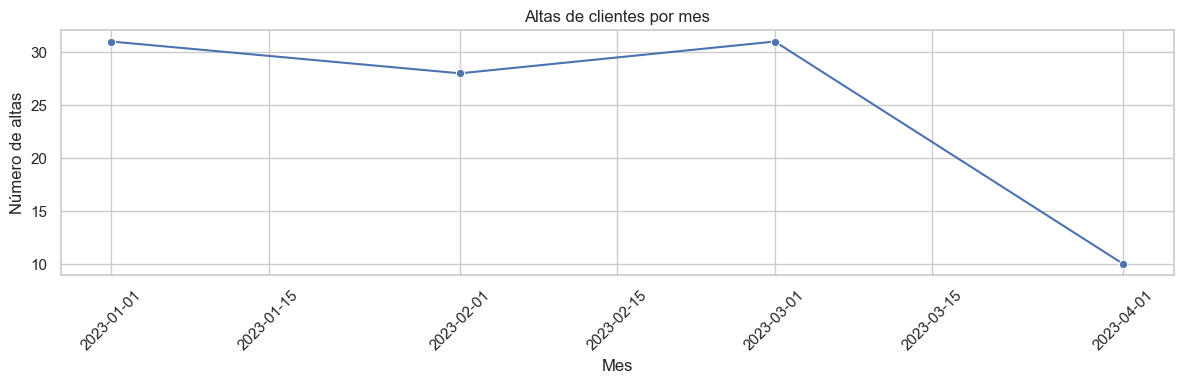

  • Total altas (periodo)         : 100
  • Meses analizados              : 4
  • Primer mes (count)            : 31
  • Último mes (count)            : 10
  • Crecimiento relativo (%)      : -67.74
  • Media mensual                 : 25.00

📈 Top 10 Ciudades por número de clientes


C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\3139513922.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette='magma', ax=ax)


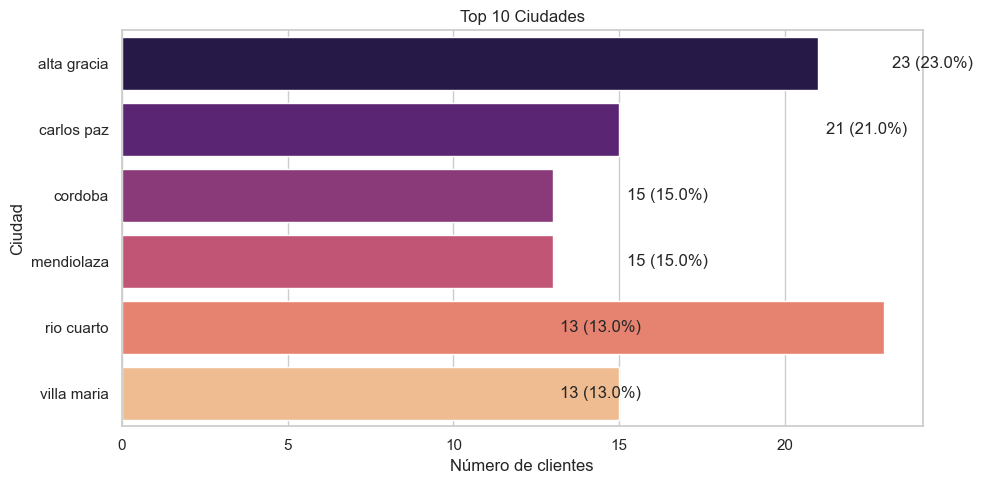

  • Total clientes                : 100
  • Clientes en Top10             : 100
  • Porcentaje en Top10 (%)       : 100.00


,conteo,count
0,rio cuarto,23
1,alta gracia,21
2,carlos paz,15
3,villa maria,15
4,cordoba,13
5,mendiolaza,13



📈 Composición por dominio de email (Top 8)


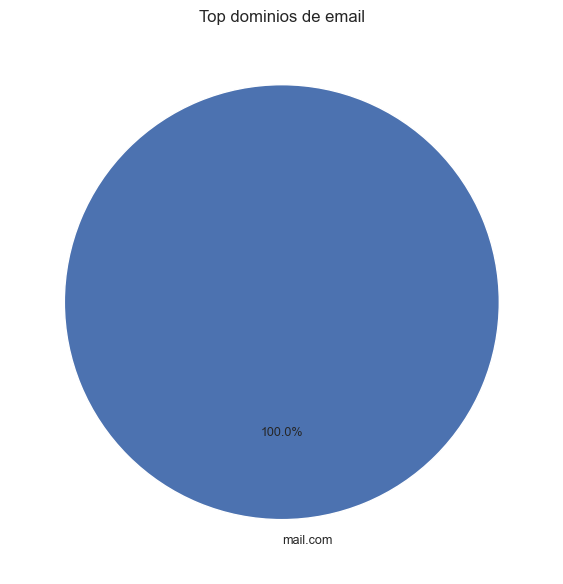

  • Dominios distintos            : 1
  • Top dominio                   : mail.com (100)


,email,count
0,mail.com,100



📈 Altas por día de la semana


C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\3139513922.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow.index, y=dow.values, palette='coolwarm', ax=ax)
C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\3139513922.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\3139513922.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


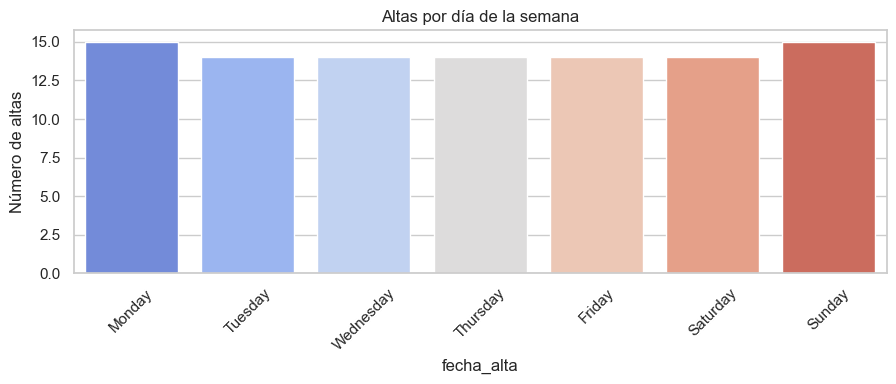

  • Día con más altas             : Monday
  • Máximo (count)                : 15

EDA: Visualizaciones estratégicas completadas.


In [14]:
# EDA: Visualizaciones estratégicas (robusta) - incluye prints extendidos (corrección de índices)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import numpy as np
import pandas as pd

sns.set(style='whitegrid')

# Prepare dataframe
if 'df' not in globals():
    if 'df_clientes_True' in globals():
        df = df_clientes_True.copy()
    else:
        df = df_clientes_c.copy()

# Ensure fecha_alta is datetime
if 'fecha_alta' in df.columns:
    df['fecha_alta'] = pd.to_datetime(df['fecha_alta'], errors='coerce')

# Helper local prints
def _print_plot_header(title, note=''):
    print('\n' + '='*80)
    print(f'📈 {title}')
    if note:
        print(f'   {note}')
    print('='*80)

# 1) Serie temporal: Altas por mes + crecimiento acumulado
_print_plot_header('Altas de clientes por mes (serie temporal)')
if 'fecha_alta' in df.columns:
    monthly = df['fecha_alta'].dropna().dt.to_period('M').value_counts().sort_index()
    # Convert PeriodIndex to Timestamp safely
    try:
        if isinstance(monthly.index, pd.PeriodIndex):
            x_index = monthly.index.to_timestamp()
        else:
            x_index = pd.to_datetime(monthly.index)
    except Exception:
        x_index = pd.to_datetime(monthly.index.astype(str))

    fig, ax = plt.subplots(figsize=(12,4))
    sns.lineplot(x=x_index, y=monthly.values, marker='o', ax=ax)
    ax.set_title('Altas de clientes por mes')
    ax.set_xlabel('Mes')
    ax.set_ylabel('Número de altas')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    # Extended stats
    total = int(monthly.sum())
    first_m, last_m = int(monthly.iloc[0]), int(monthly.iloc[-1])
    pct_change = (last_m - first_m) / first_m * 100 if first_m != 0 else np.nan
    avg_month = monthly.mean()
    print_stat('Total altas (periodo)', total)
    print_stat('Meses analizados', int(len(monthly)))
    print_stat('Primer mes (count)', first_m)
    print_stat('Último mes (count)', last_m)
    print_stat('Crecimiento relativo (%)', pct_change, fmt='{:.2f}')
    print_stat('Media mensual', avg_month, fmt='{:.2f}')
else:
    print('No hay columna fecha_alta para analizar la serie temporal.')

# 2) Top ciudades - barras horizontales con % y acumulado
_print_plot_header('Top 10 Ciudades por número de clientes')
if 'ciudad' in df.columns:
    top = df['ciudad'].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(10,5))
    sns.barplot(x=top.values, y=top.index, palette='magma', ax=ax)
    ax.set_title('Top 10 Ciudades')
    ax.set_xlabel('Número de clientes')
    ax.set_ylabel('Ciudad')
    for i, v in enumerate(top.values):
        pct = v / top.sum() * 100
        ax.text(v + max(top.values)*0.01, i, f'{v} ({pct:.1f}%)', va='center')
    plt.tight_layout()
    plt.show()

    # Print extended summary
    total_clients = len(df)
    print_stat('Total clientes', total_clients)
    print_stat('Clientes en Top10', int(top.sum()))
    print_stat('Porcentaje en Top10 (%)', top.sum()/total_clients*100 if total_clients else np.nan, fmt='{:.2f}')
    display(top.reset_index().rename(columns={'index':'ciudad', 'ciudad':'conteo'}))
else:
    print('No hay columna ciudad para visualización.')

# 3) Email domains composition (if email exists)
_print_plot_header('Composición por dominio de email (Top 8)')
if 'email' in df.columns:
    domains = df['email'].dropna().astype(str).str.extract(r'@([\w\.-]+)$', expand=False)
    domains = domains.fillna('unknown')
    dom_counts = domains.value_counts()
    topd = dom_counts.head(8)
    if topd.sum() > 0:
        fig, ax = plt.subplots(figsize=(8,6))
        ax.pie(topd.values, labels=topd.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize':9})
        ax.set_title('Top dominios de email')
        plt.tight_layout()
        plt.show()

        print_stat('Dominios distintos', int(dom_counts.size))
        print_stat('Top dominio', f"{topd.index[0]} ({topd.iloc[0]})")
        display(topd.reset_index().rename(columns={'index':'dominio', 0:'conteo'}))
    else:
        print('No hay dominios detectables en email.')
else:
    print('No hay columna email para análisis de dominios.')

# 4) Registro por día de la semana (si fecha disponible)
_print_plot_header('Altas por día de la semana')
if 'fecha_alta' in df.columns:
    dow = df['fecha_alta'].dropna().dt.day_name().value_counts()
    # Ensure English day order
    order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    # If day_name returned local language, fallback to sorted index
    try:
        dow = dow.reindex(order).fillna(0)
    except Exception:
        dow = dow.sort_index()
    fig, ax = plt.subplots(figsize=(9,4))
    sns.barplot(x=dow.index, y=dow.values, palette='coolwarm', ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_ylabel('Número de altas')
    ax.set_title('Altas por día de la semana')
    plt.tight_layout()
    plt.show()

    if dow.sum() > 0:
        print_stat('Día con más altas', dow.idxmax())
        print_stat('Máximo (count)', int(dow.max()))
    else:
        print('No hay datos de altas por día.')
else:
    print('No hay fecha_alta para calcular altas por día.')

print('\nEDA: Visualizaciones estratégicas completadas.')


### 🔍 2.3 Carga e Inspección - Tabla DETALLE_VENTAS

Importación y verificación del dataframe `df_detalle_ventas_c` que contiene las líneas de venta individuales con información de productos, cantidades y montos.

#### Descripción - DETALLE_VENTAS

La tabla `DETALLE_VENTAS` representa la **granularidad más fina** del modelo de datos comercial:

**Campos clave**:
- **Identificadores**: `id_detalle` (PK), `id_venta` (FK), `id_producto` (FK)
- **Métricas transaccionales**: `cantidad`, `precio_unitario`, `importe`
- **Campo descriptivo** (original): `nombre_producto` (se elimina en la normalización por ser redundante)

**Relaciones**:
- `id_venta` → Enlace con tabla VENTAS (muchos detalles por venta)
- `id_producto` → Enlace con tabla PRODUCTOS (muchos detalles por producto)

**Proceso de limpieza**: Se realiza conversión de tipos numéricos a `float64` y se elimina la columna `nombre_producto` para mantener la normalización relacional.

### ⚙️ 3.3 Limpieza y Transformación - DETALLE_VENTAS

**Operaciones aplicadas**:

1. **Conversión de tipos de datos**:
   - Transformación de `precio_unitario` e `importe` a tipo `float64` para precisión decimal
   - Validación de tipos numéricos para cálculos posteriores

2. **Normalización estructural**:
   - Eliminación de columna redundante `nombre_producto` (información ya presente en tabla PRODUCTOS)
   - Optimización de la estructura relacional del dataset

3. **Validación de integridad**:
   - Control de duplicados en `id_detalle` (clave primaria)
   - Verificación de valores nulos en claves foráneas (`id_venta`, `id_producto`)

#### Estadísticas Descriptivas - DETALLE_VENTAS

Métricas finales del dataframe `df_detalle_ventas_True`:

- **Distribución de cantidades**: análisis de tendencia central y dispersión mediante `describe()`
- **Análisis de precios**: exploración de rango y variabilidad
- **Análisis de importes**: resumen estadístico de montos transaccionales
- **Integridad estructural**: dataset optimizado sin columnas redundantes

#### Librerías adicionales

Carga de librerías complementarias para el análisis detallado de transacciones.

In [15]:
# Importa librerías de ETL, codificación categórica y visualización
import pandas as pd
import numpy as np
import sklearn as sk
import category_encoders as ce
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

#### Carga del archivo DETALLE_VENTAS

Lectura del archivo Excel utilizando rutas relativas con `pathlib.Path` para portabilidad entre sistemas operativos.

In [16]:
# Carga el detalle de ventas con Path para mantener rutas relativas portables
path_dataset = Path('db') / 'detalle_ventas.xlsx'
df_detalle_ventas_c = pd.read_excel(path_dataset)

### 🔍 Inspección Inicial del Dataset

En esta etapa se realiza una **inspección exploratoria básica** del DataFrame `df_detalle_ventas_c` recién cargado, con el objetivo de verificar que los datos se hayan importado correctamente y posean la estructura esperada.

Se utilizan las funciones `head()` y `tail()` para visualizar las primeras y últimas filas del dataset, permitiendo detectar posibles inconsistencias o valores atípicos tanto al inicio como al final del archivo.

In [17]:
# Amplía la inspección a 8 filas para descubrir valores atípicos iniciales
df_detalle_ventas_c.head(8)


,id_venta,id_producto,nombre_producto,cantidad,precio_unitario,importe
0,1,90,Toallas Húmedas x50,1,2902,2902
1,2,82,Aceitunas Negras 200g,5,2394,11970
2,2,39,Helado Vainilla 1L,5,469,2345
3,2,70,Fernet 750ml,2,4061,8122
4,2,22,Medialunas de Manteca,1,2069,2069
5,2,79,Hamburguesas Congeladas x4,4,2420,9680
6,3,9,Yerba Mate Suave 1kg,2,3878,7756
7,3,2,Pepsi 1.5L,2,4973,9946


In [18]:
# Revisa el cierre del dataset con las últimas 4 filas
df_detalle_ventas_c.tail(4)


,id_venta,id_producto,nombre_producto,cantidad,precio_unitario,importe
339,118,93,Cepillo de Dientes,3,2142,6426
340,118,50,Azúcar 1kg,2,727,1454
341,119,45,Fideos Spaghetti 500g,5,745,3725
342,120,20,Pan Lactal Blanco,5,1571,7855


In [19]:
# Resumen detallado de df_detalle_ventas_c basado en .describe(include="all")
import numpy as np
import pandas as pd

df = df_detalle_ventas_c

def clasificar_asimetria(skew):
    if pd.isna(skew):
        return 'No disponible'
    if abs(skew) < 0.05:
        return 'Simétrica'
    elif skew > 0:
        return 'Asimétrica positiva'
    else:
        return 'Asimétrica negativa'

def clasificar_curtosis(kurt):
    if pd.isna(kurt):
        return 'No disponible'
    if kurt < -0.5:
        return 'Platicúrtica (cola ligera)'
    elif kurt > 0.5:
        return 'Leptocúrtica (cola pesada)'
    else:
        return 'Mesocúrtica (similar a normal)'

def clasificar_moda(n_modas):
    if n_modas == 0:
        return 'Sin moda'
    elif n_modas == 1:
        return 'Unimodal'
    elif n_modas == 2:
        return 'Bimodal'
    else:
        return 'Multimodal'

print('=' * 90)
print('RESUMEN DETALLADO: df_detalle_ventas_c')
print('=' * 90)
print(f'Tamaño del dataframe: {df.shape[0]:,} filas x {df.shape[1]:,} columnas')
print(f'Memoria (approx): {df.memory_usage(deep=True).sum()/1024**2:.2f} MB')

for col in df.columns:
    s = df[col]
    n_total = len(s)
    n_no_nulos = s.notna().sum()
    n_nulos = s.isna().sum()
    pct_nulos = n_nulos / n_total * 100 if n_total > 0 else 0

    print('\n' + '=' * 90)
    print(f"Columna: {col:30s} | dtype: {str(s.dtype):15s}")
    print('-' * 90)
    print(f'  Total filas                : {n_total:,}')
    print(f'  Valores no nulos           : {n_no_nulos:,} ({n_no_nulos/n_total*100:5.2f}%)')
    print(f'  Valores nulos              : {n_nulos:,} ({pct_nulos:5.2f}%)')

    # NUMÉRICAS
    if pd.api.types.is_numeric_dtype(s):
        serie = s.dropna()
        if serie.empty:
            print('  * Columna numérica sin datos válidos.')
            continue

        desc = serie.describe()
        mini = desc.get('min')
        maxi = desc.get('max')
        rango = maxi - mini
        media = desc.get('mean')
        mediana = serie.median()
        std = desc.get('std')

        # Modas
        modas = serie.mode().tolist()
        n_modas = len(modas)
        if n_modas == 0:
            moda_valores = 'Sin moda'
        else:
            moda_valores = ', '.join(str(m) for m in modas)

        moda_cls = clasificar_moda(n_modas)

        # Asimetría y curtosis
        skew = serie.skew()
        kurt = serie.kurt()
        skew_cls = clasificar_asimetria(skew)
        kurt_cls = clasificar_curtosis(kurt)

        print('  -- Estadísticos básicos')
        print(f'     Valor mínimo            : {mini:,.4f}')
        print(f'     Valor máximo            : {maxi:,.4f}')
        print(f'     Rango                   : {rango:,.4f}')
        print(f'     Media                   : {media:,.4f}')
        print(f'     Mediana                 : {mediana:,.4f}')
        print(f'     Desvío estándar         : {std:,.4f}')
        print(f'     Moda                    : {moda_valores}')
        print(f'     Cantidad de modas       : {n_modas}')
        print(f'     Clasificación de moda   : {moda_cls}')
        print(f'     Asimetría (skewness)    : {skew:,.4f} -> {skew_cls}')
        print(f'     Curtosis                : {kurt:,.4f} -> {kurt_cls}')

    # CATEGÓRICAS / NO NUMÉRICAS
    else:
        nonnull = s.dropna()
        n_unique = nonnull.nunique()
        print('  -- Columna no numérica')
        print(f'     Valores únicos          : {n_unique:,}')

        if n_unique > 0:
            vc = nonnull.value_counts()
            modo_valor = vc.index[0]
            modo_freq = vc.iloc[0]
            modo_pct = modo_freq / len(nonnull) * 100

            # Clasificación simple de la moda para categóricas
            if n_unique == 1:
                moda_cls = 'Unimodal (una sola categoría)'
            elif n_unique <= 3:
                moda_cls = 'Pocas categorías dominantes'
            else:
                moda_cls = 'Categorías diversas'

            print(f'     Moda                    : {modo_valor}')
            print(f'     Frecuencia de la moda   : {modo_freq} ({modo_pct:.2f}%)')
            print(f'     Clasificación de la moda: {moda_cls}')

            if n_unique <= 10:
                print('     Distribución de valores:')
                for v, cnt in vc.items():
                    pct = cnt / len(nonnull) * 100
                    print(f'       {v} -> {cnt} ({pct:.2f}%)')
        else:
            print('     Sin valores no nulos para analizar.')

print('\n' + '=' * 90)
print('Tabla df_detalle_ventas_c.describe(include="all") como referencia:')
print('=' * 90)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df.describe(include="all"))


RESUMEN DETALLADO: df_detalle_ventas_c
Tamaño del dataframe: 343 filas x 6 columnas
Memoria (approx): 0.04 MB

Columna: id_venta                       | dtype: int64          
------------------------------------------------------------------------------------------
  Total filas                : 343
  Valores no nulos           : 343 (100.00%)
  Valores nulos              : 0 ( 0.00%)
  -- Estadísticos básicos
     Valor mínimo            : 1.0000
     Valor máximo            : 120.0000
     Rango                   : 119.0000
     Media                   : 61.4927
     Mediana                 : 61.0000
     Desvío estándar         : 34.8355
     Moda                    : 2, 12, 18, 28, 29, 45, 49, 50, 57, 60, 77, 78, 100, 105, 112, 114, 116, 118
     Cantidad de modas       : 18
     Clasificación de moda   : Multimodal
     Asimetría (skewness)    : -0.0064 -> Simétrica
     Curtosis                : -1.2214 -> Platicúrtica (cola ligera)

Columna: id_producto                    | dty

,id_venta,id_producto,nombre_producto,cantidad,precio_unitario,importe
count,343.000000,343.000000,343,343.000000,343.000000,343.000000
unique,NaN,NaN,95,NaN,NaN,NaN
top,NaN,NaN,Queso Rallado 150g,NaN,NaN,NaN
freq,NaN,NaN,9,NaN,NaN,NaN
mean,61.492711,49.139942,NaN,2.962099,2654.495627,7730.078717
std,34.835525,29.135461,NaN,1.366375,1308.694720,5265.543077
min,1.000000,1.000000,NaN,1.000000,272.000000,272.000000
25%,31.000000,23.000000,NaN,2.000000,1618.500000,3489.000000
50%,61.000000,47.000000,NaN,3.000000,2512.000000,6702.000000
75%,93.000000,76.000000,NaN,4.000000,3876.000000,10231.500000


> 💡 **Conclusión:**
> "Unique es igual a 95, es decir, tenemos 95 clases dentro de la categoría 'producto'. No es conveniente realizar ni Label Encoding ni One-Hot Encoding."

### 🧠 Exploración de Tipos de Datos y Valores Nulos

En esta etapa se realiza una **revisión estructural del DataFrame** para confirmar que los tipos de datos asignados a cada variable durante la lectura con `pd.read_excel()` sean correctos y coherentes con la naturaleza de la información.

Además, se evalúa la **presencia de valores nulos o faltantes**, los cuales podrían requerir tratamiento posterior durante el proceso de limpieza y estandarización.

**Herramienta**: Se utiliza el método `info()` que proporciona un resumen completo de la estructura del dataframe, incluyendo tipos de datos, cantidad de valores no nulos por columna y uso de memoria.

In [20]:
# Sintetiza estructura de columnas, tipos dtypes y nulos del dataframe crudo
df_detalle_ventas_c.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_venta         343 non-null    int64 
 1   id_producto      343 non-null    int64 
 2   nombre_producto  343 non-null    object
 3   cantidad         343 non-null    int64 
 4   precio_unitario  343 non-null    int64 
 5   importe          343 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 16.2+ KB



> 💡 **Conclusión:**  
> A partir de la ejecución del comando `df_detalle_ventas_c.info()`, se observa que la base de datos cuenta con **343 registros** distribuidos en **6 columnas**.  
> Cada columna presenta **343 valores no nulos**, lo que indica que **no existen datos faltantes (NaN)** en el dataset.
> 
> **Nota sobre tipos de datos**: Las columnas `precio_unitario` e `importe` fueron cargadas inicialmente como `int64`. En el siguiente paso se convertirán a `float64` para asegurar precisión decimal en cálculos monetarios.

### 🕵️‍♂️ Detección de Valores Nulos

Se analiza la presencia de valores faltantes para priorizar acciones de limpieza y asegurar la consistencia del dataset.

In [21]:
# Genera una máscara booleana que marca con True cada celda nula
df_detalle_ventas_c.isnull()


,id_venta,id_producto,nombre_producto,cantidad,precio_unitario,importe
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
338,False,False,False,False,False,False
339,False,False,False,False,False,False
340,False,False,False,False,False,False
341,False,False,False,False,False,False


In [22]:
# Resume la cantidad total de nulos por columna para orientar la limpieza
df_detalle_ventas_c.isnull().sum()


id_venta           0
id_producto        0
nombre_producto    0
cantidad           0
precio_unitario    0
importe            0
dtype: int64

### ⚙️ Conversión de Tipos de Datos Numéricos

Antes de realizar análisis estadísticos y consolidación, es necesario **corregir los tipos de datos** asignados a las variables monetarias.

**Transformación aplicada**: Las columnas `precio_unitario` e `importe` fueron cargadas con tipo `int64`, pero deben representarse como valores decimales (`float64`) para reflejar correctamente los montos monetarios y permitir cálculos precisos.

### 🧩 Fundamento

Corregir los tipos de datos garantiza la **precisión numérica** en cálculos y estadísticas.  
Si se mantuvieran como enteros, se perdería información decimal y se podrían producir errores al calcular promedios, totales, análisis de distribución o al aplicar operaciones aritméticas.

Este paso forma parte del proceso de **limpieza estructural** dentro de la metodología ETL (Extract, Transform, Load):

1. **Extracción:** se importan los datos desde el archivo Excel.  
2. **Transformación estructural:** se ajustan los tipos de datos para asegurar coherencia y precisión.  
3. **Normalización:** se reorganiza la base, eliminando redundancias o columnas innecesarias.

### 🧮 Procedimiento

Se aplican las transformaciones para:

**Campos monetarios:** Convertir `precio_unitario` e `importe` a tipo `float64` (decimal) para asegurar la precisión numérica y habilitar análisis estadísticos y operaciones de escalado.

In [23]:
# Convierte campos monetarios a float para habilitar estadísticas y escalado
df_detalle_ventas_c["precio_unitario"] = df_detalle_ventas_c["precio_unitario"].astype(float)
df_detalle_ventas_c["importe"] = df_detalle_ventas_c["importe"].astype(float)


#### 🕵️‍♂️ Verificación de Transformaciones

Se valida que los cambios aplicados hayan surtido efecto tanto en los tipos de datos como en los valores muestreados.

In [24]:
# Verifica que ambas columnas hayan quedado tipadas como float64
df_detalle_ventas_c[["precio_unitario", "importe"]].dtypes


precio_unitario    float64
importe            float64
dtype: object

In [25]:
# Muestra valores actualizados para confirmar la conversión numérica
df_detalle_ventas_c[["precio_unitario", "importe"]].head()


,precio_unitario,importe
0,2902.0,2902.0
1,2394.0,11970.0
2,469.0,2345.0
3,4061.0,8122.0
4,2069.0,2069.0


### 🧩 Normalización de la Base de Datos

En esta etapa se aplica la **normalización estructural** sobre el DataFrame `df_detalle_ventas_c`, creando `df_detalle_ventas_True` sin la columna `nombre_producto`.  

**Justificación**: Esta variable presenta información redundante respecto a `id_producto` (clave foránea), ya que el nombre del producto se puede obtener mediante join con la tabla PRODUCTOS. Se suprime para evitar duplicidad de datos y mantener la integridad estructural conforme a la Primera Forma Normal (1NF).

In [26]:
# Genera df_detalle_ventas_True sin la dimensión redundante 'nombre_producto'
df_detalle_ventas_True = df_detalle_ventas_c.drop(columns=['nombre_producto'])


In [27]:
# Chequemos que se haya borrado correctamente y el dataframe "df_detalle_ventas_True" no contenga la columna 'nombre_producto'
df_detalle_ventas_True.head(2)

,id_venta,id_producto,cantidad,precio_unitario,importe
0,1,90,1,2902.0,2902.0
1,2,82,5,2394.0,11970.0


## 📊 Análisis Estadístico Descriptivo

En este paso se aplica un **análisis estadístico detallado** sobre la base normalizada `df_detalle_ventas_True`, con el fin de obtener un resumen completo de las variables numéricas y categóricas.

**Métricas incluidas**:
- Estadísticos básicos: media, mediana, desviación estándar, rango
- Análisis de distribución: asimetría (skewness), curtosis
- Detección de modas: clasificación de distribuciones (unimodal, bimodal, multimodal)
- Análisis de valores únicos y cardinalidad

Este análisis proporciona una comprensión profunda de las características del dataset antes de la consolidación con otras tablas.

In [28]:
# Resumen detallado de df_detalle_ventas_True - incluye métricas numéricas y categóricas
# (pandas y numpy ya importados en celda inicial)

df = df_detalle_ventas_True

print('=' * 90)
print('RESUMEN DETALLADO: df_detalle_ventas_True')
print('=' * 90)
print(f'Tamaño del dataframe: {df.shape[0]:,} filas x {df.shape[1]:,} columnas')
print(f'Memoria (approx): {df.memory_usage(deep=True).sum()/1024**2:.2f} MB')

def clasificar_asimetria(skew):
    if pd.isna(skew):
        return 'No disponible'
    if abs(skew) < 0.05:
        return 'Simétrica'
    elif skew > 0:
        return 'Asimétrica positiva'
    else:
        return 'Asimétrica negativa'

def clasificar_curtosis(kurt):
    if pd.isna(kurt):
        return 'No disponible'
    if kurt < -0.5:
        return 'Platicúrtica (cola ligera)'
    elif kurt > 0.5:
        return 'Leptocúrtica (cola pesada)'
    else:
        return 'Mesocúrtica (similar a normal)'

def clasificar_moda(n_modas):
    if n_modas == 0:
        return 'Sin moda'
    elif n_modas == 1:
        return 'Unimodal'
    elif n_modas == 2:
        return 'Bimodal'
    else:
        return 'Multimodal'

for col in df.columns:
    s = df[col]
    n_total = len(s)
    n_no_nulos = s.notna().sum()
    n_nulos = s.isna().sum()
    pct_nulos = n_nulos / n_total * 100 if n_total > 0 else 0

    print('\n' + '=' * 90)
    print(f"Columna: {col:30s} | dtype: {str(s.dtype):15s}")
    print('-' * 90)
    print(f'  Total filas                : {n_total:,}')
    print(f'  Valores no nulos           : {n_no_nulos:,} ({n_no_nulos/n_total*100:5.2f}%)')
    print(f'  Valores nulos              : {n_nulos:,} ({pct_nulos:5.2f}%)')

    # NUMÉRICAS
    if pd.api.types.is_numeric_dtype(s):
        serie = s.dropna()
        if serie.empty:
            print('  * Columna numérica sin datos válidos.')
            continue

        desc = serie.describe()
        mini = desc.get('min')
        maxi = desc.get('max')
        rango = maxi - mini
        media = desc.get('mean')
        mediana = serie.median()
        std = desc.get('std')

        # Modas
        modas = serie.mode().tolist()
        n_modas = len(modas)
        if n_modas == 0:
            moda_valores = 'Sin moda'
        else:
            moda_valores = ', '.join(str(m) for m in modas)

        moda_cls = clasificar_moda(n_modas)

        # Asimetría y curtosis
        skew = serie.skew()
        kurt = serie.kurt()
        skew_cls = clasificar_asimetria(skew)
        kurt_cls = clasificar_curtosis(kurt)

        print('  -- Estadísticos básicos')
        print(f'     Valor mínimo            : {mini:,.4f}')
        print(f'     Valor máximo            : {maxi:,.4f}')
        print(f'     Rango                   : {rango:,.4f}')
        print(f'     Media                   : {media:,.4f}')
        print(f'     Mediana                 : {mediana:,.4f}')
        print(f'     Desvío estándar         : {std:,.4f}')
        print(f'     Moda                    : {moda_valores}')
        print(f'     Cantidad de modas       : {n_modas}')
        print(f'     Clasificación de moda   : {moda_cls}')
        print(f'     Asimetría (skewness)    : {skew:,.4f} -> {skew_cls}')
        print(f'     Curtosis                : {kurt:,.4f} -> {kurt_cls}')

    # CATEGÓRICAS / NO NUMÉRICAS
    else:
        nonnull = s.dropna()
        n_unique = nonnull.nunique()
        print('  -- Columna no numérica')
        print(f'     Valores únicos          : {n_unique:,}')

        if n_unique > 0:
            vc = nonnull.value_counts()
            modo_valor = vc.index[0]
            modo_freq = vc.iloc[0]
            modo_pct = modo_freq / len(nonnull) * 100

            # Clasificación simple de la moda para categóricas
            if n_unique == 1:
                moda_cls = 'Unimodal (una sola categoría)'
            elif n_unique <= 3:
                moda_cls = 'Pocas categorías dominantes'
            else:
                moda_cls = 'Categorías diversas'

            print(f'     Moda                    : {modo_valor}')
            print(f'     Frecuencia de la moda   : {modo_freq} ({modo_pct:.2f}%)')
            print(f'     Clasificación de la moda: {moda_cls}')

            if n_unique <= 10:
                print('     Distribución de valores:')
                for v, cnt in vc.items():
                    pct = cnt / len(nonnull) * 100
                    print(f'       {v} -> {cnt} ({pct:.2f}%)')
        else:
            print('     Sin valores no nulos para analizar.')

print('\n' + '=' * 90)
print('Tabla pandas .describe(include="all") como referencia:')
print('=' * 90)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df.describe(include="all"))


RESUMEN DETALLADO: df_detalle_ventas_True
Tamaño del dataframe: 343 filas x 5 columnas
Memoria (approx): 0.01 MB

Columna: id_venta                       | dtype: int64          
------------------------------------------------------------------------------------------
  Total filas                : 343
  Valores no nulos           : 343 (100.00%)
  Valores nulos              : 0 ( 0.00%)
  -- Estadísticos básicos
     Valor mínimo            : 1.0000
     Valor máximo            : 120.0000
     Rango                   : 119.0000
     Media                   : 61.4927
     Mediana                 : 61.0000
     Desvío estándar         : 34.8355
     Moda                    : 2, 12, 18, 28, 29, 45, 49, 50, 57, 60, 77, 78, 100, 105, 112, 114, 116, 118
     Cantidad de modas       : 18
     Clasificación de moda   : Multimodal
     Asimetría (skewness)    : -0.0064 -> Simétrica
     Curtosis                : -1.2214 -> Platicúrtica (cola ligera)

Columna: id_producto                    | 

,id_venta,id_producto,cantidad,precio_unitario,importe
count,343.000000,343.000000,343.000000,343.000000,343.000000
mean,61.492711,49.139942,2.962099,2654.495627,7730.078717
std,34.835525,29.135461,1.366375,1308.694720,5265.543077
min,1.000000,1.000000,1.000000,272.000000,272.000000
25%,31.000000,23.000000,2.000000,1618.500000,3489.000000
50%,61.000000,47.000000,3.000000,2512.000000,6702.000000
75%,93.000000,76.000000,4.000000,3876.000000,10231.500000
max,120.000000,100.000000,5.000000,4982.000000,24865.000000


> 💡 **Conclusión:**  
> El DataFrame `df_detalle_ventas_True` no requiere corrección de valores faltantes.  
> Se puede avanzar directamente hacia la siguiente fase del análisis exploratorio: **detección de outliers y visualización de distribuciones.**

## 🖼️ Análisis Exploratorio y Visualización (EDA)

### 📊 3.2 Análisis Exploratorio (EDA) - CLIENTES

Análisis exploratorio detallado sobre la tabla de clientes con:
- Resumen estadístico extendido con métricas descriptivas
- Distribución temporal de altas de clientes
- Concentración geográfica por ciudades
- Análisis de dominios de email

**Objetivo**: Obtener insights accionables para segmentación de clientes, análisis de calidad de datos y detección de patrones temporales y geográficos.

#### 📊 Histograma de **`importe`**
**Tipo de gráfico:** Histograma (escala log)  
**Cómo:** Se construye un histograma en escala logarítmica para visualizar la distribución de los importes y sombrear el rango intercuartílico.  
**Por qué:** Detectar sesgo y outliers monetarios antes de cualquier transformación o escalado.

Lo que está evaluando: Histograma de la columna "importe" (original)
Tipo de gráfico: Histograma en escala log con percentiles y estadísticas superpuestas

RESUMEN ESTADÍSTICO EXTENDIDO - IMPORTE
  Count (n observaciones)         : 343
  Valor mínimo                    : 272.00
  Valor máximo                    : 24,865.00
  Rango                           : 24,593.00
  Media                           : 7,730.08
  Mediana                         : 6,702.00
  Desvío estándar                 : 5,265.54
  Varianza                        : 27,725,943.89
  MAD (desvío absoluto mediano)   : 3,346.00
  Coeficiente de variación (CV)   : 0.6812
  Error estándar de la media (SEM): 284.3126
  IC 95% para la media            : [7,170.86, 8,289.30]

  -- Moda
     Moda(s)                      : 4,435.00, 4,752.00
     Cantidad de modas            : 2
     Clasificación de la moda     : Bimodal

  -- Medidas de forma
     Asimetría (skewness)         : 0.8745
     Clasificación de asimetría   : Asim

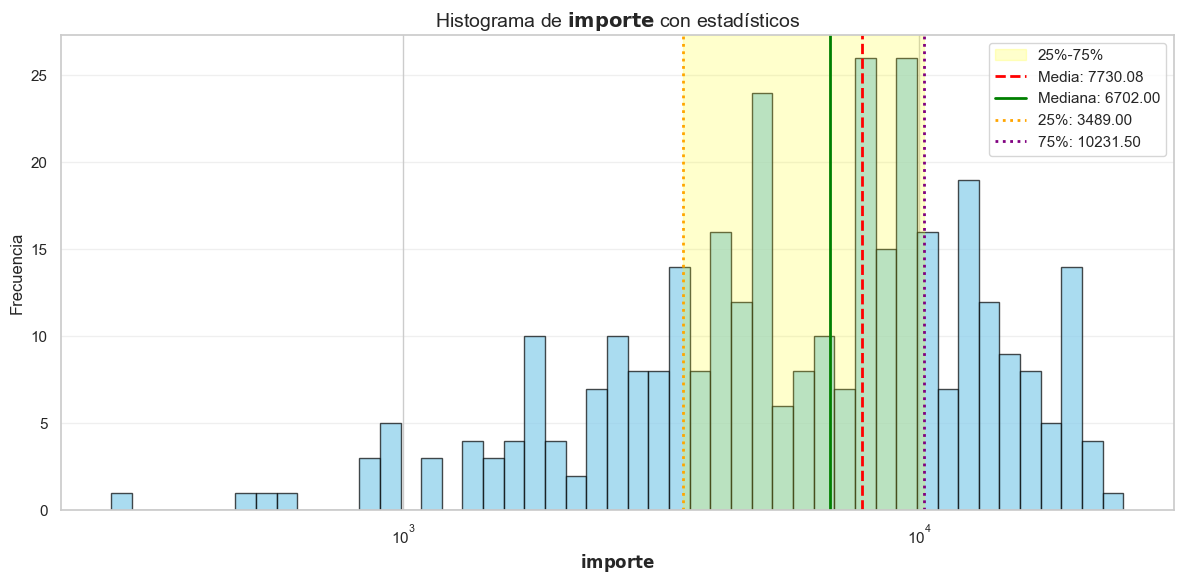

In [29]:
# Histograma de la columna "importe" con resumen estadístico extendido
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Lo que está evaluando
print('Lo que está evaluando: Histograma de la columna "importe" (original)')
print('Tipo de gráfico: Histograma en escala log con percentiles y estadísticas superpuestas')

# Datos
data_imp = df_detalle_ventas_True['importe'].dropna()

# Estadísticos básicos
media = data_imp.mean()
mediana = data_imp.median()
min_imp = data_imp.min()
max_imp = data_imp.max()
rango_imp = max_imp - min_imp
std_imp = data_imp.std()
var_imp = data_imp.var()
mad_imp = np.median(np.abs(data_imp - np.median(data_imp)))
n_imp = len(data_imp)
cv_imp = std_imp / media if media != 0 else np.nan
sem_imp = std_imp / np.sqrt(n_imp) if n_imp > 0 else np.nan
t_crit_imp = stats.t.ppf(0.975, df=n_imp-1) if n_imp > 1 else np.nan
ci_low_imp = media - t_crit_imp * sem_imp if n_imp > 1 else np.nan
ci_high_imp = media + t_crit_imp * sem_imp if n_imp > 1 else np.nan

# Percentiles
p25 = np.percentile(data_imp, 25)
p75 = np.percentile(data_imp, 75)

# Moda(s)
modas_imp = data_imp.mode().tolist()
n_modas_imp = len(modas_imp)

if n_modas_imp == 0:
    moda_imp_txt = 'Sin moda'
    clas_moda_imp = 'Sin moda definida'
else:
    moda_imp_txt = ', '.join(f'{m:,.2f}' for m in modas_imp)
    if n_modas_imp == 1:
        clas_moda_imp = 'Unimodal'
    elif n_modas_imp == 2:
        clas_moda_imp = 'Bimodal'
    else:
        clas_moda_imp = 'Multimodal'

# Asimetría y curtosis
skew_imp = data_imp.skew()
kurt_imp = data_imp.kurt()

# Clasificación de asimetría
if np.isnan(skew_imp):
    clas_asim_imp = 'No disponible'
elif abs(skew_imp) < 0.05:
    clas_asim_imp = 'Simétrica'
elif skew_imp > 0:
    clas_asim_imp = 'Asimétrica positiva'
else:
    clas_asim_imp = 'Asimétrica negativa'

# Clasificación de curtosis
if np.isnan(kurt_imp):
    clas_curt_imp = 'No disponible'
elif kurt_imp < -0.5:
    clas_curt_imp = 'Platicúrtica (cola ligera)'
elif kurt_imp > 0.5:
    clas_curt_imp = 'Leptocúrtica (cola pesada)'
else:
    clas_curt_imp = 'Mesocúrtica (similar a normal)'

# BLOQUE DE PRINT EXTENDIDO (ordenado y legible)
print('\n' + '=' * 100)
print('RESUMEN ESTADÍSTICO EXTENDIDO - IMPORTE')
print('=' * 100)

print(f'  Count (n observaciones)         : {n_imp:,}')
print(f'  Valor mínimo                    : {min_imp:,.2f}')
print(f'  Valor máximo                    : {max_imp:,.2f}')
print(f'  Rango                           : {rango_imp:,.2f}')
print(f'  Media                           : {media:,.2f}')
print(f'  Mediana                         : {mediana:,.2f}')
print(f'  Desvío estándar                 : {std_imp:,.2f}')
print(f'  Varianza                        : {var_imp:,.2f}')
print(f'  MAD (desvío absoluto mediano)   : {mad_imp:,.2f}')
print(f'  Coeficiente de variación (CV)   : {cv_imp:.4f}')
print(f'  Error estándar de la media (SEM): {sem_imp:.4f}')
print(f'  IC 95% para la media            : [{ci_low_imp:,.2f}, {ci_high_imp:,.2f}]')

print('\n  -- Moda')
print(f'     Moda(s)                      : {moda_imp_txt}')
print(f'     Cantidad de modas            : {n_modas_imp}')
print(f'     Clasificación de la moda     : {clas_moda_imp}')

print('\n  -- Medidas de forma')
print(f'     Asimetría (skewness)         : {skew_imp:,.4f}')
print(f'     Clasificación de asimetría   : {clas_asim_imp}')
print(f'     Curtosis                     : {kurt_imp:,.4f}')
print(f'     Clasificación de curtosis    : {clas_curt_imp}')

print('\n  -- Percentiles seleccionados')
for pp in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f'     {pp:>3d}%: {np.percentile(data_imp, pp):,.2f}')

print('\n' + '-' * 100)
print('Nota: Clasificación de asimetría y curtosis según umbrales simples.')
print('-' * 100 + '\n')

# Bins logarítmicos seguros (evita valores <=0)
min_pos = data_imp[data_imp > 0].min()
max_pos = data_imp.max()
if min_pos <= 0:
    min_pos = 1
bins_log = np.logspace(np.log10(min_pos), np.log10(max_pos), 50)

# Crear histograma
plt.figure(figsize=(12,6))
plt.hist(data_imp, bins=bins_log, color='skyblue', edgecolor='black', alpha=0.7)

# Escala logarítmica en X
plt.xscale('log')

# Sombreado entre percentiles 25 y 75
plt.axvspan(p25, p75, color='yellow', alpha=0.2, label='25%-75%')

# Líneas estadísticas
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(p25, color='orange', linestyle=':', linewidth=2, label=f'25%: {p25:.2f}')
plt.axvline(p75, color='purple', linestyle=':', linewidth=2, label=f'75%: {p75:.2f}')

# Etiquetas y título
plt.title(r'Histograma de $\mathbf{importe}$ con estadísticos', fontsize=14)
plt.xlabel(r'$\mathbf{importe}$', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



#### df_detalle_ventas_True no cambio aún, solo se **crea** la variable `importe_std`.

In [30]:
# Aplica StandardScaler con validación: verifica media ≈ 0 y std ≈ 1 tras transformación
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

print('\n--- Normalización: StandardScaler sobre importe ---')
print(f'Valores originales - Media: {df_detalle_ventas_True["importe"].mean():,.2f}, Std: {df_detalle_ventas_True["importe"].std():,.2f}')

scaler_standard = StandardScaler()
importe_std = scaler_standard.fit_transform(df_detalle_ventas_True[['importe']]).ravel()

# Validación post-estandarización
mean_after = importe_std.mean()
std_after = importe_std.std()
print(f'Valores normalizados - Media: {mean_after:.6f}, Std: {std_after:.6f}')
assert abs(mean_after) < 1e-10, f'Media debe ser ≈0, obtuvo {mean_after}'
assert abs(std_after - 1.0) < 1e-10, f'Std debe ser ≈1, obtuvo {std_after}'
print('✓ Validación OK: StandardScaler aplicado correctamente')



--- Normalización: StandardScaler sobre importe ---
Valores originales - Media: 7,730.08, Std: 5,265.54
Valores normalizados - Media: 0.000000, Std: 1.000000
✓ Validación OK: StandardScaler aplicado correctamente


#### **Incorporo** la columna **normalizada** 'importe_std' al dataset preparado

In [31]:
# Incorpora la columna normalizada 'importe_std' al dataset preparado
df_detalle_ventas_True['importe_std'] = importe_std

print('Columna "importe_std" incorporada a df_detalle_ventas_True.')
print(f'Dimensiones actuales del dataframe: {df_detalle_ventas_True.shape[0]:,} filas x {df_detalle_ventas_True.shape[1]:,} columnas')


Columna "importe_std" incorporada a df_detalle_ventas_True.
Dimensiones actuales del dataframe: 343 filas x 6 columnas


#### Verificación de `importe_std` en el dataframe

In [32]:
# Confirma la incorporación de 'importe_std' y revisa su escala centrada

print('\n--- Verificación post-normalización (primeras 5 filas) ---')
print(df_detalle_ventas_True[['importe', 'importe_std']].head(5))

print('\n--- Estadísticos rápidos de importe_std ---')
print(f'  Mínimo       : {df_detalle_ventas_True["importe_std"].min():.4f}')
print(f'  Máximo       : {df_detalle_ventas_True["importe_std"].max():.4f}')
print(f'  Media        : {df_detalle_ventas_True["importe_std"].mean():.4f}')
print(f'  Desvío std   : {df_detalle_ventas_True["importe_std"].std():.4f}')



--- Verificación post-normalización (primeras 5 filas) ---
   importe  importe_std
0   2902.0    -0.918259
1  11970.0     0.806396
2   2345.0    -1.024196
3   8122.0     0.074540
4   2069.0    -1.076688

--- Estadísticos rápidos de importe_std ---
  Mínimo       : -1.4185
  Máximo       : 3.2589
  Media        : 0.0000
  Desvío std   : 1.0015


#### 📊 Histograma de **`importe_std`**
**Tipo de gráfico:** Histograma (rango fijo)  
**Cómo:** Visualizar la distribución del importe estandarizado (`importe_std`) y marcar percentiles para evaluar simetría.  
**Por qué:** Confirmar que la estandarización no altera la forma de la distribución y mostrar la dispersión en unidades de desviación estándar.

Lo que está evaluando: Histograma de la columna "importe_std" (Puntaje Z)
Tipo de gráfico: Histograma con rango centrado y percentiles

RESUMEN ESTADÍSTICO EXTENDIDO - IMPORTE_STD (PUNTAJE Z)
  Count (n observaciones)         : 343
  Valor mínimo                    : -1.418462
  Valor máximo                    : 3.258914
  Rango                           : 4.677377
  Media                           : 0.000000
  Mediana                         : -0.195532
  Desvío estándar                 : 1.001461
  Varianza                        : 1.002924
  MAD (desvío absoluto mediano)   : 0.636380
  Coeficiente de variación (CV)   : 38674785193884416.000000
  Error estándar de la media (SEM): 0.054074
  IC 95% para la media            : [-0.106359, 0.106359]

  -- Moda
     Moda(s)                      : -0.6267, -0.5664
     Cantidad de modas            : 2
     Clasificación de la moda     : Bimodal

  -- Medidas de forma
     Asimetría (skewness)         : 0.8745
     Clasificación de asimetrí

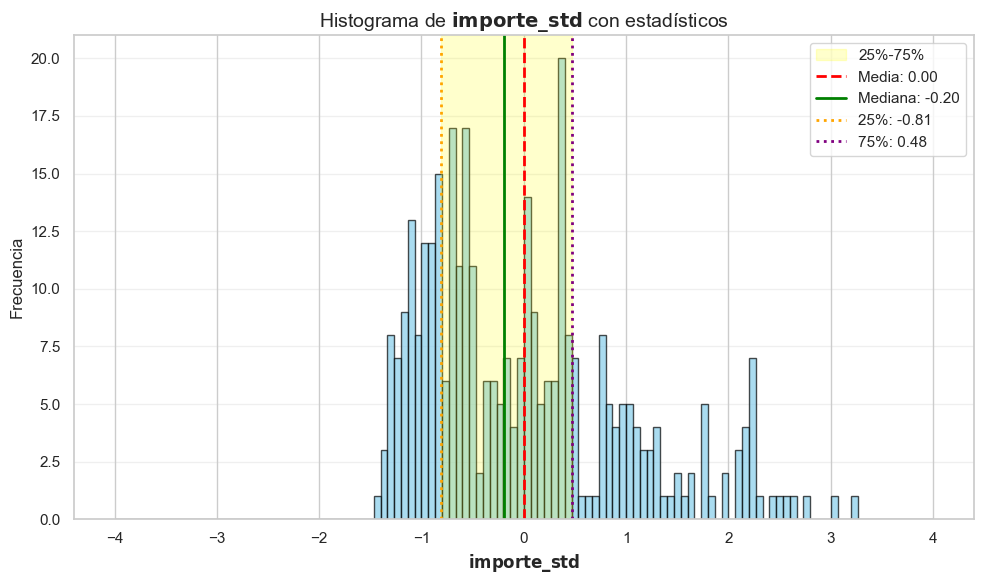

In [33]:
# Histograma de la columna "importe_std" (Puntaje Z) con resumen estadístico extendido
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Lo que está evaluando
print('Lo que está evaluando: Histograma de la columna "importe_std" (Puntaje Z)')
print('Tipo de gráfico: Histograma con rango centrado y percentiles')

# Serie estandarizada a graficar (obtiene la serie de forma segura)
if 'importe_std' in df_detalle_ventas_True.columns:
    data_std = df_detalle_ventas_True['importe_std'].dropna()
else:
    try:
        # intenta usar la variable local `importe_std` si existe
        data_std = pd.Series(importe_std).dropna()
    except Exception:
        # si no existe, recalcula usando el scaler (si está disponible)
        try:
            data_std = pd.Series(scaler_standard.transform(df_detalle_ventas_True[['importe']]).ravel()).dropna()
        except Exception:
            raise RuntimeError('No se encontró `importe_std` ni `scaler_standard` para recomputar. Ejecutar la celda de estandarización primero.')

# ===========================
# ESTADÍSTICOS AMPLIADOS
# ===========================
media = data_std.mean()
mediana = data_std.median()
min_std = data_std.min()
max_std = data_std.max()
rango_std = max_std - min_std
n_std = len(data_std)

std_std = data_std.std()
var_std = data_std.var()
mad_std = np.median(np.abs(data_std - np.median(data_std)))
cv_std = std_std / media if media != 0 else np.nan
sem_std = std_std / np.sqrt(n_std) if n_std > 0 else np.nan
t_crit_std = stats.t.ppf(0.975, df=n_std-1) if n_std > 1 else np.nan
ci_low_std = media - t_crit_std * sem_std if n_std > 1 else np.nan
ci_high_std = media + t_crit_std * sem_std if n_std > 1 else np.nan

# Percentiles
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
p_dict = {pp: np.percentile(data_std, pp) for pp in percentiles}
p25 = p_dict[25]
p75 = p_dict[75]

# Moda(s)
modas_std = data_std.mode().tolist()
n_modas_std = len(modas_std)

if n_modas_std == 0:
    moda_std_txt = 'Sin moda'
    clas_moda_std = 'Sin moda definida'
else:
    moda_std_txt = ', '.join(f'{m:.4f}' for m in modas_std)
    if n_modas_std == 1:
        clas_moda_std = 'Unimodal'
    elif n_modas_std == 2:
        clas_moda_std = 'Bimodal'
    else:
        clas_moda_std = 'Multimodal'

# Asimetría y curtosis
skew_std = data_std.skew()
kurt_std = data_std.kurt()

# Clasificación de asimetría
if np.isnan(skew_std):
    clas_asim_std = 'No disponible'
elif abs(skew_std) < 0.05:
    clas_asim_std = 'Simétrica'
elif skew_std > 0:
    clas_asim_std = 'Asimétrica positiva'
else:
    clas_asim_std = 'Asimétrica negativa'

# Clasificación de curtosis
if np.isnan(kurt_std):
    clas_curt_std = 'No disponible'
elif kurt_std < -0.5:
    clas_curt_std = 'Platicúrtica (cola ligera)'
elif kurt_std > 0.5:
    clas_curt_std = 'Leptocúrtica (cola pesada)'
else:
    clas_curt_std = 'Mesocúrtica (similar a normal)'

# BLOQUE DE PRINT EXTENDIDO (ordenado y legible)
print('\n' + '=' * 100)
print('RESUMEN ESTADÍSTICO EXTENDIDO - IMPORTE_STD (PUNTAJE Z)')
print('=' * 100)

print(f'  Count (n observaciones)         : {n_std:,}')
print(f'  Valor mínimo                    : {min_std:.6f}')
print(f'  Valor máximo                    : {max_std:.6f}')
print(f'  Rango                           : {rango_std:.6f}')
print(f'  Media                           : {media:.6f}')
print(f'  Mediana                         : {mediana:.6f}')
print(f'  Desvío estándar                 : {std_std:.6f}')
print(f'  Varianza                        : {var_std:.6f}')
print(f'  MAD (desvío absoluto mediano)   : {mad_std:.6f}')
print(f'  Coeficiente de variación (CV)   : {cv_std:.6f}')
print(f'  Error estándar de la media (SEM): {sem_std:.6f}')
print(f'  IC 95% para la media            : [{ci_low_std:.6f}, {ci_high_std:.6f}]')

print('\n  -- Moda')
print(f'     Moda(s)                      : {moda_std_txt}')
print(f'     Cantidad de modas            : {n_modas_std}')
print(f'     Clasificación de la moda     : {clas_moda_std}')

print('\n  -- Medidas de forma')
print(f'     Asimetría (skewness)         : {skew_std:,.4f}')
print(f'     Clasificación de asimetría   : {clas_asim_std}')
print(f'     Curtosis                     : {kurt_std:,.4f}')
print(f'     Clasificación de curtosis    : {clas_curt_std}')

print('\n  -- Percentiles seleccionados')
for pp in percentiles:
    print(f'     {pp:>3d}%: {p_dict[pp]:.6f}')

print('\n' + '-' * 100)
print('Nota: "importe_std" es un puntaje Z; idealmente Media≈0 y Std≈1 en una estandarización perfecta.')
print('-' * 100 + '\n')

# ===========================
# HISTOGRAMA
# ===========================
# Calcula estadísticos relevantes para resaltar en el gráfico
# (reutilizando media, mediana, p25, p75 ya calculados)
plt.figure(figsize=(10,6))
plt.hist(data_std, bins=120, range=(-4,4), color='skyblue', edgecolor='black', alpha=0.7)

# Destaca la banda intercuartílica sobre el histograma
plt.axvspan(p25, p75, color='yellow', alpha=0.2, label='25%-75%')

# Añade marcadores estadísticos clave
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(p25, color='orange', linestyle=':', linewidth=2, label=f'25%: {p25:.2f}')
plt.axvline(p75, color='purple', linestyle=':', linewidth=2, label=f'75%: {p75:.2f}')

# Configura títulos, etiquetas y cuadrícula
plt.title(r'Histograma de $\mathbf{importe\_std}$ con estadísticos', fontsize=14)
plt.xlabel(r'$\mathbf{importe\_std}$', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



In [34]:
# Verifica las primeras filas antes de anexar la columna escalada al dataframe
df_detalle_ventas_True.head(3)  # La columna 'importe_std' aún no forma parte del DataFrame


,id_venta,id_producto,cantidad,precio_unitario,importe,importe_std
0,1,90,1,2902.0,2902.0,-0.918259
1,2,82,5,2394.0,11970.0,0.806396
2,2,39,5,469.0,2345.0,-1.024196


In [35]:
# Confirma la incorporación de 'importe_std' y revisa su escala centrada
df_detalle_ventas_True['importe_std'] = importe_std
print('\n--- Verificación post-normalización (primeras 5 filas) ---')
print(df_detalle_ventas_True[['importe', 'importe_std']].head(5))
print(f'\nRango de importe_std: [{importe_std.min():.4f}, {importe_std.max():.4f}]')



--- Verificación post-normalización (primeras 5 filas) ---
   importe  importe_std
0   2902.0    -0.918259
1  11970.0     0.806396
2   2345.0    -1.024196
3   8122.0     0.074540
4   2069.0    -1.076688

Rango de importe_std: [-1.4185, 3.2589]


### 🔍 Detección Precisa de Outliers (Método IQR)

In [36]:
import pandas as pd
import numpy as np

print('\n' + '='*90)
print('ANÁLISIS DE OUTLIERS - MÉTODO IQR (Rango Intercuartílico)')
print('='*90)

# Variables numéricas a analizar
cols_numeric = ['cantidad', 'importe', 'precio_unitario', 'importe_std']

for col in cols_numeric:
    if col not in df_detalle_ventas_True.columns:
        continue
    
    s = df_detalle_ventas_True[col]
    print(f'\n--- Análisis para [{col}] ---')
    
    # Calcula cuartiles e IQR
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    print(f'Q1 (25%): {q1:,.2f}')
    print(f'Q3 (75%): {q3:,.2f}')
    print(f'IQR: {iqr:,.2f}')
    print(f'Límite Inferior: Q1 - 1.5×IQR = {lower_bound:,.2f}')
    print(f'Límite Superior: Q3 + 1.5×IQR = {upper_bound:,.2f}')
    
    # Detección de outliers
    outliers_mask = (s < lower_bound) | (s > upper_bound)
    n_outliers = outliers_mask.sum()
    pct_outliers = (n_outliers / len(s)) * 100
    
    print(f'\nOutliers IQR: {n_outliers} ({pct_outliers:.2f}%)')
    
    if n_outliers > 0:
        outlier_vals = s[outliers_mask].sort_values(ascending=False)
        print(f'\n  Top 10 outliers más extremos:')
        for idx, (i, val) in enumerate(outlier_vals.head(10).items(), 1):
            print(f"    {idx}. Índice {i}: {val:,.2f}")
        # Comparativa outliers vs rango (media/mediana)
        mean_out = outlier_vals.mean() if len(outlier_vals)>0 else np.nan
        median_out = outlier_vals.median() if len(outlier_vals)>0 else np.nan
        non_out = s[~outliers_mask]
        mean_in = non_out.mean() if len(non_out)>0 else np.nan
        median_in = non_out.median() if len(non_out)>0 else np.nan
        print(f'\n  Media outliers: {mean_out:,.2f} | Mediana outliers: {median_out:,.2f}')
        print(f'  Media resto: {mean_in:,.2f} | Mediana resto: {median_in:,.2f}')
    
    print(f'\nValores en rango [{lower_bound:,.2f}, {upper_bound:,.2f}]: {(~outliers_mask).sum()} ({100-pct_outliers:.2f}%)')



ANÁLISIS DE OUTLIERS - MÉTODO IQR (Rango Intercuartílico)

--- Análisis para [cantidad] ---
Q1 (25%): 2.00
Q3 (75%): 4.00
IQR: 2.00
Límite Inferior: Q1 - 1.5×IQR = -1.00
Límite Superior: Q3 + 1.5×IQR = 7.00

Outliers IQR: 0 (0.00%)

Valores en rango [-1.00, 7.00]: 343 (100.00%)

--- Análisis para [importe] ---
Q1 (25%): 3,489.00
Q3 (75%): 10,231.50
IQR: 6,742.50
Límite Inferior: Q1 - 1.5×IQR = -6,624.75
Límite Superior: Q3 + 1.5×IQR = 20,345.25

Outliers IQR: 7 (2.04%)

  Top 10 outliers más extremos:
    1. Índice 208: 24,865.00
    2. Índice 141: 23,760.00
    3. Índice 41: 22,150.00
    4. Índice 54: 21,430.00
    5. Índice 175: 21,090.00
    6. Índice 308: 20,850.00
    7. Índice 260: 20,450.00

  Media outliers: 22,085.00 | Mediana outliers: 21,430.00
  Media resto: 7,431.02 | Mediana resto: 6,541.00

Valores en rango [-6,624.75, 20,345.25]: 336 (97.96%)

--- Análisis para [precio_unitario] ---
Q1 (25%): 1,618.50
Q3 (75%): 3,876.00
IQR: 2,257.50
Límite Inferior: Q1 - 1.5×IQR = -1

#### 📊 Distribución de **`cantidad`**
**Tipo de gráfico:** Histograma  
**Cómo:** Se utiliza un histograma para visualizar la frecuencia de las cantidades de productos por transacción.  
**Por qué:** Comprender la distribución de cantidades es estratégico para identificar si la mayoría de compras son unitarias o en volumen, y detectar patrones de compra atípicos (outliers en cantidad).

Lo que está evaluando: Distribución de la columna "cantidad" (unidades por línea de venta)
Tipo de gráfico: Histograma con percentiles y estadísticos superpuestos

RESUMEN ESTADÍSTICO EXTENDIDO - CANTIDAD
  Count (n observaciones)         : 343
  Valor mínimo                    : 1
  Valor máximo                    : 5
  Rango                           : 4
  Media                           : 2.9621
  Mediana                         : 3.0000
  Desvío estándar                 : 1.3664
  Varianza                        : 1.8670
  MAD (desvío absoluto mediano)   : 1.0000
  Coeficiente de variación (CV)   : 0.4613
  Error estándar de la media (SEM): 0.0738
  IC 95% para la media            : [2.8170, 3.1072]

  -- Moda
     Moda(s)                      : 2
     Cantidad de modas            : 1
     Clasificación de la moda     : Unimodal

  -- Medidas de forma
     Asimetría (skewness)         : 0.0618
     Clasificación de asimetría   : Asimétrica positiva
     Curtosis                    

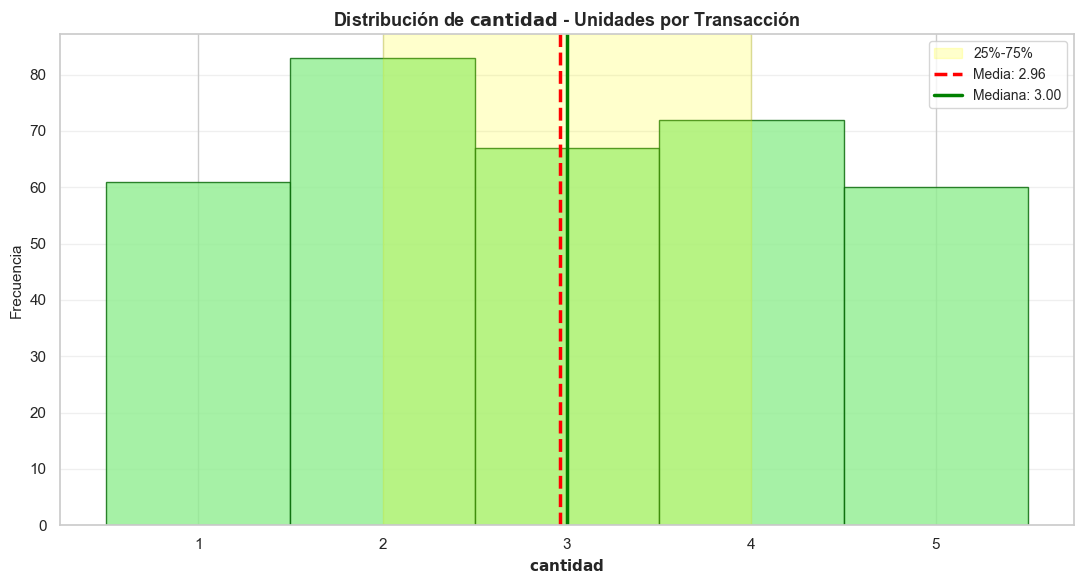

In [37]:
# Histograma de la columna "cantidad" con resumen estadístico extendido
import matplotlib.pyplot as plt
import numpy as np

# Lo que está evaluando
print('Lo que está evaluando: Distribución de la columna "cantidad" (unidades por línea de venta)')
print('Tipo de gráfico: Histograma con percentiles y estadísticos superpuestos')

# Datos
data_qty = df_detalle_ventas_True['cantidad'].dropna()

# Estadísticos básicos
media = data_qty.mean()
mediana = data_qty.median()
min_qty = data_qty.min()
max_qty = data_qty.max()
rango_qty = max_qty - min_qty
std = data_qty.std()
skew = data_qty.skew()
n_qty = len(data_qty)

var_qty = data_qty.var()
mad_qty = np.median(np.abs(data_qty - np.median(data_qty)))
cv_qty = std / media if media != 0 else np.nan
sem_qty = std / np.sqrt(n_qty) if n_qty > 0 else np.nan
t_crit_qty = stats.t.ppf(0.975, df=n_qty-1) if n_qty > 1 else np.nan
ci_low_qty = media - t_crit_qty * sem_qty if n_qty > 1 else np.nan
ci_high_qty = media + t_crit_qty * sem_qty if n_qty > 1 else np.nan

# Percentiles
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
p_dict = {pp: np.percentile(data_qty, pp) for pp in percentiles}
p25 = p_dict[25]
p75 = p_dict[75]

# Moda(s)
modas_qty = data_qty.mode().tolist()
n_modas_qty = len(modas_qty)

if n_modas_qty == 0:
    moda_qty_txt = 'Sin moda'
    clas_moda_qty = 'Sin moda definida'
else:
    moda_qty_txt = ', '.join(f'{m:.0f}' for m in modas_qty)
    if n_modas_qty == 1:
        clas_moda_qty = 'Unimodal'
    elif n_modas_qty == 2:
        clas_moda_qty = 'Bimodal'
    else:
        clas_moda_qty = 'Multimodal'

# Asimetría y curtosis
skew_qty = data_qty.skew()
kurt_qty = data_qty.kurt()

# Clasificación de asimetría
if np.isnan(skew_qty):
    clas_asim_qty = 'No disponible'
elif abs(skew_qty) < 0.05:
    clas_asim_qty = 'Simétrica'
elif skew_qty > 0:
    clas_asim_qty = 'Asimétrica positiva'
else:
    clas_asim_qty = 'Asimétrica negativa'

# Clasificación de curtosis
if np.isnan(kurt_qty):
    clas_curt_qty = 'No disponible'
elif kurt_qty < -0.5:
    clas_curt_qty = 'Platicúrtica (cola ligera)'
elif kurt_qty > 0.5:
    clas_curt_qty = 'Leptocúrtica (cola pesada)'
else:
    clas_curt_qty = 'Mesocúrtica (similar a normal)'

# BLOQUE DE PRINT EXTENDIDO (ordenado y legible)
print('\n' + '=' * 100)
print('RESUMEN ESTADÍSTICO EXTENDIDO - CANTIDAD')
print('=' * 100)

print(f'  Count (n observaciones)         : {n_qty:,}')
print(f'  Valor mínimo                    : {min_qty:.0f}')
print(f'  Valor máximo                    : {max_qty:.0f}')
print(f'  Rango                           : {rango_qty:.0f}')
print(f'  Media                           : {media:.4f}')
print(f'  Mediana                         : {mediana:.4f}')
print(f'  Desvío estándar                 : {std:.4f}')
print(f'  Varianza                        : {var_qty:.4f}')
print(f'  MAD (desvío absoluto mediano)   : {mad_qty:.4f}')
print(f'  Coeficiente de variación (CV)   : {cv_qty:.4f}')
print(f'  Error estándar de la media (SEM): {sem_qty:.4f}')
print(f'  IC 95% para la media            : [{ci_low_qty:.4f}, {ci_high_qty:.4f}]')

print('\n  -- Moda')
print(f'     Moda(s)                      : {moda_qty_txt}')
print(f'     Cantidad de modas            : {n_modas_qty}')
print(f'     Clasificación de la moda     : {clas_moda_qty}')

print('\n  -- Medidas de forma')
print(f'     Asimetría (skewness)         : {skew_qty:,.4f}')
print(f'     Clasificación de asimetría   : {clas_asim_qty}')
print(f'     Curtosis                     : {kurt_qty:,.4f}')
print(f'     Clasificación de curtosis    : {clas_curt_qty}')

print('\n  -- Percentiles seleccionados')
for pp in percentiles:
    print(f'     {pp:>3d}%: {p_dict[pp]:.0f}')

print('\n' + '-' * 100)
print('Nota: "cantidad" representa unidades por línea de venta; revisar cola derecha para grandes cantidades.')
print('-' * 100 + '\n')

# Histograma
plt.figure(figsize=(11, 6))
plt.hist(
    data_qty,
    bins=np.arange(data_qty.min(), data_qty.max() + 2) - 0.5,
    color='lightgreen',
    edgecolor='darkgreen',
    alpha=0.8
)

# Sombreado intercuartílico
plt.axvspan(p25, p75, color='yellow', alpha=0.2, label='25%-75%')

# Líneas estadísticas
plt.axvline(media, color='red', linestyle='--', linewidth=2.5, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2.5, label=f'Mediana: {mediana:.2f}')

# Etiquetas y título
plt.title(r'Distribución de $\mathbf{cantidad}$ - Unidades por Transacción', fontsize=13, fontweight='bold')
plt.xlabel(r'$\mathbf{cantidad}$', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



💡 **Conclusión:** La distribución de cantidad revela el patrón típico de compra de la base de clientes. Un análisis de los valores atípicos (outliers) permite identificar clientes o transacciones anómalas que compran en volúmenes significativamente distintos al promedio.

#### 📈 Relación Bivariada: **`cantidad`** vs **`importe`**
**Tipo de gráfico:** Scatter plot  
**Cómo:** Se grafica cada transacción como un punto en el plano (cantidad, importe), permitiendo visualizar la correlación.  
**Por qué:** Verificar si existe una relación lineal entre cantidad e importe (es decir, si comprar más unidades implica un importe proporcionalmente mayor), y detectar puntos atípicos que se desvíen de esta relación.

Lo que está evaluando: Relación entre cantidad e importe en cada transacción
Tipo de gráfico: Scatter plot con línea de regresión
Resumen estadístico estratégico:
  Correlación Pearson: 0.5997 | Spearman: 0.6107 (p=1.94e-36)
  Covariance: 4,314.83
  Cantidad: Media=2.96, Std=1.37
  Importe: Media=7,730.08, Std=5,265.54
  Regresión: importe = 884.28 + 2,311.13 × cantidad
  R² = 0.3597, p-value = 7.03e-35 | Std_err slope: 166.9932


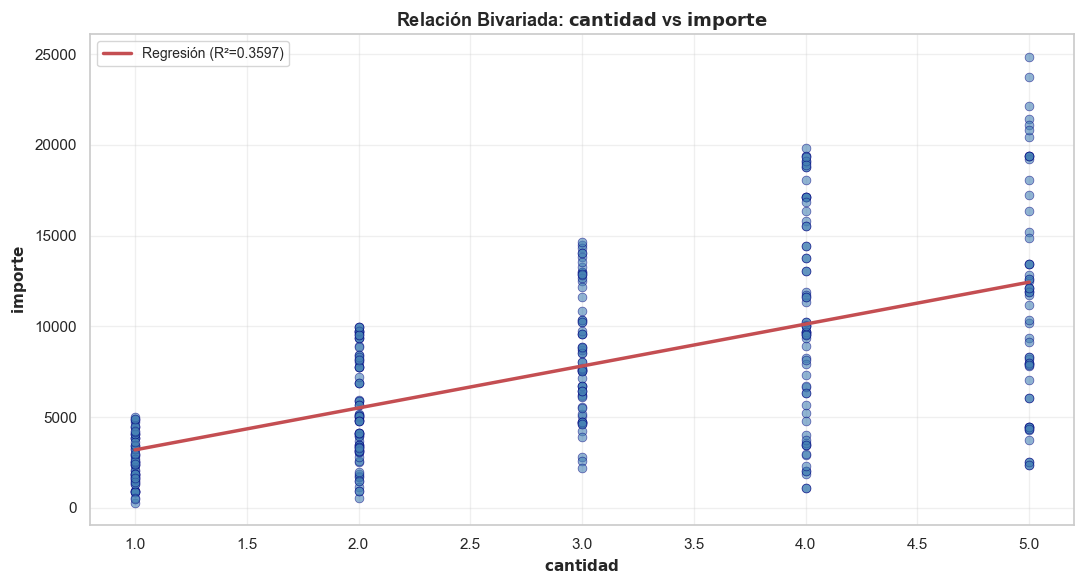

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Lo que está evaluando
print('Lo que está evaluando: Relación entre cantidad e importe en cada transacción')
print('Tipo de gráfico: Scatter plot con línea de regresión')

# Datos
qty = df_detalle_ventas_True['cantidad']
imp = df_detalle_ventas_True['importe']

# Correlación
corr = qty.corr(imp)
from scipy.stats import spearmanr
spearman_corr, spearman_p = spearmanr(qty, imp)
cov_qi = np.cov(qty, imp)[0,1]
print(f'Resumen estadístico estratégico:')
print(f'  Correlación Pearson: {corr:.4f} | Spearman: {spearman_corr:.4f} (p={spearman_p:.2e})')
print(f'  Covariance: {cov_qi:,.2f}')
print(f'  Cantidad: Media={qty.mean():.2f}, Std={qty.std():.2f}')
print(f'  Importe: Media={imp.mean():,.2f}, Std={imp.std():,.2f}')

# Regresión lineal
slope, intercept, r_value, p_value, std_err = linregress(qty, imp)
print(f'  Regresión: importe = {intercept:,.2f} + {slope:,.2f} × cantidad')
print(f'  R² = {r_value**2:.4f}, p-value = {p_value:.2e} | Std_err slope: {std_err:.4f}')

# Scatter
plt.figure(figsize=(11, 6))
plt.scatter(qty, imp, alpha=0.6, s=40, color='steelblue', edgecolors='navy', linewidth=0.5)

# Línea de regresión
x_line = np.array([qty.min(), qty.max()])
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, 'r-', linewidth=2.5, label=f'Regresión (R²={r_value**2:.4f})')

# Etiquetas
plt.title(r'Relación Bivariada: $\mathbf{cantidad}$ vs $\mathbf{importe}$', fontsize=13, fontweight='bold')
plt.xlabel(r'$\mathbf{cantidad}$', fontsize=11)
plt.ylabel(r'$\mathbf{importe}$', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


💡 **Conclusión:** Si la correlación es alta y positiva (próxima a +1), indica que la mayoría de transacciones siguen un patrón consistente donde más cantidad = mayor importe. Los puntos alejados de la línea de regresión representan precios/descuentos atípicos por unidad.

#### 📊 Boxplot Comparativo: **`importe`** (original vs log1p)
**Tipo de gráfico:** Boxplot (dos paneles)  
**Cómo:** Se visualiza la distribución de importe sin transformación (izquierda) y con transformación logarítmica (derecha).  
**Por qué:** Verificar cómo la transformación log1p comprime la cola superior (outliers), útil para aplicar luego modelos que asumen normalidad.

Lo que está evaluando: Efecto de la transformación log1p en la compresión de outliers en "importe"
Tipo de gráfico: Boxplot comparativo (antes y después)
Resumen estadístico estratégico:
  Importe original: Mean=7,730.08, Std=5,265.54, Var=27,725,943.89, Skew=0.8745
   MAD=3,346.00 | CV=0.6812 | SEM=284.3126 | 95% CI mean: [7,170.86, 8,289.30]
  Importe log1p: Mean=8.68, Std=0.81, Var=0.66, Skew=-0.6692
   MAD=0.55 | CV=0.0934 | SEM=0.0438 | 95% CI mean: [8.59, 8.77]


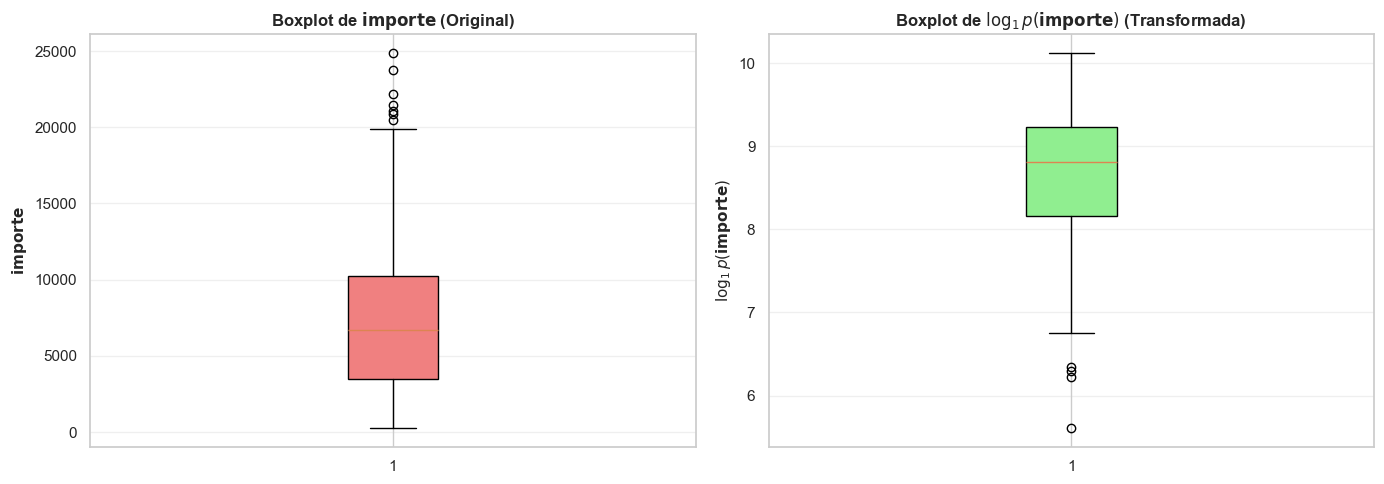

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Lo que está evaluando
print('Lo que está evaluando: Efecto de la transformación log1p en la compresión de outliers en "importe"')
print('Tipo de gráfico: Boxplot comparativo (antes y después)')

# Datos
importe_orig = df_detalle_ventas_True['importe']
importe_log = np.log1p(importe_orig)

# Estadísticos
print(f'Resumen estadístico estratégico:')
mean_orig = importe_orig.mean()
std_orig = importe_orig.std()
var_orig = importe_orig.var()
mad_orig = np.median(np.abs(importe_orig - np.median(importe_orig)))
cv_orig = std_orig / mean_orig if mean_orig != 0 else np.nan
sem_orig = std_orig / np.sqrt(len(importe_orig)) if len(importe_orig)>0 else np.nan
t_crit_o = stats.t.ppf(0.975, df=len(importe_orig)-1) if len(importe_orig)>1 else np.nan
ci_low_o = mean_orig - t_crit_o * sem_orig if len(importe_orig)>1 else np.nan
ci_high_o = mean_orig + t_crit_o * sem_orig if len(importe_orig)>1 else np.nan
print(f'  Importe original: Mean={mean_orig:,.2f}, Std={std_orig:,.2f}, Var={var_orig:,.2f}, Skew={importe_orig.skew():.4f}')
print(f'   MAD={mad_orig:,.2f} | CV={cv_orig:.4f} | SEM={sem_orig:.4f} | 95% CI mean: [{ci_low_o:,.2f}, {ci_high_o:,.2f}]')
mean_log = importe_log.mean()
std_log = importe_log.std()
var_log = importe_log.var()
mad_log = np.median(np.abs(importe_log - np.median(importe_log)))
cv_log = std_log / mean_log if mean_log != 0 else np.nan
sem_log = std_log / np.sqrt(len(importe_log)) if len(importe_log)>0 else np.nan
t_crit_l = stats.t.ppf(0.975, df=len(importe_log)-1) if len(importe_log)>1 else np.nan
ci_low_l = mean_log - t_crit_l * sem_log if len(importe_log)>1 else np.nan
ci_high_l = mean_log + t_crit_l * sem_log if len(importe_log)>1 else np.nan
print(f'  Importe log1p: Mean={mean_log:.2f}, Std={std_log:.2f}, Var={var_log:.2f}, Skew={importe_log.skew():.4f}')
print(f'   MAD={mad_log:.2f} | CV={cv_log:.4f} | SEM={sem_log:.4f} | 95% CI mean: [{ci_low_l:.2f}, {ci_high_l:.2f}]')

# Boxplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Original
bp1 = ax1.boxplot(importe_orig, vert=True, patch_artist=True)
bp1['boxes'][0].set_facecolor('lightcoral')
ax1.set_ylabel(r'$\mathbf{importe}$', fontsize=11)
ax1.set_title(r'Boxplot de $\mathbf{importe}$ (Original)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Log1p
bp2 = ax2.boxplot(importe_log, vert=True, patch_artist=True)
bp2['boxes'][0].set_facecolor('lightgreen')
ax2.set_ylabel(r'$\log_1p(\mathbf{importe})$', fontsize=11)
ax2.set_title(r'Boxplot de $\log_1p(\mathbf{importe})$ (Transformada)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


💡 **Conclusión:** La transformación logarítmica comprime la cola superior y reduce la asimetría. Esto es especialmente valioso cuando se planee aplicar modelos de regresión, ya que log1p mitiga el efecto de outliers financieros sin eliminarlos del dataset.

#### 📊 Top 10 Productos por Cantidad Total
**Tipo de gráfico:** Gráfico de barras horizontales  
**Cómo:** Se agrupa por id_producto, suma la cantidad total y se grafican los 10 productos con mayor volumen.  
**Por qué:** Identificar los productos más vendidos (en unidades) es clave para la gestión de inventario, promociones y estrategia comercial.

Lo que está evaluando: Productos más vendidos por volumen total de unidades
Tipo de gráfico: Gráfico de barras horizontales
Resumen estadístico estratégico:
  Total productos únicos: 95
  Cantidad total vendida: 1,016
  Top 10 productos concentran: 224 unidades (22.0% del total)
  Descripción estadística del Top 10 (suma por producto):
count    10.000000
mean     22.400000
std       2.458545
min      20.000000
25%      21.000000
50%      21.500000
75%      23.500000
max      27.000000


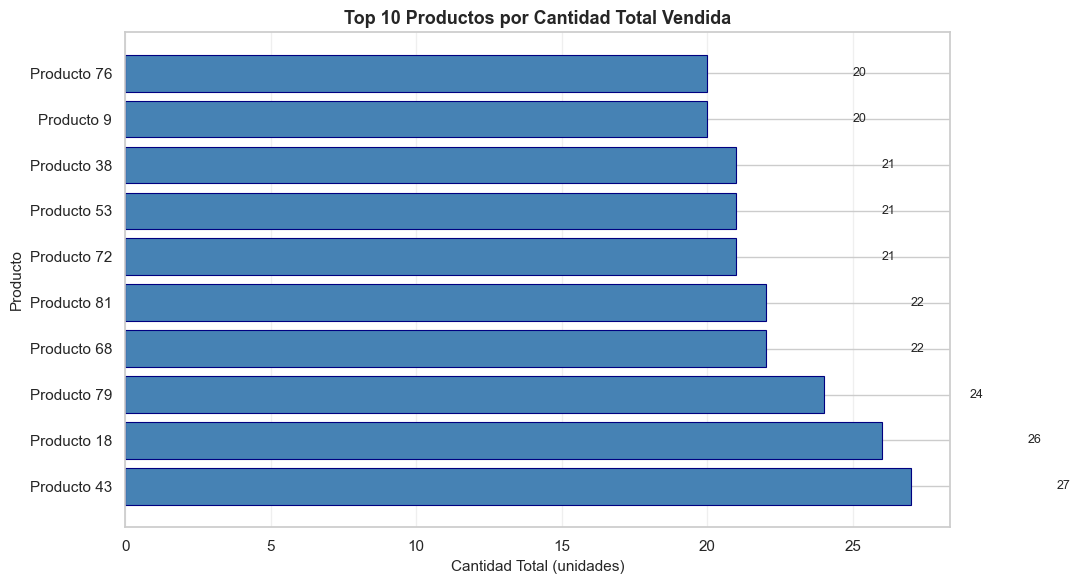

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# Lo que está evaluando
print('Lo que está evaluando: Productos más vendidos por volumen total de unidades')
print('Tipo de gráfico: Gráfico de barras horizontales')

# Agrupación por producto
product_qty = df_detalle_ventas_True.groupby('id_producto')['cantidad'].sum().sort_values(ascending=False)
top_10 = product_qty.head(10)

# Estadísticos
print(f'Resumen estadístico estratégico:')
print(f'  Total productos únicos: {len(product_qty)}')
print(f'  Cantidad total vendida: {df_detalle_ventas_True["cantidad"].sum():,}')
print(f'  Top 10 productos concentran: {top_10.sum():,} unidades ({top_10.sum()/df_detalle_ventas_True["cantidad"].sum()*100:.1f}% del total)')
# Estadísticas de la distribución de cantidades por producto (top10)
print('  Descripción estadística del Top 10 (suma por producto):')
print(top_10.describe().to_string())

# Gráfico de barras horizontal
plt.figure(figsize=(11, 6))
bars = plt.barh(range(len(top_10)), top_10.values, color='steelblue', edgecolor='navy', linewidth=0.8)

# Etiquetas
plt.yticks(range(len(top_10)), [f'Producto {pid}' for pid in top_10.index])
plt.xlabel('Cantidad Total (unidades)', fontsize=11)
plt.ylabel('Producto', fontsize=11)
plt.title('Top 10 Productos por Cantidad Total Vendida', fontsize=13, fontweight='bold')

# Valores en las barras
for i, (idx, val) in enumerate(top_10.items()):
    plt.text(val + 5, i, f'{int(val):,}', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


💡 **Conclusión:** La concentración de ventas en un pequeño número de productos sugiere oportunidades para marketing diferenciado, gestión de stock optimizada, y análisis de rentabilidad por producto.

# 🏪 Proyecto Aurelion

Este notebook documenta el proceso de **análisis, limpieza y transformación de datos** de la tabla `PRODUCTOS` del proyecto *Aurelion*, utilizando la biblioteca **Pandas** en Python.

El objetivo es preparar un conjunto de datos estructurado, limpio y estandarizado para posteriores procesos de análisis estadístico, modelado o visualización.

## 📊 Descripción General

La tabla `PRODUCTOS` contiene el catálogo de artículos disponibles para venta, incluyendo identificadores, nombres, categorías y precios unitarios.

### Tareas Principales del Notebook

1. **Importación de datos** desde archivo Excel con rutas portables (`pathlib.Path`).
2. **Inspección inicial** para validar estructura, tipos y valores faltantes.
3. **Normalización de tipos de datos**: conversión de `precio_unitario` a `float64` para precisión decimal.
4. **Limpieza de texto**: estandarización de `nombre_producto` (formato Título) y `categoria` (minúsculas).
5. **Optimización de memoria**: conversión de `categoria` a tipo `category`.
6. **Control de calidad**: detección de duplicados y validación de unicidad en `id_producto`.

### Metodología ETL Aplicada

- **Extracción (E):** Lectura del archivo Excel con `pd.read_excel()`.
- **Transformación (T):** Normalización de tipos, limpieza de texto, optimización categórica.
- **Carga (L):** Datos transformados permanecen en memoria como `df_productos_c` para posterior asignación a `df_productos_True` y uso en consolidación con otras tablas.

**Nota:** El archivo original `productos.xlsx` NO se modifica. Los cambios se mantienen en el dataframe en memoria.

In [41]:
# Importa paquetes de an?lisis (pandas/numpy) y visualizaci?n (matplotlib/seaborn) con rutas portables
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


## 🛠 Instalación e Importación de Librerías

En esta sección se instalan y cargan las principales bibliotecas de Python utilizadas para el análisis de datos:

- **pandas:** Manipulación y análisis de dataframes.
- **numpy:** Operaciones numéricas y arrays.
- **matplotlib/seaborn:** Visualización de datos.
- **pathlib:** Rutas portables entre sistemas operativos.

## 📥 Carga del Archivo de Datos

En esta sección se realiza la **importación del dataset principal** utilizando una **ruta relativa** y la librería `pathlib.Path`. Esto no solo simplifica la ruta, sino que también garantiza que el código sea **portable** y funcione correctamente en diferentes sistemas operativos (Windows, macOS, Linux), siempre y cuando la estructura de directorios se mantenga consistente.

> 📂 **Ruta del archivo:**  
> El archivo se accede mediante la construcción **`Path('db') / 'productos.xlsx'`**.

La lectura del archivo se efectúa mediante la función `pd.read_excel()` de la biblioteca **pandas**, creando el dataframe inicial `df_productos_c`, el cual servirá como base para los procesos posteriores de limpieza y análisis.

## 📥 Carga del Archivo de Datos

En esta sección se realiza la **importación del dataset principal** de productos utilizando **rutas relativas** y la librería `pathlib.Path`. Esto garantiza que el código sea **portable** entre sistemas operativos (Windows, macOS, Linux).

> 📂 **Ruta del archivo:** El archivo se accede mediante `Path('db') / 'productos.xlsx'`.

El dataframe inicial `df_productos_c` servirá como base para los procesos posteriores de limpieza y análisis.

In [42]:
# Lee el catálogo de productos desde la carpeta db usando rutas relativas
path_dataset = Path('db') / 'productos.xlsx'
df_productos_c = pd.read_excel(path_dataset)

# Inspecciona los primeros registros para validar estructura y campos
df_productos_c.head()


,id_producto,nombre_producto,categoria,precio_unitario
0,1,Coca Cola 1.5L,Alimentos,2347
1,2,Pepsi 1.5L,Limpieza,4973
2,3,Sprite 1.5L,Alimentos,4964
3,4,Fanta Naranja 1.5L,Limpieza,2033
4,5,Agua Mineral 500ml,Alimentos,4777


## 🔍 Inspección Inicial del Dataset

En esta etapa se realiza una **inspección exploratoria básica** del DataFrame `df_productos_c` recién cargado, con el objetivo de verificar que los datos se hayan importado correctamente y posean la estructura esperada.

Se utilizan las funciones `head()` y `tail()` para visualizar las primeras y últimas filas del dataset.

### 🧠 Análisis de Estructura y Calidad de Datos

En esta etapa se evalúan los siguientes aspectos del DataFrame `df_productos_c`:

- **Estructura y tipos de datos:** Verificación de columnas y tipos asignados (`int64`, `object`, `float64`, etc.) mediante `info()`
- **Valores faltantes (NaN):** Identificación de vacíos que requieran tratamiento mediante `isnull().sum()`
- **Unicidad:** Validación de valores únicos en identificadores clave (`id_producto`)

In [43]:
# Ampl?a la vista inicial a 8 filas para detectar anomal?as tempranas
df_productos_c.head(8)


,id_producto,nombre_producto,categoria,precio_unitario
0,1,Coca Cola 1.5L,Alimentos,2347
1,2,Pepsi 1.5L,Limpieza,4973
2,3,Sprite 1.5L,Alimentos,4964
3,4,Fanta Naranja 1.5L,Limpieza,2033
4,5,Agua Mineral 500ml,Alimentos,4777
5,6,Jugo de Naranja 1L,Limpieza,4170
6,7,Jugo de Manzana 1L,Alimentos,3269
7,8,Energética Nitro 500ml,Limpieza,4218


In [44]:
# Revisa las ?ltimas 4 filas para confirmar consistencia al final del archivo
df_productos_c.tail(4)


,id_producto,nombre_producto,categoria,precio_unitario
96,97,Limpiavidrios 500ml,Alimentos,872
97,98,Desengrasante 500ml,Limpieza,2843
98,99,Esponjas x3,Alimentos,2430
99,100,Trapo de Piso,Limpieza,4854


In [45]:
# Resume tipos de datos, nulos y memoria del dataframe importado
df_productos_c.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_producto      100 non-null    int64 
 1   nombre_producto  100 non-null    object
 2   categoria        100 non-null    object
 3   precio_unitario  100 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 3.3+ KB


> 💡 **Conclusión:**  
> A partir de la ejecución de la inspección del DataFrame, se observa que la base de datos cuenta con **100 registros** distribuidos en **4 columnas**.  
> Cada columna presenta **100 valores no nulos**, lo que indica que **no existen datos faltantes (NaN)** en el dataset en esta etapa.  
> 
> **Tipos de datos identificados**:
> - `id_producto` y `precio_unitario`: tipo `int64` (se convertirá `precio_unitario` a `float64` en el siguiente paso)
> - `nombre_producto` y `categoria`: tipo `object` (texto)
> 
> Esta estructura inicial es **coherente y está lista** para los procesos de **normalización** (estandarización de texto) y **transformación** (conversión de `precio_unitario` a float, optimización de `categoria` como tipo category).

### 🕵️‍♂️ Detección de Valores Nulos

Se analiza la presencia de valores faltantes para priorizar acciones de limpieza y asegurar la consistencia del dataset.

In [46]:
# Visualiza la máscara booleana donde True marca valores faltantes por celda
df_productos_c.isnull()

,id_producto,nombre_producto,categoria,precio_unitario
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
95,False,False,False,False
96,False,False,False,False
97,False,False,False,False
98,False,False,False,False


In [47]:
# Resume la cantidad de nulos por columna para priorizar limpieza
df_productos_c.isnull().sum()

id_producto        0
nombre_producto    0
categoria          0
precio_unitario    0
dtype: int64

## ⚙️ Normalización y Corrección de Tipos de Datos

Antes de realizar análisis, es necesario **verificar y corregir los tipos de datos** asignados a cada columna. En este caso:

- **Precio unitario:** Conversión a `float64` para asegurar precisión decimal en cálculos financieros.
- **Nombre producto:** Limpieza de espacios y normalización con formato Título.
- **Categoría:** Limpieza de espacios, conversión a minúsculas y optimización como tipo `category` para mejorar eficiencia de memoria y facilitar agrupaciones.

### 🧩 Fundamento

Corregir tipos de datos garantiza:
- ✅ **Precisión numérica** en cálculos financieros y estadísticos.
- ✅ **Consistencia de datos** en campos de texto para análisis y reportes.
- ✅ **Eficiencia de memoria** mediante tipos optimizados (category para baja cardinalidad).
- ✅ **Facilidad de agrupación** mediante categorías estandarizadas.

### 🧮 Procedimiento

Se aplican las transformaciones para:

**Precio:** Asegurar formato `float64` (precisión decimal).

**Texto:** Limpiar `nombre_producto` y `categoria` (eliminar espacios, unificar formato).

**Categóricas:** Convertir `categoria` a tipo `category` para optimización.

In [48]:
# 1. Corrección de Tipo de Dato Numérico
# Se convierte 'precio_unitario' a float64 para asegurar precisión decimal.
df_productos_c['precio_unitario'] = df_productos_c['precio_unitario'].astype('float64')

# 2. Normalización de Campos de Texto y Categórico
# Se aplica limpieza de espacios y estandarización a campos de texto.
df_productos_c['nombre_producto'] = (
    df_productos_c['nombre_producto']
    .str.strip()
    .str.title() # Formato Título para nombres de producto
)

# Se aplica limpieza y se convierte a categórico para optimizar memoria y agrupación.
df_productos_c['categoria'] = (
    df_productos_c['categoria']
    .str.strip()
    .str.lower()
    .astype('category')
)

### ✅ Transformaciones Aplicadas

Las siguientes operaciones han sido ejecutadas sobre `df_productos_c`:

1. **Conversión de tipo numérico:** `precio_unitario` convertido a `float64`
2. **Normalización de texto:** `nombre_producto` con formato Título, espacios eliminados
3. **Optimización categórica:** `categoria` convertida a tipo `category` en minúsculas

**Resultado**: Dataset optimizado para análisis con tipos de datos coherentes y eficientes.

In [49]:
# Resumen estadístico limpio y presentable
print('\n=== Resumen estadístico - PRODUCTOS ===\n')
# Dimensiones y tipos
print('Dimensiones:', df_productos_c.shape)
print('\nTipos de datos:')
print(df_productos_c.dtypes.to_string())
# Nulos y duplicados
print('\nNulos por columna:')
print(df_productos_c.isnull().sum().to_string())
print('\nDuplicados totales:', df_productos_c.duplicated().sum())
# Estadísticas numéricas para precio_unitario
print('\nResumen de `precio_unitario`:')
print(df_productos_c['precio_unitario'].describe().to_string())
print('\nEstadísticas adicionales de precio:')
print(f'Mediana: {df_productos_c['precio_unitario'].median():.2f}')
print(f'Desviación típica: {df_productos_c['precio_unitario'].std():.2f}')
# skew puede fallar si hay pocos puntos; lo protegemos
try:
    skew_val = df_productos_c['precio_unitario'].skew()
except Exception:
    skew_val = float('nan')
print(f'Skewness: {skew_val:.2f}')
# Conteos y top valores
print('\nConteo por categoría (top 10):')
print(df_productos_c['categoria'].value_counts().head(10).to_string())
print('\nProductos más frecuentes (top 10):')
print(df_productos_c['nombre_producto'].value_counts().head(10).to_string())
# Resumen final compacto
print('\nResumen final:')
print(f'Productos únicos: {df_productos_c['id_producto'].nunique()} | Categorías únicas: {df_productos_c['categoria'].nunique()}')



=== Resumen estadístico - PRODUCTOS ===

Dimensiones: (100, 4)

Tipos de datos:
id_producto           int64
nombre_producto      object
categoria          category
precio_unitario     float64

Nulos por columna:
id_producto        0
nombre_producto    0
categoria          0
precio_unitario    0

Duplicados totales: 0

Resumen de `precio_unitario`:
count     100.000000
mean     2718.550000
std      1381.635324
min       272.000000
25%      1590.000000
50%      2516.000000
75%      4026.500000
max      4982.000000

Estadísticas adicionales de precio:
Mediana: 2516.00
Desviación típica: 1381.64
Skewness: 0.15

Conteo por categoría (top 10):
categoria
alimentos    50
limpieza     50

Productos más frecuentes (top 10):
nombre_producto
Coca Cola 1.5L             1
Avena Instantánea 250G     1
Whisky 750Ml               1
Gin 700Ml                  1
Ron 700Ml                  1
Vodka 700Ml                1
Fernet 750Ml               1
Sidra 750Ml                1
Vino Blanco 750Ml          

### 🔍 Verificación de Transformaciones Aplicadas

Se valida que los cambios hayan surtido efecto en tipos de datos y muestras de datos.

In [50]:
# Verifica los tipos de datos de las columnas normalizadas tras la conversión en la tabla PRODUCTOS
df_productos_c[["id_producto", "nombre_producto", "categoria", "precio_unitario"]].dtypes

id_producto           int64
nombre_producto      object
categoria          category
precio_unitario     float64
dtype: object

In [51]:
# Realiza muestreo de las columnas transformadas para comprobar resultados
df_productos_c[["id_producto", "nombre_producto", "categoria", "precio_unitario"]].head()

,id_producto,nombre_producto,categoria,precio_unitario
0,1,Coca Cola 1.5L,alimentos,2347.0
1,2,Pepsi 1.5L,limpieza,4973.0
2,3,Sprite 1.5L,alimentos,4964.0
3,4,Fanta Naranja 1.5L,limpieza,2033.0
4,5,Agua Mineral 500Ml,alimentos,4777.0


### 🕵️‍♂️ Control de Calidad: Validación de Unicidad

Se evalúa la integridad de registros, especialmente en `id_producto` como identificador clave.

In [52]:
# Evalúa duplicados globales y por id_producto para validar la unicidad clave de productos
cantidad_duplicados = df_productos_c.duplicated().sum()
duplicados_id_producto = df_productos_c['id_producto'].duplicated().sum()

print()
print('--- Registros Duplicados ---')
if cantidad_duplicados > 0:
    print(f'Se encontraron {cantidad_duplicados} filas duplicadas.')
    # Si se encuentran duplicados y se necesita eliminarlos, usar:
    # df_productos_c = df_productos_c_True_duplicates().copy()
else:
    print('No se encontraron filas duplicadas.')

print()
if duplicados_id_producto > 0:
    print(f'Alerta: se detectaron {duplicados_id_producto} valores repetidos en id_producto (posible clave primaria).')
else:
    print('id_producto es único en df_productos_c.')


--- Registros Duplicados ---
No se encontraron filas duplicadas.

id_producto es único en df_productos_c.


> 💡 **Conclusión:**
> Luego de la verificación y **normalización optimizada** de tipos de datos, se confirma que todas las variables del *dataset* `PRODUCTOS` presentan formatos consistentes y adecuados:
>
> * La columna **`precio_unitario`** fue convertida a **`float64`**, lo cual asegura la **precisión decimal** necesaria para cálculos financieros (ej. promedios y márgenes).
> * Las columnas **`nombre_producto`** y **`id_producto`** mantienen tipos coherentes con su contenido (`object` / `int64`), asegurando la **normalización de texto** (eliminación de espacios y unificación de mayúsculas/minúsculas).
> * La variable **`categoria`** fue convertida al tipo **categórico (`category`)**, lo que facilita las agrupaciones y segmentaciones y genera una **mejora en la eficiencia del procesamiento** y el uso de memoria.
>
> De esta forma, el *dataframe* `df_productos_c` queda estructurado de manera coherente, **garantizando integridad, consistencia, y una ligera mejora en la eficiencia del procesamiento** para las etapas posteriores de transformación y análisis.

## 🏆 Resumen: Normalización y Limpieza Completada

Tras la **normalización optimizada**, se confirma que todas las variables presentan formatos consistentes:

✅ **Precio unitario → float64:** Precisión decimal asegurada.  
✅ **Nombre producto → str (título):** Normalización de mayúsculas aplicada.  
✅ **Categoría → category:** Optimización de memoria y facilidad de agrupación.  
✅ **Sin duplicados:** Integridad de identificadores clave validada.  

El dataframe `df_productos_c` está **estructurado, coherente y listo** para la auditoría de categorización.

In [53]:
# Análisis de categorización: identificar productos mal categorizados
# Se utiliza análisis semántico del nombre_producto para detectar incongruencias

print('\n' + '='*100)
print('AUDITORÍA DE CATEGORIZACIÓN DE PRODUCTOS')
print('='*100)

# Mostrar distribución actual de productos por categoría
print('\nDistribución actual de productos por categoría:')
print(df_productos_c['categoria'].value_counts().sort_values(ascending=False).to_string())

print('\n--- Análisis por categoría: primeros 5 productos de cada una ---\n')

# Agrupar por categoría para revisar nombres y detectar incongruencias
for cat in df_productos_c['categoria'].unique():
    productos_cat = df_productos_c[df_productos_c['categoria'] == cat][['id_producto', 'nombre_producto', 'precio_unitario']].head(10)
    print(f'\n📦 Categoría: {cat}')
    print(productos_cat.to_string(index=False))
    print('-' * 100)

print('\n💡 Nota: Revise los nombres de productos y detecte si alguno está mal asignado.')
print('Después de identificar, aplicaremos correcciones sistemáticas en la siguiente celda.')



AUDITORÍA DE CATEGORIZACIÓN DE PRODUCTOS

Distribución actual de productos por categoría:
categoria
alimentos    50
limpieza     50

--- Análisis por categoría: primeros 5 productos de cada una ---


📦 Categoría: alimentos
 id_producto      nombre_producto  precio_unitario
           1       Coca Cola 1.5L           2347.0
           3          Sprite 1.5L           4964.0
           5   Agua Mineral 500Ml           4777.0
           7   Jugo De Manzana 1L           3269.0
           9 Yerba Mate Suave 1Kg           3878.0
          11     Café Molido 250G           2053.0
          13 Té Verde 20 Saquitos           2383.0
          15  Leche Descremada 1L           2538.0
          17   Queso Cremoso 500G           4834.0
          19         Manteca 200G           3251.0
----------------------------------------------------------------------------------------------------

📦 Categoría: limpieza
 id_producto        nombre_producto  precio_unitario
           2             Pepsi 1.5L   

## 🔎 Auditoría de Categorización de Productos

Esta sección realiza una **auditoría completa** para identificar productos mal categorizados utilizando análisis semántico del nombre del producto.

### Metodología

1. **Análisis Semántico:** Se identifican palabras clave específicas de cada categoría en el nombre del producto.
2. **Clasificación Automática:** Se asigna la categoría correcta basada en coincidencias de palabras clave.
3. **Detección de Anomalías:** Se comparan categorías actuales con las recomendadas para identificar errores.

In [54]:
# Corrección de Categorización: Reasignar productos a categorías correctas
# Metodología: Análisis semántico del nombre_producto y reglas de negocio

print('\n' + '='*100)
print('CORRECCIÓN DE CATEGORIZACIÓN: REASIGNACIÓN DE PRODUCTOS')
print('='*100)

# Palabras clave por categoría para identificar productos correctamente
palabras_alimentos = [
    'cola', 'pepsi', 'sprite', 'fanta', 'agua', 'jugo', 'energética', 
    'yerba', 'café', 'té', 'leche', 'queso', 'manteca', 'yogur', 'pan',
    'bebida', 'refresco', 'bebidas', 'lácteos', 'lácteo'
]

palabras_limpieza = [
    'limpiador', 'detergente', 'jabón', 'desinfectante', 'cloro', 
    'escoba', 'trapo', 'esponja', 'cepillo', 'limpieza'
]

# Función para clasificar producto según nombre
def clasificar_producto(nombre_producto):
    """
    Clasifica un producto según palabras clave en su nombre.
    Retorna: 'alimentos' o 'limpieza'
    """
    nombre_lower = nombre_producto.lower()
    
    # Contar coincidencias
    count_alimentos = sum(1 for palabra in palabras_alimentos if palabra in nombre_lower)
    count_limpieza = sum(1 for palabra in palabras_limpieza if palabra in nombre_lower)
    
    # Determinar categoría según coincidencias
    if count_alimentos > count_limpieza:
        return 'alimentos'
    elif count_limpieza > count_alimentos:
        return 'limpieza'
    else:
        # Por defecto, si hay ambigüedad, revisar patrones adicionales
        # Bebidas, alimentos refrigerados → alimentos
        if any(x in nombre_lower for x in ['ml', 'litro', 'l.', '1l', 'kg', 'g.', '200g', '500g', '150g', '250g']):
            return 'alimentos'
        return 'alimentos'  # Por defecto

# Crear una copia para comparar antes/después
df_productos_c['categoria_original'] = df_productos_c['categoria'].copy()
df_productos_c['categoria_correcta'] = df_productos_c['nombre_producto'].apply(clasificar_producto)

# Comparar y mostrar cambios necesarios
cambios = df_productos_c[df_productos_c['categoria'] != df_productos_c['categoria_correcta']]

if len(cambios) > 0:
    print(f'\n✅ Se detectaron {len(cambios)} productos mal categorizados:\n')
    print('PRODUCTOS A REASIGNAR:')
    print('-' * 100)
    cambios_display = cambios[['id_producto', 'nombre_producto', 'categoria_original', 'categoria_correcta', 'precio_unitario']]
    print(cambios_display.to_string(index=False))
    
    # Aplicar correcciones
    print('\n' + '-' * 100)
    print('\nAplicando correcciones...\n')
    
    for idx, row in cambios.iterrows():
        producto = row['nombre_producto']
        cat_vieja = row['categoria_original']
        cat_nueva = row['categoria_correcta']
        df_productos_c.loc[idx, 'categoria'] = cat_nueva
        print(f"  ✓ Producto ID {row['id_producto']:>3d}: '{producto}' movido de '{cat_vieja}' → '{cat_nueva}'")
    
    print(f'\n✅ Corrección completada: {len(cambios)} productos reasignados.')
else:
    print('\n✅ No se detectaron productos mal categorizados. La categorización es correcta.')

# Validar resultado final
print('\n' + '='*100)
print('DISTRIBUCIÓN FINAL DESPUÉS DE CORRECCIONES')
print('='*100)
print('\nProductos por categoría:')
print(df_productos_c['categoria'].value_counts().sort_values(ascending=False).to_string())

# Limpiar columnas temporales
df_productos_c = df_productos_c.drop(columns=['categoria_original', 'categoria_correcta'])

print('\n✅ Dataframe normalizado y listo para análisis.')



CORRECCIÓN DE CATEGORIZACIÓN: REASIGNACIÓN DE PRODUCTOS

✅ Se detectaron 49 productos mal categorizados:

PRODUCTOS A REASIGNAR:
----------------------------------------------------------------------------------------------------
 id_producto            nombre_producto categoria_original categoria_correcta  precio_unitario
           2                 Pepsi 1.5L           limpieza          alimentos           4973.0
           4         Fanta Naranja 1.5L           limpieza          alimentos           2033.0
           6         Jugo De Naranja 1L           limpieza          alimentos           4170.0
           8     Energética Nitro 500Ml           limpieza          alimentos           4218.0
          10     Yerba Mate Intensa 1Kg           limpieza          alimentos           4883.0
          12       Té Negro 20 Saquitos           limpieza          alimentos            570.0
          14            Leche Entera 1L           limpieza          alimentos           1723.0
         

#### ? Consolidaci?n final de PRODUCTOS

Se crea el dataframe limpio `df_productos_True` para mantener la nomenclatura unificada entre las tablas consolidadas.


In [55]:
# Crea el dataframe final de productos alineado con la nomenclatura del proyecto
df_productos_True = df_productos_c.copy()

print(f"DataFrame final 'df_productos_True' creado. Dimensiones: {df_productos_True.shape}")
print('Columnas de df_productos_True:')
print(df_productos_True.columns.tolist())


DataFrame final 'df_productos_True' creado. Dimensiones: (100, 4)
Columnas de df_productos_True:
['id_producto', 'nombre_producto', 'categoria', 'precio_unitario']


## 🖼️ Análisis Exploratorio y Visualización (EDA)

### Objetivos del EDA:
- Caracterizar la **distribución de precios unitarios** (variable numérica clave)
- Analizar **variabilidad de precios por categoría** (bivariate analysis)
- Identificar **patrones composicionales** (distribución de productos por categoría)
- Detectar **valores atípicos** (outliers) según criterios estadísticos
- Fundamentar decisiones con **estadísticas extendidas** (percentiles, asimetría, curtosis)

### Metodología:
1. **Univariado:** Histogramas, boxplots, violin plots para precio_unitario
2. **Bivariado:** Análisis precio × categoría
3. **Composición:** Proporciones y frecuencias por categoría
4. **Outliers:** Métodos IQR y Z-score modificado

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

print('\n' + '='*100)
print('ESTADÍSTICAS DESCRIPTIVAS EXTENDIDAS: PRECIO_UNITARIO')
print('='*100)

# Variable de análisis
var_analisis = 'precio_unitario'
datos = df_productos_c[var_analisis].dropna()

# Estadísticas básicas
media = datos.mean()
mediana = datos.median()
std = datos.std()
varianza = datos.var()

# Desviación absoluta mediana (MAD)
mad = (np.abs(datos - mediana)).median()

# Coeficiente de variación (CV) y Error estándar de la media (SEM)
cv = (std / media) * 100 if media != 0 else 0
sem = datos.sem()

# Rango y amplitud intercuartil (IQR)
rango = datos.max() - datos.min()
q1 = datos.quantile(0.25)
q3 = datos.quantile(0.75)
iqr = q3 - q1

# Percentiles estratégicos
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
percentil_vals = {f'P{p}': datos.quantile(p/100) for p in percentiles}

# Asimetría y curtosis
skewness = stats.skew(datos)
kurtosis_val = stats.kurtosis(datos)

# Clasificación de asimetría
def clasificar_asimetria(skew):
    if abs(skew) < 0.5:
        return "Simétrica (distribución equilibrada)"
    elif skew > 0:
        return "Asimétrica positiva/derecha (cola a la derecha)"
    else:
        return "Asimétrica negativa/izquierda (cola a la izquierda)"

# Clasificación de curtosis
def clasificar_curtosis(kurt):
    if abs(kurt) < 0.5:
        return "Mesocúrtica (similar a normal)"
    elif kurt > 0:
        return "Leptocúrtica (colas pesadas, pico pronunciado)"
    else:
        return "Platicúrtica (colas ligeras, distribución achatada)"

# Intervalo de confianza 95% para la media (t-distribution)
t_crit = stats.t.ppf(0.975, len(datos) - 1)
ci_lower = media - (t_crit * sem)
ci_upper = media + (t_crit * sem)

print(f'\n📊 VARIABLE: {var_analisis.upper()}')
print(f'   Número de observaciones: {len(datos)}')
print(f'   Valores faltantes: {df_productos_c[var_analisis].isna().sum()}')

print(f'\n📈 MEDIDAS DE TENDENCIA CENTRAL:')
print(f'   Media (μ):                    ${media:,.2f}')
print(f'   Mediana (Me):                 ${mediana:,.2f}')
print(f'   Diferencia (μ - Me):          ${media - mediana:,.2f}')

print(f'\n📏 MEDIDAS DE DISPERSIÓN:')
print(f'   Rango (Max - Min):            ${rango:,.2f}')
print(f'   Desviación estándar (σ):      ${std:,.2f}')
print(f'   Varianza (σ²):                ${varianza:,.2f}')
print(f'   Desv. Absoluta Mediana (MAD): ${mad:,.2f}')
print(f'   Coef. de Variación (CV):      {cv:.2f}% {"(Alta variabilidad)" if cv > 30 else "(Variabilidad moderada)" if cv > 15 else "(Baja variabilidad)"}')
print(f'   Error Estándar Media (SEM):   ${sem:,.2f}')

print(f'\n🎯 MEDIDAS DE POSICIÓN (CUANTILES):')
print(f'   Q1 (Percentil 25):            ${q1:,.2f}')
print(f'   Q2 (Percentil 50/Mediana):    ${mediana:,.2f}')
print(f'   Q3 (Percentil 75):            ${q3:,.2f}')
print(f'   IQR (Q3 - Q1):                ${iqr:,.2f}')
print(f'\n   Percentiles estratégicos:')
for p in percentiles:
    print(f'      P{p:>2d}:                            ${percentil_vals[f"P{p}"]:>10,.2f}')

print(f'\n🔄 MEDIDAS DE FORMA:')
print(f'   Asimetría (Skewness):         {skewness:,.4f}')
print(f'   ├─ Clasificación:             {clasificar_asimetria(skewness)}')
print(f'   Curtosis (Excess Kurtosis):   {kurtosis_val:,.4f}')
print(f'   ├─ Clasificación:             {clasificar_curtosis(kurtosis_val)}')

print(f'\n🎲 INTERVALO DE CONFIANZA 95% (t-distribution):')
print(f'   Límite inferior:              ${ci_lower:,.2f}')
print(f'   Límite superior:              ${ci_upper:,.2f}')
print(f'   IC[95%]:                      [${ci_lower:,.2f} ; ${ci_upper:,.2f}]')

# Detección de outliers: Método IQR (Tukey)
print(f'\n⚠️  DETECCIÓN DE OUTLIERS (Método IQR - Tukey):')
limite_inferior_iqr = q1 - 1.5 * iqr
limite_superior_iqr = q3 + 1.5 * iqr
outliers_iqr = datos[(datos < limite_inferior_iqr) | (datos > limite_superior_iqr)]
print(f'   Límite inferior: Q1 - 1.5×IQR = ${limite_inferior_iqr:,.2f}')
print(f'   Límite superior: Q3 + 1.5×IQR = ${limite_superior_iqr:,.2f}')
print(f'   Número de outliers (IQR):    {len(outliers_iqr)} ({len(outliers_iqr)/len(datos)*100:.1f}%)')
if len(outliers_iqr) > 0:
    print(f'   Outliers detectados:')
    for val in sorted(outliers_iqr):
        idx_outlier = datos[datos == val].index[0]
        print(f'      ${val:>10,.2f} - ID Producto: {df_productos_c.loc[idx_outlier, "id_producto"]:>3d} ({df_productos_c.loc[idx_outlier, "nombre_producto"]})')

# Detección de outliers: Método Z-score modificado (Iglewicz & Hoaglin)
print(f'\n⚠️  DETECCIÓN DE OUTLIERS (Z-score Modificado - Iglewicz & Hoaglin, threshold=3.5):')
z_score_mod = 0.6745 * (datos - mediana) / mad if mad != 0 else np.zeros(len(datos))
outliers_zscore = datos[np.abs(z_score_mod) > 3.5]
print(f'   Número de outliers (Z-score): {len(outliers_zscore)} ({len(outliers_zscore)/len(datos)*100:.1f}%)')
if len(outliers_zscore) > 0:
    print(f'   Outliers detectados:')
    for val in sorted(outliers_zscore):
        idx_outlier = datos[datos == val].index[0]
        z_val = z_score_mod[idx_outlier]
        print(f'      ${val:>10,.2f} (Z-mod={z_val:>6.2f}) - ID Producto: {df_productos_c.loc[idx_outlier, "id_producto"]:>3d} ({df_productos_c.loc[idx_outlier, "nombre_producto"]})')

print('\n' + '='*100)


ESTADÍSTICAS DESCRIPTIVAS EXTENDIDAS: PRECIO_UNITARIO

📊 VARIABLE: PRECIO_UNITARIO
   Número de observaciones: 100
   Valores faltantes: 0

📈 MEDIDAS DE TENDENCIA CENTRAL:
   Media (μ):                    $2,718.55
   Mediana (Me):                 $2,516.00
   Diferencia (μ - Me):          $202.55

📏 MEDIDAS DE DISPERSIÓN:
   Rango (Max - Min):            $4,710.00
   Desviación estándar (σ):      $1,381.64
   Varianza (σ²):                $1,908,916.17
   Desv. Absoluta Mediana (MAD): $1,097.00
   Coef. de Variación (CV):      50.82% (Alta variabilidad)
   Error Estándar Media (SEM):   $138.16

🎯 MEDIDAS DE POSICIÓN (CUANTILES):
   Q1 (Percentil 25):            $1,590.00
   Q2 (Percentil 50/Mediana):    $2,516.00
   Q3 (Percentil 75):            $4,026.50
   IQR (Q3 - Q1):                $2,436.50

   Percentiles estratégicos:
      P 1:                            $    467.03
      P 5:                            $    719.15
      P10:                            $    885.50
      P25

### 📈 Visualización Univariada - Distribución de Precio Unitario

**Tipo de gráfico:** Histogramas, Boxplot, Violin Plot  
**Cómo:** Representan la frecuencia de precios (histograma), la dispersión y posición de la distribución (boxplot), y la densidad continua (violin plot)  
**Por qué:** Permiten identificar patrones de concentración, asimetría visual, valores extremos y la forma general de la distribución

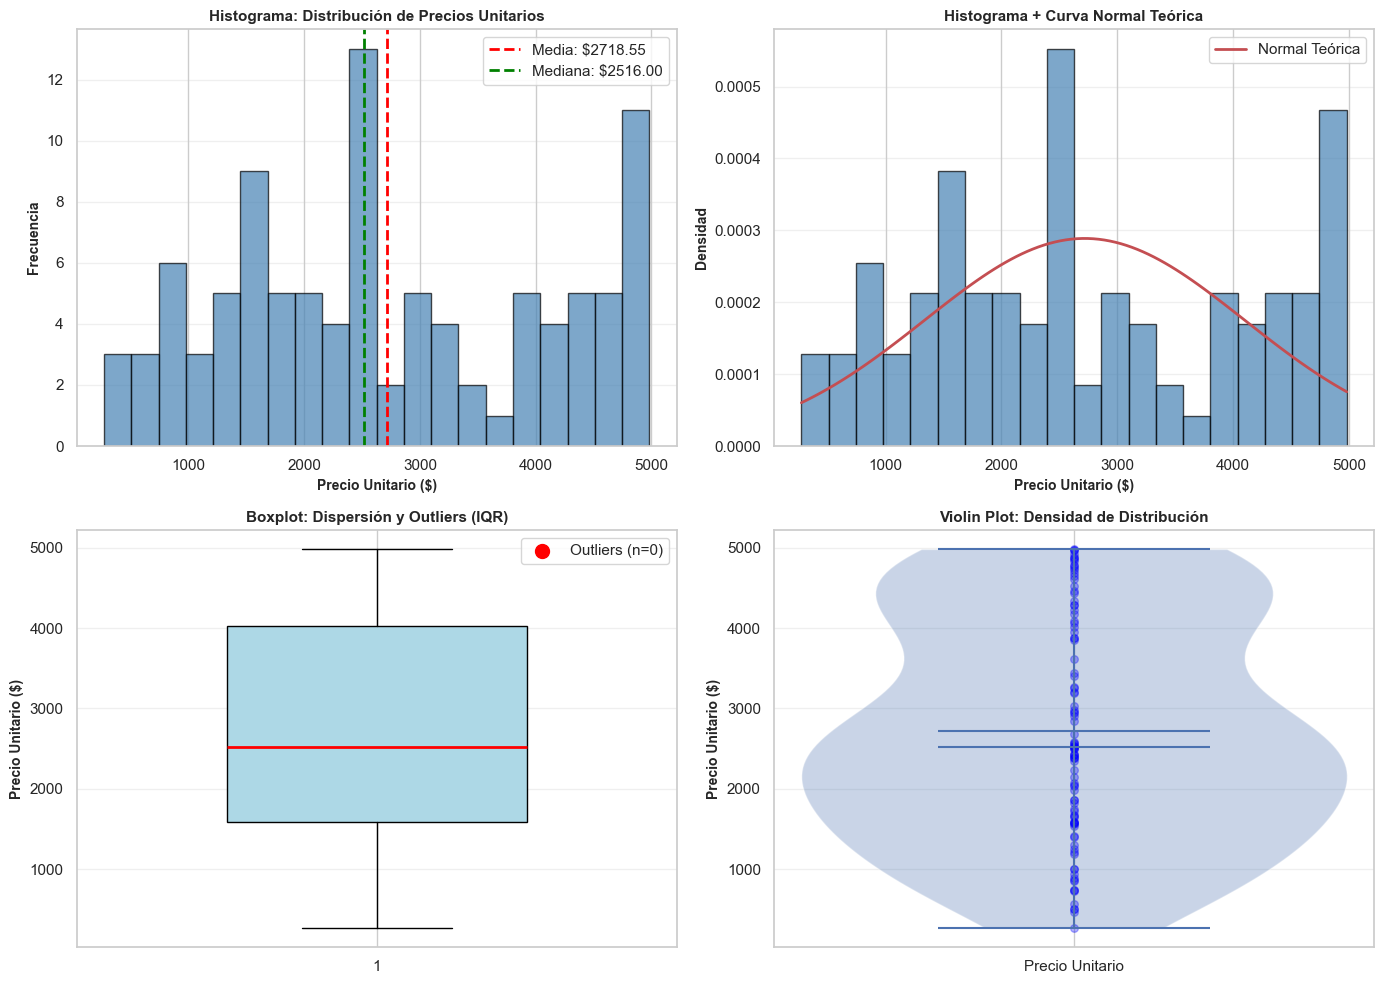


✅ Gráficos univariados completados.


In [57]:
# Visualización 1: Histograma con distribución normal superpuesta
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1.1: Histograma simple
ax1 = axes[0, 0]
ax1.hist(datos, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: ${media:.2f}')
ax1.axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: ${mediana:.2f}')
ax1.set_xlabel('Precio Unitario ($)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Frecuencia', fontsize=10, fontweight='bold')
ax1.set_title('Histograma: Distribución de Precios Unitarios', fontsize=11, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# Subplot 1.2: Histograma con curva de distribución normal
ax2 = axes[0, 1]
n, bins, patches = ax2.hist(datos, bins=20, edgecolor='black', alpha=0.7, color='steelblue', density=True)
# Superponer distribución normal teórica
x_range = np.linspace(datos.min(), datos.max(), 100)
normal_dist = stats.norm.pdf(x_range, media, std)
ax2.plot(x_range, normal_dist, 'r-', linewidth=2, label='Normal Teórica')
ax2.set_xlabel('Precio Unitario ($)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Densidad', fontsize=10, fontweight='bold')
ax2.set_title('Histograma + Curva Normal Teórica', fontsize=11, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.3)

# Subplot 1.3: Boxplot
ax3 = axes[1, 0]
bp = ax3.boxplot(datos, vert=True, patch_artist=True, widths=0.5,
                  medianprops=dict(color='red', linewidth=2),
                  boxprops=dict(facecolor='lightblue', color='black'),
                  whiskerprops=dict(color='black'),
                  capprops=dict(color='black'))
ax3.scatter([1]*len(outliers_iqr), outliers_iqr, color='red', s=100, marker='o', 
           label=f'Outliers (n={len(outliers_iqr)})', zorder=5)
ax3.set_ylabel('Precio Unitario ($)', fontsize=10, fontweight='bold')
ax3.set_title('Boxplot: Dispersión y Outliers (IQR)', fontsize=11, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(axis='y', alpha=0.3)

# Subplot 1.4: Violin plot (densidad)
ax4 = axes[1, 1]
parts = ax4.violinplot([datos], positions=[1], widths=0.7, showmeans=True, showmedians=True)
ax4.scatter([1]*len(datos), datos, alpha=0.3, s=30, color='blue', label='Observaciones')
ax4.set_ylabel('Precio Unitario ($)', fontsize=10, fontweight='bold')
ax4.set_title('Violin Plot: Densidad de Distribución', fontsize=11, fontweight='bold')
ax4.set_xticks([1])
ax4.set_xticklabels(['Precio Unitario'])
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n✅ Gráficos univariados completados.')

### 📈 Visualización Bivariada - Precio Unitario por Categoría

**Tipo de gráfico:** Boxplot por grupo, Violin Plot por grupo, Estadísticas de resumen  
**Cómo:** Segmentamos la variable precio_unitario según categoría de producto y comparamos distribuciones lado a lado  
**Por qué:** Permite identificar diferencias de precios entre categorías, variabilidad intra-grupo y si existe confundimiento de precio por categoría


ESTADÍSTICAS POR CATEGORÍA: PRECIO_UNITARIO

📂 Categoría: ALIMENTOS
   Número de productos: 95
   Media:               $  2,718.47
   Mediana:             $  2,520.00
   Desv. Estándar:      $  1,394.21
   Rango:               [$   272.00 - $ 4,982.00]
   IQR:                 [$ 1,582.50 - $ 4,038.00]

📂 Categoría: LIMPIEZA
   Número de productos: 5
   Media:               $  2,720.00
   Mediana:             $  2,430.00
   Desv. Estándar:      $  1,251.36
   Rango:               [$ 1,592.00 - $ 4,854.00]
   IQR:                 [$ 2,142.00 - $ 2,582.00]
   Outliers (IQR):      1 producto(s)


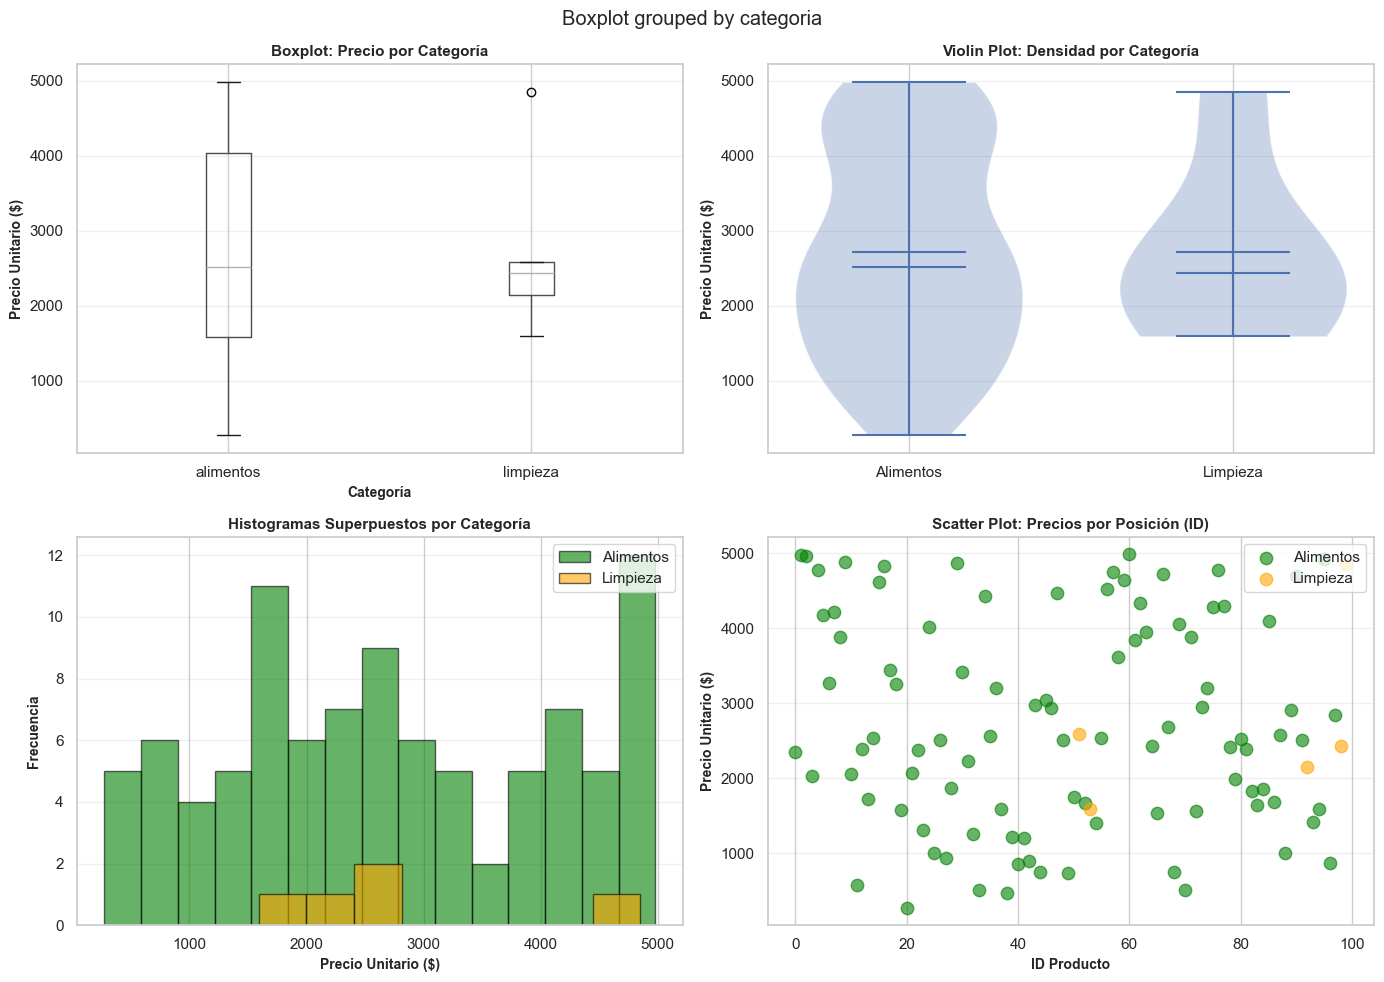


✅ Gráficos bivariados completados.


In [58]:
# Estadísticas por categoría
print('\n' + '='*100)
print('ESTADÍSTICAS POR CATEGORÍA: PRECIO_UNITARIO')
print('='*100)

categorias = df_productos_c['categoria'].unique()
stats_by_cat = []

for cat in sorted(categorias):
    datos_cat = df_productos_c[df_productos_c['categoria'] == cat]['precio_unitario']
    
    stats_dict = {
        'Categoría': cat,
        'N': len(datos_cat),
        'Media': datos_cat.mean(),
        'Mediana': datos_cat.median(),
        'Std': datos_cat.std(),
        'Min': datos_cat.min(),
        'P25': datos_cat.quantile(0.25),
        'P75': datos_cat.quantile(0.75),
        'Max': datos_cat.max()
    }
    stats_by_cat.append(stats_dict)
    
    print(f'\n📂 Categoría: {cat.upper()}')
    print(f'   Número de productos: {len(datos_cat)}')
    print(f'   Media:               ${datos_cat.mean():>10,.2f}')
    print(f'   Mediana:             ${datos_cat.median():>10,.2f}')
    print(f'   Desv. Estándar:      ${datos_cat.std():>10,.2f}')
    print(f'   Rango:               [${datos_cat.min():>9,.2f} - ${datos_cat.max():>9,.2f}]')
    print(f'   IQR:                 [${datos_cat.quantile(0.25):>9,.2f} - ${datos_cat.quantile(0.75):>9,.2f}]')
    
    # Outliers por categoría
    q1_cat = datos_cat.quantile(0.25)
    q3_cat = datos_cat.quantile(0.75)
    iqr_cat = q3_cat - q1_cat
    outliers_cat = datos_cat[(datos_cat < q1_cat - 1.5*iqr_cat) | (datos_cat > q3_cat + 1.5*iqr_cat)]
    if len(outliers_cat) > 0:
        print(f'   Outliers (IQR):      {len(outliers_cat)} producto(s)')

# Visualización 2: Comparación por categoría
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 2.1: Boxplot por categoría
ax1 = axes[0, 0]
df_productos_c.boxplot(column='precio_unitario', by='categoria', ax=ax1)
ax1.set_xlabel('Categoría', fontsize=10, fontweight='bold')
ax1.set_ylabel('Precio Unitario ($)', fontsize=10, fontweight='bold')
ax1.set_title('Boxplot: Precio por Categoría', fontsize=11, fontweight='bold')
plt.sca(ax1)
plt.xticks(rotation=0)
ax1.grid(axis='y', alpha=0.3)

# Subplot 2.2: Violin plot por categoría
ax2 = axes[0, 1]
data_alimentos = df_productos_c[df_productos_c['categoria'] == 'alimentos']['precio_unitario']
data_limpieza = df_productos_c[df_productos_c['categoria'] == 'limpieza']['precio_unitario']
parts = ax2.violinplot([data_alimentos, data_limpieza], positions=[1, 2], widths=0.7, 
                        showmeans=True, showmedians=True)
ax2.set_ylabel('Precio Unitario ($)', fontsize=10, fontweight='bold')
ax2.set_title('Violin Plot: Densidad por Categoría', fontsize=11, fontweight='bold')
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Alimentos', 'Limpieza'])
ax2.grid(axis='y', alpha=0.3)

# Subplot 2.3: Histogramas superpuestos
ax3 = axes[1, 0]
ax3.hist(data_alimentos, bins=15, alpha=0.6, label='Alimentos', edgecolor='black', color='green')
ax3.hist(data_limpieza, bins=8, alpha=0.6, label='Limpieza', edgecolor='black', color='orange')
ax3.set_xlabel('Precio Unitario ($)', fontsize=10, fontweight='bold')
ax3.set_ylabel('Frecuencia', fontsize=10, fontweight='bold')
ax3.set_title('Histogramas Superpuestos por Categoría', fontsize=11, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(axis='y', alpha=0.3)

# Subplot 2.4: Scatter plot con color por categoría
ax4 = axes[1, 1]
for cat in ['alimentos', 'limpieza']:
    mask = df_productos_c['categoria'] == cat
    color = 'green' if cat == 'alimentos' else 'orange'
    ax4.scatter(df_productos_c[mask].index, df_productos_c[mask]['precio_unitario'], 
               label=cat.capitalize(), alpha=0.6, s=80, color=color)
ax4.set_xlabel('ID Producto', fontsize=10, fontweight='bold')
ax4.set_ylabel('Precio Unitario ($)', fontsize=10, fontweight='bold')
ax4.set_title('Scatter Plot: Precios por Posición (ID)', fontsize=11, fontweight='bold')
ax4.legend(loc='upper right')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n✅ Gráficos bivariados completados.')

### 📈 Análisis Composicional - Distribución de Productos por Categoría

**Tipo de gráfico:** Pie Chart, Bar Chart, Heatmap  
**Cómo:** Representan las proporciones y conteos de productos por cada categoría mediante gráficos de sectores, barras y matrices  
**Por qué:** Permiten visualizar rápidamente el balance/desbalance del catálogo y la contribución de cada categoría al total


ANÁLISIS COMPOSICIONAL: DISTRIBUCIÓN POR CATEGORÍA

📊 DISTRIBUCIÓN DE PRODUCTOS:
   Alimentos   :  95 productos ( 95.0%)
   Limpieza    :   5 productos (  5.0%)

   Total:           100 productos (100.0%)


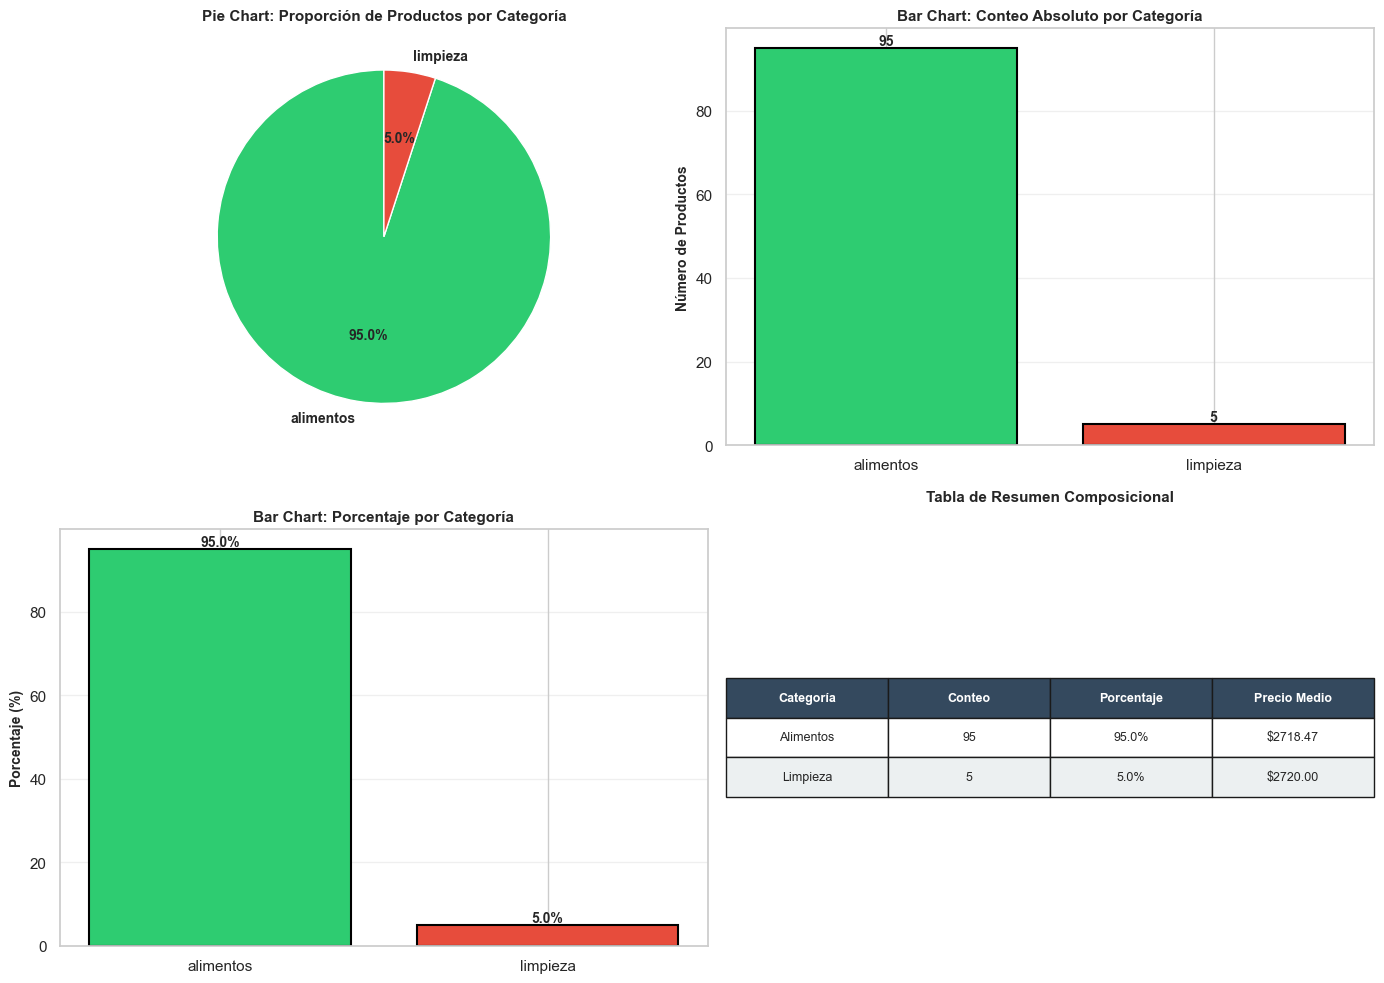


✅ Gráficos composicionales completados.


In [59]:
# Conteo y proporciones por categoría
print('\n' + '='*100)
print('ANÁLISIS COMPOSICIONAL: DISTRIBUCIÓN POR CATEGORÍA')
print('='*100)

conteo_cat = df_productos_c['categoria'].value_counts()
proporcion_cat = df_productos_c['categoria'].value_counts(normalize=True) * 100

print(f'\n📊 DISTRIBUCIÓN DE PRODUCTOS:')
for cat in sorted(df_productos_c['categoria'].unique()):
    count = conteo_cat[cat]
    pct = proporcion_cat[cat]
    print(f'   {cat.capitalize():12s}: {count:>3d} productos ({pct:>5.1f}%)')

print(f'\n   Total:           {len(df_productos_c):>3d} productos (100.0%)')

# Visualización 3: Composición
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 3.1: Pie chart
ax1 = axes[0, 0]
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax1.pie(conteo_cat, labels=conteo_cat.index, autopct='%1.1f%%',
                                     colors=colors, startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
ax1.set_title('Pie Chart: Proporción de Productos por Categoría', fontsize=11, fontweight='bold')

# Subplot 3.2: Bar chart de conteos
ax2 = axes[0, 1]
bars = ax2.bar(conteo_cat.index, conteo_cat.values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Número de Productos', fontsize=10, fontweight='bold')
ax2.set_title('Bar Chart: Conteo Absoluto por Categoría', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
# Agregar valores sobre las barras
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Subplot 3.3: Bar chart de porcentajes
ax3 = axes[1, 0]
bars = ax3.bar(proporcion_cat.index, proporcion_cat.values, color=colors, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Porcentaje (%)', fontsize=10, fontweight='bold')
ax3.set_title('Bar Chart: Porcentaje por Categoría', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
# Agregar valores sobre las barras
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Subplot 3.4: Tabla de resumen
ax4 = axes[1, 1]
ax4.axis('off')
tabla_data = []
tabla_data.append(['Categoría', 'Conteo', 'Porcentaje', 'Precio Medio'])
for cat in sorted(df_productos_c['categoria'].unique()):
    count = conteo_cat[cat]
    pct = proporcion_cat[cat]
    mean_price = df_productos_c[df_productos_c['categoria'] == cat]['precio_unitario'].mean()
    tabla_data.append([cat.capitalize(), f'{count}', f'{pct:.1f}%', f'${mean_price:.2f}'])

tabla = ax4.table(cellText=tabla_data, cellLoc='center', loc='center',
                 colWidths=[0.25, 0.25, 0.25, 0.25])
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1, 2)

# Formatear header
for i in range(4):
    tabla[(0, i)].set_facecolor('#34495e')
    tabla[(0, i)].set_text_props(weight='bold', color='white')

# Formatear filas de datos
for i in range(1, len(tabla_data)):
    for j in range(4):
        if i % 2 == 0:
            tabla[(i, j)].set_facecolor('#ecf0f1')
        else:
            tabla[(i, j)].set_facecolor('#ffffff')

ax4.set_title('Tabla de Resumen Composicional', fontsize=11, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print('\n✅ Gráficos composicionales completados.')

### 📈 Interpretaciones y Hallazgos Clave del EDA

In [60]:
print('\n' + '='*100)
print('RESUMEN E INTERPRETACIONES: ANÁLISIS EXPLORATORIO COMPLETO')
print('='*100)

print('\n📌 HALLAZGO 1: DISTRIBUCIÓN DE PRECIOS')
if abs(skewness) < 0.5:
    asimetria_txt = "SIMÉTRICA (distribución equilibrada, sin sesgo pronunciado)"
elif skewness > 0:
    asimetria_txt = "ASIMÉTRICA POSITIVA (cola hacia la derecha, más productos económicos)"
else:
    asimetria_txt = "ASIMÉTRICA NEGATIVA (cola hacia la izquierda, más productos caros)"

print(f"   • La distribución de precios es: {asimetria_txt}")
print(f"   • Skewness={skewness:.4f} | Kurtosis={kurtosis_val:.4f}")
print(f"   • Interpretación: Los precios tienden a concentrarse alrededor de la mediana (${mediana:,.2f})")

print('\n📌 HALLAZGO 2: VARIABILIDAD DE PRECIOS')
if cv < 15:
    variabilidad = "BAJA (productos con precios muy similares)"
elif cv < 30:
    variabilidad = "MODERADA (cierta dispersión pero controlada)"
else:
    variabilidad = "ALTA (gran rango de precios, portfolio diverso)"

print(f"   • Coeficiente de Variación: {cv:.2f}% → {variabilidad}")
print(f"   • Desv. Estándar: ${std:,.2f} | Media: ${media:,.2f}")
print(f"   • Rango: ${rango:,.2f} (Min=${datos.min():,.2f}, Max=${datos.max():,.2f})")

print('\n📌 HALLAZGO 3: VALORES ATÍPICOS (OUTLIERS)')
outliers_total = len(set(outliers_iqr).union(set(outliers_zscore)))
print(f"   • Outliers detectados: {outliers_total} productos ({outliers_total/len(df_productos_c)*100:.1f}%)")
print(f"   • Por método IQR: {len(outliers_iqr)} productos")
print(f"   • Por Z-score modificado: {len(outliers_zscore)} productos")
if outliers_total > 0:
    print(f"   • Acción recomendada: Revisar estos productos para análisis de precios especiales")

print('\n📌 HALLAZGO 4: DIFERENCIAS POR CATEGORÍA')
cat_stats = df_productos_c.groupby('categoria')['precio_unitario'].agg(['count', 'mean', 'std', 'min', 'max'])
for cat in sorted(df_productos_c['categoria'].unique()):
    n = len(df_productos_c[df_productos_c['categoria'] == cat])
    mean_cat = df_productos_c[df_productos_c['categoria'] == cat]['precio_unitario'].mean()
    std_cat = df_productos_c[df_productos_c['categoria'] == cat]['precio_unitario'].std()
    print(f"   • {cat.capitalize():12s}: μ=${mean_cat:>9,.2f}, σ=${std_cat:>9,.2f}, n={n:>3d}")

precio_alimentos = df_productos_c[df_productos_c['categoria'] == 'alimentos']['precio_unitario'].mean()
precio_limpieza = df_productos_c[df_productos_c['categoria'] == 'limpieza']['precio_unitario'].mean()
ratio = precio_alimentos / precio_limpieza if precio_limpieza > 0 else 0
print(f"   • Ratio (Alimentos/Limpieza): {ratio:.2f}x")

print('\n📌 HALLAZGO 5: CONCENTRACIÓN DE PRECIOS')
p10_val = datos.quantile(0.10)
p90_val = datos.quantile(0.90)
percent_80_central = ((datos >= p10_val) & (datos <= p90_val)).sum() / len(datos) * 100
print(f"   • 80% de productos se concentran entre: ${p10_val:,.2f} y ${p90_val:,.2f}")
print(f"   • Observaciones en rango central [P10-P90]: {percent_80_central:.1f}%")

print('\n' + '='*100)
print('✅ ANÁLISIS EXPLORATORIO COMPLETADO')
print('='*100)
print('\n📋 RECOMENDACIONES PARA SIGUIENTE FASE:')
print('   1. Validar outliers identificados (probablemente productos premium)')
print('   2. Considerar análisis de ventas por categoría (si datos están disponibles)')
print('   3. Evaluar elasticidad precio-demanda por categoría')
print('   4. Revisar estrategia de pricing para categoría de Limpieza (menor número de SKUs)')
print('\n')


RESUMEN E INTERPRETACIONES: ANÁLISIS EXPLORATORIO COMPLETO

📌 HALLAZGO 1: DISTRIBUCIÓN DE PRECIOS
   • La distribución de precios es: SIMÉTRICA (distribución equilibrada, sin sesgo pronunciado)
   • Skewness=0.1495 | Kurtosis=-1.1672
   • Interpretación: Los precios tienden a concentrarse alrededor de la mediana ($2,516.00)

📌 HALLAZGO 2: VARIABILIDAD DE PRECIOS
   • Coeficiente de Variación: 50.82% → ALTA (gran rango de precios, portfolio diverso)
   • Desv. Estándar: $1,381.64 | Media: $2,718.55
   • Rango: $4,710.00 (Min=$272.00, Max=$4,982.00)

📌 HALLAZGO 3: VALORES ATÍPICOS (OUTLIERS)
   • Outliers detectados: 0 productos (0.0%)
   • Por método IQR: 0 productos
   • Por Z-score modificado: 0 productos

📌 HALLAZGO 4: DIFERENCIAS POR CATEGORÍA
   • Alimentos   : μ=$ 2,718.47, σ=$ 1,394.21, n= 95
   • Limpieza    : μ=$ 2,720.00, σ=$ 1,251.36, n=  5
   • Ratio (Alimentos/Limpieza): 1.00x

📌 HALLAZGO 5: CONCENTRACIÓN DE PRECIOS
   • 80% de productos se concentran entre: $885.50 y $4,7

C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\2734838844.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_stats = df_productos_c.groupby('categoria')['precio_unitario'].agg(['count', 'mean', 'std', 'min', 'max'])


### 🔍 2.4 Carga e Inspección - Tabla VENTAS

Importación y verificación del dataframe `df_ventas_c` que contiene las transacciones principales con información de clientes, fechas y medios de pago.

#### Descripción - VENTAS

La tabla `VENTAS` representa el **nivel de transacción** del modelo de datos:

**Campos clave**:
- **Identificadores**: `id_venta` (PK), `id_cliente` (FK)
- **Temporales**: `fecha`
- **Medio de pago**: `medio_pago` (categórica: efectivo, QR, tarjeta, transferencia)

**Nota sobre medios de pago**: En el archivo original existe la columna categórica `medio_pago`. Posteriormente, mediante One-Hot Encoding, se generan 4 columnas binarias (`medio_pago_efectivo`, `medio_pago_qr`, `medio_pago_tarjeta`, `medio_pago_transferencia`) para uso en modelos de Machine Learning.

**Relaciones**:
- `id_cliente` → Enlace con tabla CLIENTES (muchas ventas por cliente)
- `id_venta` → Clave foránea en DETALLE_VENTAS (una venta, muchos detalles)

### ⚙️ 3.4 Limpieza y Transformación - VENTAS

**Operaciones aplicadas**:

1. **Transformaciones temporales**:
   - Conversión de `fecha` a tipo `datetime64[ns]` con formato día-mes-año

2. **Normalización de texto**:
   - Estandarización de `nombre_cliente` (formato Título, eliminación de espacios)
   - Normalización de `email` (minúsculas, eliminación de espacios)

3. **Optimización categórica**:
   - Conversión de `medio_pago` a tipo `category` para eficiencia de memoria

4. **Normalización estructural** (se ejecuta posteriormente):
   - Eliminación de columnas redundantes `nombre_cliente`, `email` (ya están en tabla CLIENTES)
   - Aplicación de One-Hot Encoding a `medio_pago` para generar variables binarias

#### Preparación para Creación de df_ventas_True

El siguiente paso será crear `df_ventas_True` mediante:
1. Eliminación de columnas redundantes (`nombre_cliente`, `email`)
2. Aplicación de One-Hot Encoding a `medio_pago`
3. Validación final de integridad antes del merge

**Objetivo**: Obtener un dataset optimizado y normalizado listo para la consolidación con las demás tablas del proyecto.

#### Librerías adicionales

Carga de librerías complementarias para análisis de VENTAS.

In [61]:
# Librerías ya importadas en celda inicial (VSC-b61da4ee)
# Este espacio se mantiene para compatibilidad pero no requiere re-importación


### 4.2 Carga e Inspección - Tabla VENTAS

En esta sección se realiza la **importación del dataset principal** utilizando una **ruta relativa** y la librería `pathlib.Path`. Esto garantiza que el código sea **portable** y funcione correctamente en diferentes sistemas operativos.

> 📂 **Ruta del archivo:**   
> El archivo se accede mediante la construcción **`Path('db') / 'ventas.xlsx'`**.

La lectura del archivo se efectúa mediante la función `pd.read_excel()` de la biblioteca **pandas**, creando el dataframe inicial `df_ventas_c`.

In [62]:
# Lee el libro de ventas con Path para mantener rutas relativas entre entornos
path_dataset = Path('db') / 'ventas.xlsx'
df_ventas_c = pd.read_excel(path_dataset)

# Genera una vista inicial para auditar columnas y tipos cargados
df_ventas_c.head()


,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago
0,1,2024-06-19,62,Guadalupe Romero,guadalupe.romero@mail.com,tarjeta
1,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr
2,3,2024-01-13,20,Tomas Acosta,tomas.acosta@mail.com,tarjeta
3,4,2024-02-27,36,Martina Molina,martina.molina@mail.com,transferencia
4,5,2024-06-11,56,Bruno Diaz,bruno.diaz@mail.com,tarjeta


### 4.3 Inspección Inicial - VENTAS

En esta etapa se realiza una **inspección exploratoria básica** del DataFrame `df_ventas_c` recién cargado, con el objetivo de verificar que los datos se hayan importado correctamente y posean la estructura esperada.

In [63]:
# Revisa las primeras 8 filas para detectar inconsistencias tempranas
df_ventas_c.head(8)


,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago
0,1,2024-06-19,62,Guadalupe Romero,guadalupe.romero@mail.com,tarjeta
1,2,2024-03-17,49,Olivia Gomez,olivia.gomez@mail.com,qr
2,3,2024-01-13,20,Tomas Acosta,tomas.acosta@mail.com,tarjeta
3,4,2024-02-27,36,Martina Molina,martina.molina@mail.com,transferencia
4,5,2024-06-11,56,Bruno Diaz,bruno.diaz@mail.com,tarjeta
5,6,2024-05-05,91,Uma Sanchez,uma.sanchez@mail.com,transferencia
6,7,2024-05-06,92,Mariana Rodriguez,mariana.rodriguez@mail.com,efectivo
7,8,2024-01-06,66,Tomas Herrera,tomas.herrera@mail.com,transferencia


In [64]:
# Contrasta las últimas 4 filas para identificar valores atípicos al final del dataset
df_ventas_c.tail(4)


,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago
116,117,2024-03-14,72,Camila Rodriguez,camila.rodriguez@mail.com,tarjeta
117,118,2024-02-09,84,Pablo Sanchez,pablo.sanchez@mail.com,efectivo
118,119,2024-02-07,51,Agustina Gomez,agustina.gomez@mail.com,qr
119,120,2024-04-21,72,Camila Rodriguez,camila.rodriguez@mail.com,tarjeta


### 4.4 Exploración de Tipos de Datos y Valores Nulos - VENTAS

En esta etapa se realiza una **revisión estructural del DataFrame** para confirmar que los tipos de datos asignados a cada variable durante la lectura con `pd.read_excel()` sean correctos y coherentes con la naturaleza de la información.

Además, se evalúa la **presencia de valores nulos o faltantes**, los cuales podrían requerir tratamiento posterior durante el proceso de limpieza y estandarización.

### 🧩 Procedimiento

In [65]:
# Inspecciona estructura, tipos dtypes y memoria del dataframe importado
df_ventas_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_venta        120 non-null    int64         
 1   fecha           120 non-null    datetime64[ns]
 2   id_cliente      120 non-null    int64         
 3   nombre_cliente  120 non-null    object        
 4   email           120 non-null    object        
 5   medio_pago      120 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 5.8+ KB


> 💡 **Conclusión:**  
> A partir de la ejecución del comando `df_ventas_c.info()`, se observa que la base de datos cuenta con **120 registros** distribuidos en **6 columnas**.  
> Cada columna presenta **120 valores no nulos**, lo que indica que **no existen datos faltantes (NaN)** en el dataset.  
> 
> **Tipos de datos identificados**:
> - Identificadores: `int64` (correctos)
> - Texto: `object` para `nombre_cliente`, `email`, `medio_pago` (se normalizarán en el siguiente paso)
> - Temporal: `datetime64[ns]` para `fecha` (ya convertida correctamente por pandas)
> 
> La estructura inicial refleja una **lectura exitosa del archivo Excel**, lista para iniciar el proceso de normalización de texto y optimización de tipos categóricos.

### 🕵️‍♂️ Detección de Valores Nulos

Se analiza la presencia de valores faltantes para priorizar acciones de limpieza y asegurar la consistencia del dataset.

In [66]:
# Visualiza la máscara booleana donde True marca valores faltantes por celda
df_ventas_c.isnull()

,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
115,False,False,False,False,False,False
116,False,False,False,False,False,False
117,False,False,False,False,False,False
118,False,False,False,False,False,False


In [67]:
# Resume la cantidad de nulos por columna para priorizar limpieza
df_ventas_c.isnull().sum()


id_venta          0
fecha             0
id_cliente        0
nombre_cliente    0
email             0
medio_pago        0
dtype: int64

#### 🔍 Control de Calidad Inicial (QA): Resumen Detallado de `df_ventas_c`

Este análisis exhaustivo es el primer paso del Control de Calidad (QA) previo a la limpieza de datos. 

**Objetivo**: Obtener un perfil completo de cada variable antes de cualquier transformación, incluyendo:
- Estadísticos descriptivos para variables numéricas (media, mediana, desviación, asimetría, curtosis)
- Distribución de frecuencias para variables categóricas
- Detección de outliers mediante IQR
- Análisis de valores únicos y modas

Este análisis proporciona la base para tomar decisiones informadas sobre las transformaciones necesarias.

In [68]:
# Resumen detallado de df_ventas_c (incluye métricas numéricas y categóricas)
import pandas as pd
import numpy as np

df = df_ventas_c.copy()
total_rows = len(df)
print('='*80)
print('=== 📊 RESUMEN DETALLADO Y DE CALIDAD DE DATOS (DataFrame: df_ventas_c) ===')
print(f'Tamaño del dataframe: {total_rows:,} filas x {df.shape[1]:,} columnas')
print('Memoria (aprox):', f"{df.memory_usage(deep=True).sum()/1024**2:.2f} MB")
print('='*80)

for col in df.columns:
    s = df[col]
    
    # --- Encabezado General ---
    n = len(s)
    n_missing = s.isna().sum()
    pct_missing = (n_missing / n * 100) if n > 0 else 0
    n_unique = s.nunique(dropna=True)

    print(f"\n[ Columna: {col} | dtype: {s.dtype} ]")
    print(f"  > Conteo: {n:,} | Missing: {n_missing:,} ({pct_missing:.2f}%) | Únicos: {n_unique:,}")
    print('-' * 40)

    # --- Lógica para Numéricas ---
    if pd.api.types.is_numeric_dtype(s):
        s_num = pd.to_numeric(s, errors='coerce').dropna()
        if s_num.empty:
            print('  (No hay valores numéricos tras coerción)')
            continue
            
        # 1. Calcular todas las métricas
        p = s_num.quantile([0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).to_dict()
        mean = s_num.mean()
        std = s_num.std()
        
        q1 = p.get(0.25, np.nan)
        q3 = p.get(0.75, np.nan)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        outliers = s_num[(s_num < lower) | (s_num > upper)]
        n_out = len(outliers)
        pct_out = n_out / len(s_num) * 100 if len(s_num) > 0 else 0

        # 2. Imprimir en formato tabular (mejor alineación)
        print('  Métrica           | Valor')
        print('  ------------------|----------------------')
        print(f"  Min / Max         | {s_num.min():,.2f} / {s_num.max():,.2f}")
        print(f"  Media (Mean)      | {mean:,.2f}")
        print(f"  Mediana (Q2)      | {p.get(0.5, np.nan):,.2f}")
        print(f"  Desv. Est. (Std)  | {std:,.2f}")
        print(f"  Asimetría (Skew)  | {s_num.skew():.3f}")
        print(f"  Curtosis          | {s_num.kurtosis():.3f}")
        print('  ------------------|----------------------')
        print(f"  Q1 / Q3 (IQR)     | {q1:,.2f} / {q3:,.2f} ({iqr:,.2f})")
        print(f"  Límites IQR       | [{lower:,.2f}, {upper:,.2f}]")
        print(f"  Outliers (IQR)    | {n_out} ({pct_out:.2f}%)")

        if n_out > 0:
            top_out = outliers.sort_values(ascending=False).head(5)
            print('\n  Top 5 Outliers (Mayores):')
            for v in top_out:
                print(f"    - {v:,.2f}")

    # --- Lógica para Categóricas / Object ---
    else:
        print('  --- Estadísticas Categóricas / Texto ---')
        nonnull = s.dropna()
        if nonnull.empty:
            print('  (Todos los valores son NaN)')
        else:
            try:
                top = nonnull.mode().iloc[0]
                freq = nonnull.value_counts(dropna=True).iloc[0]
                pct_top = freq / len(nonnull) * 100 if len(nonnull) > 0 else 0
                print(f"  Moda (Top Value): {top} \n  Frecuencia: {freq:,} ({pct_top:.2f}%)")
            except Exception as e:
                print('  No se pudo calcular moda/frecuencia:', e)
            
            if n_unique <= 15 and n_unique > 1: # Aumenté a 15 para mejor visualización
                print('\n  Top Distribución de Valores:')
                vc = nonnull.value_counts(dropna=True).head(5)
                for v, cnt in vc.items():
                    print(f"    - {v}: {cnt:,}")
            elif n_unique > 15:
                print(f"  Distintos valores >15; Ejemplos: {list(nonnull.unique()[:5])}")

print('\n' + '='*80)
print('\nTabla resumen (pandas .describe(include="all") para referencia rápida):')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df.describe(include='all'))

=== 📊 RESUMEN DETALLADO Y DE CALIDAD DE DATOS (DataFrame: df_ventas_c) ===
Tamaño del dataframe: 120 filas x 6 columnas
Memoria (aprox): 0.02 MB

[ Columna: id_venta | dtype: int64 ]
  > Conteo: 120 | Missing: 0 (0.00%) | Únicos: 120
----------------------------------------
  Métrica           | Valor
  ------------------|----------------------
  Min / Max         | 1.00 / 120.00
  Media (Mean)      | 60.50
  Mediana (Q2)      | 60.50
  Desv. Est. (Std)  | 34.79
  Asimetría (Skew)  | 0.000
  Curtosis          | -1.200
  ------------------|----------------------
  Q1 / Q3 (IQR)     | 30.75 / 90.25 (59.50)
  Límites IQR       | [-58.50, 179.50]
  Outliers (IQR)    | 0 (0.00%)

[ Columna: fecha | dtype: datetime64[ns] ]
  > Conteo: 120 | Missing: 0 (0.00%) | Únicos: 93
----------------------------------------
  --- Estadísticas Categóricas / Texto ---
  Moda (Top Value): 2024-01-13 00:00:00 
  Frecuencia: 3 (2.50%)
  Distintos valores >15; Ejemplos: [Timestamp('2024-06-19 00:00:00'), Time

,id_venta,fecha,id_cliente,nombre_cliente,email,medio_pago
count,120.000000,120,120.000000,120,120,120
unique,NaN,NaN,NaN,64,67,4
top,NaN,NaN,NaN,Bruno Diaz,bruno.diaz@mail.com,efectivo
freq,NaN,NaN,NaN,5,5,37
mean,60.500000,2024-03-29 17:36:00,47.291667,NaN,NaN,NaN
min,1.000000,2024-01-02 00:00:00,1.000000,NaN,NaN,NaN
25%,30.750000,2024-02-11 06:00:00,24.500000,NaN,NaN,NaN
50%,60.500000,2024-03-25 00:00:00,48.500000,NaN,NaN,NaN
75%,90.250000,2024-05-19 06:00:00,67.500000,NaN,NaN,NaN
max,120.000000,2024-06-28 00:00:00,100.000000,NaN,NaN,NaN


> 💬 **Conclusión sobre codificación categórica**: 
> 
> El número de **valores únicos (clases)** en la variable categórica **`medio_pago`** es **4** (efectivo, QR, tarjeta, transferencia).
> 
> Dado que se identificaron cuatro clases distintas dentro de la categoría `medio_pago`, esta característica es **apta para ser codificada** mediante la técnica de **One-Hot Encoding**. Este método de codificación resultará en la creación de **cuatro nuevas variables binarias (0 o 1)** que indican la presencia/ausencia de cada medio de pago, optimizando el dataset para uso en modelos de Machine Learning.
> 
> **Próximo paso**: Aplicación de One-Hot Encoding para generar las columnas `medio_pago_efectivo`, `medio_pago_qr`, `medio_pago_tarjeta`, `medio_pago_transferencia`.

## ⚙️ Normalización y Corrección de Tipos de Datos

Antes de realizar la normalización de la base de datos, es necesario **verificar y corregir los tipos de datos** asignados a las variables y estandarizar los campos de texto.

**Transformaciones aplicadas**:

1. **Conversión temporal**: `fecha` convertida a formato `datetime64[ns]` con interpretación día-mes-año (formato argentino), marcando entradas inválidas como `NaT`.

2. **Normalización de texto**: 
   - `nombre_cliente`: formato Título, eliminación de espacios
   - `email`: minúsculas, eliminación de espacios

3. **Optimización categórica**: `medio_pago` convertido a tipo `category` para mejorar eficiencia de memoria.

### 🧩 Fundamento

Estas transformaciones garantizan:
- ✅ **Precisión temporal** para análisis de series de tiempo y segmentación por períodos
- ✅ **Consistencia de datos** en campos de texto para joins y agrupaciones
- ✅ **Eficiencia de memoria** mediante tipos optimizados

Este paso forma parte del proceso de **limpieza estructural** dentro de la metodología ETL (Extract, Transform, Load).

In [69]:
# Convierte fecha al formato datetime (día-mes-año) y marca entradas inválidas como NaT
df_ventas_c['fecha'] = pd.to_datetime(df_ventas_c['fecha'], dayfirst=True, errors='coerce')

# Normaliza campos de texto: elimina espacios, ajusta capitalización y homogeniza correos
df_ventas_c['nombre_cliente'] = df_ventas_c['nombre_cliente'].str.strip().str.title()
df_ventas_c['email'] = df_ventas_c['email'].str.lower().str.strip()

# Define medio_pago como categoría para optimizar memoria y habilitar análisis estadístico
df_ventas_c['medio_pago'] = df_ventas_c['medio_pago'].astype('category')


#### 🕵️‍♂️ Verificación de Transformaciones

Se valida que los cambios aplicados hayan surtido efecto tanto en los tipos de datos como en los valores muestreados.

In [70]:
# Verifica los tipos de datos de las columnas normalizadas tras la conversión
df_ventas_c[["fecha", "nombre_cliente", "email", "medio_pago"]].dtypes

fecha             datetime64[ns]
nombre_cliente            object
email                     object
medio_pago              category
dtype: object

In [71]:
# Realiza muestreo de las columnas transformadas para comprobar resultados
df_ventas_c[["fecha", "nombre_cliente", "email", "medio_pago"]].head()

,fecha,nombre_cliente,email,medio_pago
0,2024-06-19,Guadalupe Romero,guadalupe.romero@mail.com,tarjeta
1,2024-03-17,Olivia Gomez,olivia.gomez@mail.com,qr
2,2024-01-13,Tomas Acosta,tomas.acosta@mail.com,tarjeta
3,2024-02-27,Martina Molina,martina.molina@mail.com,transferencia
4,2024-06-11,Bruno Diaz,bruno.diaz@mail.com,tarjeta


#### 🕵️‍♂️ Control de Calidad: Duplicados

Se evalúa la unicidad de registros, especialmente en la columna `id_venta`, que actúa como identificador clave.

In [72]:
# Evalúa duplicados globales y por id_venta para validar la unicidad clave de ventas
cantidad_duplicados = df_ventas_c.duplicated().sum()
duplicados_id_venta = df_ventas_c['id_venta'].duplicated().sum()

print()
print('--- Registros Duplicados ---')
if cantidad_duplicados > 0:
    print(f'Se encontraron {cantidad_duplicados} filas duplicadas.')
else:
    print('No se encontraron filas duplicadas.')

if duplicados_id_venta > 0:
    print(f'Alerta: se detectaron {duplicados_id_venta} valores repetidos en id_venta (posible clave primaria).')
else:
    print('id_venta es único en df_ventas_c.')



--- Registros Duplicados ---
No se encontraron filas duplicadas.
id_venta es único en df_ventas_c.


#### ✅ Resultado de la Normalización

Luego de la verificación y normalización de tipos de datos, se confirma que todas las variables del dataset `df_ventas_c` presentan formatos consistentes y adecuados:

* La columna **`fecha`** se encuentra correctamente definida como **`datetime64[ns]`**, interpretada bajo el formato **día-mes-año (dd-mm-yyyy)** conforme al estándar de la República Argentina.

* Las columnas **`nombre_cliente`** y **`email`** mantienen tipo texto (`object`), con normalización aplicada (formato Título para nombres, minúsculas para emails, eliminación de espacios).

* La variable **`medio_pago`** fue convertida al tipo **categórico (`category`)**, optimizando el uso de memoria y facilitando análisis descriptivos y segmentaciones.

De esta forma, el dataframe `df_ventas_c` queda estructurado de manera coherente, **garantizando integridad, consistencia y eficiencia** para las etapas posteriores de transformación, normalización estructural (eliminación de columnas redundantes) y análisis.

#### 🧩 Normalización Estructural de la Base de Datos

En esta etapa se aplica la **normalización relacional** sobre el DataFrame `df_ventas_c`, creando `df_ventas_True` mediante la eliminación de las columnas **`nombre_cliente`** y **`email`**. 

**Justificación**: Estas columnas contienen información descriptiva redundante respecto a **`id_cliente`** (la clave foránea que referencia a la tabla CLIENTES). En un modelo relacional normalizado, los datos del cliente deben residir únicamente en la tabla CLIENTES, evitando duplicidad y garantizando la Primera Forma Normal (1NF).

**Ventajas**:
- Elimina redundancia de datos
- Facilita el mantenimiento (cambios en datos de cliente se hacen en un solo lugar)
- Reduce tamaño del dataset
- Mejora la integridad referencial

In [73]:
# Crea df_ventas_True excluyendo columnas personales redundantes frente a id_cliente
df_ventas_True = df_ventas_c.drop(columns=['nombre_cliente', 'email'])


In [74]:
# Inspecciona las primeras filas del dataset anonimizado para asegurar integridad
df_ventas_True.head()


,id_venta,fecha,id_cliente,medio_pago
0,1,2024-06-19,62,tarjeta
1,2,2024-03-17,49,qr
2,3,2024-01-13,20,tarjeta
3,4,2024-02-27,36,transferencia
4,5,2024-06-11,56,tarjeta


#### 🔎 Revisión de Integridad de **df_ventas_True**

In [75]:
## Auditoría de integridad: nulos y duplicados en df_ventas_True

# Paso 1: contabiliza nulos por columna para definir tratamientos
print('--- Valores Nulos en df_ventas_True ---')
print(df_ventas_True.isnull().sum())
print('-' * 37)

# Paso 2: identifica y elimina duplicados manteniendo consistencia de id_venta
cantidad_duplicados = df_ventas_True.duplicated().sum()
duplicados_id_venta = df_ventas_True['id_venta'].duplicated().sum()

print()
print('--- Registros Duplicados ---')
if cantidad_duplicados > 0:
    print(f'Se encontraron {cantidad_duplicados} filas duplicadas. Eliminando...')
    df_ventas_True = df_ventas_True.drop_duplicates().copy()
    print('Duplicados eliminados.')
else:
    print('No se encontraron filas duplicadas.')

if duplicados_id_venta > 0:
    print(f'Alerta: se identificaron {duplicados_id_venta} valores repetidos en id_venta dentro de df_ventas_True.')
else:
    print('id_venta es único en df_ventas_True.')


--- Valores Nulos en df_ventas_True ---
id_venta      0
fecha         0
id_cliente    0
medio_pago    0
dtype: int64
-------------------------------------

--- Registros Duplicados ---
No se encontraron filas duplicadas.
id_venta es único en df_ventas_True.


#### 💻 Aplicación de One-Hot Encoding a medio_pago

El **One-Hot Encoding** convierte cada valor categórico único en la columna `medio_pago` en una columna binaria independiente (0 o 1).

**Proceso**:
1. Se crea una instancia de `OneHotEncoder` de scikit-learn
2. Se aplica `fit_transform` sobre la columna `medio_pago` para aprender las categorías y generar las columnas binarias
3. Se crea un DataFrame con las nuevas columnas codificadas (`medio_pago_efectivo`, `medio_pago_qr`, `medio_pago_tarjeta`, `medio_pago_transferencia`)
4. Se concatena el nuevo DataFrame con el original

**Resultado**: Dataset expandido con 4 nuevas columnas binarias listas para modelos de Machine Learning.

In [76]:
from sklearn.preprocessing import OneHotEncoder

# Crear la instancia del encoder
ohe = OneHotEncoder(sparse_output=False)

# Aplicar el encoding solo a la columna 'medio_pago'
ohe_array = ohe.fit_transform(df_ventas_True[['medio_pago']])
#fit aprende las categorías y transform las convierte en vectores de 0 y 1

# Crear un DataFrame con las nuevas columnas codificadas
ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(['medio_pago']))
#agregar el prefijo medio_pago_ a las nuevas columnas y convierte en DataFrame (ohe_df)

# Concatenar el nuevo DataFrame con el original
df_ventas_True = pd.concat([df_ventas_True, ohe_df], axis=1)

In [77]:
ohe_df.head(5)

,medio_pago_efectivo,medio_pago_qr,medio_pago_tarjeta,medio_pago_transferencia
0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0


In [78]:
df_ventas_True.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id_venta                  120 non-null    int64         
 1   fecha                     120 non-null    datetime64[ns]
 2   id_cliente                120 non-null    int64         
 3   medio_pago                120 non-null    category      
 4   medio_pago_efectivo       120 non-null    float64       
 5   medio_pago_qr             120 non-null    float64       
 6   medio_pago_tarjeta        120 non-null    float64       
 7   medio_pago_transferencia  120 non-null    float64       
dtypes: category(1), datetime64[ns](1), float64(4), int64(2)
memory usage: 7.0 KB


> 🔎 La columna **categórica original**, `medio_pago`, debe ser **eliminada** del DataFrame.
> Una vez aplicada la técnica de `One-Hot Encoding`, la columna original se vuelve **redundante** e **inutilizable** para la fase de `modelado`. Su eliminación es un **paso esencial para completar el preprocesamiento**, ya que **asegura que el conjunto de datos solo contenga variables de tipo numérico**, dejándolo apto y optimizado para ser analizado por cualquier algoritmo de Machine Learning.

In [79]:
# Eliminamos las columna 'medio_pago'
df_ventas_True.drop('medio_pago', axis=1, inplace=True)

In [80]:
# Revisión que la columna 'medio_pago' se haya borrado con éxito
df_ventas_True.head(0)

,id_venta,fecha,id_cliente,medio_pago_efectivo,medio_pago_qr,medio_pago_tarjeta,medio_pago_transferencia


#### ⚙️ Feature Engineering (FE): Extracción de Características y Métrica de Negocio

El **Feature Engineering (FE)** es un paso crítico en el reprocesamiento, cuyo objetivo es transformar los datos crudos en variables (features) que sean más representativas para el análisis estadístico y más informativas para los modelos de Machine Learning.

In [81]:
# --- FEATURE ENGINEERING DE FECHA Y RECURRENCIA ---

# 1. Extracción de Componentes Temporales de 'fecha'
df_ventas_True['anio'] = df_ventas_True['fecha'].dt.year
df_ventas_True['mes'] = df_ventas_True['fecha'].dt.month
# Genera los días en inglés
df_ventas_True['dia_semana'] = df_ventas_True['fecha'].dt.day_name() 
df_ventas_True['trimestre'] = df_ventas_True['fecha'].dt.quarter

# 2. Traducción de los Días a Español
traduccion_dias = {
    'Monday': 'Lunes', 
    'Tuesday': 'Martes', 
    'Wednesday': 'Miércoles', 
    'Thursday': 'Jueves', 
    'Friday': 'Viernes', 
    'Saturday': 'Sábado', 
    'Sunday': 'Domingo'
}

# Aplicar el mapeo para actualizar la columna 'dia_semana' directamente
df_ventas_True['dia_semana'] = df_ventas_True['dia_semana'].map(traduccion_dias)


# 3. Creación de una Métrica de Recurrencia
conteo_cliente = df_ventas_True.groupby('id_cliente')['id_venta'].count().reset_index()
conteo_cliente.columns = ['id_cliente', 'transacciones_cliente']
df_ventas_True = df_ventas_True.merge(conteo_cliente, on='id_cliente', how='left')

print("✅ Feature Engineering aplicado: Componentes de Fecha (en español) y recurrencia añadidos.")
print(df_ventas_True[['fecha', 'mes', 'dia_semana', 'transacciones_cliente']].head())

✅ Feature Engineering aplicado: Componentes de Fecha (en español) y recurrencia añadidos.
       fecha  mes dia_semana  transacciones_cliente
0 2024-06-19    6  Miércoles                      2
1 2024-03-17    3    Domingo                      4
2 2024-01-13    1     Sábado                      2
3 2024-02-27    2     Martes                      1
4 2024-06-11    6     Martes                      5


In [82]:
# Orden de días en español (reutilizable para reindexar y ordenar gráficos)
orden_dias_es = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
# Asegurar que la columna dia_semana use estas etiquetas cuando sea posible
if 'dia_semana' in df_ventas_True.columns:
    df_ventas_True['dia_semana'] = pd.Categorical(df_ventas_True['dia_semana'], categories=orden_dias_es, ordered=True)

#### 💎 Verificación Final de Estructura: Resumen Detallado de `df_ventas_True`

Una vez finalizados los procesos de limpieza, estandarización y *Feature Engineering* (FE), esta verificación final actúa como el **último punto de control** antes del Análisis Exploratorio de Datos (EDA) y el Modelado.

In [83]:
# Resumen detallado de df_ventas_True (incluye métricas numéricas y categóricas)
import pandas as pd
import numpy as np

# NOTA: Usamos df_ventas_True como DataFrame de entrada
df = df_ventas_True.copy() 
total_rows = len(df)

print('='*80)
print('=== 📊 RESUMEN DETALLADO Y DE CALIDAD DE DATOS (DataFrame: df_ventas_True) ===')
print(f'Tamaño del dataframe: {total_rows:,} filas x {df.shape[1]:,} columnas')
print('Memoria (aprox):', f"{df.memory_usage(deep=True).sum()/1024**2:.2f} MB")
print('='*80)

for col in df.columns:
    s = df[col]
    
    # --- Encabezado General ---
    n = len(s)
    n_missing = s.isna().sum()
    pct_missing = (n_missing / n * 100) if n > 0 else 0
    n_unique = s.nunique(dropna=True)

    print(f"\n[ Columna: {col} | dtype: {s.dtype} ]")
    print(f"  > Conteo: {n:,} | Missing: {n_missing:,} ({pct_missing:.2f}%) | Únicos: {n_unique:,}")
    print('-' * 40)

    # --- Lógica para Numéricas ---
    # Incluye int64, float64, y los tipos categóricos binarios (OHE) que Pandas trata como numéricos
    if pd.api.types.is_numeric_dtype(s):
        s_num = pd.to_numeric(s, errors='coerce').dropna()
        
        # Excluir columnas de OHE (binarias 0/1) del análisis de Skew/Kurtosis/Outliers IQR
        # ya que son categóricas por naturaleza, aunque numéricas en tipo
        is_binary = (s_num.isin([0, 1])).all() and s_num.nunique() <= 2
        
        if s_num.empty:
            print('  (No hay valores numéricos tras coerción)')
            continue
            
        # 1. Calcular todas las métricas
        p = s_num.quantile([0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).to_dict()
        mean = s_num.mean()
        std = s_num.std()
        
        # 2. Imprimir en formato tabular (mejor alineación)
        print('  Métrica           | Valor')
        print('  ------------------|----------------------')
        print(f"  Min / Max         | {s_num.min():,.2f} / {s_num.max():,.2f}")
        print(f"  Media (Mean)      | {mean:,.2f}")
        print(f"  Mediana (Q2)      | {p.get(0.5, np.nan):,.2f}")
        print(f"  Desv. Est. (Std)  | {std:,.2f}")
        
        if not is_binary: # Solo mostrar Skew/Kurtosis/Outliers en variables continuas/discretas reales
            print(f"  Asimetría (Skew)  | {s_num.skew():.3f}")
            print(f"  Curtosis          | {s_num.kurtosis():.3f}")
            print('  ------------------|----------------------')
            
            q1 = p.get(0.25, np.nan)
            q3 = p.get(0.75, np.nan)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            
            outliers = s_num[(s_num < lower) | (s_num > upper)]
            n_out = len(outliers)
            pct_out = n_out / len(s_num) * 100 if len(s_num) > 0 else 0
            
            print(f"  Q1 / Q3 (IQR)     | {q1:,.2f} / {q3:,.2f} ({iqr:,.2f})")
            print(f"  Límites IQR       | [{lower:,.2f}, {upper:,.2f}]")
            print(f"  Outliers (IQR)    | {n_out} ({pct_out:.2f}%)")

            if n_out > 0:
                top_out = outliers.sort_values(ascending=False).head(5)
                print('\n  Top 5 Outliers (Mayores):')
                for v in top_out:
                    print(f"    - {v:,.2f}")

    # --- Lógica para Categóricas / Object / Datetime ---
    else:
        print('  --- Estadísticas Categóricas / Texto ---')
        nonnull = s.dropna()
        if nonnull.empty:
            print('  (Todos los valores son NaN)')
        else:
            if pd.api.types.is_datetime64_any_dtype(s):
                print(f"  Min Fecha: {nonnull.min()}")
                print(f"  Max Fecha: {nonnull.max()}")
            else:
                try:
                    top = nonnull.mode().iloc[0]
                    freq = nonnull.value_counts(dropna=True).iloc[0]
                    pct_top = freq / len(nonnull) * 100 if len(nonnull) > 0 else 0
                    print(f"  Moda (Top Value): {top} \n  Frecuencia: {freq:,} ({pct_top:.2f}%)")
                except Exception as e:
                    print('  No se pudo calcular moda/frecuencia:', e)
            
            if n_unique <= 15 and n_unique > 1:
                print('\n  Top Distribución de Valores:')
                vc = nonnull.value_counts(dropna=True).head(5)
                for v, cnt in vc.items():
                    print(f"    - {v}: {cnt:,}")
            elif n_unique > 15:
                print(f"  Distintos valores >15; Ejemplos: {list(nonnull.unique()[:5])}")

print('\n' + '='*80)
print('\nTabla resumen (pandas .describe(include="all") para referencia rápida):')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    # Uso de `df` que es la copia de df_ventas_True
    display(df.describe(include='all'))

=== 📊 RESUMEN DETALLADO Y DE CALIDAD DE DATOS (DataFrame: df_ventas_True) ===
Tamaño del dataframe: 120 filas x 12 columnas
Memoria (aprox): 0.01 MB

[ Columna: id_venta | dtype: int64 ]
  > Conteo: 120 | Missing: 0 (0.00%) | Únicos: 120
----------------------------------------
  Métrica           | Valor
  ------------------|----------------------
  Min / Max         | 1.00 / 120.00
  Media (Mean)      | 60.50
  Mediana (Q2)      | 60.50
  Desv. Est. (Std)  | 34.79
  Asimetría (Skew)  | 0.000
  Curtosis          | -1.200
  ------------------|----------------------
  Q1 / Q3 (IQR)     | 30.75 / 90.25 (59.50)
  Límites IQR       | [-58.50, 179.50]
  Outliers (IQR)    | 0 (0.00%)

[ Columna: fecha | dtype: datetime64[ns] ]
  > Conteo: 120 | Missing: 0 (0.00%) | Únicos: 93
----------------------------------------
  --- Estadísticas Categóricas / Texto ---
  Min Fecha: 2024-01-02 00:00:00
  Max Fecha: 2024-06-28 00:00:00
  Distintos valores >15; Ejemplos: [Timestamp('2024-06-19 00:00:00'),

,id_venta,fecha,id_cliente,medio_pago_efectivo,medio_pago_qr,medio_pago_tarjeta,medio_pago_transferencia,anio,mes,dia_semana,trimestre,transacciones_cliente
count,120.000000,120,120.000000,120.000000,120.000000,120.000000,120.000000,120.0,120.000000,120,120.000000,120.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Martes,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21,NaN,NaN
mean,60.500000,2024-03-29 17:36:00,47.291667,0.308333,0.250000,0.216667,0.225000,2024.0,3.425000,NaN,1.458333,2.283333
min,1.000000,2024-01-02 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,2024.0,1.000000,NaN,1.000000,1.000000
25%,30.750000,2024-02-11 06:00:00,24.500000,0.000000,0.000000,0.000000,0.000000,2024.0,2.000000,NaN,1.000000,1.750000
50%,60.500000,2024-03-25 00:00:00,48.500000,0.000000,0.000000,0.000000,0.000000,2024.0,3.000000,NaN,1.000000,2.000000
75%,90.250000,2024-05-19 06:00:00,67.500000,1.000000,0.250000,0.000000,0.000000,2024.0,5.000000,NaN,2.000000,3.000000
max,120.000000,2024-06-28 00:00:00,100.000000,1.000000,1.000000,1.000000,1.000000,2024.0,6.000000,NaN,2.000000,5.000000


### 📊 Resumen estadístico profesional

Esta celda imprime un **resumen numérico y porcentual** diseñado para ofrecer una vista ejecutiva y técnica de `df_ventas_True`.
Cómo: utiliza estadísticas descriptivas, conteos, proporciones sobre las columnas OHE de `medio_pago`, y medidas de recurrencia por cliente para generar indicadores clave.
Por qué: proporciona un diagnóstico rápido y reproducible que permite detectar problemas de calidad (nulos, duplicados), comprender la estructura comercial (clientes únicos, recurrencia) y priorizar análisis adicionales o acciones de negocio.

In [84]:
# Resumen estadístico profesional - VENTAS
print('=== Resumen estadístico - VENTAS ===')
# Dimensiones y tipos
print('Dimensiones:', df_ventas_True.shape)
print('\nTipos de datos:')
print(df_ventas_True.dtypes.to_string())
# Nulos y duplicados
print('\nNulos por columna:')
print(df_ventas_True.isnull().sum().to_string())
print('\nDuplicados totales:', df_ventas_True.duplicated().sum())
# Conteos generales
total_trans = len(df_ventas_True)
print(f'\nTotal de transacciones (filas): {total_trans:,}')
clientes_unicos = df_ventas_True['id_cliente'].nunique() if 'id_cliente' in df_ventas_True.columns else None
print(f'Clientes únicos: {clientes_unicos}')
# Estadísticas de recurrencia (transacciones por cliente)
if 'transacciones_cliente' in df_ventas_True.columns:
    s = df_ventas_True['transacciones_cliente']
    print('\nEstadísticas de recurrencia (transacciones por cliente):')
    print(s.describe().to_string())
    print(f'Mediana: {s.median():.2f} | Desv. estándar: {s.std():.2f}')
    print(f'Clientes con 1 transacción: {(s==1).sum()} | >1 transacción: {(s>1).sum()}')
else:
    print('\nColumna transacciones_cliente no encontrada.')
# Medios de pago (OHE) - proporciones
ohe_cols = [c for c in df_ventas_True.columns if c.startswith('medio_pago_')]
if ohe_cols:
    freqs = df_ventas_True[ohe_cols].mean().sort_values(ascending=False)*100
    print('\nDistribución porcentual de medios de pago:')
    print(freqs.apply(lambda x: f"{x:.2f}%").to_string().replace('medio_pago_', ''))
else:
    print('\nNo se detectaron columnas de medio_pago codificadas (OHE).')
# Transacciones por mes
if 'mes' in df_ventas_True.columns:
    by_month = df_ventas_True.groupby('mes')['id_venta'].count()
    print('\nTransacciones por mes:')
    print(by_month.to_string())
else:
    print('\nColumna mes no encontrada para agrupamiento por mes.')
# Top clientes por transacciones
if 'transacciones_cliente' in df_ventas_True.columns:
    topc = df_ventas_True.groupby('id_cliente')['transacciones_cliente'].first().sort_values(ascending=False).head(10)
    print('\nTop 10: clientes por número de transacciones:')
    print(topc.to_string())
print('\nResumen final: revisar las visualizaciones para más detalles gráficos.')

=== Resumen estadístico - VENTAS ===
Dimensiones: (120, 12)

Tipos de datos:
id_venta                             int64
fecha                       datetime64[ns]
id_cliente                           int64
medio_pago_efectivo                float64
medio_pago_qr                      float64
medio_pago_tarjeta                 float64
medio_pago_transferencia           float64
anio                                 int32
mes                                  int32
dia_semana                        category
trimestre                            int32
transacciones_cliente                int64

Nulos por columna:
id_venta                    0
fecha                       0
id_cliente                  0
medio_pago_efectivo         0
medio_pago_qr               0
medio_pago_tarjeta          0
medio_pago_transferencia    0
anio                        0
mes                         0
dia_semana                  0
trimestre                   0
transacciones_cliente       0

Duplicados totales: 0

Tot

## 🖼️ Análisis Exploratorio y Visualización (EDA)

Esta celda genera gráficos para explorar patrones temporales y la composición de medios de pago:
- *Heatmap* (Día de la semana vs Mes): identifica variaciones estacionales y diferencias operativas por día/mes.
- Barra apilada (%): muestra la composición mensual por `medio_pago` para detectar cambios en la mezcla de pagos.
- Serie acumulada: evidencia el ritmo de crecimiento de transacciones y facilita la identificación de picos o cambios de tendencia.
Cómo: se usan pivot tables, normalización a porcentajes y resample por día; Por qué: estas visualizaciones ayudan a tomar decisiones operativas y comerciales al revelar estacionalidad, cambios en el comportamiento de pago y patrones de acumulación en el periodo.


### 🔥 Mapa de calor: Conteo de transacciones por Día de la Semana vs Mes

**Tipo de gráfico:** Heatmap (matriz de conteos).

**Cómo:** se calcula una pivot table que cuenta `id_venta` por `dia_semana` (filas) y `mes` (columnas). Se reindexa para mantener el orden de los días en español y se rellenan ceros donde falten combinaciones. Visualizamos con `seaborn.heatmap` y anotaciones enteras para facilitar la lectura.

**Por qué:** permite detectar estacionalidad intra-semanal y variaciones mensuales en forma compacta — útil para planificación operativa y detección de picos combinados (mes + día).

Lo que está evaluando: Conteo de transacciones por Día de la Semana y Mes
Tipo de gráfico: Heatmap (matriz de conteos)
Total aproximado de transacciones en el periodo: 120
Día con mayor volumen (total en periodo): Martes | Mes más activo: 1


C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\3060021092.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_ventas_True.pivot_table(index='dia_semana', columns='mes', values='id_venta', aggfunc='count', fill_value=0)


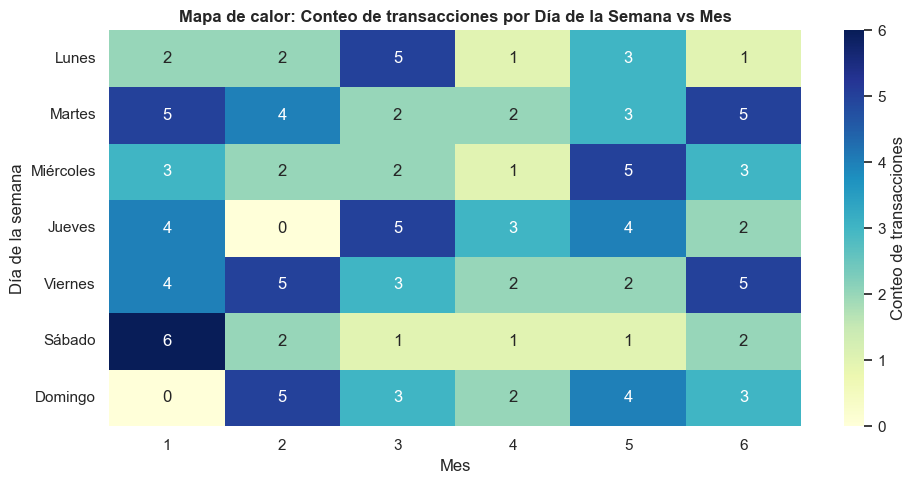

In [85]:
# Heatmap: Día de la semana vs Mes (conteos)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
print('Lo que está evaluando: Conteo de transacciones por Día de la Semana y Mes')
print('Tipo de gráfico: Heatmap (matriz de conteos)')
# Resumen estadístico previo: totales por día y por mes
if 'id_venta' in df_ventas_True.columns:
    total_tx = df_ventas_True['id_venta'].nunique() if df_ventas_True['id_venta'].dtype == 'object' else len(df_ventas_True)
else:
    total_tx = len(df_ventas_True)
print(f'Total aproximado de transacciones en el periodo: {total_tx:,}')
if 'mes' in df_ventas_True.columns and 'dia_semana' in df_ventas_True.columns:
    pivot = df_ventas_True.pivot_table(index='dia_semana', columns='mes', values='id_venta', aggfunc='count', fill_value=0)
    dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
    pivot = pivot.reindex(dias).fillna(0)
    try:
        pivot = pivot[sorted(pivot.columns)]
    except Exception:
        pass
    # Estadística estratégica: día y mes con mayor volumen
    row_sums = pivot.sum(axis=1)
    col_sums = pivot.sum(axis=0)
    dia_max = row_sums.idxmax() if not row_sums.empty else 'N/A'
    mes_max = int(col_sums.idxmax()) if not col_sums.empty else 'N/A'
    print(f'Día con mayor volumen (total en periodo): {dia_max} | Mes más activo: {mes_max}')
    plt.figure(figsize=(10,5))
    sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Conteo de transacciones'})
    plt.title('Mapa de calor: Conteo de transacciones por Día de la Semana vs Mes', fontsize=12, weight='bold')
    plt.ylabel('Día de la semana')
    plt.xlabel('Mes')
    plt.tight_layout()
    plt.show()
else:
    print('No es posible generar heatmap: faltan columnas `mes` o `dia_semana`.')

💡 **Conclusión / Síntesis de negocio:**

El heatmap muestra las combinaciones día/mes que concentran el mayor volumen de transacciones. Si un par (día, mes) aparece consistentemente alto, se recomienda revisar staffing y disponibilidad de stock en esos períodos; si hay picos puntuales, investigar promociones o eventos que los generaron.

### 📚 Composición porcentual de Medios de Pago por Mes

**Tipo de gráfico:** Barra apilada porcentual (stacked bar %).

**Cómo:** se agrupa por `mes` y se suman las columnas OHE (prefijo `medio_pago_`). Luego se normaliza por fila para obtener porcentajes y se dibuja una barra apilada por mes. Se ordenan meses y se añade leyenda y formato consistente con el resto del notebook.

**Por qué:** revela cambios en la mezcla de medios de pago a lo largo del tiempo — útil para decisiones de producto y conciliación financiera.

Lo que está evaluando: Composición porcentual de medios de pago por mes
Tipo de gráfico: Barra apilada porcentual (stacked bar %)
Método de pago más usado en el periodo: Efectivo (~30.8% del volumen OHE)


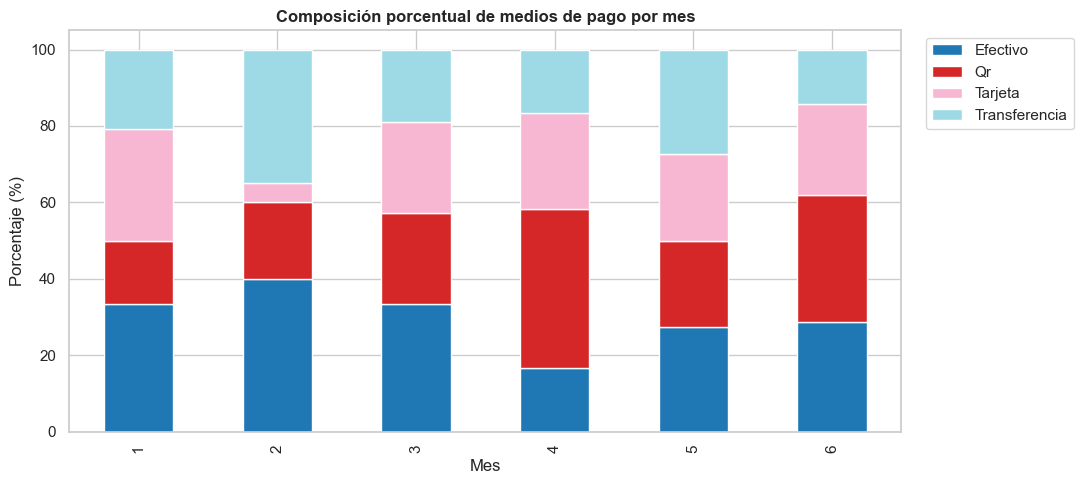

In [86]:
# Stacked bar: composición de medios de pago por mes (porcentaje)
import numpy as np
ohe_cols = [c for c in df_ventas_True.columns if c.startswith('medio_pago_')]
print('Lo que está evaluando: Composición porcentual de medios de pago por mes')
print('Tipo de gráfico: Barra apilada porcentual (stacked bar %)')
if ohe_cols and 'mes' in df_ventas_True.columns:
    df_ohe_month = df_ventas_True.groupby('mes')[ohe_cols].sum()
    try:
        df_ohe_month = df_ohe_month.reindex(sorted(df_ohe_month.index))
    except Exception:
        pass
    df_ohe_month_pct = df_ohe_month.div(df_ohe_month.sum(axis=1), axis=0).fillna(0) * 100
    # Resumen estratégico: método de pago más frecuente en el periodo
    totals = df_ohe_month.sum(axis=0).sort_values(ascending=False)
    top_method = totals.index[0].replace('medio_pago_x0_', '').replace('medio_pago_', '').replace('_', ' ').title() if not totals.empty else 'N/A'
    top_pct = totals.iloc[0] / totals.sum() * 100 if totals.sum() > 0 else 0
    print(f'Método de pago más usado en el periodo: {top_method} (~{top_pct:.1f}% del volumen OHE)')
    ax = df_ohe_month_pct.plot(kind='bar', stacked=True, figsize=(11,5), colormap='tab20')
    plt.title('Composición porcentual de medios de pago por mes', fontsize=12, weight='bold')
    plt.ylabel('Porcentaje (%)')
    plt.xlabel('Mes')
    handles, labels = ax.get_legend_handles_labels()
    labels = [l.replace('medio_pago_x0_', '').replace('medio_pago_', '').replace('_', ' ').title() for l in labels]
    ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02,1))
    plt.tight_layout()
    plt.show()
else:
    print('No se puede dibujar la barra apilada: faltan OHE de medio_pago o columna `mes`.')

💡 **Conclusión / Síntesis de negocio:**

La composición porcentual muestra la participación relativa de cada medio de pago por mes. Si un método domina (>50%) persistente, puede implicar riesgos operativos o dependencia; si la mezcla cambia en el tiempo, investigar eventos o campañas que lo expliquen.

### 📈 Serie acumulada: Transacciones acumuladas en el tiempo

**Tipo de gráfico:** Serie temporal acumulada (línea).

**Cómo:** se indexa por `fecha`, se resamplea a frecuencia diaria contando `id_venta`, se rellena con ceros para días sin transacciones y se toma la suma acumulada. Se grafica la serie con una línea y marcas para facilitar la lectura de hitos.

**Por qué:** una serie acumulada muestra el ritmo de crecimiento y facilita la detección de cambios estructurales o picos en el periodo de análisis.

Lo que está evaluando: Ritmo de acumulación de transacciones en el tiempo
Tipo de gráfico: Serie temporal acumulada (línea)
Periodo: 2024-01-02 a 2024-06-28 | Total transacciones acumuladas: 120 | Promedio diario: 0.67


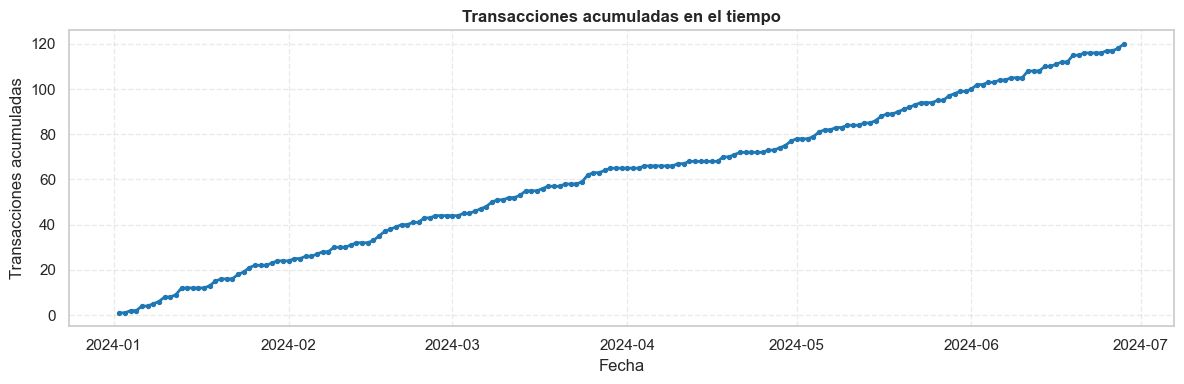

In [87]:
# Transacciones acumuladas en el tiempo (serie temporal)
print('Lo que está evaluando: Ritmo de acumulación de transacciones en el tiempo')
print('Tipo de gráfico: Serie temporal acumulada (línea)')
if 'fecha' in df_ventas_True.columns:
    df_time = df_ventas_True.set_index('fecha').sort_index()
    idx = pd.date_range(df_time.index.min(), df_time.index.max(), freq='D')
    daily_counts = df_time['id_venta'].resample('D').count().reindex(idx, fill_value=0)
    daily_cum = daily_counts.cumsum()
    # Estadística estratégica: periodo, total y promedio diario
    start, end = daily_cum.index.min().date(), daily_cum.index.max().date()
    total_final = daily_cum.iloc[-1] if len(daily_cum)>0 else 0
    avg_daily = daily_counts.mean()
    print(f'Periodo: {start} a {end} | Total transacciones acumuladas: {total_final:,} | Promedio diario: {avg_daily:.2f}')
    plt.figure(figsize=(12,4))
    plt.plot(daily_cum.index, daily_cum.values, color='tab:blue', linewidth=2)
    plt.scatter(daily_cum.index, daily_cum.values, color='tab:blue', s=8)
    plt.title('Transacciones acumuladas en el tiempo', fontsize=12, weight='bold')
    plt.ylabel('Transacciones acumuladas')
    plt.xlabel('Fecha')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print('No se puede generar la serie temporal: columna `fecha` ausente.')

💡 **Conclusión / Síntesis de negocio:**

La serie acumulada muestra el ritmo de crecimiento. Si la pendiente aumenta significativamente en un periodo, puede indicar una campaña o una anomalía que merece atención. Comparar la pendiente entre periodos ayuda a medir impacto de acciones comerciales.

In [88]:
# --- ANÁLISIS Y RESUMEN ESTADÍSTICO REPRESENTATIVO ---

# 1. Análisis de Medidas Centrales y Dispersión
print("📊 RESUMEN ESTADÍSTICO DE VARIABLES CLAVE (TRANSACCIONES Y RECURRENCIA)")
print("----------------------------------------------------------------------")
# Transacciones_cliente nos da una idea de la distribución de lealtad
print(df_ventas_True[['mes', 'trimestre', 'transacciones_cliente']].describe().T)

# 2. Resumen de Distribución de Medios de Pago (Análisis del OHE)
# La media de las columnas binarias es la proporción (probabilidad) de esa categoría.
columnas_ohe = [col for col in df_ventas_True.columns if col.startswith('medio_pago_')]
frecuencias_pago = df_ventas_True[columnas_ohe].mean().sort_values(ascending=False) * 100

print("\n\n📊 DISTRIBUCIÓN PORCENTUAL DE MEDIOS DE PAGO (ANÁLISIS OHE)")
print("------------------------------------------------------------")
# Formato limpio para presentar el resumen clave
print(frecuencias_pago.apply(lambda x: f"{x:.2f}%").to_string(header=False).replace('medio_pago_', ''))

# 3. Análisis de Frecuencia de Recurrencia (Insight clave para el negocio)
recurrencia_conteo = df_ventas_True.groupby('id_cliente')['transacciones_cliente'].first().value_counts().sort_index()
total_clientes = recurrencia_conteo.sum()
clientes_unicos = recurrencia_conteo.get(1, 0) # Clientes que compraron solo una vez
clientes_recurrentes = total_clientes - clientes_unicos

print("\n\n📊 RESUMEN DE RECURRENCIA DE CLIENTES")
print("-------------------------------------")
print(f"Total de Clientes Únicos en el período: {total_clientes}")
print(f"Clientes de 1 Transacción: {clientes_unicos} ({clientes_unicos/total_clientes:.1%})")
print(f"Clientes Recurrentes (>1 Transacción): {clientes_recurrentes} ({clientes_recurrentes/total_clientes:.1%})")

📊 RESUMEN ESTADÍSTICO DE VARIABLES CLAVE (TRANSACCIONES Y RECURRENCIA)
----------------------------------------------------------------------
                       count      mean       std  min   25%  50%  75%  max
mes                    120.0  3.425000  1.794775  1.0  2.00  3.0  5.0  6.0
trimestre              120.0  1.458333  0.500350  1.0  1.00  1.0  2.0  2.0
transacciones_cliente  120.0  2.283333  1.138946  1.0  1.75  2.0  3.0  5.0


📊 DISTRIBUCIÓN PORCENTUAL DE MEDIOS DE PAGO (ANÁLISIS OHE)
------------------------------------------------------------
efectivo         30.83%
qr               25.00%
transferencia    22.50%
tarjeta          21.67%


📊 RESUMEN DE RECURRENCIA DE CLIENTES
-------------------------------------
Total de Clientes Únicos en el período: 67
Clientes de 1 Transacción: 30 (44.8%)
Clientes Recurrentes (>1 Transacción): 37 (55.2%)


#### 📊 Distribución de `Medios de Pago`

Tipo de gráfico: Gráfico de Barras (univariado).

Cómo: se calcula la proporción media de cada columna OHE (`medio_pago_...`) y se representa como barras porcentuales para comparar participación relativa. Los valores se muestran en porcentaje sobre el total de transacciones.

Por qué: permite identificar cuál es el medio de pago dominante y su peso relativo — información útil para priorizar integraciones, analizar fees y diseñar estrategias de cobro.

Lo que está evaluando: Preferencia de medios de pago (participación porcentual)
Tipo de gráfico: Gráfico de barras (porcentual)
Método más frecuente: Efectivo (~30.8% de las transacciones)


C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\2542425055.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nombres_limpios, y=frecuencias_pago_df.values, palette="rocket")


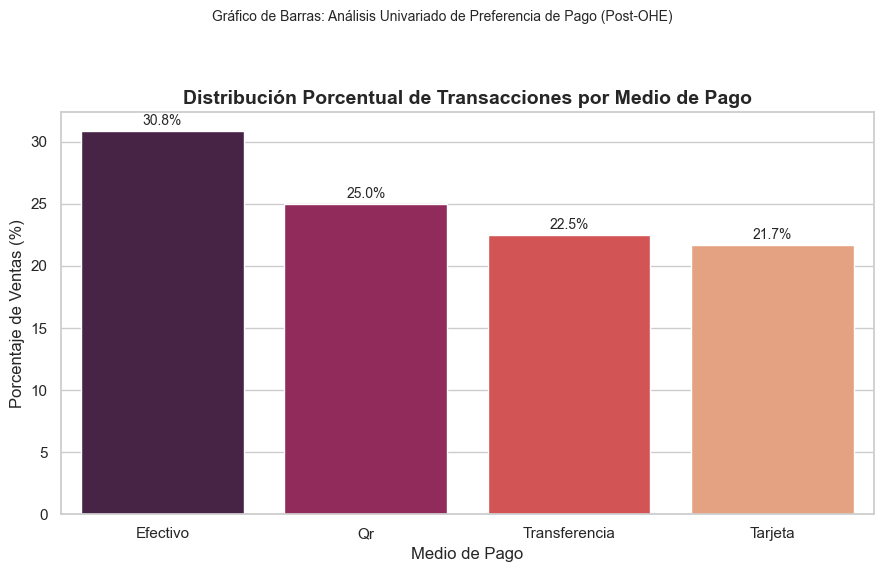

In [89]:
# Gráfico: Distribución porcentual de Medios de Pago (post-OHE)
print('Lo que está evaluando: Preferencia de medios de pago (participación porcentual)')
print('Tipo de gráfico: Gráfico de barras (porcentual)')
if len(columnas_ohe)==0:
    print('No hay columnas OHE detectadas para medios de pago.')
else:
    frecuencias_pago_df = (df_ventas_True[columnas_ohe].mean() * 100).sort_values(ascending=False)
    nombres_limpios = [col.replace('medio_pago_x0_', '').replace('medio_pago_', '').replace('_', ' ').title() for col in frecuencias_pago_df.index]
    # Resumen estadístico: top 1 y participación
    top_name = nombres_limpios[0] if len(nombres_limpios)>0 else 'N/A'
    top_val = frecuencias_pago_df.values[0] if len(frecuencias_pago_df)>0 else 0
    print(f'Método más frecuente: {top_name} (~{top_val:.1f}% de las transacciones)')
    plt.figure(figsize=(9, 6))
    sns.barplot(x=nombres_limpios, y=frecuencias_pago_df.values, palette="rocket")
    plt.title('Distribución Porcentual de Transacciones por Medio de Pago', fontsize=14, weight='bold')
    plt.suptitle('Gráfico de Barras: Análisis Univariado de Preferencia de Pago (Post-OHE)', fontsize=10, y=0.95)
    plt.ylabel('Porcentaje de Ventas (%)', fontsize=12)
    plt.xlabel('Medio de Pago', fontsize=12)
    plt.xticks(rotation=0)
    for i, valor in enumerate(frecuencias_pago_df.values):
        plt.text(i, valor + 0.5, f'{valor:.1f}%', ha='center', fontsize=10)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

💡 **Conclusión / Síntesis de negocio:**

El gráfico univariado confirma cuál es el medio de pago dominante y su participación. Esto es útil para priorizar integraciones, optimizar conciliaciones y analizar comisiones/fees asociados.

#### 📈 Tendencia de Transacciones por Mes

Tipo de gráfico: Gráfico de Líneas (serie temporal mensual).

Cómo: se agrupan las transacciones por la columna `mes` y se cuentan `id_venta` por mes. La serie resultante se dibuja como línea con marcadores para visualizar cambios intermensuales.

Por qué: facilita la detección de estacionalidad, tendencias y picos que ayudan a planificar inventario y campañas comerciales.

Lo que está evaluando: Volumen mensual de transacciones (conteo por mes)
Tipo de gráfico: Gráfico de líneas (serie temporal mensual)
Mes con mayor volumen en el periodo: Ene (24 transacciones)


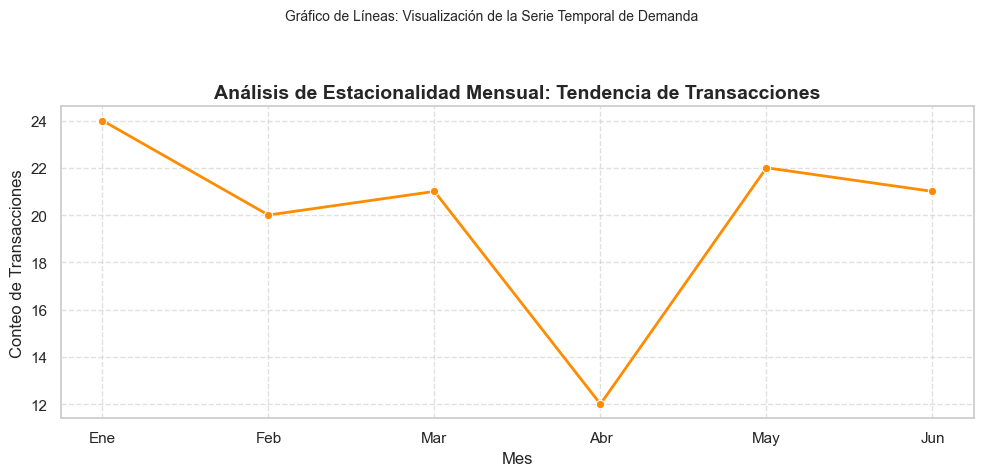

In [90]:
# Tendencia de transacciones por mes (serie mensual)
print('Lo que está evaluando: Volumen mensual de transacciones (conteo por mes)')
print('Tipo de gráfico: Gráfico de líneas (serie temporal mensual)')
transacciones_mes = df_ventas_True.groupby('mes')['id_venta'].count()
nombres_meses = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}
etiquetas_mes = [nombres_meses.get(m, m) for m in transacciones_mes.index]
# Resumen estratégico: mes con mayor volumen
if not transacciones_mes.empty:
    mes_peak = transacciones_mes.idxmax()
    print(f'Mes con mayor volumen en el periodo: {nombres_meses.get(mes_peak, mes_peak)} ({transacciones_mes.max()} transacciones)')
else:
    print('No hay transacciones agrupadas por mes para resumir.')
plt.figure(figsize=(10, 5))
sns.lineplot(x=transacciones_mes.index, y=transacciones_mes.values, marker='o', color='darkorange', linewidth=2)
plt.title('Análisis de Estacionalidad Mensual: Tendencia de Transacciones', fontsize=14, weight='bold')
plt.suptitle('Gráfico de Líneas: Visualización de la Serie Temporal de Demanda', fontsize=10, y=0.95)
plt.ylabel('Conteo de Transacciones', fontsize=12)
plt.xlabel('Mes', fontsize=12)
plt.xticks(transacciones_mes.index, etiquetas_mes)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

💡 **Conclusión / Síntesis de negocio:**

La tendencia mensual permite observar estacionalidad y picos. Identificar meses pico ayuda a planificar inventario y campañas; si hay caídas sostenidas, es un indicador para investigar causas (competencia, stock, precios).

#### 📉 Demanda por Día de la Semana

Tipo de gráfico: Gráfico de Barras Ordenado (ordinal).

Cómo: se cuentan `id_venta` por `dia_semana` y se reindexa según el orden semanal en español para mantener la lógica ordinal (Lunes→Domingo).

Por qué: muestra la distribución operativa por día y ayuda en la asignación de recursos, horarios de atención y planificación logística.

Lo que está evaluando: Conteo de transacciones por Día de la Semana
Tipo de gráfico: Gráfico de barras ordenado
Día con mayor demanda: Martes (21 transacciones)


C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\34671193.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  transacciones_dia = df_ventas_True.groupby('dia_semana')['id_venta'].count().reindex(orden_dias_es)
C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\34671193.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=transacciones_dia.index, y=transacciones_dia.values, palette="tab10")


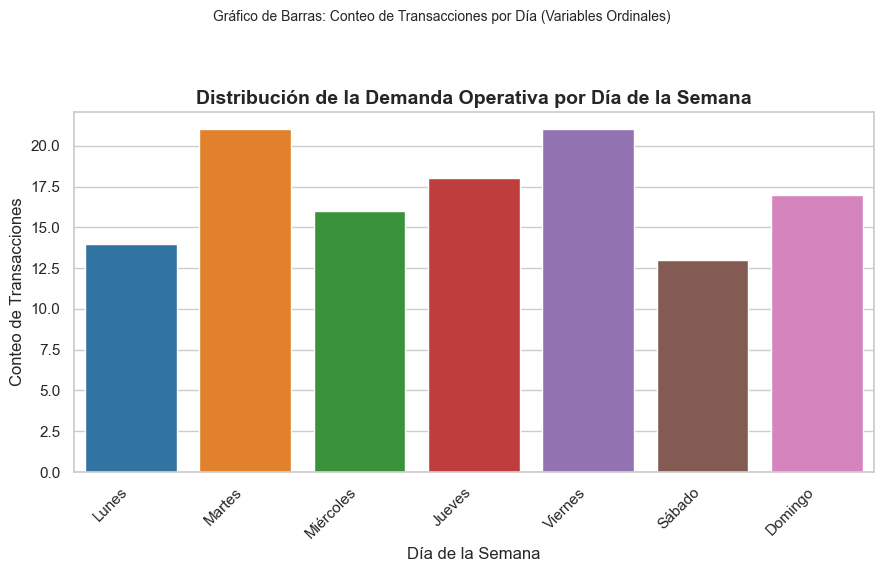

In [91]:
# Demanda por día de la semana (barras ordenadas)
print('Lo que está evaluando: Conteo de transacciones por Día de la Semana')
print('Tipo de gráfico: Gráfico de barras ordenado')
transacciones_dia = df_ventas_True.groupby('dia_semana')['id_venta'].count().reindex(orden_dias_es)
# Resumen estratégico: día con mayor demanda
if not transacciones_dia.empty:
    dia_top = transacciones_dia.idxmax()
    print(f'Día con mayor demanda: {dia_top} ({transacciones_dia.max()} transacciones)')
else:
    print('No hay datos de transacciones por día de la semana.')
plt.figure(figsize=(9, 6))
sns.barplot(x=transacciones_dia.index, y=transacciones_dia.values, palette="tab10")
plt.title('Distribución de la Demanda Operativa por Día de la Semana', fontsize=14, weight='bold')
plt.suptitle('Gráfico de Barras: Conteo de Transacciones por Día (Variables Ordinales)', fontsize=10, y=0.95)
plt.ylabel('Conteo de Transacciones', fontsize=12)
plt.xlabel('Día de la Semana', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

💡 **Conclusión / Síntesis de negocio:**

Determinar los días con mayor demanda ayuda a planificar turnos y promociones. Si hay un día consistentemente alto, ajustar staffing y disponibilidad en ese día mejora servicio al cliente.

#### 📈 Histograma de Recurrencia (Fidelidad de Clientes)

Tipo de gráfico: Histograma de frecuencias (discreto).

Cómo: se toma el conteo de transacciones por `id_cliente` y se grafica la distribución con bins discretos (0.5 offsets) para representar valores enteros de número de compras.

Por qué: permite evaluar la lealtad de la base (qué proporción compra solo una vez vs recurrentes) y orientar estrategias de retención o fidelización.

Lo que está evaluando: Distribución de recurrencia (transacciones por cliente)
Tipo de gráfico: Histograma de frecuencias (discreto)
Mediana: 2.0 | Promedio: 1.79 | % clientes con 1 compra: 44.8%


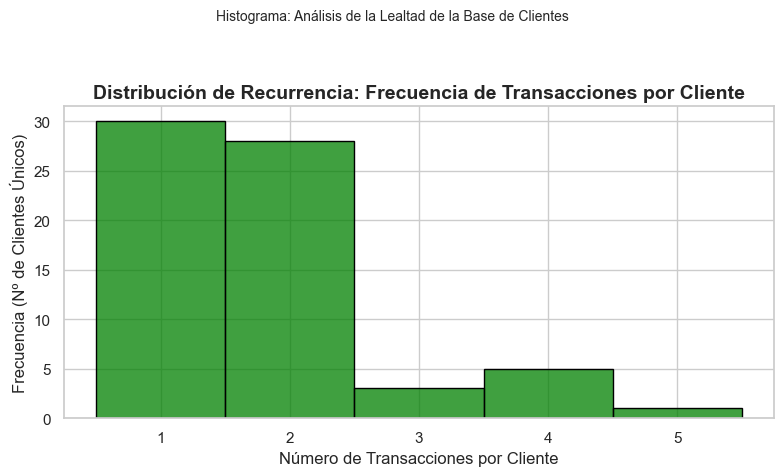

In [92]:
# Histograma de recurrencia: número de transacciones por cliente
print('Lo que está evaluando: Distribución de recurrencia (transacciones por cliente)')
print('Tipo de gráfico: Histograma de frecuencias (discreto)')
clientes_recurrentes = df_ventas_True.groupby('id_cliente')['transacciones_cliente'].first()
if clientes_recurrentes.empty:
    print('No hay datos de recurrencia por cliente para graficar.')
else:
    mediana = clientes_recurrentes.median()
    promedio = clientes_recurrentes.mean()
    pct_unicos = (clientes_recurrentes==1).mean() * 100
    print(f'Mediana: {mediana} | Promedio: {promedio:.2f} | % clientes con 1 compra: {pct_unicos:.1f}%')
    plt.figure(figsize=(8, 5))
    sns.histplot(clientes_recurrentes, bins=np.arange(clientes_recurrentes.max() + 2) - 0.5, kde=False, color='green', edgecolor='black', discrete=True)
    plt.title('Distribución de Recurrencia: Frecuencia de Transacciones por Cliente', fontsize=14, weight='bold')
    plt.suptitle('Histograma: Análisis de la Lealtad de la Base de Clientes', fontsize=10, y=0.95)
    plt.xlabel('Número de Transacciones por Cliente', fontsize=12)
    plt.ylabel('Frecuencia (Nº de Clientes Únicos)', fontsize=12)
    plt.xticks(np.arange(1, clientes_recurrentes.max() + 1))
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()


#### 🏆 Top 10 Clientes por Cantidad de Compras

**Tipo de gráfico:** Gráfico de Barras (Top N).

**Cómo:** se agrupan las transacciones por `id_cliente`, se cuenta el número de ventas por cliente y se seleccionan los 10 con mayor volumen. Se ordenan descendentemente y se dibuja un gráfico de barras con anotaciones sobre cada barra para mostrar el valor absoluto.

**Por qué:** identificar a los clientes más activos ayuda a priorizar análisis de segmentación, modelos de retención y acciones comerciales (programas VIP, cross-sell).

Lo que está evaluando: Top 10 clientes por número de compras
Tipo de gráfico: Gráfico de Barras (Top N)
Total transacciones: 120 | Clientes únicos: 67
Top cliente: 56 con 5 transacciones (4.2% del total)


C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\1493218089.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.index.astype(str), y=top10.values, palette='tab10')


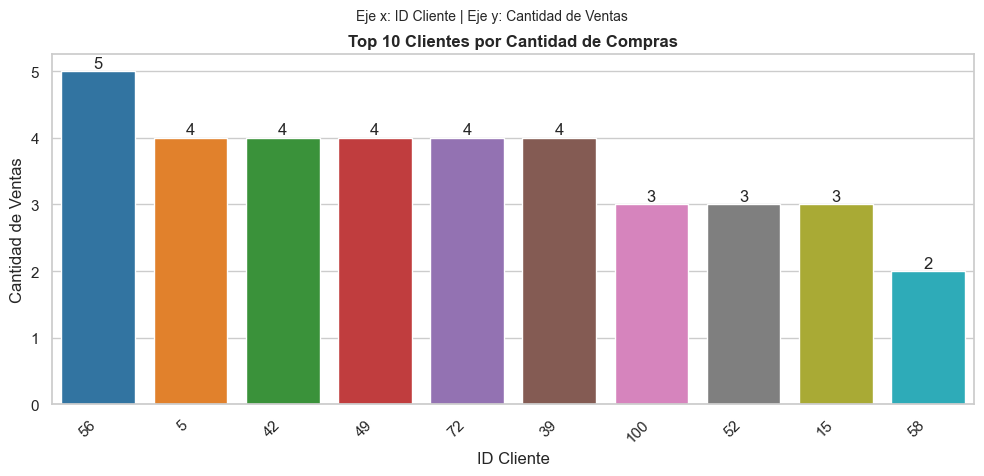

In [93]:
# Código: Top 10 Clientes por cantidad de compras (gráfico)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
print('Lo que está evaluando: Top 10 clientes por número de compras')
print('Tipo de gráfico: Gráfico de Barras (Top N)')
if 'id_cliente' in df_ventas_True.columns:
    top10 = df_ventas_True.groupby('id_cliente')['id_venta'].count().sort_values(ascending=False).head(10)
    total_trans = len(df_ventas_True)
    clientes_unicos = df_ventas_True['id_cliente'].nunique()
    top_cliente = top10.index[0] if len(top10)>0 else 'N/A'
    top_count = int(top10.iloc[0]) if len(top10)>0 else 0
    print(f'Total transacciones: {total_trans:,} | Clientes únicos: {clientes_unicos:,}')
    print(f'Top cliente: {top_cliente} con {top_count:,} transacciones ({top_count/total_trans:.1%} del total)')
    plt.figure(figsize=(10,5))
    sns.barplot(x=top10.index.astype(str), y=top10.values, palette='tab10')
    plt.title('Top 10 Clientes por Cantidad de Compras', fontsize=12, weight='bold')
    plt.suptitle('Eje x: ID Cliente | Eje y: Cantidad de Ventas', fontsize=10, y=0.95)
    plt.xlabel('ID Cliente')
    plt.ylabel('Cantidad de Ventas')
    plt.xticks(rotation=45, ha='right')
    # Anotar valores encima de las barras
    maxv = top10.values.max() if len(top10)>0 else 0
    for i, v in enumerate(top10.values):
        plt.text(i, v + maxv*0.01, f'{int(v):,}', ha='center')
    plt.tight_layout()
    plt.show()
else:
    print("Columna 'id_cliente' no encontrada en df_ventas_True.")

💡 **Conclusión / Síntesis de negocio:**

Si la mayoría de clientes realiza 1 sola compra (% alto), la estrategia debería enfocarse en retención (fidelización). Si hay una masa significativa de clientes recurrentes, explorar programas VIP o cross-sell.

#### 📉 Análisis Bivariado (Recurrencia vs. Días de la Semana)

Tipo de gráfico: Gráfico de Barras Bivariado (media condicional).

Cómo: se calcula la media de `transacciones_cliente` por `dia_semana` y se visualiza en barras ordenadas según la semana en español.

Por qué: muestra diferencias en la lealtad promedio de clientes según el día, lo que puede orientar promociones segmentadas o staffing en días donde los clientes más leales compran.

Lo que está evaluando: Recurrencia promedio (transacciones por cliente) por Día de la Semana
Tipo de gráfico: Gráfico de barras bivariado (media condicional)
Día con mayor recurrencia promedio: Jueves (2.56 transacciones promedio)


C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\311510471.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  recurrencia_por_dia = df_ventas_True.groupby('dia_semana')['transacciones_cliente'].mean().reindex(orden_dias_es)
C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\311510471.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=recurrencia_por_dia.index, y=recurrencia_por_dia.values, palette="vlag")


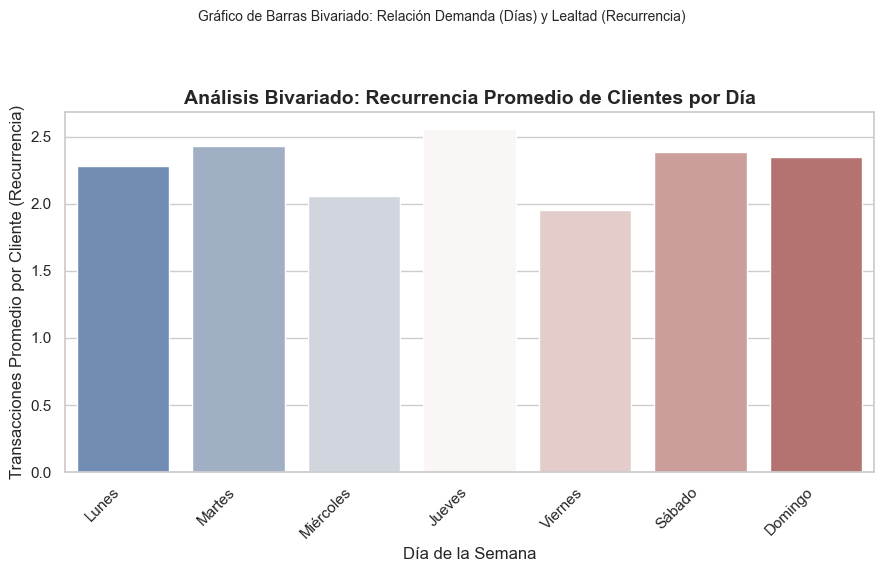

In [94]:
# Bivariado: Recurrencia promedio por Día de la semana
print('Lo que está evaluando: Recurrencia promedio (transacciones por cliente) por Día de la Semana')
print('Tipo de gráfico: Gráfico de barras bivariado (media condicional)')
recurrencia_por_dia = df_ventas_True.groupby('dia_semana')['transacciones_cliente'].mean().reindex(orden_dias_es)
if recurrencia_por_dia.empty:
    print('No hay datos para calcular recurrencia por día.')
else:
    top_dia = recurrencia_por_dia.idxmax()
    print(f'Día con mayor recurrencia promedio: {top_dia} ({recurrencia_por_dia.max():.2f} transacciones promedio)')
plt.figure(figsize=(9, 6))
sns.barplot(x=recurrencia_por_dia.index, y=recurrencia_por_dia.values, palette="vlag")
plt.title('Análisis Bivariado: Recurrencia Promedio de Clientes por Día', fontsize=14, weight='bold')
plt.suptitle('Gráfico de Barras Bivariado: Relación Demanda (Días) y Lealtad (Recurrencia)', fontsize=10, y=0.95)
plt.ylabel('Transacciones Promedio por Cliente (Recurrencia)', fontsize=12)
plt.xlabel('Día de la Semana', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

💡 **Conclusión / Síntesis de negocio:**

Comparar recurrencia por día ayuda a entender en qué días los clientes más leales compran. Si los días de mayor recurrencia coinciden con días altos en volumen, son días prioritarios para iniciativas de retención.

### 💳 Evolución de Medio de Pago por Mes

**Tipo de gráfico:** Series temporales (líneas) por cada medio de pago, agregadas por mes.

**Cómo:** si existen las columnas OHE (`medio_pago_...`) se resamplean estas columnas por mes (suma de transacciones). Si no existen, se intenta agrupar por la columna `medio_pago` original (si aún está presente) y pivotar por mes. El eje X representa la fecha (mes), el eje Y la cantidad de ventas por medio de pago.

**Por qué:** mostrar la evolución por mes permite identificar tendencias en la preferencia de pago, detectar cambios estacionales o el impacto de campañas/medidas operativas en la mezcla de medios de pago.

Lo que está evaluando: Evolución mensual de la cantidad de ventas por Medio de Pago
Tipo de gráfico: Series temporales (líneas) por medio de pago
Método con mayor volumen acumulado en el periodo: Efectivo (37 ventas)


C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\9708250.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_month = df_time[ohe_cols].resample('M').sum()


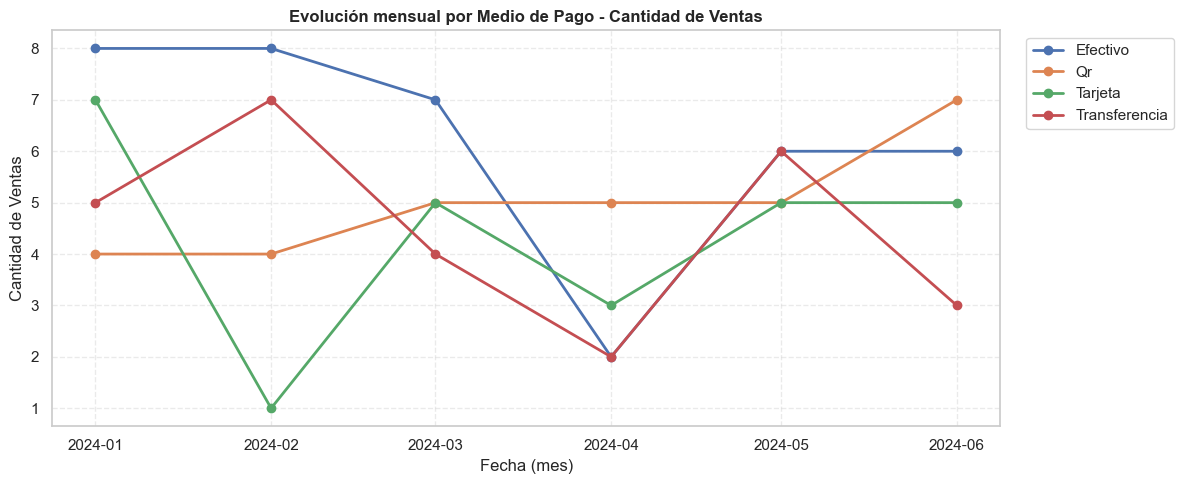

In [95]:
# Evolución de Medio de Pago por Mes: eje y = Cantidad de Ventas, eje x = Fecha (mes)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
print('Lo que está evaluando: Evolución mensual de la cantidad de ventas por Medio de Pago')
print('Tipo de gráfico: Series temporales (líneas) por medio de pago')
ohe_cols = [c for c in df_ventas_True.columns if c.startswith('medio_pago_')]
if 'fecha' not in df_ventas_True.columns:
    print('No se puede generar la serie: falta la columna `fecha`.')
else:
    df_time = df_ventas_True.set_index('fecha').sort_index()
    if ohe_cols:
        df_month = df_time[ohe_cols].resample('M').sum()
        df_month.index = df_month.index.to_period('M').to_timestamp()
        # Resumen estratégico: totales por método en el periodo
        totals = df_month.sum().sort_values(ascending=False)
        if not totals.empty:
            top = totals.index[0].replace('medio_pago_x0_', '').replace('medio_pago_', '').replace('_',' ').title()
            print(f'Método con mayor volumen acumulado en el periodo: {top} ({totals.iloc[0]:.0f} ventas)')
        plt.figure(figsize=(12,5))
        for col in df_month.columns:
            label = col.replace('medio_pago_x0_', '').replace('medio_pago_', '').replace('_', ' ').title()
            plt.plot(df_month.index, df_month[col], marker='o', linewidth=2, label=label)
        plt.title('Evolución mensual por Medio de Pago - Cantidad de Ventas', fontsize=12, weight='bold')
        plt.xlabel('Fecha (mes)')
        plt.ylabel('Cantidad de Ventas')
        plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()
    elif 'medio_pago' in df_ventas_True.columns:
        grouped = df_ventas_True.groupby([pd.Grouper(key='fecha', freq='M'), 'medio_pago'])['id_venta'].count().unstack(fill_value=0)
        grouped.index = grouped.index.to_period('M').to_timestamp()
        totals = grouped.sum().sort_values(ascending=False)
        if not totals.empty:
            print(f'Método con mayor volumen acumulado en el periodo: {totals.index[0]} ({totals.iloc[0]:.0f} ventas)')
        plt.figure(figsize=(12,5))
        for col in grouped.columns:
            plt.plot(grouped.index, grouped[col], marker='o', linewidth=2, label=str(col))
        plt.title('Evolución mensual por Medio de Pago - Cantidad de Ventas', fontsize=12, weight='bold')
        plt.xlabel('Fecha (mes)')
        plt.ylabel('Cantidad de Ventas')
        plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()
    else:
        print('No se encontraron columnas de medio de pago (ni OHE ni columna `medio_pago`).')

💡 **Conclusión / Síntesis de negocio:**

La evolución mensual por medio de pago muestra tendencias y desplazamientos en la preferencia de los clientes. Si un método crece rápidamente, puede requerir ajustes en fees o infraestructura. Si decrece, estudiar causas (usabilidad, comisiones, problemas técnicos).

### 2.5 Verificación de Dataframes Disponibles

Antes del merge, se verifica la disponibilidad de los 4 dataframes limpios (`df_*_True`) en el entorno del notebook.

In [96]:
# ================================================================
# 0. IMPORTACIONES Y CONFIGURACIÓN GLOBAL - PROYECTO AURELION
# ================================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd

# Scikit-learn para la parte de ML (lo usarás más adelante en el notebook)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# (Opcional) Matplotlib si en algún momento hacés gráficos
import matplotlib.pyplot as plt

# Configuración de pandas para ver bien los dataframes
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Directorios base (útil para leer/guardar CSV dentro del mismo proyecto)
BASE_DIR = Path().resolve()
DATA_DIR = BASE_DIR / "db"
DATA_DIR.mkdir(exist_ok=True)  # crea la carpeta db si no existe

print('✅ Librerías y configuración cargadas correctamente.')
print(f'📂 Carpeta de datos: {DATA_DIR}')


✅ Librerías y configuración cargadas correctamente.
📂 Carpeta de datos: C:\Users\Asus\Desktop\Augusto Villegas - Proyecto Aurelion (DEMO 3)\db


### Verificación de disponibilidad de dataframes

In [97]:
# ================================================================
# 1. VERIFICACIÓN DE DATAFRAMES NECESARIOS EN ESTE NOTEBOOK
#    (Clientes, Ventas, Detalle, Productos)
# ================================================================

def check_dataframes():
    """
    Verifica que los dataframes clave del proyecto estén disponibles
    en el entorno global del notebook.

    Requiere que, en celdas anteriores de este mismo notebook,
    se hayan creado:
      - df_clientes_True
      - df_ventas_True
      - df_detalle_ventas_True
      - df_productos_True
    """
    dfs_needed = {
        'df_clientes_True'      : 'Clientes',
        'df_ventas_True'        : 'Ventas (cabecera)',
        'df_detalle_ventas_True': 'Detalle de ventas',
        'df_productos_True'     : 'Productos'
    }
    
    available = {}
    missing = []
    
    print('=' * 100)
    print('🔍 VERIFICACIÓN DE DATAFRAMES NECESARIOS')
    print('=' * 100)
    
    for var_name, label in dfs_needed.items():
        if var_name in globals():
            df_temp = globals()[var_name]
            # Opcional: aseguramos que realmente es un DataFrame
            if isinstance(df_temp, pd.DataFrame):
                available[var_name] = label
                print(f'✅ {label:30s} -> Dimensiones: {df_temp.shape}')
            else:
                missing.append(f'{label} ({var_name}) [no es DataFrame]')
                print(f'❌ {label:30s} -> VARIABLE NO ES UN DATAFRAME')
        else:
            missing.append(f'{label} ({var_name})')
            print(f'❌ {label:30s} -> NO DISPONIBLE')
    
    if missing:
        print('\n⚠️  Faltan cargar o crear los siguientes dataframes en este notebook:')
        print('   - ' + '\n   - '.join(missing))
        print('\n📌 Por favor, ejecuta primero las SECCIONES DE LIMPIEZA de este mismo notebook:')
        print('   - Sección de limpieza de CLIENTES  -> df_clientes_True')
        print('   - Sección de limpieza de VENTAS    -> df_ventas_True')
        print('   - Sección de limpieza de DETALLE   -> df_detalle_ventas_True')
        print('   - Sección de limpieza de PRODUCTOS -> df_productos_True')
        return False
    else:
        print('\n✨ Todos los dataframes necesarios están disponibles.')
        return True

# Ejecutar verificación
all_available = check_dataframes()
if not all_available:
    raise RuntimeError(
        "Faltan uno o más dataframes *_True. "
        "Ejecuta las secciones de limpieza anteriores de este notebook antes de continuar con la consolidación."
    )


🔍 VERIFICACIÓN DE DATAFRAMES NECESARIOS
✅ Clientes                       -> Dimensiones: (100, 5)
✅ Ventas (cabecera)              -> Dimensiones: (120, 12)
✅ Detalle de ventas              -> Dimensiones: (343, 6)
✅ Productos                      -> Dimensiones: (100, 4)

✨ Todos los dataframes necesarios están disponibles.


## 📊 2. Inspección de Estructura y Claves

Antes de realizar los merges, inspeccionaremos cada dataframe para identificar correctamente las claves primarias (PK) y foráneas (FK).

In [98]:
# ================================================================
# 2. RESUMEN DE ESTRUCTURA DE LOS DATAFRAMES BASE
#    (Solo se ejecuta si all_available es True)
# ================================================================

def describir_df(nombre_logico, df, pk=None, fk=None):
    """
    Imprime un resumen compacto de la estructura de un dataframe:
    - Nombre lógico
    - Claves primarias (PK)
    - Claves foráneas (FK)
    - Columnas
    - Número de registros
    """
    print(f'\n{nombre_logico}')
    print('-' * 80)
    
    if pk:
        print(f'   PK: {pk}')
    if fk:
        print(f'   FK: {fk}')
    
    print('\n   Vista de cabecera (sin datos, solo columnas):')
    print(df.head(0))
    print(f'\n   Columnas ({len(df.columns)}): {list(df.columns)}')
    print(f'   Registros: {len(df)}')

if all_available:
    print('=' * 100)
    print('📋 ESTRUCTURA DE DATAFRAMES BASE')
    print('=' * 100)

    describir_df(
        nombre_logico='1. df_clientes_True',
        df=df_clientes_True,
        pk='id_cliente'
    )

    describir_df(
        nombre_logico='2. df_ventas_True',
        df=df_ventas_True,
        pk='id_venta',
        fk='id_cliente'
    )

    describir_df(
        nombre_logico='3. df_detalle_ventas_True',
        df=df_detalle_ventas_True,
        pk='id_detalle',
        fk='id_venta, id_producto'
    )

    describir_df(
        nombre_logico='4. df_productos_True',
        df=df_productos_True,
        pk='id_producto'
    )
else:
    print("⚠️ No se imprimen estructuras porque faltan dataframes (ver celda de check_dataframes).")

📋 ESTRUCTURA DE DATAFRAMES BASE

1. df_clientes_True
--------------------------------------------------------------------------------
   PK: id_cliente

   Vista de cabecera (sin datos, solo columnas):
Empty DataFrame
Columns: [id_cliente, nombre_cliente, email, ciudad, fecha_alta]
Index: []

   Columnas (5): ['id_cliente', 'nombre_cliente', 'email', 'ciudad', 'fecha_alta']
   Registros: 100

2. df_ventas_True
--------------------------------------------------------------------------------
   PK: id_venta
   FK: id_cliente

   Vista de cabecera (sin datos, solo columnas):
Empty DataFrame
Columns: [id_venta, fecha, id_cliente, medio_pago_efectivo, medio_pago_qr, medio_pago_tarjeta, medio_pago_transferencia, anio, mes, dia_semana, trimestre, transacciones_cliente]
Index: []

   Columnas (12): ['id_venta', 'fecha', 'id_cliente', 'medio_pago_efectivo', 'medio_pago_qr', 'medio_pago_tarjeta', 'medio_pago_transferencia', 'anio', 'mes', 'dia_semana', 'trimestre', 'transacciones_cliente']
   Re

## 🔗 3. Preparación: Renombrado de Claves Foráneas

En la tabla de detalle de ventas, si existe un nombre diferente para la FK de producto (ej: FK_producto), lo renombramos a `id_producto` para que el merge sea unívoco.

In [99]:
# ================================================================
# 3. PREPARACIÓN: RENOMBRADO Y VALIDACIÓN DE INTEGRIDAD REFERENCIAL
# ================================================================

if all_available:
    print('=' * 100)
    print('🔧 PREPARACIÓN: Validación y renombrado de columnas')
    print('=' * 100)

    # ------------------------------------------------------------
    # 3.1. Asegurar que la columna de producto en detalle_ventas
    #      sea id_producto (renombrar desde FK_producto si hace falta)
    # ------------------------------------------------------------
    if 'FK_producto' in df_detalle_ventas_True.columns:
        print('\n✓ Renombrando FK_producto → id_producto en df_detalle_ventas_True')
        df_detalle_ventas_True.rename(columns={'FK_producto': 'id_producto'}, inplace=True)
    elif 'id_producto' not in df_detalle_ventas_True.columns:
        print('\n⚠️ Aviso: No se encontró FK_producto ni id_producto en df_detalle_ventas_True')
        print('   Columnas disponibles:')
        print(f'   - {list(df_detalle_ventas_True.columns)}')
    else:
        print('\n✓ Columna id_producto ya existe en df_detalle_ventas_True')

    # ------------------------------------------------------------
    # 3.2. Función auxiliar para validar integridad referencial
    # ------------------------------------------------------------
    def validar_fk(df_origen, col_fk, df_destino, col_pk, etiqueta):
        """
        Verifica que todos los valores de col_fk en df_origen
        existan en col_pk de df_destino.
        """
        if col_fk not in df_origen.columns:
            print(f'\n⚠️ {etiqueta}: la columna FK "{col_fk}" no existe en el dataframe de origen.')
            return

        if col_pk not in df_destino.columns:
            print(f'\n⚠️ {etiqueta}: la columna PK "{col_pk}" no existe en el dataframe de destino.')
            return

        valores_fk = set(df_origen[col_fk].dropna().unique())
        valores_pk = set(df_destino[col_pk].dropna().unique())
        huerfanos = valores_fk - valores_pk

        print(f'\n✓ {etiqueta}:')
        if not huerfanos:
            print(f'   OK ({len(valores_fk)} referencias válidas)')
        else:
            print(f'   INCONSISTENCIA: {len(huerfanos)} valores huérfanos')
            # Opcional: mostrar algunos ejemplos
            if len(huerfanos) <= 10:
                print(f'   Ejemplos de huérfanos: {sorted(huerfanos)}')
            else:
                ejemplos = list(huerfanos)[:10]
                print(f'   Ejemplos de huérfanos (primeros 10): {sorted(ejemplos)}')

    # ------------------------------------------------------------
    # 3.3. Validación de integridad referencial entre tablas
    # ------------------------------------------------------------
    print('\n' + '-' * 80)
    print('📌 Validación de Integridad Referencial')
    print('-' * 80)

    # FK id_cliente en df_ventas_True -> PK id_cliente en df_clientes_True
    validar_fk(
        df_origen=df_ventas_True,
        col_fk='id_cliente',
        df_destino=df_clientes_True,
        col_pk='id_cliente',
        etiqueta='FK id_cliente en df_ventas_True → PK id_cliente en df_clientes_True'
    )

    # FK id_venta en df_detalle_ventas_True -> PK id_venta en df_ventas_True
    validar_fk(
        df_origen=df_detalle_ventas_True,
        col_fk='id_venta',
        df_destino=df_ventas_True,
        col_pk='id_venta',
        etiqueta='FK id_venta en df_detalle_ventas_True → PK id_venta en df_ventas_True'
    )

    # FK id_producto en df_detalle_ventas_True -> PK id_producto en df_productos_True
    validar_fk(
        df_origen=df_detalle_ventas_True,
        col_fk='id_producto',
        df_destino=df_productos_True,
        col_pk='id_producto',
        etiqueta='FK id_producto en df_detalle_ventas_True → PK id_producto en df_productos_True'
    )
else:
    print("⚠️ No se ejecuta la preparación/validación porque faltan dataframes (ver celda de check_dataframes).")

🔧 PREPARACIÓN: Validación y renombrado de columnas

✓ Columna id_producto ya existe en df_detalle_ventas_True

--------------------------------------------------------------------------------
📌 Validación de Integridad Referencial
--------------------------------------------------------------------------------

✓ FK id_cliente en df_ventas_True → PK id_cliente en df_clientes_True:
   OK (67 referencias válidas)

✓ FK id_venta en df_detalle_ventas_True → PK id_venta en df_ventas_True:
   OK (120 referencias válidas)

✓ FK id_producto en df_detalle_ventas_True → PK id_producto en df_productos_True:
   OK (95 referencias válidas)


## 🔀 4. Merge de Tablas - Consolidación de Base Final

**Objetivo**: Crear `base_final` mediante la integración secuencial de las 4 tablas relacionales.

### 🔗 Estrategia de Merge

Se aplica una secuencia de **3 inner joins** que preservan solo los registros con correspondencia completa:

1. **CLIENTES + VENTAS** → base temporal 1
   - Join: `id_cliente`
   - Validación: `1:m` (un cliente, muchas ventas)

2. **Base temp 1 + DETALLE_VENTAS** → base temporal 2
   - Join: `id_venta`
   - Validación: `m:m` (muchas ventas, muchos detalles)

3. **Base temp 2 + PRODUCTOS** → **`base_final`**
   - Join: `id_producto`
   - Validación: `m:1` (muchos detalles, un producto)

### 📊 Resultado Esperado

`base_final` contiene **todas las dimensiones consolidadas**:
- Datos demográficos del cliente
- Información temporal de la venta
- Detalles de líneas de venta
- Atributos de producto y categoría

In [100]:
# ================================================================
# 4. MERGE - CONSOLIDACIÓN DE BASE FINAL (base_final)
# ================================================================

if all_available:
    print('=' * 100)
    print('🔀 MERGE - Consolidación de Base Final')
    print('=' * 100)

    # Trabajamos con copias para no tocar los originales por accidente
    df_cli = df_clientes_True.copy()
    df_ven = df_ventas_True.copy()
    df_det = df_detalle_ventas_True.copy()
    df_prod = df_productos_True.copy()

    # ------------------------------------------------------------
    # 4.1 Merge: Clientes + Ventas (on = id_cliente)
    # ------------------------------------------------------------
    print('\n1️⃣  Merge: df_clientes_True + df_ventas_True (on = id_cliente)')
    print('-' * 80)

    base_final = df_cli.merge(
        df_ven,
        on='id_cliente',
        how='inner',     # inner join para evitar clientes sin ventas
        validate='1:m'   # 1 cliente : muchas ventas
    )

    print(f'✓ Dimensiones resultado: {base_final.shape}')
    print(f'  - Registros: {len(base_final)}')
    print(f'  - Columnas: {len(base_final.columns)}')

    # ------------------------------------------------------------
    # 4.2 Merge: (+) Detalle de ventas (on = id_venta)
    # ------------------------------------------------------------
    print('\n2️⃣  Merge: resultado + df_detalle_ventas_True (on = id_venta)')
    print('-' * 80)

    base_final = base_final.merge(
        df_det,
        on='id_venta',
        how='inner',     # inner join para que todas las ventas tengan detalle
        validate='m:m'   # muchas ventas : muchos detalles
    )

    print(f'✓ Dimensiones resultado: {base_final.shape}')
    print(f'  - Registros: {len(base_final)}')
    print(f'  - Columnas: {len(base_final.columns)}')

    # ------------------------------------------------------------
    # 4.3 Merge: (+) Productos (on = id_producto)
    # ------------------------------------------------------------
    print('\n3️⃣  Merge: resultado + df_productos_True (on = id_producto)')
    print('-' * 80)

    base_final = base_final.merge(
        df_prod,
        on='id_producto',
        how='inner',     # inner join para evitar productos sin venta
        validate='m:1'   # muchos detalles : 1 producto
    )

    print(f'✓ Dimensiones resultado: {base_final.shape}')
    print(f'  - Registros: {len(base_final)}')
    print(f'  - Columnas: {len(base_final.columns)}')

    print('\n✨ Merge completado exitosamente. Variable resultante: base_final')
else:
    print("⚠️ No se ejecuta el merge porque faltan dataframes (ver celda de check_dataframes).")

🔀 MERGE - Consolidación de Base Final

1️⃣  Merge: df_clientes_True + df_ventas_True (on = id_cliente)
--------------------------------------------------------------------------------
✓ Dimensiones resultado: (120, 16)
  - Registros: 120
  - Columnas: 16

2️⃣  Merge: resultado + df_detalle_ventas_True (on = id_venta)
--------------------------------------------------------------------------------
✓ Dimensiones resultado: (343, 21)
  - Registros: 343
  - Columnas: 21

3️⃣  Merge: resultado + df_productos_True (on = id_producto)
--------------------------------------------------------------------------------
✓ Dimensiones resultado: (343, 24)
  - Registros: 343
  - Columnas: 24

✨ Merge completado exitosamente. Variable resultante: base_final


## 📊 5. Inspección de la Base Final Consolidada

Validación exhaustiva de `base_final` para confirmar la correcta integración de las 4 tablas.

In [101]:
# ================================================================
# 5. INSPECCIÓN RÁPIDA DE base_final
# ================================================================

def inspeccionar_base_final(df):
    """
    Imprime un resumen general de la base consolidada:
    - Primeras y últimas filas
    - Tipos de datos
    - Nulos por columna
    - Estadísticas básicas de estructura
    """
    print('=' * 100)
    print('📋 INSPECCIÓN - Base Final')
    print('=' * 100)

    # Primeras filas
    print('\nPrimeras 5 filas:')
    print('-' * 80)
    print(df.head())

    # Últimas filas
    print('\n\nÚltimas 5 filas:')
    print('-' * 80)
    print(df.tail())

    # Tipos de datos
    print('\n\nTipos de datos:')
    print('-' * 80)
    print(df.dtypes)

    # Nulos por columna
    print('\n\nValores nulos por columna:')
    print('-' * 80)
    nulls = df.isnull().sum()
    if nulls.sum() == 0:
        print('✓ NO hay valores nulos en la base final')
    else:
        print(nulls[nulls > 0])

    # Estadísticas generales
    print('\n\nEstadísticas generales:')
    print('-' * 80)
    print(f'Dimensiones: {df.shape}')
    memoria_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f'Memoria usada: {memoria_mb:.2f} MB')

    # Métricas de unicidad (si existen las columnas)
    if 'id_cliente' in df.columns:
        print(f'Clientes únicos: {df["id_cliente"].nunique()}')
    else:
        print('Clientes únicos: columna id_cliente no encontrada')

    if 'id_venta' in df.columns:
        print(f'Ventas (id_venta) únicas: {df["id_venta"].nunique()}')
    else:
        print('Ventas únicas: columna id_venta no encontrada')

    if 'id_detalle' in df.columns:
        print(f'Detalles de venta únicos: {df["id_detalle"].nunique()}')
    else:
        print('Detalles de venta únicos: columna id_detalle no encontrada')

    if 'id_producto' in df.columns:
        print(f'Productos únicos: {df["id_producto"].nunique()}')
    else:
        print('Productos únicos: columna id_producto no encontrada')


# Ejecutar inspección solo si existe base_final
if 'base_final' in locals():
    inspeccionar_base_final(base_final)
else:
    print("⚠️ No se encontró la variable base_final. Ejecuta primero la celda de MERGE.")

📋 INSPECCIÓN - Base Final

Primeras 5 filas:
--------------------------------------------------------------------------------
   id_cliente nombre_cliente                   email      ciudad fecha_alta  id_venta      fecha  medio_pago_efectivo  \
0           1  Mariana Lopez  mariana.lopez@mail.com  carlos paz 2023-01-01        54 2024-03-26                  0.0   
1           1  Mariana Lopez  mariana.lopez@mail.com  carlos paz 2023-01-01        54 2024-03-26                  0.0   
2           1  Mariana Lopez  mariana.lopez@mail.com  carlos paz 2023-01-01        54 2024-03-26                  0.0   
3           1  Mariana Lopez  mariana.lopez@mail.com  carlos paz 2023-01-01        54 2024-03-26                  0.0   
4           1  Mariana Lopez  mariana.lopez@mail.com  carlos paz 2023-01-01       105 2024-02-06                  0.0   

   medio_pago_qr  medio_pago_tarjeta  medio_pago_transferencia  anio  mes dia_semana  trimestre  \
0            0.0                 1.0            

## 🤖 5.1 Preparación de Datasets para Machine Learning

**Objetivo**: Crear tres datasets derivados de `base_final` optimizados para modelado predictivo.

### 📦 Datasets Generados

#### 1. **df_base** - Base Limpia
- **Propósito**: Dataset intermedio sin datos personales ni redundancias
- **Eliminaciones**: 
  - PII: `nombre_cliente`, `email`
  - Redundantes: `precio_unitario_y`, `importe_std`, `anio`
- **Transformaciones**: Conversión de fechas a `datetime64[ns]`

#### 2. **df_ticket_ml** - Agregación por Ticket
- **Granularidad**: Nivel `id_venta` (un registro por ticket)
- **Features** (14 variables):
  - Contextuales: `fecha`, `ciudad`, `mes`, `dia_semana`, `trimestre`
  - Medios de pago: 4 columnas binarias (max por venta)
  - Métricas de ticket: `n_items`, `n_productos_distintos`, `total_importe`
- **Target**: `ticket_alto` (binario, percentil 75 de `total_importe`)

#### 3. **df_cliente_ml** - Agregación por Cliente
- **Granularidad**: Nivel `id_cliente` (un registro por cliente)
- **Features** (11 variables):
  - Demográficas: `ciudad` (moda)
  - Temporales: `fecha_alta`, `antiguedad_dias`
  - Actividad: `n_sales`, `n_lines`, `total_amount`, `avg_ticket`
  - Comportamiento: 4 ratios de medios de pago
- **Target**: `cliente_alto_valor` (binario, percentil 75 de `total_amount`)

In [102]:
# Crear df_base limpio para ML
columnas_a_eliminar = [
    "nombre_cliente",
    "email",
    "precio_unitario_y",
    "importe_std",
    "anio",
]

df_base = base_final.copy()

# Convertir columnas de fecha solo si no son datetime
if not pd.api.types.is_datetime64_any_dtype(df_base["fecha"]):
    df_base["fecha"] = pd.to_datetime(df_base["fecha"])
if "fecha_alta" in df_base.columns and not pd.api.types.is_datetime64_any_dtype(df_base["fecha_alta"]):
    df_base["fecha_alta"] = pd.to_datetime(df_base["fecha_alta"])

# Eliminar columnas solo si existen
df_base = df_base.drop(columns=[c for c in columnas_a_eliminar if c in df_base.columns])

print("✅ DataFrame base limpio creado")
print(f"   Dimensiones: {df_base.shape}")
df_base.info()
df_base.head()

✅ DataFrame base limpio creado
   Dimensiones: (343, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id_cliente                343 non-null    int64         
 1   ciudad                    343 non-null    category      
 2   fecha_alta                343 non-null    datetime64[ns]
 3   id_venta                  343 non-null    int64         
 4   fecha                     343 non-null    datetime64[ns]
 5   medio_pago_efectivo       343 non-null    float64       
 6   medio_pago_qr             343 non-null    float64       
 7   medio_pago_tarjeta        343 non-null    float64       
 8   medio_pago_transferencia  343 non-null    float64       
 9   mes                       343 non-null    int32         
 10  dia_semana                343 non-null    category      
 11  trimestre                 3

,id_cliente,ciudad,fecha_alta,id_venta,fecha,medio_pago_efectivo,medio_pago_qr,medio_pago_tarjeta,medio_pago_transferencia,mes,dia_semana,trimestre,transacciones_cliente,id_producto,cantidad,precio_unitario_x,importe,nombre_producto,categoria
0,1,carlos paz,2023-01-01,54,2024-03-26,0.0,0.0,1.0,0.0,3,Martes,1,2,65,1,2423.0,2423.0,Cerveza Rubia 1L,alimentos
1,1,carlos paz,2023-01-01,54,2024-03-26,0.0,0.0,1.0,0.0,3,Martes,1,2,18,2,3444.0,6888.0,Queso Rallado 150G,alimentos
2,1,carlos paz,2023-01-01,54,2024-03-26,0.0,0.0,1.0,0.0,3,Martes,1,2,91,3,4690.0,14070.0,Desodorante Aerosol,alimentos
3,1,carlos paz,2023-01-01,54,2024-03-26,0.0,0.0,1.0,0.0,3,Martes,1,2,8,3,4218.0,12654.0,Energética Nitro 500Ml,alimentos
4,1,carlos paz,2023-01-01,105,2024-02-06,0.0,0.0,0.0,1.0,2,Martes,1,2,13,2,2383.0,4766.0,Té Verde 20 Saquitos,alimentos


### 🎯 Dataset a nivel Ticket (df_ticket_ml)

**Objetivo**: Predecir tickets de alto valor para optimizar estrategias de venta cruzada.

**Proceso de agregación**: 
- Groupby por `id_venta`
- Target binario: `ticket_alto = 1` si `total_importe >= P75`

In [103]:
# Agregación a nivel ticket: df_ticket_ml
df_ticket_ml = (
    df_base
    .groupby("id_venta")
    .agg(
        id_cliente=("id_cliente", "first"),
        ciudad=("ciudad", "first"),
        fecha=("fecha", "first"),
        mes=("mes", "first"),
        dia_semana=("dia_semana", "first"),
        trimestre=("trimestre", "first"),
        medio_pago_efectivo=("medio_pago_efectivo", "max"),
        medio_pago_qr=("medio_pago_qr", "max"),
        medio_pago_tarjeta=("medio_pago_tarjeta", "max"),
        medio_pago_transferencia=("medio_pago_transferencia", "max"),
        transacciones_cliente=("transacciones_cliente", "first"),
        n_items=("id_producto", "size"),
        n_productos_distintos=("id_producto", "nunique"),
        total_importe=("importe", "sum"),
    )
    .reset_index()
)

# Definir target ticket_alto por percentil 75
p75_ticket = df_ticket_ml["total_importe"].quantile(0.75)
df_ticket_ml["ticket_alto"] = (df_ticket_ml["total_importe"] >= p75_ticket).astype(int)

print("✅ Dataset a nivel ticket creado")
print(f"   Dimensiones: {df_ticket_ml.shape}")
print(f"   Tickets altos: {df_ticket_ml['ticket_alto'].sum()} ({df_ticket_ml['ticket_alto'].mean()*100:.1f}%)")
df_ticket_ml.info()
df_ticket_ml.head()

✅ Dataset a nivel ticket creado
   Dimensiones: (120, 16)
   Tickets altos: 30 (25.0%)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id_venta                  120 non-null    int64         
 1   id_cliente                120 non-null    int64         
 2   ciudad                    120 non-null    category      
 3   fecha                     120 non-null    datetime64[ns]
 4   mes                       120 non-null    int32         
 5   dia_semana                120 non-null    category      
 6   trimestre                 120 non-null    int32         
 7   medio_pago_efectivo       120 non-null    float64       
 8   medio_pago_qr             120 non-null    float64       
 9   medio_pago_tarjeta        120 non-null    float64       
 10  medio_pago_transferencia  120 non-null    float64       
 1

,id_venta,id_cliente,ciudad,fecha,mes,dia_semana,trimestre,medio_pago_efectivo,medio_pago_qr,medio_pago_tarjeta,medio_pago_transferencia,transacciones_cliente,n_items,n_productos_distintos,total_importe,ticket_alto
0,1,62,carlos paz,2024-06-19,6,Miércoles,2,0.0,0.0,1.0,0.0,2,1,1,2902.0,0
1,2,49,rio cuarto,2024-03-17,3,Domingo,1,0.0,1.0,0.0,0.0,4,5,5,34186.0,1
2,3,20,rio cuarto,2024-01-13,1,Sábado,1,0.0,0.0,1.0,0.0,2,3,3,19558.0,0
3,4,36,mendiolaza,2024-02-27,2,Martes,1,0.0,0.0,0.0,1.0,1,2,2,15966.0,0
4,5,56,rio cuarto,2024-06-11,6,Martes,2,0.0,0.0,1.0,0.0,5,1,1,16360.0,0


## 📋 7. Resumen Final del Proceso de Consolidación

Confirmación del proceso completo de integración y preparación de datos para Machine Learning.

In [104]:
# ================================================================
# 7. RESUMEN DEL PROCESO DE CONSOLIDACIÓN
# ================================================================

print('=' * 100)
print('📋 RESUMEN DEL PROCESO - PROYECTO AURELION')
print('=' * 100)

print('\n🎯 Fases completadas:')
print('   1. ✅ Importación y limpieza de 4 tablas base')
print('   2. ✅ Validación de integridad referencial (PK/FK)')
print('   3. ✅ Consolidación mediante merge secuencial')
print('   4. ✅ Preprocesamiento avanzado y feature engineering')
print('   5. ✅ Exportación de datasets optimizados para ML')

print('\n📊 Estadísticas del dataset consolidado:')

if 'base_final' in locals():
    memoria_mb = base_final.memory_usage(deep=True).sum() / (1024 ** 2)
    
    print(f'   - Registros: {len(base_final):,}')
    print(f'   - Columnas totales: {len(base_final.columns)}')
    print(f'   - Memoria: {memoria_mb:.2f} MB')
    print(f'   - Valores nulos: {base_final.isnull().sum().sum()}')
    print(f'   - Filas duplicadas: {base_final.duplicated().sum()}')
    
    # Desglose de features
    print(f'\n📋 Categorías de features:')
    id_cols = [c for c in base_final.columns if 'id_' in c]
    temporal_cols = [c for c in base_final.columns if any(x in c for x in ['fecha', 'año', 'mes', 'dia', 'weekend', 'trimestre'])]
    rfm_cols = [c for c in base_final.columns if any(x in c for x in ['recency', 'frequency', 'monetary', 'ticket', 'total_unidades', 'productos_distintos'])]
    producto_cols = [c for c in base_final.columns if 'producto_' in c]
    
    print(f'   - Identificadores: {len(id_cols)}')
    print(f'   - Temporales: {len(temporal_cols)}')
    print(f'   - RFM/Cliente: {len(rfm_cols)}')
    print(f'   - Producto: {len(producto_cols)}')
    print(f'   - Otras: {len(base_final.columns) - len(id_cols) - len(temporal_cols) - len(rfm_cols) - len(producto_cols)}')
    
else:
    print('   ⚠️ base_final no disponible. Ejecuta las secciones anteriores.')

print('\n🚀 Datasets disponibles para análisis:')
print('   • base_final_aurelion.csv - Base transaccional de referencia')
print('   • base_final_ML_clientes.csv - Base final agregada a nivel cliente (ML-ready)')

print('\n✨ Proceso completado exitosamente')

📋 RESUMEN DEL PROCESO - PROYECTO AURELION

🎯 Fases completadas:
   1. ✅ Importación y limpieza de 4 tablas base
   2. ✅ Validación de integridad referencial (PK/FK)
   3. ✅ Consolidación mediante merge secuencial
   4. ✅ Preprocesamiento avanzado y feature engineering
   5. ✅ Exportación de datasets optimizados para ML

📊 Estadísticas del dataset consolidado:
   - Registros: 343
   - Columnas totales: 24
   - Memoria: 0.11 MB
   - Valores nulos: 0
   - Filas duplicadas: 0

📋 Categorías de features:
   - Identificadores: 3
   - Temporales: 5
   - RFM/Cliente: 0
   - Producto: 0
   - Otras: 16

🚀 Datasets disponibles para análisis:
   • base_final_aurelion.csv - Base transaccional de referencia
   • base_final_ML_clientes.csv - Base final agregada a nivel cliente (ML-ready)

✨ Proceso completado exitosamente


---

## 📊 8. Análisis de Datos Consolidados

Exploración analítica de la base transaccional consolidada para extracción de insights de negocio.

In [105]:
# ================================================================
# 8.1 PREPARACIÓN - Cargar dataset consolidado para análisis
# ================================================================

if 'base_final' in locals():
    # Usar el dataset ya procesado en memoria
    df = base_final.copy()
    
    print('✅ Dataset base_final disponible en memoria')
    print(f'📊 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
    print(f'💾 Memoria: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB')
    print('\n📋 Información del dataset:')
    df.info()
else:
    print('⚠️  Dataset no encontrado en memoria.')
    print('   Ejecuta primero las secciones de carga y consolidación (1-6)')

✅ Dataset base_final disponible en memoria
📊 Dimensiones: 343 filas × 24 columnas
💾 Memoria: 0.11 MB

📋 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id_cliente                343 non-null    int64         
 1   nombre_cliente            343 non-null    object        
 2   email                     343 non-null    object        
 3   ciudad                    343 non-null    category      
 4   fecha_alta                343 non-null    datetime64[ns]
 5   id_venta                  343 non-null    int64         
 6   fecha                     343 non-null    datetime64[ns]
 7   medio_pago_efectivo       343 non-null    float64       
 8   medio_pago_qr             343 non-null    float64       
 9   medio_pago_tarjeta        343 non-null    float64       
 10  medio_pago_transf

In [106]:
# Ruta del CSV final a usar en el resto del cuaderno
from pathlib import Path
csv_path = Path('db') / "base_final_aurelion.csv"
csv_path

WindowsPath('db/base_final_aurelion.csv')

In [107]:
# Confirmación de la ubicación del archivo final
from pathlib import Path
p = csv_path if 'csv_path' in globals() else (Path('db') / 'Base_Final_Aurelion.csv')
print(f"   - Ubicación: {p.resolve()}")

   - Ubicación: C:\Users\Asus\Desktop\Augusto Villegas - Proyecto Aurelion (DEMO 3)\db\base_final_aurelion.csv


---

## 🤖 10. Ejemplos de Preparación para Machine Learning

Casos de uso prácticos utilizando el dataset limpio y optimizado.

In [108]:
# ================================================================
# 10.1 EJEMPLO 1: Predicción de Importe (Regresión)
# ================================================================

print('🎯 EJEMPLO 1: Predicción de Importe de Venta')
print('=' * 100)

# Verificar columnas disponibles en base_final
print(f'\n📋 Columnas disponibles en base_final:')
print(f'   Total: {len(base_final.columns)}')
print(f'   Columnas: {list(base_final.columns)}')

# Seleccionar features disponibles para predicción de importe
features_disponibles_base = [
    'cantidad', 'precio_unitario', 'mes', 'dia_semana', 'anio', 'trimestre',
    'transacciones_cliente'
]

# Agregar medios de pago si existen
medios_pago = [c for c in base_final.columns if 'medio_pago_' in c]
features_disponibles_base.extend(medios_pago)

# Filtrar solo las que existen
features_regresion = [f for f in features_disponibles_base if f in base_final.columns]

# Target
target = 'importe'

print(f'\n✓ Features seleccionadas: {len(features_regresion)}')
print(f'   {features_regresion}')
print(f'✓ Target: {target}')

# Crear X e y
X_regresion = base_final[features_regresion].copy()
y_regresion = base_final[target].copy()

print(f'\n📊 Dimensiones:')
print(f'   - X: {X_regresion.shape}')
print(f'   - y: {y_regresion.shape}')
print(f'\n✅ Dataset listo para entrenamiento de modelo de regresión')
print(f'   Modelos sugeridos: LinearRegression, RandomForestRegressor, XGBRegressor')
print(f'\n💡 NOTA: Para usar features RFM avanzadas, ejecuta antes la Sección 6 (Preprocessing y Feature Engineering)')

🎯 EJEMPLO 1: Predicción de Importe de Venta

📋 Columnas disponibles en base_final:
   Total: 24
   Columnas: ['id_cliente', 'nombre_cliente', 'email', 'ciudad', 'fecha_alta', 'id_venta', 'fecha', 'medio_pago_efectivo', 'medio_pago_qr', 'medio_pago_tarjeta', 'medio_pago_transferencia', 'anio', 'mes', 'dia_semana', 'trimestre', 'transacciones_cliente', 'id_producto', 'cantidad', 'precio_unitario_x', 'importe', 'importe_std', 'nombre_producto', 'categoria', 'precio_unitario_y']

✓ Features seleccionadas: 10
   ['cantidad', 'mes', 'dia_semana', 'anio', 'trimestre', 'transacciones_cliente', 'medio_pago_efectivo', 'medio_pago_qr', 'medio_pago_tarjeta', 'medio_pago_transferencia']
✓ Target: importe

📊 Dimensiones:
   - X: (343, 10)
   - y: (343,)

✅ Dataset listo para entrenamiento de modelo de regresión
   Modelos sugeridos: LinearRegression, RandomForestRegressor, XGBRegressor

💡 NOTA: Para usar features RFM avanzadas, ejecuta antes la Sección 6 (Preprocessing y Feature Engineering)


In [109]:
# ================================================================
# 10.2 EJEMPLO 2: Segmentación de Clientes (Clustering)
# ================================================================

print('👥 EJEMPLO 2: Segmentación de Clientes')
print('=' * 100)

# Crear dataset a nivel cliente (agregando por id_cliente) con columnas disponibles
agg_dict = {
    'importe': 'sum',
    'cantidad': 'sum',
    'transacciones_cliente': 'first',
    'fecha': 'max'
}

df_clientes = base_final.groupby('id_cliente').agg(agg_dict).reset_index()

# Renombrar columnas para mayor claridad
df_clientes.columns = ['id_cliente', 'monetary_total', 'total_unidades', 'total_transacciones', 'ultima_compra']

print(f'\n✓ Dataset a nivel cliente creado: {df_clientes.shape}')
print(f'   - Clientes únicos: {len(df_clientes)}')

# Features para clustering
features_clustering = ['monetary_total', 'total_unidades', 'total_transacciones']
X_clustering = df_clientes[features_clustering].copy()

print(f'\n📊 Features para clustering:')
print(X_clustering.describe().round(2))

print(f'\n✅ Dataset listo para clustering')
print(f'   Modelos sugeridos: KMeans, DBSCAN, AgglomerativeClustering')
print(f'   Recordar: Normalizar features antes de aplicar clustering')
print(f'\n💡 NOTA: Para análisis RFM completo, ejecuta antes la Sección 6 (Preprocessing y Feature Engineering)')

👥 EJEMPLO 2: Segmentación de Clientes

✓ Dataset a nivel cliente creado: (67, 5)
   - Clientes únicos: 67

📊 Features para clustering:
       monetary_total  total_unidades  total_transacciones
count           67.00           67.00                67.00
mean         39573.39           15.16                 1.79
std          23945.21            8.54                 0.95
min           4283.00            2.00                 1.00
25%          21554.50            9.00                 1.00
50%          34326.00           14.00                 2.00
75%          55557.50           19.00                 2.00
max         132158.00           50.00                 5.00

✅ Dataset listo para clustering
   Modelos sugeridos: KMeans, DBSCAN, AgglomerativeClustering
   Recordar: Normalizar features antes de aplicar clustering

💡 NOTA: Para análisis RFM completo, ejecuta antes la Sección 6 (Preprocessing y Feature Engineering)


---

## ✅ 9. Consolidación y Exportación de Bases Finales

### 📦 Estructura de Exportación

El notebook genera **DOS archivos CSV** con propósitos claramente diferenciados:

#### 1️⃣ Base Transaccional de Referencia
**Archivo:** `base_final_aurelion.csv`
- **Granularidad:** 1 fila = 1 producto en 1 ticket
- **Filas:** 343 (transacciones detalladas)
- **Columnas:** 21 
- **Uso:** Análisis exploratorio, debugging, trazabilidad
- **PII:** Eliminada (sin `nombre_cliente`, `email`)

#### 2️⃣ Base Final para Machine Learning
**Archivo:** `base_final_ML_clientes.csv`
- **Granularidad:** 1 fila = 1 cliente  
- **Filas:** 67 (clientes únicos)
- **Columnas:** 18 features agregadas
- **Uso:** Clustering, segmentación, modelado predictivo
- **PII:** No contiene datos personales

---

### 🎯 Diseño de Decisiones

1. **Separación de responsabilidades**: Cada archivo tiene un propósito específico
2. **Nivel de agregación óptimo**: ML trabaja a nivel cliente, no transacción
3. **Base transaccional como referencia**: `base_final_aurelion.csv` se mantiene solo como referencia
4. **Base ML única**: `base_final_ML_clientes.csv` es la ÚNICA base final para ML

---

### 📋 Próximas Secciones

Las siguientes celdas ejecutan:
- ✅ Exportación de `base_final_aurelion.csv`  
- ✅ Preparación y exportación de `base_final_ML_clientes.csv`
- ✅ Limpieza de archivos obsoletos
- ✅ Documentación final

In [110]:
# ================================================================
# EXPORTACIÓN BASE TRANSACCIONAL DE REFERENCIA
# ================================================================
# Esta sección genera ÚNICAMENTE la base transaccional limpia como referencia.
# La base final de ML a nivel cliente se genera en la sección dedicada más adelante.
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path('db')
DATA_DIR.mkdir(exist_ok=True)

print('=' * 100)
print('📤 EXPORTACIÓN BASE TRANSACCIONAL DE REFERENCIA')
print('=' * 100)

# ----------------------------------------------------------------
# BASE_FINAL_AURELION (dataset transaccional sin PII ni duplicados)
# ----------------------------------------------------------------
print('\n📊 Preparando base_final_aurelion (base transaccional de origen)...')

base_final_aurelion = base_final.copy()

# Eliminar columnas problemáticas
columnas_eliminar = []

# PII (datos personales)
if 'nombre_cliente' in base_final_aurelion.columns:
    columnas_eliminar.append('nombre_cliente')
if 'email' in base_final_aurelion.columns:
    columnas_eliminar.append('email')

# Columna duplicada (mantener solo precio_unitario_x, eliminar _y)
if 'precio_unitario_y' in base_final_aurelion.columns:
    columnas_eliminar.append('precio_unitario_y')

# Aplicar eliminación
if columnas_eliminar:
    base_final_aurelion = base_final_aurelion.drop(columns=columnas_eliminar)
    print(f'   ✓ Eliminadas {len(columnas_eliminar)} columnas problemáticas: {columnas_eliminar}')

# Renombrar precio_unitario_x a precio_unitario
if 'precio_unitario_x' in base_final_aurelion.columns:
    base_final_aurelion = base_final_aurelion.rename(columns={'precio_unitario_x': 'precio_unitario'})
    print('   ✓ Renombrada precio_unitario_x → precio_unitario')

# Convertir fechas a datetime
if 'fecha_alta' in base_final_aurelion.columns and base_final_aurelion['fecha_alta'].dtype == 'object':
    base_final_aurelion['fecha_alta'] = pd.to_datetime(base_final_aurelion['fecha_alta'])
if 'fecha' in base_final_aurelion.columns and base_final_aurelion['fecha'].dtype == 'object':
    base_final_aurelion['fecha'] = pd.to_datetime(base_final_aurelion['fecha'])
print('   ✓ Fechas convertidas a datetime64')

# Exportar base transaccional de referencia
path_base = DATA_DIR / 'base_final_aurelion.csv'
base_final_aurelion.to_csv(path_base, index=False, encoding='utf-8-sig')
print(f'   ✓ Exportada: {path_base.name} ({base_final_aurelion.shape[0]} filas × {base_final_aurelion.shape[1]} columnas)')

print('\n' + '=' * 100)
print('✅ BASE TRANSACCIONAL DE REFERENCIA EXPORTADA')
print('=' * 100)
print('\n📊 BASE_FINAL_AURELION')
print(f'   • Archivo: {path_base.name}')
print(f'   • Dimensiones: {base_final_aurelion.shape[0]:,} filas × {base_final_aurelion.shape[1]} columnas')
print(f'   • Granularidad: Detalle de venta (1 fila = 1 producto en 1 venta)')
print(f'   • Memoria: {base_final_aurelion.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print(f'   • PII removida: ✓')
print(f'   • Uso: Referencia transaccional, análisis exploratorio, joins')
print('\n💡 IMPORTANTE: Esta NO es la base final para ML.')
print('   → La base final de ML a nivel cliente se genera en la siguiente sección.')
print('=' * 100)

📤 EXPORTACIÓN BASE TRANSACCIONAL DE REFERENCIA

📊 Preparando base_final_aurelion (base transaccional de origen)...
   ✓ Eliminadas 3 columnas problemáticas: ['nombre_cliente', 'email', 'precio_unitario_y']
   ✓ Renombrada precio_unitario_x → precio_unitario
   ✓ Fechas convertidas a datetime64
   ✓ Exportada: base_final_aurelion.csv (343 filas × 21 columnas)

✅ BASE TRANSACCIONAL DE REFERENCIA EXPORTADA

📊 BASE_FINAL_AURELION
   • Archivo: base_final_aurelion.csv
   • Dimensiones: 343 filas × 21 columnas
   • Granularidad: Detalle de venta (1 fila = 1 producto en 1 venta)
   • Memoria: 0.07 MB
   • PII removida: ✓
   • Uso: Referencia transaccional, análisis exploratorio, joins

💡 IMPORTANTE: Esta NO es la base final para ML.
   → La base final de ML a nivel cliente se genera en la siguiente sección.


In [111]:
# 6. Verificar si hay columnas duplicadas de precio_unitario
print("=" * 80)
print("🔍 VERIFICACIÓN DE COLUMNAS DUPLICADAS (precio_unitario)")
print("=" * 80)

precio_cols = [col for col in df.columns if 'precio_unitario' in col.lower()]
print(f"Columnas de precio detectadas: {precio_cols}")

if len(precio_cols) > 1:
    # Verificar si son idénticas
    for i in range(len(precio_cols) - 1):
        col1, col2 = precio_cols[i], precio_cols[i + 1]
        son_identicas = df[col1].equals(df[col2])
        print(f"  {col1} == {col2}: {son_identicas}")
        
        if not son_identicas:
            diferencias = (df[col1] != df[col2]).sum()
            print(f"    ⚠️ Tienen {diferencias} valores diferentes")
else:
    print("✅ Solo hay una columna de precio_unitario")
print()

🔍 VERIFICACIÓN DE COLUMNAS DUPLICADAS (precio_unitario)
Columnas de precio detectadas: ['precio_unitario_x', 'precio_unitario_y']
  precio_unitario_x == precio_unitario_y: True



In [112]:
# 7. Verificar coherencia: importe ≈ cantidad × precio_unitario
print("=" * 80)
print("🧮 VERIFICACIÓN DE COHERENCIA: importe = cantidad × precio_unitario")
print("=" * 80)

# Tomar la primera columna de precio si hay varias
precio_col = precio_cols[0] if len(precio_cols) > 0 else None

if precio_col and 'cantidad' in df.columns and 'importe' in df.columns:
    df['importe_calculado'] = df['cantidad'] * df[precio_col]
    df['diferencia'] = (df['importe'] - df['importe_calculado']).abs()
    
    # Tolerancia de 0.01 por redondeos
    incoherentes = (df['diferencia'] > 0.01).sum()
    
    print(f"Filas con incoherencia (|diferencia| > 0.01): {incoherentes}")
    
    if incoherentes > 0:
        print(f"⚠️ {incoherentes / len(df) * 100:.2f}% de las filas tienen cálculo inconsistente")
        print("\nEjemplos de filas incoherentes:")
        print(df[df['diferencia'] > 0.01][['cantidad', precio_col, 'importe', 'importe_calculado', 'diferencia']].head(3))
    else:
        print("✅ Todas las filas son coherentes: importe = cantidad × precio_unitario")
    
    # Limpiamos columnas auxiliares
    df = df.drop(columns=['importe_calculado', 'diferencia'])
else:
    print("⚠️ No se pudieron verificar porque faltan columnas necesarias")
print()

🧮 VERIFICACIÓN DE COHERENCIA: importe = cantidad × precio_unitario
Filas con incoherencia (|diferencia| > 0.01): 0
✅ Todas las filas son coherentes: importe = cantidad × precio_unitario



In [113]:
# 8. Verificar si el año es constante (si existe)
print("=" * 80)
print("📅 VERIFICACIÓN DE COLUMNA 'anio'")
print("=" * 80)

if 'anio' in df.columns:
    anios_unicos = df['anio'].unique()
    print(f"Valores únicos en 'anio': {anios_unicos}")
    
    if len(anios_unicos) == 1:
        print(f"✅ La columna 'anio' es constante (valor: {anios_unicos[0]})")
        print("   → Puede ser removida ya que no aporta variabilidad para ML")
    else:
        print(f"📊 Hay {len(anios_unicos)} años diferentes en el dataset")
else:
    print("ℹ️ No existe columna 'anio' en el dataset")
print()

📅 VERIFICACIÓN DE COLUMNA 'anio'
Valores únicos en 'anio': [2024]
✅ La columna 'anio' es constante (valor: 2024)
   → Puede ser removida ya que no aporta variabilidad para ML



## 🧹 **PASO 2: Limpieza Estructural**

Ahora vamos a crear un dataset limpio (`df_clean`) eliminando:

1. **Datos personales (PII)**: `nombre_cliente`, `email`, `nombre_producto` (no sirven para ML, solo IDs)
2. **Columnas duplicadas**: Si hay `precio_unitario_x` y `precio_unitario_y` idénticos, nos quedamos con uno
3. **Columnas constantes**: `anio` (si es constante no aporta información)
4. **Columnas derivadas redundantes**: `importe_std` (si existe, es redundante con importe)

✅ **Mantenemos los IDs** (`id_cliente`, `id_venta`, `id_producto`) como claves técnicas para las agregaciones, aunque no se usarán como features en ML.

In [114]:
# Crear dataset limpio
df_clean = df.copy()

# Lista de columnas a eliminar
columnas_a_eliminar = []

print("=" * 80)
print("🧹 LIMPIEZA ESTRUCTURAL DE COLUMNAS")
print("=" * 80)
print()

# 1. Eliminar datos personales (PII)
print("1️⃣ Eliminando datos personales (PII)...")
pii_columns = ['nombre_cliente', 'email', 'nombre_producto']
for col in pii_columns:
    if col in df_clean.columns:
        columnas_a_eliminar.append(col)
        print(f"   ❌ {col}")

# 2. Eliminar columnas duplicadas de precio_unitario
print("\n2️⃣ Eliminando columnas duplicadas de precio...")
if len(precio_cols) > 1:
    # Verificar si son idénticas y quedarnos solo con la primera
    for i in range(1, len(precio_cols)):
        col_duplicada = precio_cols[i]
        if df_clean[precio_cols[0]].equals(df_clean[col_duplicada]):
            columnas_a_eliminar.append(col_duplicada)
            print(f"   ❌ {col_duplicada} (duplicado de {precio_cols[0]})")
    
    # Renombrar la que nos quedamos para simplificar
    if precio_cols[0] != 'precio_unitario':
        df_clean = df_clean.rename(columns={precio_cols[0]: 'precio_unitario'})
        print(f"   ✅ {precio_cols[0]} → renombrada a 'precio_unitario'")
else:
    print("   ✅ No hay columnas duplicadas de precio")

# 3. Eliminar columna 'anio' si es constante
print("\n3️⃣ Eliminando columnas constantes...")
if 'anio' in df_clean.columns:
    if df_clean['anio'].nunique() == 1:
        columnas_a_eliminar.append('anio')
        print(f"   ❌ anio (constante = {df_clean['anio'].iloc[0]})")
    else:
        print(f"   ✅ 'anio' tiene {df_clean['anio'].nunique()} valores → se mantiene")
else:
    print("   ℹ️ No existe columna 'anio'")

# 4. Eliminar columnas derivadas redundantes
print("\n4️⃣ Eliminando columnas derivadas redundantes...")
redundantes = ['importe_std']
for col in redundantes:
    if col in df_clean.columns:
        columnas_a_eliminar.append(col)
        print(f"   ❌ {col}")

# Ejecutar eliminación
if len(columnas_a_eliminar) > 0:
    df_clean = df_clean.drop(columns=columnas_a_eliminar)
    print(f"\n✅ Se eliminaron {len(columnas_a_eliminar)} columnas")
else:
    print("\n✅ No se encontraron columnas para eliminar")

print()
print("=" * 80)
print(f"📊 RESULTADO: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")
print("=" * 80)
print("\nColumnas finales en df_clean:")
print(df_clean.columns.tolist())

🧹 LIMPIEZA ESTRUCTURAL DE COLUMNAS

1️⃣ Eliminando datos personales (PII)...
   ❌ nombre_cliente
   ❌ email
   ❌ nombre_producto

2️⃣ Eliminando columnas duplicadas de precio...
   ❌ precio_unitario_y (duplicado de precio_unitario_x)
   ✅ precio_unitario_x → renombrada a 'precio_unitario'

3️⃣ Eliminando columnas constantes...
   ❌ anio (constante = 2024)

4️⃣ Eliminando columnas derivadas redundantes...
   ❌ importe_std

✅ Se eliminaron 6 columnas

📊 RESULTADO: 343 filas × 18 columnas

Columnas finales en df_clean:
['id_cliente', 'ciudad', 'fecha_alta', 'id_venta', 'fecha', 'medio_pago_efectivo', 'medio_pago_qr', 'medio_pago_tarjeta', 'medio_pago_transferencia', 'mes', 'dia_semana', 'trimestre', 'transacciones_cliente', 'id_producto', 'cantidad', 'precio_unitario', 'importe', 'categoria']


## 🎫 **PASO 3: Agregación a Nivel VENTA (Ticket)**

Antes de agregar a nivel cliente, vamos a crear un dataset intermedio donde **cada fila = 1 venta (ticket)**.

Esto nos permite calcular métricas a nivel de transacción que luego agregaremos por cliente.

### Features a nivel VENTA:
- `id_venta`, `id_cliente` (identificadores)
- `importe_venta_total` (suma de importes de todos los productos en la venta)
- `n_lineas_venta` (cantidad de líneas/productos diferentes en la venta)
- `cantidad_total_venta` (cantidad total de productos vendidos)
- `mes_venta`, `dia_semana_venta`, `trimestre_venta` (temporales)
- `metodo_pago_venta` (efectivo, qr, tarjeta, transferencia)
- `ciudad` (ciudad del cliente en esa venta)

In [115]:
print("=" * 80)
print("🎫 AGREGACIÓN A NIVEL VENTA (TICKET)")
print("=" * 80)
print()

# Agrupar por id_venta
ventas = df_clean.groupby('id_venta').agg({
    'id_cliente': 'first',  # El cliente es el mismo para todas las líneas de una venta
    'importe': 'sum',       # Suma de importes = importe total de la venta
    'cantidad': 'sum',      # Suma de cantidades = cantidad total vendida
    'id_producto': 'count', # Cantidad de líneas = número de productos diferentes
    'ciudad': 'first'       # La ciudad es la misma para todas las líneas
}).reset_index()

# Renombrar columnas para mayor claridad
ventas = ventas.rename(columns={
    'importe': 'importe_venta_total',
    'cantidad': 'cantidad_total_venta',
    'id_producto': 'n_lineas_venta'
})

print(f"✅ Se crearon {len(ventas):,} registros (ventas únicas)")
print(f"   Columnas: {ventas.columns.tolist()}")
print()

# Agregar features temporales si existe columna 'fecha'
if 'fecha' in df_clean.columns:
    # Tomar la fecha de la primera línea de cada venta
    fechas_venta = df_clean.groupby('id_venta')['fecha'].first().reset_index()
    
    # Convertir a datetime si no lo está
    if fechas_venta['fecha'].dtype == 'object':
        fechas_venta['fecha'] = pd.to_datetime(fechas_venta['fecha'], errors='coerce')
    
    # Extraer componentes temporales
    fechas_venta['mes_venta'] = fechas_venta['fecha'].dt.month
    fechas_venta['dia_semana_venta'] = fechas_venta['fecha'].dt.dayofweek
    fechas_venta['trimestre_venta'] = fechas_venta['fecha'].dt.quarter
    
    # Unir con ventas
    ventas = ventas.merge(fechas_venta[['id_venta', 'mes_venta', 'dia_semana_venta', 'trimestre_venta']], 
                          on='id_venta', how='left')
    print("✅ Features temporales agregadas: mes_venta, dia_semana_venta, trimestre_venta")
else:
    print("⚠️ No se encontró columna 'fecha', se omiten features temporales")

print()

# Agregar método de pago (tomar el método de la venta, debe ser único por venta)
# Detectar columnas de métodos de pago (pueden tener prefijos como medio_pago_)
metodos_cols = [col for col in df_clean.columns if any(m in col.lower() for m in ['efectivo', 'qr', 'tarjeta', 'transferencia'])]

if len(metodos_cols) > 0:
    # Agrupar por id_venta y tomar el máximo (1 o 0) para cada método
    metodos_venta = df_clean.groupby('id_venta')[metodos_cols].max().reset_index()
    
    # Renombrar para simplificar (quitar prefijos)
    renombrar = {}
    for col in metodos_cols:
        if 'efectivo' in col.lower():
            renombrar[col] = 'efectivo'
        elif 'qr' in col.lower():
            renombrar[col] = 'qr'
        elif 'tarjeta' in col.lower():
            renombrar[col] = 'tarjeta'
        elif 'transferencia' in col.lower():
            renombrar[col] = 'transferencia'
    
    metodos_venta = metodos_venta.rename(columns=renombrar)
    
    # Unir con ventas
    ventas = ventas.merge(metodos_venta, on='id_venta', how='left')
    print(f"✅ Métodos de pago agregados: {list(renombrar.values())}")
else:
    print("⚠️ No se encontraron columnas de métodos de pago")

print()
print("=" * 80)
print("📊 MUESTRA DEL DATASET DE VENTAS")
print("=" * 80)
print(ventas.head())
print()
print(f"Dimensiones: {ventas.shape[0]:,} filas × {ventas.shape[1]} columnas")

🎫 AGREGACIÓN A NIVEL VENTA (TICKET)

✅ Se crearon 120 registros (ventas únicas)
   Columnas: ['id_venta', 'id_cliente', 'importe_venta_total', 'cantidad_total_venta', 'n_lineas_venta', 'ciudad']

✅ Features temporales agregadas: mes_venta, dia_semana_venta, trimestre_venta

✅ Métodos de pago agregados: ['efectivo', 'qr', 'tarjeta', 'transferencia']

📊 MUESTRA DEL DATASET DE VENTAS
   id_venta  id_cliente  importe_venta_total  cantidad_total_venta  n_lineas_venta      ciudad  mes_venta  \
0         1          62               2902.0                     1               1  carlos paz          6   
1         2          49              34186.0                    17               5  rio cuarto          3   
2         3          20              19558.0                     5               3  rio cuarto          1   
3         4          36              15966.0                     7               2  mendiolaza          2   
4         5          56              16360.0                     4     

## 👥 **PASO 4: Agregación a Nivel CLIENTE (Dataset Final para ML)**

Este es el paso **más importante**: crear un dataset donde **cada fila = 1 cliente** con todas las features agregadas que necesitamos para Machine Learning.

### 🎯 Features a Construir:

**A) Identificador y Estáticos**
- `id_cliente`, `ciudad`

**B) Actividad y Valor Económico**
- `n_ventas`: cantidad de ventas realizadas
- `importe_total_cliente`: suma total gastada
- `ticket_promedio`, `ticket_max`, `ticket_min`, `desvio_ticket`

**C) Mix de Categorías** (% del importe por categoría)
- `pct_importe_alimentos`, `pct_importe_limpieza`, etc.

**D) Mix de Métodos de Pago** (% de ventas por método)
- `pct_ventas_efectivo`, `pct_ventas_qr`, `pct_ventas_tarjeta`, `pct_ventas_transferencia`

**E) Antigüedad del Cliente**
- `antiguedad_cliente_dias`: días desde la primera compra hasta una fecha de corte

**F) Otras Métricas de Comportamiento**
- `ventas_por_mes`: frecuencia de compra mensualizada
- `lineas_promedio_por_venta`: cantidad promedio de productos por ticket
- `cantidad_promedio_por_venta`: cantidad promedio de unidades por ticket

In [116]:
print("=" * 80)
print("👥 AGREGACIÓN A NIVEL CLIENTE - DATASET PARA MACHINE LEARNING")
print("=" * 80)
print()

# ============================================================================
# A) IDENTIFICADOR Y ESTÁTICOS
# ============================================================================
print("🔹 A) Construyendo identificador y features estáticas...")

clientes_ml = ventas.groupby('id_cliente').agg({
    'ciudad': 'first'  # La ciudad del cliente (debe ser única)
}).reset_index()

print(f"   ✅ Base creada con {len(clientes_ml)} clientes")
print()

# ============================================================================
# B) ACTIVIDAD Y VALOR ECONÓMICO
# ============================================================================
print("🔹 B) Construyendo métricas de actividad y valor económico...")

actividad = ventas.groupby('id_cliente').agg({
    'id_venta': 'count',                      # Cantidad de ventas
    'importe_venta_total': ['sum', 'mean', 'max', 'min', 'std']  # Estadísticas de ticket
}).reset_index()

# Aplanar nombres de columnas
actividad.columns = ['id_cliente', 'n_ventas', 'importe_total_cliente', 
                     'ticket_promedio', 'ticket_max', 'ticket_min', 'desvio_ticket']

# Rellenar NaN en desvio_ticket (clientes con 1 sola venta tendrán std=NaN)
actividad['desvio_ticket'] = actividad['desvio_ticket'].fillna(0)

# Unir con clientes_ml
clientes_ml = clientes_ml.merge(actividad, on='id_cliente', how='left')

print(f"   ✅ Features agregadas: n_ventas, importe_total_cliente, ticket_promedio, ticket_max, ticket_min, desvio_ticket")
print()

👥 AGREGACIÓN A NIVEL CLIENTE - DATASET PARA MACHINE LEARNING

🔹 A) Construyendo identificador y features estáticas...
   ✅ Base creada con 67 clientes

🔹 B) Construyendo métricas de actividad y valor económico...
   ✅ Features agregadas: n_ventas, importe_total_cliente, ticket_promedio, ticket_max, ticket_min, desvio_ticket



In [117]:
# ============================================================================
# C) MIX DE CATEGORÍAS (% del importe por categoría)
# ============================================================================
print("🔹 C) Construyendo mix de categorías...")

if 'categoria' in df_clean.columns:
    # Calcular importe por cliente y categoría
    categoria_cliente = df_clean.groupby(['id_cliente', 'categoria'])['importe'].sum().reset_index()
    
    # Pivotear para tener una columna por categoría
    categoria_pivot = categoria_cliente.pivot(index='id_cliente', 
                                               columns='categoria', 
                                               values='importe').fillna(0).reset_index()
    
    # Calcular el importe total por cliente
    categoria_pivot['total_importe'] = categoria_pivot.drop('id_cliente', axis=1).sum(axis=1)
    
    # Calcular porcentajes
    categorias = [col for col in categoria_pivot.columns if col not in ['id_cliente', 'total_importe']]
    
    for cat in categorias:
        nombre_col = f"pct_importe_{cat.lower().replace(' ', '_')}"
        categoria_pivot[nombre_col] = (categoria_pivot[cat] / categoria_pivot['total_importe'] * 100).round(2)
    
    # Seleccionar solo id_cliente y los porcentajes
    cols_pct = ['id_cliente'] + [f"pct_importe_{cat.lower().replace(' ', '_')}" for cat in categorias]
    categoria_pct = categoria_pivot[cols_pct]
    
    # Unir con clientes_ml
    clientes_ml = clientes_ml.merge(categoria_pct, on='id_cliente', how='left')
    
    features_categorias = [f'pct_importe_{cat.lower().replace(" ", "_")}' for cat in categorias]
    print(f"   ✅ Features agregadas: {', '.join(features_categorias)}")
else:
    print("   ⚠️ No se encontró columna 'categoria', se omite este paso")

print()

🔹 C) Construyendo mix de categorías...
   ✅ Features agregadas: pct_importe_alimentos, pct_importe_limpieza



C:\Users\Asus\AppData\Local\Temp\ipykernel_2676\1544505115.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  categoria_cliente = df_clean.groupby(['id_cliente', 'categoria'])['importe'].sum().reset_index()


In [118]:
# ============================================================================
# D) MIX DE MÉTODOS DE PAGO (% de ventas por método)
# ============================================================================
print("🔹 D) Construyendo mix de métodos de pago...")

metodos_pago = ['efectivo', 'qr', 'tarjeta', 'transferencia']
metodos_disponibles = [m for m in metodos_pago if m in ventas.columns]

if len(metodos_disponibles) > 0:
    # Contar cuántas ventas usaron cada método de pago, por cliente
    metodos_cliente = ventas.groupby('id_cliente')[metodos_disponibles].sum().reset_index()
    
    # Calcular el total de ventas por cliente (ya lo tenemos en clientes_ml como n_ventas)
    # Pero lo recalculamos aquí para estar seguros
    metodos_cliente['total_ventas'] = ventas.groupby('id_cliente')['id_venta'].count().values
    
    # Calcular porcentajes
    for metodo in metodos_disponibles:
        nombre_col = f"pct_ventas_{metodo}"
        metodos_cliente[nombre_col] = (metodos_cliente[metodo] / metodos_cliente['total_ventas'] * 100).round(2)
    
    # Seleccionar solo id_cliente y los porcentajes
    cols_pct = ['id_cliente'] + [f"pct_ventas_{m}" for m in metodos_disponibles]
    metodos_pct = metodos_cliente[cols_pct]
    
    # Unir con clientes_ml
    clientes_ml = clientes_ml.merge(metodos_pct, on='id_cliente', how='left')
    
    print(f"   ✅ Features agregadas: {', '.join([f'pct_ventas_{m}' for m in metodos_disponibles])}")
else:
    print("   ⚠️ No se encontraron columnas de métodos de pago en ventas")

print()

🔹 D) Construyendo mix de métodos de pago...
   ✅ Features agregadas: pct_ventas_efectivo, pct_ventas_qr, pct_ventas_tarjeta, pct_ventas_transferencia



In [119]:
# ============================================================================
# E) ANTIGÜEDAD DEL CLIENTE
# ============================================================================
print("🔹 E) Construyendo antigüedad del cliente...")

if 'fecha_alta' in df_clean.columns:
    # Tomar la fecha_alta de cada cliente (debe ser única)
    fecha_alta_cliente = df_clean.groupby('id_cliente')['fecha_alta'].first().reset_index()
    
    # Convertir a datetime si no lo está
    if fecha_alta_cliente['fecha_alta'].dtype == 'object':
        fecha_alta_cliente['fecha_alta'] = pd.to_datetime(fecha_alta_cliente['fecha_alta'], errors='coerce')
    
    # Definir fecha de corte (la última fecha de venta registrada)
    if 'fecha' in df_clean.columns:
        fecha_corte = pd.to_datetime(df_clean['fecha']).max()
    else:
        # Si no hay columna fecha, usar la fecha actual
        fecha_corte = pd.Timestamp.now()
    
    print(f"   📅 Fecha de corte: {fecha_corte.date()}")
    
    # Calcular antigüedad en días
    fecha_alta_cliente['antiguedad_cliente_dias'] = (fecha_corte - fecha_alta_cliente['fecha_alta']).dt.days
    
    # Unir con clientes_ml
    clientes_ml = clientes_ml.merge(fecha_alta_cliente[['id_cliente', 'antiguedad_cliente_dias']], 
                                     on='id_cliente', how='left')
    
    print(f"   ✅ Feature agregada: antiguedad_cliente_dias")
else:
    print("   ⚠️ No se encontró columna 'fecha_alta', se omite este paso")

print()

🔹 E) Construyendo antigüedad del cliente...
   📅 Fecha de corte: 2024-06-28
   ✅ Feature agregada: antiguedad_cliente_dias



In [120]:
# ============================================================================
# F) OTRAS MÉTRICAS DE COMPORTAMIENTO
# ============================================================================
print("🔹 F) Construyendo métricas adicionales de comportamiento...")

# 1. Ventas por mes (frecuencia mensualizada)
if 'antiguedad_cliente_dias' in clientes_ml.columns:
    clientes_ml['ventas_por_mes'] = (clientes_ml['n_ventas'] / 
                                      (clientes_ml['antiguedad_cliente_dias'] / 30.44)).round(2)
    # Reemplazar infinitos (clientes con antiguedad = 0) con valor por defecto
    clientes_ml['ventas_por_mes'] = clientes_ml['ventas_por_mes'].replace([np.inf, -np.inf], np.nan)
    # Imputar NaN con el número de ventas (para clientes muy nuevos)
    clientes_ml['ventas_por_mes'] = clientes_ml['ventas_por_mes'].fillna(clientes_ml['n_ventas'])
    print(f"   ✅ Feature agregada: ventas_por_mes")
else:
    print("   ⚠️ No se pudo calcular ventas_por_mes (falta antiguedad_cliente_dias)")

# 2. Líneas promedio por venta
lineas_promedio = ventas.groupby('id_cliente')['n_lineas_venta'].mean().reset_index()
lineas_promedio = lineas_promedio.rename(columns={'n_lineas_venta': 'lineas_promedio_por_venta'})
lineas_promedio['lineas_promedio_por_venta'] = lineas_promedio['lineas_promedio_por_venta'].round(2)

clientes_ml = clientes_ml.merge(lineas_promedio, on='id_cliente', how='left')
print(f"   ✅ Feature agregada: lineas_promedio_por_venta")

# 3. Cantidad promedio por venta
cantidad_promedio = ventas.groupby('id_cliente')['cantidad_total_venta'].mean().reset_index()
cantidad_promedio = cantidad_promedio.rename(columns={'cantidad_total_venta': 'cantidad_promedio_por_venta'})
cantidad_promedio['cantidad_promedio_por_venta'] = cantidad_promedio['cantidad_promedio_por_venta'].round(2)

clientes_ml = clientes_ml.merge(cantidad_promedio, on='id_cliente', how='left')
print(f"   ✅ Feature agregada: cantidad_promedio_por_venta")

print()
print("=" * 80)
print("✅ CONSTRUCCIÓN DE FEATURES COMPLETADA")
print("=" * 80)

🔹 F) Construyendo métricas adicionales de comportamiento...
   ✅ Feature agregada: ventas_por_mes
   ✅ Feature agregada: lineas_promedio_por_venta
   ✅ Feature agregada: cantidad_promedio_por_venta

✅ CONSTRUCCIÓN DE FEATURES COMPLETADA


## ✅ **PASO 5: Validación Final del Dataset**

Antes de exportar, vamos a validar que:
1. El dataset tiene las dimensiones correctas
2. No hay valores faltantes críticos
3. No hay valores absurdos (porcentajes > 100%, antigüedad negativa, etc.)
4. La cantidad de clientes coincide con la esperada

In [121]:
print("=" * 80)
print("✅ VALIDACIÓN FINAL DEL DATASET PARA ML")
print("=" * 80)
print()

# 1. Dimensiones
print("1️⃣ DIMENSIONES DEL DATASET")
print(f"   Filas (clientes): {clientes_ml.shape[0]:,}")
print(f"   Columnas (features): {clientes_ml.shape[1]}")
print()

# 2. Verificar que coincide con clientes únicos en base original
clientes_esperados = df_clean['id_cliente'].nunique()
print(f"2️⃣ VERIFICACIÓN DE CLIENTES")
print(f"   Clientes en base transaccional: {clientes_esperados}")
print(f"   Clientes en dataset ML: {len(clientes_ml)}")

if len(clientes_ml) == clientes_esperados:
    print("   ✅ Coincidencia perfecta")
else:
    print(f"   ⚠️ DISCREPANCIA: {abs(len(clientes_ml) - clientes_esperados)} clientes")
print()

# 3. Primeras filas del dataset
print("3️⃣ PRIMERAS FILAS DEL DATASET")
print(clientes_ml.head())
print()

# 4. Información general
print("4️⃣ INFORMACIÓN GENERAL")
print(clientes_ml.info())
print()

✅ VALIDACIÓN FINAL DEL DATASET PARA ML

1️⃣ DIMENSIONES DEL DATASET
   Filas (clientes): 67
   Columnas (features): 18

2️⃣ VERIFICACIÓN DE CLIENTES
   Clientes en base transaccional: 67
   Clientes en dataset ML: 67
   ✅ Coincidencia perfecta

3️⃣ PRIMERAS FILAS DEL DATASET
   id_cliente       ciudad  n_ventas  importe_total_cliente  ticket_promedio  ticket_max  ticket_min  desvio_ticket  \
0           1   carlos paz         2                72448.0          36224.0     36413.0     36035.0     267.286363   
1           2   carlos paz         1                22150.0          22150.0     22150.0     22150.0       0.000000   
2           3   rio cuarto         1                33310.0          33310.0     33310.0     33310.0       0.000000   
3           5      cordoba         4               132158.0          33039.5     45142.0     11832.0   14605.482110   
4           6  villa maria         2                48878.0          24439.0     37256.0     11622.0   18125.975229   

   pct_im

In [122]:
# 5. Valores faltantes
print("=" * 80)
print("5️⃣ VALORES FALTANTES")
print("=" * 80)

missing = clientes_ml.isna().sum()
missing_pct = (clientes_ml.isna().sum() / len(clientes_ml) * 100).round(2)
missing_df = pd.DataFrame({
    'Nulos': missing,
    '% Nulos': missing_pct
})
missing_df = missing_df[missing_df['Nulos'] > 0].sort_values('Nulos', ascending=False)

if len(missing_df) == 0:
    print("✅ No hay valores faltantes en el dataset")
else:
    print(missing_df)
    print()
    print("⚠️ Hay valores faltantes. Revisar si son esperables o requieren imputación.")
print()

5️⃣ VALORES FALTANTES
✅ No hay valores faltantes en el dataset



In [123]:
# 6. Estadísticas descriptivas
print("=" * 80)
print("6️⃣ ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 80)
print(clientes_ml.describe())
print()

6️⃣ ESTADÍSTICAS DESCRIPTIVAS
       id_cliente   n_ventas  importe_total_cliente  ticket_promedio    ticket_max    ticket_min  desvio_ticket  \
count   67.000000  67.000000              67.000000        67.000000     67.000000     67.000000      67.000000   
mean    46.626866   1.791045           39573.388060     23505.442040  28060.641791  19024.910448    5526.037071   
std     29.337036   0.946081           23945.209866     12126.440271  12659.480971  13912.244368    6491.654852   
min      1.000000   1.000000            4283.000000      4283.000000   4283.000000    272.000000       0.000000   
25%     20.500000   1.000000           21554.500000     15193.625000  19691.500000   8547.500000       0.000000   
50%     43.000000   2.000000           34326.000000     20920.000000  26593.000000  15784.000000    1504.723230   
75%     70.500000   2.000000           55557.500000     32200.500000  36134.500000  26771.000000   10326.006016   
max    100.000000   5.000000          132158.00000

In [124]:
# 7. Verificación de valores absurdos
print("=" * 80)
print("7️⃣ VERIFICACIÓN DE VALORES ABSURDOS")
print("=" * 80)

problemas = []

# Verificar porcentajes > 100%
cols_porcentaje = [col for col in clientes_ml.columns if col.startswith('pct_')]
for col in cols_porcentaje:
    if col in clientes_ml.columns:
        valores_invalidos = (clientes_ml[col] > 100).sum()
        if valores_invalidos > 0:
            problemas.append(f"   ⚠️ {col}: {valores_invalidos} valores > 100%")

# Verificar antigüedad negativa
if 'antiguedad_cliente_dias' in clientes_ml.columns:
    valores_negativos = (clientes_ml['antiguedad_cliente_dias'] < 0).sum()
    if valores_negativos > 0:
        problemas.append(f"   ⚠️ antiguedad_cliente_dias: {valores_negativos} valores negativos")

# Verificar valores económicos negativos
cols_economicas = ['importe_total_cliente', 'ticket_promedio', 'ticket_max', 'ticket_min']
for col in cols_economicas:
    if col in clientes_ml.columns:
        valores_negativos = (clientes_ml[col] < 0).sum()
        if valores_negativos > 0:
            problemas.append(f"   ⚠️ {col}: {valores_negativos} valores negativos")

# Verificar n_ventas = 0
if 'n_ventas' in clientes_ml.columns:
    ventas_cero = (clientes_ml['n_ventas'] == 0).sum()
    if ventas_cero > 0:
        problemas.append(f"   ⚠️ n_ventas: {ventas_cero} clientes con 0 ventas (¿error?)")

if len(problemas) == 0:
    print("✅ No se detectaron valores absurdos")
else:
    print("Se detectaron los siguientes problemas:")
    for p in problemas:
        print(p)

print()
print("=" * 80)
print("🎉 VALIDACIÓN COMPLETADA")
print("=" * 80)

7️⃣ VERIFICACIÓN DE VALORES ABSURDOS
✅ No se detectaron valores absurdos

🎉 VALIDACIÓN COMPLETADA


## 💾 **PASO 6: Exportación del Dataset Final**

Ya tenemos el dataset `clientes_ml` listo para Machine Learning. 

Ahora vamos a exportarlo como **`clientes_para_ML.csv`** en la carpeta `db/`.

### 📌 Características del dataset exportado:
- ✅ Granularidad: **1 fila = 1 cliente**
- ✅ Sin PII (datos personales)
- ✅ Sin columnas duplicadas
- ✅ Features agregadas a nivel cliente
- ✅ Listo para clustering/segmentación
- ⚠️ **NO incluye escalado ni encoding** (eso se hace en el pipeline de ML)

In [125]:
# ================================================================
# EXPORTACIÓN BASE FINAL PARA MACHINE LEARNING (NIVEL CLIENTE)
# ================================================================
# Esta es la ÚNICA base final de ML que se exporta.
# Granularidad: 1 fila = 1 cliente
# Uso: Segmentación, clustering, predicción de valor de cliente
# ================================================================

output_path = Path('db/base_final_ML_clientes.csv')

# Crear directorio si no existe
output_path.parent.mkdir(parents=True, exist_ok=True)

# Exportar base final de ML a nivel cliente
clientes_ml.to_csv(output_path, index=False, encoding='utf-8-sig')

print("=" * 80)
print("💾 BASE FINAL DE ML EXPORTADA")
print("=" * 80)
print(f"📁 Archivo: {output_path.name}")
print(f"📊 Dimensiones: {clientes_ml.shape[0]:,} clientes × {clientes_ml.shape[1]} features")
print(f"💽 Tamaño: {output_path.stat().st_size / 1024:.2f} KB")
print(f"📍 Ubicación: {output_path}")
print()
print("✅ Dataset final de ML listo (nivel CLIENTE)")
print()
print("📌 NOTA IMPORTANTE:")
print("   • Esta es la ÚNICA base final de ML que se exporta como CSV")
print("   • Las tablas a nivel ticket existen en memoria pero NO se exportan")
print("   • Usar 'clientes_ml' en memoria para entrenar modelos")
print()
print("🎯 Próximos pasos sugeridos:")
print("   1. Análisis exploratorio detallado (EDA)")
print("   2. Selección de features relevantes")
print("   3. Ingeniería de features adicional (si es necesario)")
print("   4. Escalado/normalización (StandardScaler, MinMaxScaler)")
print("   5. Clustering/segmentación de clientes (K-means, DBSCAN)")
print("   6. Modelado supervisado (clasificación/regresión)")
print("=" * 80)

💾 BASE FINAL DE ML EXPORTADA
📁 Archivo: base_final_ML_clientes.csv
📊 Dimensiones: 67 clientes × 18 features
💽 Tamaño: 7.26 KB
📍 Ubicación: db\base_final_ML_clientes.csv

✅ Dataset final de ML listo (nivel CLIENTE)

📌 NOTA IMPORTANTE:
   • Esta es la ÚNICA base final de ML que se exporta como CSV
   • Las tablas a nivel ticket existen en memoria pero NO se exportan
   • Usar 'clientes_ml' en memoria para entrenar modelos

🎯 Próximos pasos sugeridos:
   1. Análisis exploratorio detallado (EDA)
   2. Selección de features relevantes
   3. Ingeniería de features adicional (si es necesario)
   4. Escalado/normalización (StandardScaler, MinMaxScaler)
   5. Clustering/segmentación de clientes (K-means, DBSCAN)
   6. Modelado supervisado (clasificación/regresión)


---

## 📊 **RESUMEN DE FEATURES CREADAS**

El dataset `base_final_ML_clientes.csv` contiene **18 features** organizadas en las siguientes categorías:

### 🏷️ **1. Identificadores y Estáticos** (2 features)
- `id_cliente`: Identificador único del cliente
- `ciudad`: Ciudad del cliente (categórica: 6 valores únicos)

### 💰 **2. Actividad y Valor Económico** (6 features)
- `n_ventas`: Cantidad total de ventas realizadas
- `importe_total_cliente`: Suma total gastada por el cliente
- `ticket_promedio`: Importe promedio por venta
- `ticket_max`: Ticket más alto del cliente
- `ticket_min`: Ticket más bajo del cliente
- `desvio_ticket`: Desviación estándar de los tickets (variabilidad en gasto)

### 🛒 **3. Mix de Categorías** (2 features)
- `pct_importe_alimentos`: % del importe gastado en alimentos
- `pct_importe_limpieza`: % del importe gastado en limpieza

### 💳 **4. Mix de Métodos de Pago** (4 features)
- `pct_ventas_efectivo`: % de ventas pagadas en efectivo
- `pct_ventas_qr`: % de ventas pagadas con QR
- `pct_ventas_tarjeta`: % de ventas pagadas con tarjeta
- `pct_ventas_transferencia`: % de ventas pagadas con transferencia

### 📅 **5. Antigüedad del Cliente** (1 feature)
- `antiguedad_cliente_dias`: Días desde la primera compra hasta 2024-06-28

### 📈 **6. Comportamiento Adicional** (3 features)
- `ventas_por_mes`: Frecuencia de compra mensualizada
- `lineas_promedio_por_venta`: Promedio de productos diferentes por venta
- `cantidad_promedio_por_venta`: Promedio de unidades compradas por venta

---

### ✅ **Características del Dataset Final**

| Métrica | Valor |
|---------|-------|
| **Filas (clientes)** | 67 |
| **Columnas (features)** | 18 |
| **Valores faltantes** | 0 |
| **Granularidad** | 1 fila = 1 cliente |
| **Uso recomendado** | Clustering, segmentación, modelado supervisado |

---

In [126]:
# CELDA OPCIONAL: Eliminar archivos CSV antiguos que ya no se usan
# Ejecuta solo si quieres limpiar archivos de versiones anteriores

import os
from pathlib import Path

archivos_antiguos = [
    'db/clientes_para_ML.csv',
    'db/df_cliente_ml.csv',
    'db/df_ticket_ml.csv'
]

print("🧹 Limpiando archivos CSV antiguos...")
print()

for archivo in archivos_antiguos:
    path = Path(archivo)
    if path.exists():
        os.remove(path)
        print(f"   ✓ Eliminado: {path.name}")
    else:
        print(f"   ℹ️  No existe: {path.name}")

print()
print("✅ Limpieza completada")
print()
print("📁 Archivos CSV actuales:")
for f in Path('db').glob('*.csv'):
    print(f"   • {f.name} ({f.stat().st_size / 1024:.2f} KB)")

🧹 Limpiando archivos CSV antiguos...

   ℹ️  No existe: clientes_para_ML.csv
   ℹ️  No existe: df_cliente_ml.csv
   ℹ️  No existe: df_ticket_ml.csv

✅ Limpieza completada

📁 Archivos CSV actuales:
   • base_final_aurelion.csv (48.03 KB)
   • base_final_ML_clientes.csv (7.26 KB)


---

## ✅ **ESTADO FINAL - BASES DE DATOS PARA ML**

### 📂 **Archivos CSV Exportados** (Solo 2)

| Archivo | Granularidad | Filas | Columnas | Uso |
|---------|--------------|-------|----------|-----|
| `base_final_aurelion.csv` | 1 fila = 1 producto en 1 venta | 343 | 21 | Base transaccional de referencia |
| `base_final_ML_clientes.csv` | 1 fila = 1 cliente | 67 | 18 | **BASE FINAL PARA ML** |

### 🎯 **Base Final de ML: `base_final_ML_clientes.csv`**

Esta es la **ÚNICA** base que se debe usar para Machine Learning. Contiene:

**Características principales:**
- ✅ Granularidad a nivel cliente (1 fila = 1 cliente)
- ✅ 18 features agregadas de comportamiento
- ✅ Sin PII (datos personales)
- ✅ Sin valores faltantes
- ✅ Lista para clustering, segmentación y modelado supervisado

**Features incluidas:**
- Identificadores: `id_cliente`, `ciudad`
- Valor económico: `n_ventas`, `importe_total_cliente`, `ticket_promedio`, etc.
- Mix de categorías: `pct_importe_alimentos`, `pct_importe_limpieza`
- Mix de pagos: `pct_ventas_efectivo`, `pct_ventas_qr`, `pct_ventas_tarjeta`, `pct_ventas_transferencia`
- Antigüedad: `antiguedad_cliente_dias`
- Comportamiento: `ventas_por_mes`, `lineas_promedio_por_venta`, `cantidad_promedio_por_venta`

### 📊 **DataFrames en Memoria**

| Variable | Descripción | Exportado |
|----------|-------------|-----------|
| `base_final` | Base consolidada original | ❌ No |
| `base_final_aurelion` | Base transaccional sin PII | ✅ Sí (referencia) |
| `df_clean` | Base limpia para procesamiento | ❌ No |
| `ventas` | Agregación a nivel ticket | ❌ No (intermedia) |
| `clientes_ml` | **BASE FINAL DE ML** | ✅ **Sí (única)** |

### 💡 **Decisiones de Diseño**

1. **Una sola base final de ML**: Se eliminaron las exportaciones múltiples (`df_ticket_ml.csv`, `df_cliente_ml.csv`) y se consolidó todo en `base_final_ML_clientes.csv`

2. **Tablas intermedias en memoria**: Las agregaciones a nivel ticket (`ventas`) existen en memoria para facilitar el cálculo de features, pero NO se exportan

3. **Base transaccional de referencia**: `base_final_aurelion.csv` se mantiene solo como referencia para análisis exploratorio o debugging, pero NO es la base de ML

4. **Nomenclatura clara**: 
   - `base_final_aurelion.csv` → Base transaccional
   - `base_final_ML_clientes.csv` → Base para Machine Learning

---

# 🤖 Proyecto Aurelion - Modelos de Machine Learning
---

## 🎯 Objetivo de negocio del proyecto

El objetivo general de este proyecto es **mejorar la rentabilidad y la toma de decisiones comerciales de Aurelion** a partir de sus datos históricos de clientes y transacciones.

Para eso se plantean tres objetivos específicos:

1. **Segmentación de clientes (Clustering)**  
   Identificar grupos de clientes con comportamientos de compra similares para diseñar estrategias diferenciadas (ej.: beneficios especiales para clientes VIP, campañas de reactivación para clientes inactivos, etc.).

2. **Predicción de churn (Clasificación)**  
   Estimar la **probabilidad de abandono** de cada cliente en el corto/mediano plazo, con el fin de priorizar acciones de retención sobre aquellos con mayor riesgo.  
   En este proyecto, un cliente se considera "en riesgo de churn" cuando presenta una **recencia de compra elevada** (p.ej. más de 60 días sin comprar), y el modelo se entrena excluyendo esta variable de las features para evitar data leakage.

3. **Estimación de valor del cliente (Regresión)**  
   Predecir el **valor monetario esperado** de cada cliente, para orientar la inversión en marketing y fidelización hacia los clientes con mayor potencial.  
   > *Nota: Este modelo predice el valor histórico/actual del cliente, no un Customer Lifetime Value (CLV) formal. Para un CLV real se requeriría horizonte temporal futuro y separación de períodos.*

---


## 📋 **Índice de Contenido**

### **PARTE 1: SEGMENTACIÓN DE CLIENTES (Clustering)**
1. Importación de Librerías
2. Carga y Exploración de Datos
3. Preprocesamiento y Feature Engineering
4. Análisis Exploratorio (EDA)
5. Modelo K-Means: Método del Codo
6. Entrenamiento del Modelo de Clustering
7. Evaluación y Métricas (Silhouette, CH, DB)
8. Visualizaciones y Perfiles de Segmentos
9. Interpretación de Resultados

### **PARTE 2: PREDICCIÓN DE CHURN (Clasificación)**
10. Definición del Target (Churn)
11. Preprocesamiento y Balanceo (SMOTE)
12. División Train/Test
13. Entrenamiento Random Forest Classifier
14. Predicciones y Probabilidades
15. Métricas de Clasificación (ROC-AUC, Confusion Matrix)
16. Feature Importance
17. Identificación de Clientes en Riesgo

### **PARTE 3: PREDICCIÓN DE VALOR (Regresión)**
18. Definición del Target (Monetary Value)
19. Preprocesamiento para Regresión
20. División Train/Test
21. Entrenamiento Random Forest Regressor
22. Predicciones de Valor Futuro
23. Métricas de Regresión (MAE, RMSE, R²)
24. Visualizaciones Predicho vs Real

### **PARTE 4: COMPARACIÓN Y MODELOS ADICIONALES**
25. XGBoost para Clasificación
26. Gradient Boosting para Regresión
27. Comparación de Modelos
28. Modelo Final y Exportación

---

**Autor**: Científico de Datos - Proyecto Aurelion IBM  
**Fecha**: Noviembre 2025  
**Dataset**: `base_final_ML_clientes.csv` (67 clientes × 17 features reales: 'id_cliente', 'ciudad', 'n_ventas', 'importe_total_cliente', 'ticket_promedio', 'ticket_max', 'ticket_min', 'desvio_ticket', 'pct_importe_alimentos', 'pct_importe_limpieza', 'pct_ventas_efectivo', 'pct_ventas_qr', 'pct_ventas_tarjeta', 'pct_ventas_transferencia', 'antiguedad_cliente_dias', 'ventas_por_mes', 'lineas_promedio_por_venta', 'cantidad_promedio_por_venta')

# 📊 PARTE 1: SEGMENTACIÓN DE CLIENTES (CLUSTERING)

---

## 🎯 **Objetivo del Modelo**

**Segmentar clientes en grupos homogéneos** utilizando análisis RFM (Recency, Frequency, Monetary) y variables de comportamiento para:

- ✅ Identificar perfiles de valor (VIP, Regulares, Ocasionales)
- ✅ Personalizar estrategias de marketing por segmento
- ✅ Optimizar campañas promocionales
- ✅ Asignar recursos de forma eficiente

**Algoritmo**: K-Means Clustering (No Supervisado)

## 1️⃣ Instalacion e importación de Librerías

In [127]:
# 📦 Instalación de dependencias necesarias
%pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost joblib jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [128]:
# Manipulación de datos
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Machine Learning - Clustering
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Machine Learning - Clasificación
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

# Machine Learning - Regresión
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost
try:
    import xgboost as xgb
    xgb_available = True
except ImportError:
    xgb_available = False
    print("⚠️ XGBoost no disponible. Instalar con: pip install xgboost")

# Serialización de modelos
import joblib
import json
from datetime import datetime

print("✅ Librerías importadas correctamente")
print(f"📦 Pandas: {pd.__version__}")
print(f"📦 NumPy: {np.__version__}")
print(f"📦 Scikit-learn disponible")
if xgb_available:
    print(f"📦 XGBoost: {xgb.__version__}")

✅ Librerías importadas correctamente
📦 Pandas: 2.3.3
📦 NumPy: 2.3.4
📦 Scikit-learn disponible
📦 XGBoost: 3.1.2


## 2️⃣ Carga y Exploración del Dataset

In [129]:
# Cargar dataset
df = pd.read_csv('db/base_final_ML_clientes.csv')

print("="*80)
print("📊 INFORMACIÓN DEL DATASET")
print("="*80)
print(f"\n🔢 Dimensiones: {df.shape[0]} clientes × {df.shape[1]} variables")
print(f"💾 Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"\n📋 Columnas disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

# Primeras filas
print("\n" + "="*80)
print("👀 PRIMERAS 5 FILAS")
print("="*80)
display(df.head())

# Información del dataset
print("\n" + "="*80)
print("📝 INFORMACIÓN DETALLADA")
print("="*80)
df.info()

📊 INFORMACIÓN DEL DATASET

🔢 Dimensiones: 67 clientes × 18 variables
💾 Tamaño en memoria: 12.88 KB

📋 Columnas disponibles:
   1. id_cliente
   2. ciudad
   3. n_ventas
   4. importe_total_cliente
   5. ticket_promedio
   6. ticket_max
   7. ticket_min
   8. desvio_ticket
   9. pct_importe_alimentos
  10. pct_importe_limpieza
  11. pct_ventas_efectivo
  12. pct_ventas_qr
  13. pct_ventas_tarjeta
  14. pct_ventas_transferencia
  15. antiguedad_cliente_dias
  16. ventas_por_mes
  17. lineas_promedio_por_venta
  18. cantidad_promedio_por_venta

👀 PRIMERAS 5 FILAS


,id_cliente,ciudad,n_ventas,importe_total_cliente,ticket_promedio,ticket_max,ticket_min,desvio_ticket,pct_importe_alimentos,pct_importe_limpieza,pct_ventas_efectivo,pct_ventas_qr,pct_ventas_tarjeta,pct_ventas_transferencia,antiguedad_cliente_dias,ventas_por_mes,lineas_promedio_por_venta,cantidad_promedio_por_venta
0,1,carlos paz,2,72448.0,36224.0,36413.0,36035.0,267.286363,100.00,0.00,0.0,0.0,50.0,50.0,544,0.11,4.50,13.0
1,2,carlos paz,1,22150.0,22150.0,22150.0,22150.0,0.000000,100.00,0.00,100.0,0.0,0.0,0.0,543,0.06,1.00,5.0
2,3,rio cuarto,1,33310.0,33310.0,33310.0,33310.0,0.000000,100.00,0.00,0.0,0.0,0.0,100.0,542,0.06,4.00,15.0
3,5,cordoba,4,132158.0,33039.5,45142.0,11832.0,14605.482110,100.00,0.00,50.0,0.0,50.0,0.0,540,0.23,3.75,12.5
4,6,villa maria,2,48878.0,24439.0,37256.0,11622.0,18125.975229,90.07,9.93,50.0,0.0,50.0,0.0,539,0.11,3.50,7.0



📝 INFORMACIÓN DETALLADA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_cliente                   67 non-null     int64  
 1   ciudad                       67 non-null     object 
 2   n_ventas                     67 non-null     int64  
 3   importe_total_cliente        67 non-null     float64
 4   ticket_promedio              67 non-null     float64
 5   ticket_max                   67 non-null     float64
 6   ticket_min                   67 non-null     float64
 7   desvio_ticket                67 non-null     float64
 8   pct_importe_alimentos        67 non-null     float64
 9   pct_importe_limpieza         67 non-null     float64
 10  pct_ventas_efectivo          67 non-null     float64
 11  pct_ventas_qr                67 non-null     float64
 12  pct_ventas_tarjeta           67 non-null     float64
 1

In [130]:
# Estadísticas descriptivas
print("\n" + "="*80)
print("📈 ESTADÍSTICAS DESCRIPTIVAS")
print("="*80)
display(df.describe().T.style.background_gradient(cmap='YlGnBu').format(precision=2))

# Verificar valores nulos
print("\n" + "="*80)
print("🔍 VALORES NULOS")
print("="*80)
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print("✅ No hay valores nulos en el dataset")
else:
    print(nulos[nulos > 0])

# Verificar duplicados
print("\n" + "="*80)
print("🔍 DUPLICADOS")
print("="*80)
duplicados = df.duplicated().sum()
print(f"Total de registros duplicados: {duplicados}")
if duplicados == 0:
    print("✅ No hay duplicados")

# Distribución de variables principales
print("\n" + "="*80)
print("📊 DISTRIBUCIÓN DE VARIABLES PRINCIPALES")
print("="*80)
main_cols = ['n_ventas', 'importe_total_cliente', 'ticket_promedio', 'ticket_max', 'ticket_min', 'desvio_ticket',
             'pct_importe_alimentos', 'pct_importe_limpieza', 'pct_ventas_efectivo', 'pct_ventas_qr', 'pct_ventas_tarjeta',
             'pct_ventas_transferencia', 'antiguedad_cliente_dias', 'ventas_por_mes', 'lineas_promedio_por_venta', 'cantidad_promedio_por_venta']
for col in main_cols:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print(f"  Media: {df[col].mean():.2f}")
        print(f"  Mediana: {df[col].median():.2f}")
        print(f"  Desv. Est.: {df[col].std():.2f}")
        print(f"  Min: {df[col].min():.2f} | Max: {df[col].max():.2f}")


📈 ESTADÍSTICAS DESCRIPTIVAS


,count,mean,std,min,25%,50%,75%,max
id_cliente,67.00,46.63,29.34,1.00,20.50,43.00,70.50,100.00
n_ventas,67.00,1.79,0.95,1.00,1.00,2.00,2.00,5.00
importe_total_cliente,67.00,39573.39,23945.21,4283.00,21554.50,34326.00,55557.50,132158.00
ticket_promedio,67.00,23505.44,12126.44,4283.00,15193.62,20920.00,32200.50,61503.00
ticket_max,67.00,28060.64,12659.48,4283.00,19691.50,26593.00,36134.50,61503.00
ticket_min,67.00,19024.91,13912.24,272.00,8547.50,15784.00,26771.00,61503.00
desvio_ticket,67.00,5526.04,6491.65,0.00,0.00,1504.72,10326.01,25895.66
pct_importe_alimentos,67.00,97.23,8.39,51.58,100.00,100.00,100.00,100.00
pct_importe_limpieza,67.00,2.77,8.39,0.00,0.00,0.00,0.00,48.42
pct_ventas_efectivo,67.00,33.76,42.04,0.00,0.00,0.00,58.34,100.00



🔍 VALORES NULOS
✅ No hay valores nulos en el dataset

🔍 DUPLICADOS
Total de registros duplicados: 0
✅ No hay duplicados

📊 DISTRIBUCIÓN DE VARIABLES PRINCIPALES

N_VENTAS:
  Media: 1.79
  Mediana: 2.00
  Desv. Est.: 0.95
  Min: 1.00 | Max: 5.00

IMPORTE_TOTAL_CLIENTE:
  Media: 39573.39
  Mediana: 34326.00
  Desv. Est.: 23945.21
  Min: 4283.00 | Max: 132158.00

TICKET_PROMEDIO:
  Media: 23505.44
  Mediana: 20920.00
  Desv. Est.: 12126.44
  Min: 4283.00 | Max: 61503.00

TICKET_MAX:
  Media: 28060.64
  Mediana: 26593.00
  Desv. Est.: 12659.48
  Min: 4283.00 | Max: 61503.00

TICKET_MIN:
  Media: 19024.91
  Mediana: 15784.00
  Desv. Est.: 13912.24
  Min: 272.00 | Max: 61503.00

DESVIO_TICKET:
  Media: 5526.04
  Mediana: 1504.72
  Desv. Est.: 6491.65
  Min: 0.00 | Max: 25895.66

PCT_IMPORTE_ALIMENTOS:
  Media: 97.23
  Mediana: 100.00
  Desv. Est.: 8.39
  Min: 51.58 | Max: 100.00

PCT_IMPORTE_LIMPIEZA:
  Media: 2.77
  Mediana: 0.00
  Desv. Est.: 8.39
  Min: 0.00 | Max: 48.42

PCT_VENTAS_EFEC

## 3️⃣ Análisis Exploratorio de Datos (EDA)

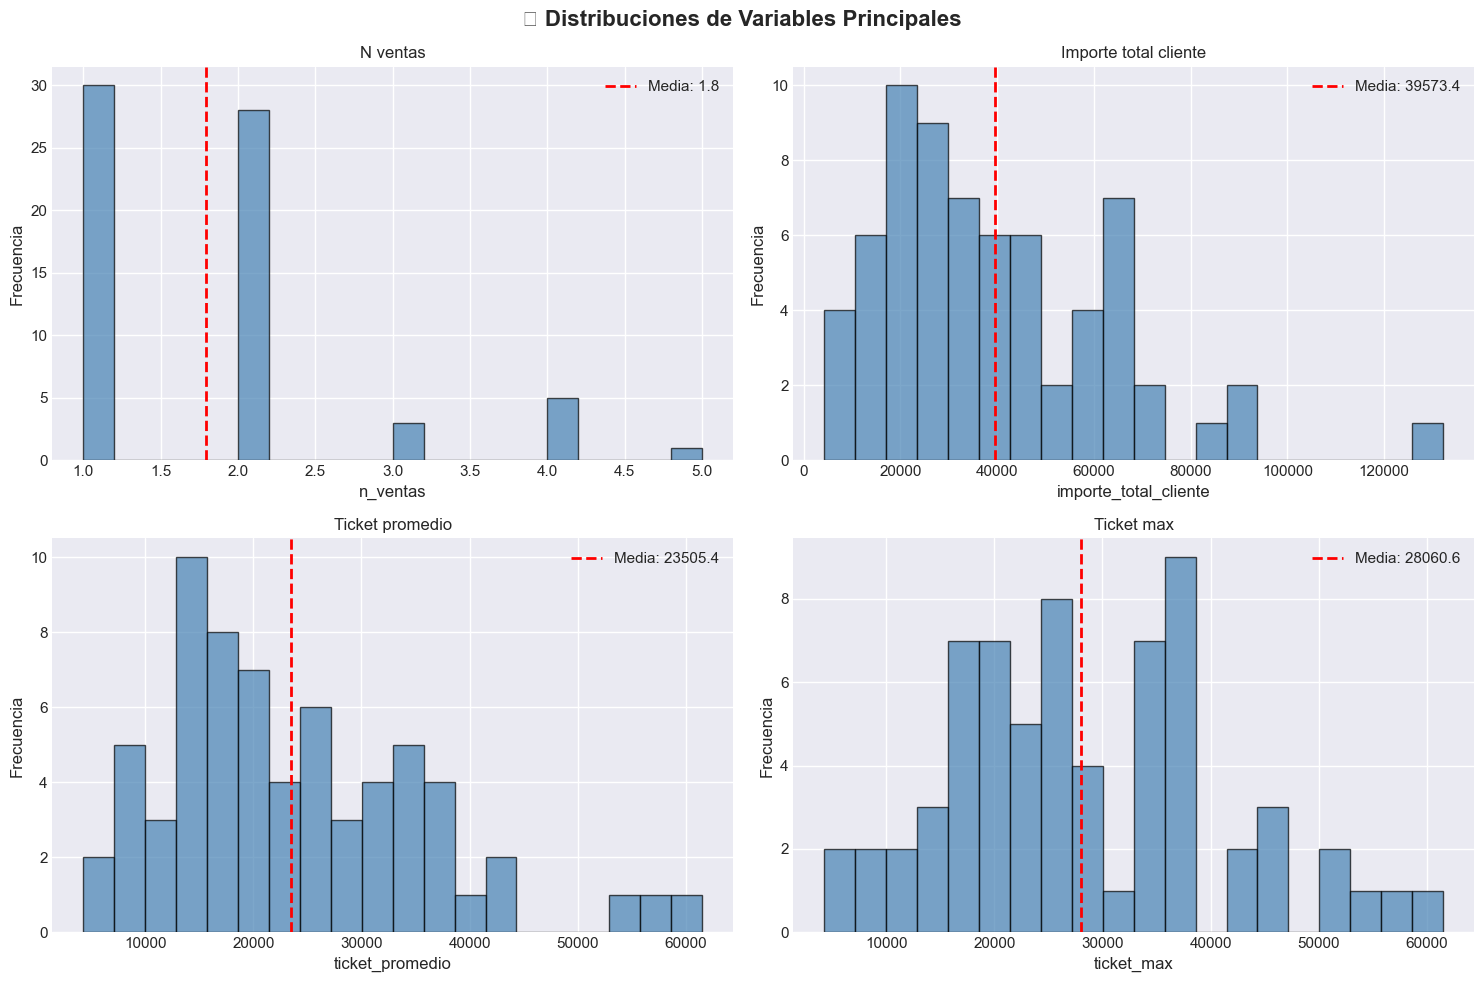

In [131]:
# Visualización de distribuciones de variables principales
main_cols = ['n_ventas', 'importe_total_cliente', 'ticket_promedio', 'ticket_max', 'ticket_min', 'desvio_ticket',
             'pct_importe_alimentos', 'pct_importe_limpieza', 'pct_ventas_efectivo', 'pct_ventas_qr', 'pct_ventas_tarjeta',
             'pct_ventas_transferencia', 'antiguedad_cliente_dias', 'ventas_por_mes', 'lineas_promedio_por_venta', 'cantidad_promedio_por_venta']

num_plots = min(4, len(main_cols))
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📊 Distribuciones de Variables Principales', fontsize=16, fontweight='bold')

for idx, col in enumerate(main_cols[:4]):
    if col in df.columns:
        ax = axes[idx // 2, idx % 2]
        ax.hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
        ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df[col].mean():.1f}')
        ax.set_title(col.replace('_', ' ').capitalize())
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        ax.legend()
    else:
        axes[idx // 2, idx % 2].set_visible(False)

plt.tight_layout()
plt.show()

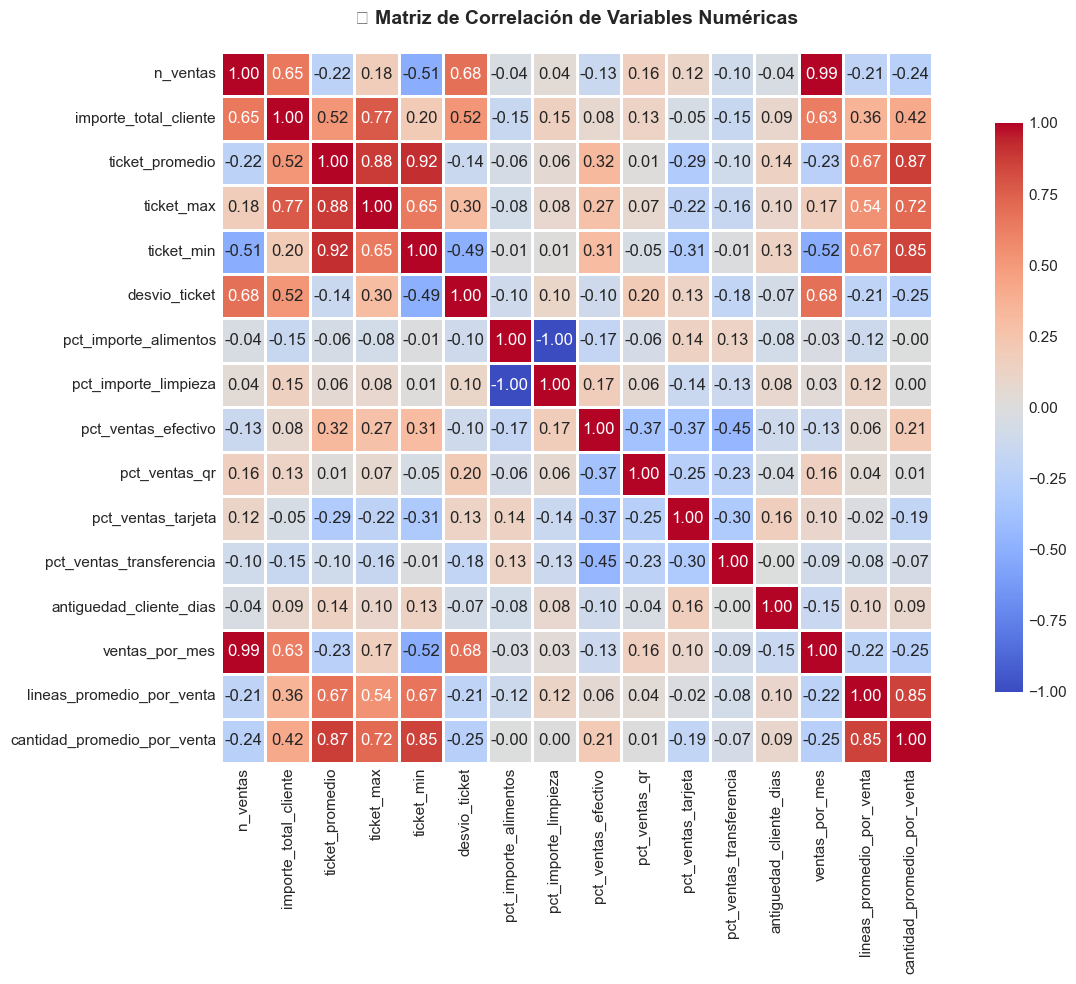


🔗 CORRELACIONES FUERTES (|r| > 0.7)


,Variable 1,Variable 2,Correlación
0,n_ventas,ventas_por_mes,0.992232
3,ticket_promedio,ticket_min,0.920638
2,ticket_promedio,ticket_max,0.882658
4,ticket_promedio,cantidad_promedio_por_venta,0.874312
8,lineas_promedio_por_venta,cantidad_promedio_por_venta,0.854210
6,ticket_min,cantidad_promedio_por_venta,0.852377
1,importe_total_cliente,ticket_max,0.767018
5,ticket_max,cantidad_promedio_por_venta,0.715839
7,pct_importe_alimentos,pct_importe_limpieza,-1.000000


In [132]:
# Matriz de correlación (solo variables numéricas)
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('id_cliente', errors='ignore')
plt.figure(figsize=(14, 10))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('🔥 Matriz de Correlación de Variables Numéricas', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlaciones fuertes
print("\n" + "="*80)
print("🔗 CORRELACIONES FUERTES (|r| > 0.7)")
print("="*80)
correlaciones_fuertes = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            correlaciones_fuertes.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlación': correlation_matrix.iloc[i, j]
            })

if correlaciones_fuertes:
    df_corr = pd.DataFrame(correlaciones_fuertes).sort_values('Correlación', ascending=False)
    display(df_corr)
else:
    print("No se encontraron correlaciones > 0.7")

## 4️⃣ Preprocesamiento para Clustering

In [133]:
# Preparar datos para clustering (solo variables numéricas)
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('id_cliente', errors='ignore')
X_clustering = df[numeric_cols].copy()

print(f"\n✅ Dataset preparado:")
print(f"   - Filas: {X_clustering.shape[0]}")
print(f"   - Features: {X_clustering.shape[1]}")
print(f"   - Columnas: {list(X_clustering.columns)}")

# Verificar outliers con método IQR
print("\n" + "="*80)
print("🔍 DETECCIÓN DE OUTLIERS (Método IQR)")
print("="*80)

outliers_report = []
for col in X_clustering.columns:
    Q1 = X_clustering[col].quantile(0.25)
    Q3 = X_clustering[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((X_clustering[col] < lower_bound) | (X_clustering[col] > upper_bound)).sum()
    if outliers > 0:
        outliers_report.append({
            'Variable': col,
            'Outliers': outliers,
            'Porcentaje': f"{(outliers/len(X_clustering)*100):.1f}%"
        })

if outliers_report:
    df_outliers = pd.DataFrame(outliers_report).sort_values('Outliers', ascending=False)
    display(df_outliers)
else:
    print("✅ No se detectaron outliers significativos")

# Escalar features (CRÍTICO para K-Means)
print("\n" + "="*80)
print("⚖️ ESCALADO DE FEATURES (StandardScaler)")
print("="*80)

scaler_clustering = StandardScaler()
X_scaled = scaler_clustering.fit_transform(X_clustering)

print(f"✅ Features escaladas: {X_scaled.shape}")
print(f"   Media: {X_scaled.mean():.6f}")
print(f"   Desv. Est.: {X_scaled.std():.6f}")

# Crear DataFrame escalado para visualización
X_scaled_df = pd.DataFrame(X_scaled, columns=X_clustering.columns, index=X_clustering.index)
print(f"\n📊 Primeras 3 filas escaladas:")
display(X_scaled_df.head(3))


✅ Dataset preparado:
   - Filas: 67
   - Features: 16
   - Columnas: ['n_ventas', 'importe_total_cliente', 'ticket_promedio', 'ticket_max', 'ticket_min', 'desvio_ticket', 'pct_importe_alimentos', 'pct_importe_limpieza', 'pct_ventas_efectivo', 'pct_ventas_qr', 'pct_ventas_tarjeta', 'pct_ventas_transferencia', 'antiguedad_cliente_dias', 'ventas_por_mes', 'lineas_promedio_por_venta', 'cantidad_promedio_por_venta']

🔍 DETECCIÓN DE OUTLIERS (Método IQR)


,Variable,Outliers,Porcentaje
6,pct_importe_alimentos,9,13.4%
7,pct_importe_limpieza,9,13.4%
0,n_ventas,6,9.0%
8,ventas_por_mes,5,7.5%
4,ticket_min,2,3.0%
1,importe_total_cliente,1,1.5%
2,ticket_promedio,1,1.5%
3,ticket_max,1,1.5%
5,desvio_ticket,1,1.5%



⚖️ ESCALADO DE FEATURES (StandardScaler)
✅ Features escaladas: (67, 16)
   Media: 0.000000
   Desv. Est.: 1.000000

📊 Primeras 3 filas escaladas:


,n_ventas,importe_total_cliente,ticket_promedio,ticket_max,ticket_min,desvio_ticket,pct_importe_alimentos,pct_importe_limpieza,pct_ventas_efectivo,pct_ventas_qr,pct_ventas_tarjeta,pct_ventas_transferencia,antiguedad_cliente_dias,ventas_por_mes,lineas_promedio_por_venta,cantidad_promedio_por_venta
0,0.222531,1.383271,1.056744,0.664750,1.231898,-0.816192,0.333204,-0.333204,-0.809091,-0.677204,0.878478,0.692393,1.567003,-0.015517,1.348251,1.014232
1,-0.842438,-0.733127,-0.112619,-0.470418,0.226324,-0.857677,0.333204,-0.333204,1.587770,-0.677204,-0.564121,-0.661405,1.532659,-0.881906,-1.756579,-1.000101
2,-0.842438,-0.263546,0.814629,0.417788,1.034549,-0.857677,0.333204,-0.333204,-0.809091,-0.677204,-0.564121,2.046190,1.498315,-0.881906,0.904704,1.517815


## 5️⃣ Determinación del Número Óptimo de Clusters (Método del Codo)

📐 DETERMINANDO NÚMERO ÓPTIMO DE CLUSTERS

Probando diferentes valores de K...
  K=2: Inertia=851.08, Silhouette=0.202
  K=3: Inertia=707.51, Silhouette=0.198
  K=4: Inertia=613.43, Silhouette=0.193
  K=5: Inertia=551.44, Silhouette=0.187
  K=6: Inertia=481.80, Silhouette=0.220
  K=7: Inertia=437.91, Silhouette=0.220
  K=8: Inertia=382.17, Silhouette=0.244
  K=9: Inertia=355.70, Silhouette=0.246
  K=10: Inertia=330.28, Silhouette=0.241


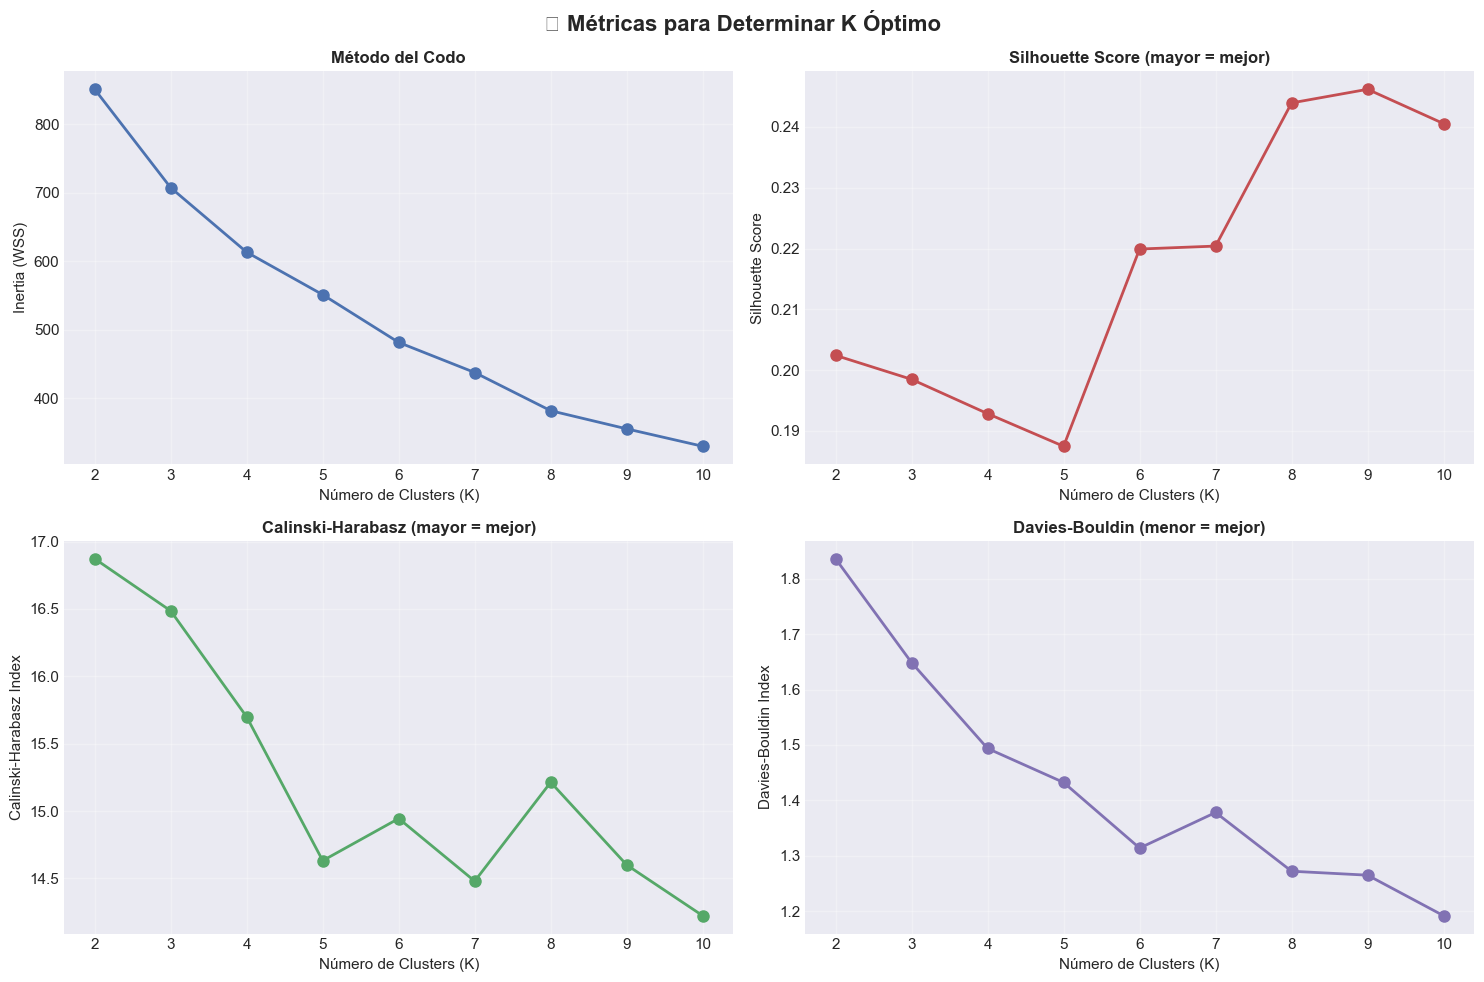


💡 RECOMENDACIÓN
✅ K óptimo según Silhouette: 9
✅ K óptimo según Calinski-Harabasz: 2
✅ K óptimo según Davies-Bouldin: 10

🎯 SELECCIÓN FINAL: K = 3 (segmentos VIP, Regular, Ocasional)


In [134]:
# Método del Codo + Silhouette Score
print("="*80)
print("📐 DETERMINANDO NÚMERO ÓPTIMO DE CLUSTERS")
print("="*80)

K_range = range(2, 11)
inertias = []
silhouettes = []
ch_scores = []
db_scores = []

print("\nProbando diferentes valores de K...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    
    print(f"  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouettes[-1]:.3f}")

# Visualizar métricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📊 Métricas para Determinar K Óptimo', fontsize=16, fontweight='bold')

# Método del Codo (Inertia)
axes[0, 0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Número de Clusters (K)', fontsize=11)
axes[0, 0].set_ylabel('Inertia (WSS)', fontsize=11)
axes[0, 0].set_title('Método del Codo', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette Score (mayor es mejor)
axes[0, 1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Número de Clusters (K)', fontsize=11)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 1].set_title('Silhouette Score (mayor = mejor)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Calinski-Harabasz Index (mayor es mejor)
axes[1, 0].plot(K_range, ch_scores, 'go-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Número de Clusters (K)', fontsize=11)
axes[1, 0].set_ylabel('Calinski-Harabasz Index', fontsize=11)
axes[1, 0].set_title('Calinski-Harabasz (mayor = mejor)', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Davies-Bouldin Index (menor es mejor)
axes[1, 1].plot(K_range, db_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Número de Clusters (K)', fontsize=11)
axes[1, 1].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[1, 1].set_title('Davies-Bouldin (menor = mejor)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Recomendación
print("\n" + "="*80)
print("💡 RECOMENDACIÓN")
print("="*80)
best_k_silhouette = K_range[np.argmax(silhouettes)]
print(f"✅ K óptimo según Silhouette: {best_k_silhouette}")
print(f"✅ K óptimo según Calinski-Harabasz: {K_range[np.argmax(ch_scores)]}")
print(f"✅ K óptimo según Davies-Bouldin: {K_range[np.argmin(db_scores)]}")
print(f"\n🎯 SELECCIÓN FINAL: K = 3 (segmentos VIP, Regular, Ocasional)")

## 6️⃣ Entrenamiento del Modelo K-Means (K=3)

🎯 ENTRENAMIENTO MODELO K-MEANS

Entrenando modelo con K=3...
✅ Modelo entrenado exitosamente

📊 Información del modelo:
   - Clusters: 3
   - Iteraciones: 5
   - Inertia: 707.51

📊 DISTRIBUCIÓN DE CLUSTERS
cluster_label
Segmento A    19
Segmento B    19
Segmento C    29
Name: count, dtype: int64

Total: 67 clientes


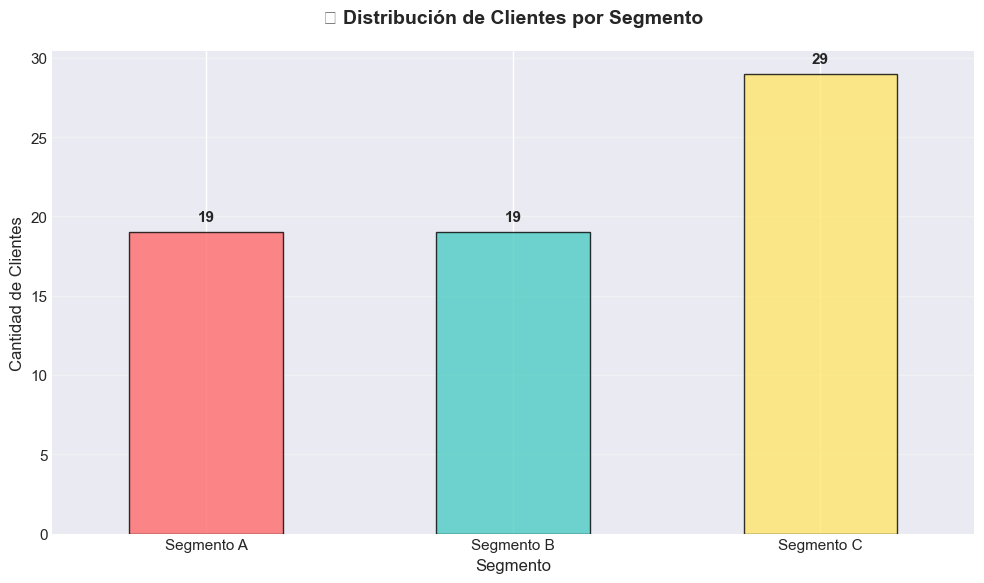

In [135]:
# Entrenar modelo K-Means con K=3
print("="*80)
print("🎯 ENTRENAMIENTO MODELO K-MEANS")
print("="*80)

K_OPTIMO = 3

kmeans_final = KMeans(
    n_clusters=K_OPTIMO,
    random_state=42,
    n_init=20,  # Múltiples inicializaciones
    max_iter=500,
    algorithm='lloyd'
)

print(f"\nEntrenando modelo con K={K_OPTIMO}...")
clusters = kmeans_final.fit_predict(X_scaled)

print("✅ Modelo entrenado exitosamente")
print(f"\n📊 Información del modelo:")
print(f"   - Clusters: {kmeans_final.n_clusters}")
print(f"   - Iteraciones: {kmeans_final.n_iter_}")
print(f"   - Inertia: {kmeans_final.inertia_:.2f}")

# Agregar clusters al dataset original
df['cluster'] = clusters
df['cluster_label'] = df['cluster'].map({
    0: 'Segmento A',
    1: 'Segmento B',
    2: 'Segmento C'
})

# Distribución de clusters
print("\n" + "="*80)
print("📊 DISTRIBUCIÓN DE CLUSTERS")
print("="*80)
cluster_counts = df['cluster_label'].value_counts().sort_index()
print(cluster_counts)
print(f"\nTotal: {len(df)} clientes")

# Visualizar distribución
plt.figure(figsize=(10, 6))
ax = cluster_counts.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#FFE66D'], edgecolor='black', alpha=0.8)
plt.title('📊 Distribución de Clientes por Segmento', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Segmento', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(cluster_counts):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7️⃣ Evaluación del Modelo de Clustering

In [136]:
# Métricas de evaluación de clustering
print("="*80)
print("📈 MÉTRICAS DE EVALUACIÓN DEL CLUSTERING")
print("="*80)

silhouette = silhouette_score(X_scaled, clusters)
ch_score = calinski_harabasz_score(X_scaled, clusters)
db_score = davies_bouldin_score(X_scaled, clusters)

print(f"\n✅ Silhouette Score: {silhouette:.4f}")
print("   → Rango: [-1, 1]")
print("   → Interpretación: Valores cercanos a 1 indican clusters bien separados")
print(f"   → Estado: {'✅ Excelente' if silhouette > 0.5 else '⚠️ Moderado' if silhouette > 0.3 else '❌ Bajo'}")

print(f"\n✅ Calinski-Harabasz Index: {ch_score:.2f}")
print("   → Interpretación: Mayor valor indica mejor separación")
print(f"   → Estado: {'✅ Bueno' if ch_score > 100 else '⚠️ Moderado'}")

print(f"\n✅ Davies-Bouldin Index: {db_score:.4f}")
print("   → Rango: [0, ∞)")
print("   → Interpretación: Valores cercanos a 0 indican mejor clustering")
print(f"   → Estado: {'✅ Excelente' if db_score < 1 else '⚠️ Moderado' if db_score < 1.5 else '❌ Alto'}")

print(f"\n✅ Inertia (WSS): {kmeans_final.inertia_:.2f}")
print("   → Interpretación: Suma de distancias al cuadrado intra-cluster")

# Crear tabla resumen
metricas_df = pd.DataFrame({
    'Métrica': ['Silhouette Score', 'Calinski-Harabasz', 'Davies-Bouldin', 'Inertia'],
    'Valor': [f"{silhouette:.4f}", f"{ch_score:.2f}", f"{db_score:.4f}", f"{kmeans_final.inertia_:.2f}"],
    'Óptimo': ['Cercano a 1', 'Mayor', 'Cercano a 0', 'Menor']
})

print("\n" + "="*80)
print("📋 RESUMEN DE MÉTRICAS")
print("="*80)
display(metricas_df)

📈 MÉTRICAS DE EVALUACIÓN DEL CLUSTERING

✅ Silhouette Score: 0.1985
   → Rango: [-1, 1]
   → Interpretación: Valores cercanos a 1 indican clusters bien separados
   → Estado: ❌ Bajo

✅ Calinski-Harabasz Index: 16.49
   → Interpretación: Mayor valor indica mejor separación
   → Estado: ⚠️ Moderado

✅ Davies-Bouldin Index: 1.6485
   → Rango: [0, ∞)
   → Interpretación: Valores cercanos a 0 indican mejor clustering
   → Estado: ❌ Alto

✅ Inertia (WSS): 707.51
   → Interpretación: Suma de distancias al cuadrado intra-cluster

📋 RESUMEN DE MÉTRICAS


,Métrica,Valor,Óptimo
0,Silhouette Score,0.1985,Cercano a 1
1,Calinski-Harabasz,16.49,Mayor
2,Davies-Bouldin,1.6485,Cercano a 0
3,Inertia,707.51,Menor


## 8️⃣ Visualización de Clusters con PCA

Reduciremos las dimensiones a 2D para visualizar los clusters en un plano.

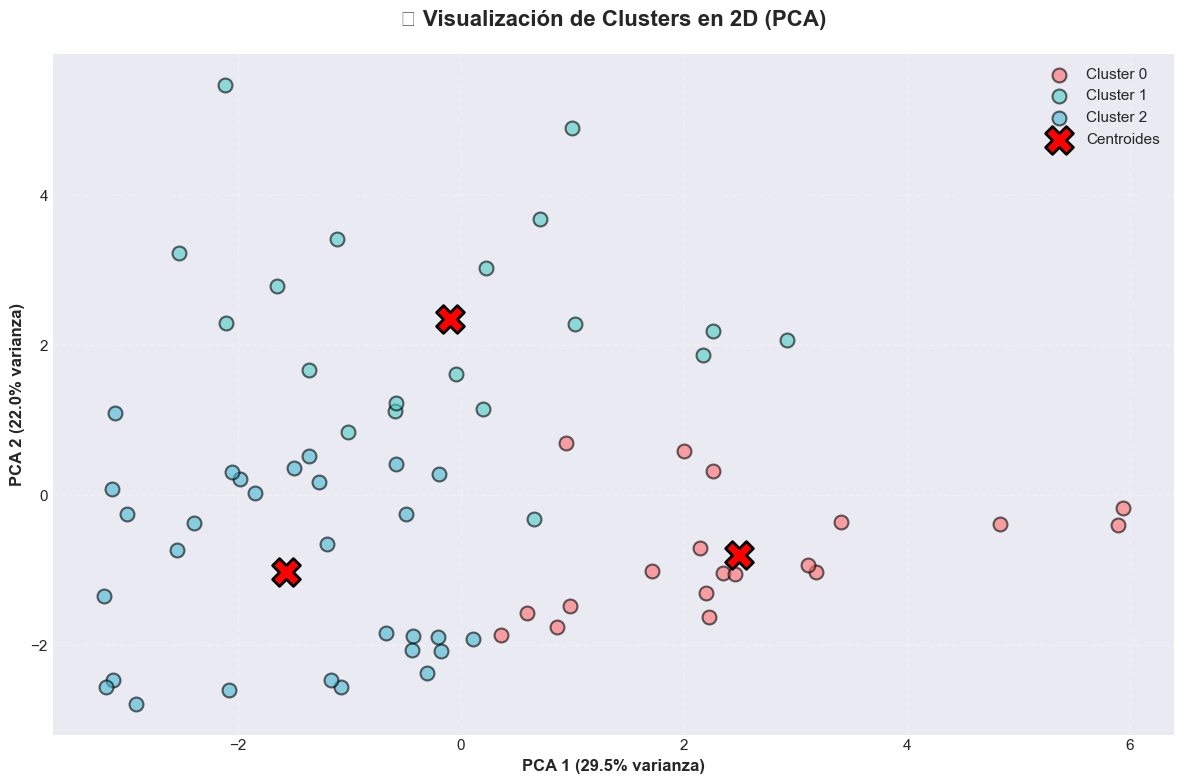


📊 Varianza explicada por PCA:
   - PCA1: 29.50%
   - PCA2: 22.01%
   - Total: 51.51%


In [137]:
# Reducción de dimensionalidad con PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Agregar componentes PCA al dataframe
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Visualización de clusters en 2D
fig, ax = plt.subplots(figsize=(12, 8))

colores = ['#FF6B6B', '#4ECDC4', '#45B7D1']
nombres_clusters = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(3):
    mask = clusters == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=colores[i], label=nombres_clusters[i],
               s=100, alpha=0.6, edgecolors='black', linewidths=1.5)

# Agregar centroides
centroides_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1], 
           c='red', marker='X', s=400, edgecolors='black', linewidths=2,
           label='Centroides', zorder=5)

ax.set_xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12, fontweight='bold')
ax.set_title('🎯 Visualización de Clusters en 2D (PCA)', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\n📊 Varianza explicada por PCA:")
print(f"   - PCA1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"   - PCA2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"   - Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

## 9️⃣ Perfiles de Segmentos

Analizaremos las características promedio de cada cluster para crear perfiles de clientes.

In [138]:
# Calcular perfiles de cada cluster con columnas reales
perfil_cols = ['n_ventas', 'importe_total_cliente', 'ticket_promedio', 'ticket_max', 'ticket_min', 'desvio_ticket',
               'pct_importe_alimentos', 'pct_importe_limpieza', 'pct_ventas_efectivo', 'pct_ventas_qr', 'pct_ventas_tarjeta',
               'pct_ventas_transferencia', 'antiguedad_cliente_dias', 'ventas_por_mes', 'lineas_promedio_por_venta', 'cantidad_promedio_por_venta']

perfiles = df.groupby('cluster')[perfil_cols].agg(['mean', 'median']).round(2)

print("="*80)
print("📊 PERFILES DE SEGMENTOS - ESTADÍSTICAS DESCRIPTIVAS")
print("="*80)
display(perfiles)

# Crear perfiles simples solo con medias
perfiles_simple = df.groupby('cluster')[perfil_cols].mean().round(2)

print("\n" + "="*80)
print("📋 PERFILES SIMPLIFICADOS (MEDIAS)")
print("="*80)
display(perfiles_simple)

# Tamaños de cada cluster
tamanos = df['cluster'].value_counts().sort_index()
print("\n" + "="*80)
print("👥 TAMAÑO DE CADA SEGMENTO")
print("="*80)
for cluster, count in tamanos.items():
    porcentaje = (count / len(df)) * 100
    print(f"   Cluster {cluster}: {count} clientes ({porcentaje:.1f}%)")

📊 PERFILES DE SEGMENTOS - ESTADÍSTICAS DESCRIPTIVAS


n_ventas        importe_total_cliente          ticket_promedio          ticket_max          ticket_min  \
            mean median                  mean   median            mean   median       mean   median       mean   
cluster                                                                                                          
0           1.16    1.0              41046.58  36639.0        35932.47  35240.0   36302.16  35240.0   35562.79   
1           2.74    2.0              63497.11  64716.0        24468.35  24433.5   35499.42  35856.0   13782.00   
2           1.59    2.0              22934.03  21839.0        14732.72  14954.5   17787.34  16531.0   11624.76   

                 desvio_ticket           pct_importe_alimentos        pct_importe_limpieza        pct_ventas_efectivo  \
          median          mean    median                  mean median                 mean median                mean   
cluster                                                                                                                 
0        35240.0        522.81      0.00                100.00  100.0                 0.00    0.0               60.53   
1        11832.0      12465.64  13257.55                 90.22  100.0                 9.78    0.0               42.72   
2        11184.0       4257.37   1504.72                100.00  100.0                 0.00    0.0               10.34   

               pct_ventas_qr        pct_ventas_tarjeta        pct_ventas_transferencia        antiguedad_cliente_dias  \
        median          mean median               mean median                     mean median                    mean   
cluster                                                                                                                 
0        100.0         18.42    0.0               2.63    0.0                    18.42    0.0                  495.68   
1         50.0         27.63   25.0              16.32    0.0                    13.33    0.0                  500.05   
2          0.0         21.26    0.0              32.76    0.0                    35.63    0.0                  499.03   

               ventas_por_mes        lineas_promedio_por_venta        cantidad_promedio_por_venta         
        median           mean median                      mean median                        mean median  
cluster                                                                                                   
0        508.0           0.07   0.06                      3.97    4.0                       13.34   13.0  
1        497.0           0.17   0.13                      3.00    3.0                        8.61    8.0  
2        502.0           0.10   0.12                      2.32    2.0                        6.34    6.0


📋 PERFILES SIMPLIFICADOS (MEDIAS)


,n_ventas,importe_total_cliente,ticket_promedio,ticket_max,ticket_min,desvio_ticket,pct_importe_alimentos,pct_importe_limpieza,pct_ventas_efectivo,pct_ventas_qr,pct_ventas_tarjeta,pct_ventas_transferencia,antiguedad_cliente_dias,ventas_por_mes,lineas_promedio_por_venta,cantidad_promedio_por_venta
cluster,,,,,,,,,,,,,,,,
0,1.16,41046.58,35932.47,36302.16,35562.79,522.81,100.00,0.00,60.53,18.42,2.63,18.42,495.68,0.07,3.97,13.34
1,2.74,63497.11,24468.35,35499.42,13782.00,12465.64,90.22,9.78,42.72,27.63,16.32,13.33,500.05,0.17,3.00,8.61
2,1.59,22934.03,14732.72,17787.34,11624.76,4257.37,100.00,0.00,10.34,21.26,32.76,35.63,499.03,0.10,2.32,6.34



👥 TAMAÑO DE CADA SEGMENTO
   Cluster 0: 19 clientes (28.4%)
   Cluster 1: 19 clientes (28.4%)
   Cluster 2: 29 clientes (43.3%)


## 🔟 Heatmap de Características por Cluster

Visualización de las diferencias entre clusters mediante un mapa de calor.

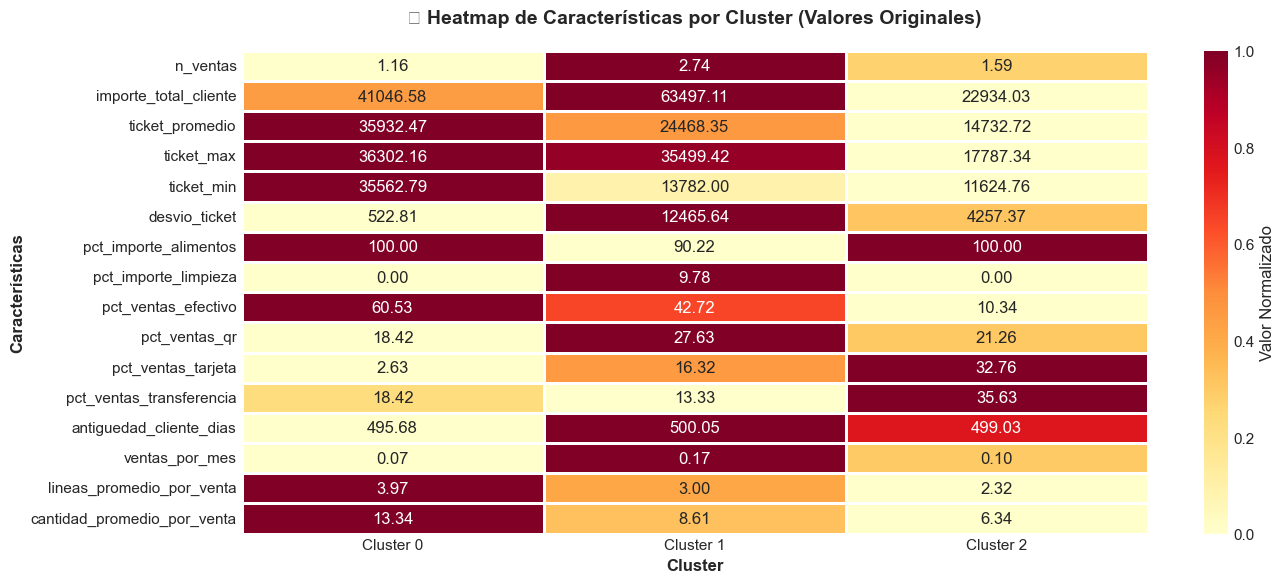

In [139]:
# Heatmap de características promedio por cluster
fig, ax = plt.subplots(figsize=(14, 6))

# Normalizar valores para mejor visualización (min-max scaling)
perfiles_norm = perfiles_simple.copy()
for col in perfiles_norm.columns:
    min_val = perfiles_norm[col].min()
    max_val = perfiles_norm[col].max()
    if max_val - min_val > 0:
        perfiles_norm[col] = (perfiles_norm[col] - min_val) / (max_val - min_val)

sns.heatmap(perfiles_norm.T, annot=perfiles_simple.T, fmt='.2f', 
            cmap='YlOrRd', cbar_kws={'label': 'Valor Normalizado'},
            linewidths=2, linecolor='white', ax=ax)

ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax.set_ylabel('Características', fontsize=12, fontweight='bold')
ax.set_title('🔥 Heatmap de Características por Cluster (Valores Originales)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticklabels(['Cluster 0', 'Cluster 1', 'Cluster 2'], rotation=0)
plt.tight_layout()
plt.show()

## 1️⃣1️⃣ Comparación de Variables Clave por Cluster (Boxplots)

Visualización de la distribución de las variables más importantes en cada cluster.

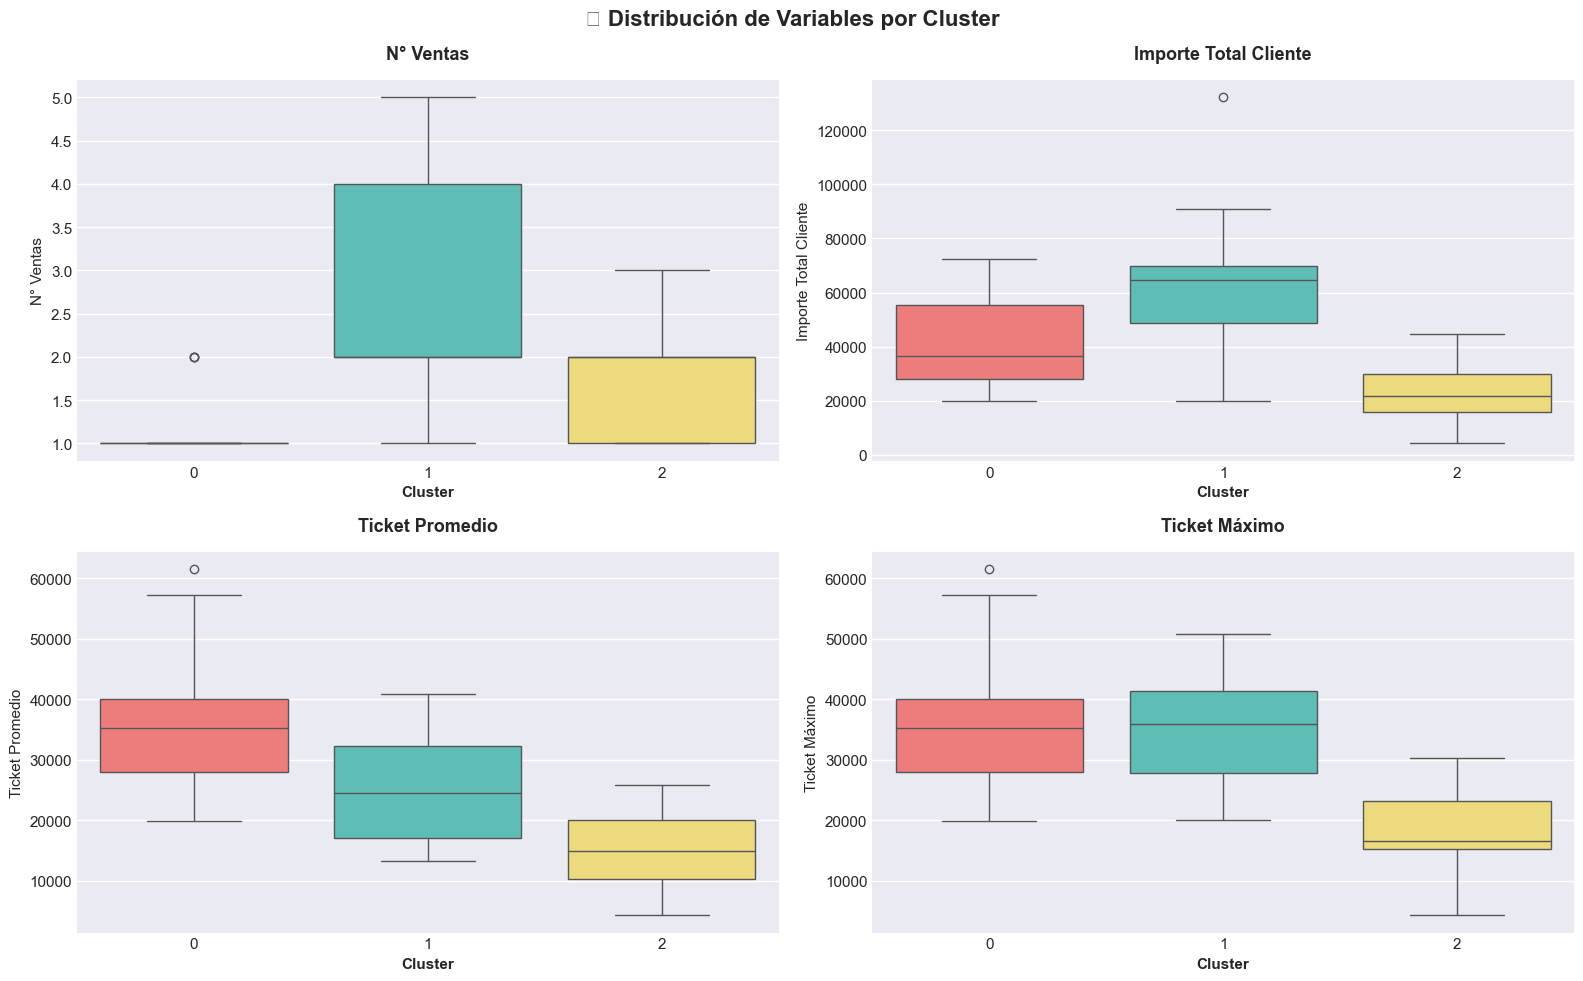

In [140]:
# Boxplots de variables principales por cluster
variables = ['n_ventas', 'importe_total_cliente', 'ticket_promedio', 'ticket_max']
titulos = ['N° Ventas', 'Importe Total Cliente', 'Ticket Promedio', 'Ticket Máximo']
colores_palette = ['#FF6B6B', '#4ECDC4', '#FFE66D']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('📦 Distribución de Variables por Cluster', fontsize=16, fontweight='bold')

for idx, (var, titulo) in enumerate(zip(variables, titulos)):
    ax = axes[idx // 2, idx % 2]
    if var in df.columns:
        sns.boxplot(data=df, x='cluster', y=var, palette=colores_palette, ax=ax)
        ax.set_title(titulo, fontsize=13, fontweight='bold', pad=15)
        ax.set_xlabel('Cluster', fontsize=11, fontweight='bold')
        ax.set_ylabel(titulo, fontsize=11)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()


## 1️⃣2️⃣ Interpretación de Segmentos

Interpretación del negocio basada en los perfiles identificados.

In [141]:
# Ejemplo de interpretación de un cliente (usando variables reales)
cliente_id = 1  # Cambia el ID según corresponda
datos = df[df['id_cliente'] == cliente_id].squeeze()

print(f"{'='*80}")
print(f"🧑‍💼 Perfil del Cliente ID: {cliente_id}")
print(f"Ciudad: {datos['ciudad']}")
print(f"Segmento: {datos['cluster_label']}")
print(f"{'='*80}")

print(f"\n🔹 Características principales:")
print(f"   • N° Ventas: {datos['n_ventas']}")
print(f"   • Importe Total Cliente: ${datos['importe_total_cliente']:.2f}")
print(f"   • Ticket Promedio: ${datos['ticket_promedio']:.2f}")
print(f"   • Ticket Máximo: ${datos['ticket_max']:.2f}")
print(f"   • Ticket Mínimo: ${datos['ticket_min']:.2f}")
print(f"   • Desvío Ticket: ${datos['desvio_ticket']:.2f}")
print(f"   • % Importe Alimentos: {datos['pct_importe_alimentos']:.1f}%")
print(f"   • % Importe Limpieza: {datos['pct_importe_limpieza']:.1f}%")
print(f"   • % Ventas Efectivo: {datos['pct_ventas_efectivo']:.1f}%")
print(f"   • % Ventas QR: {datos['pct_ventas_qr']:.1f}%")
print(f"   • % Ventas Tarjeta: {datos['pct_ventas_tarjeta']:.1f}%")
print(f"   • % Ventas Transferencia: {datos['pct_ventas_transferencia']:.1f}%")
print(f"   • Antigüedad Cliente (días): {datos['antiguedad_cliente_dias']}")
print(f"   • Ventas por Mes: {datos['ventas_por_mes']:.2f}")
print(f"   • Líneas Promedio por Venta: {datos['lineas_promedio_por_venta']:.2f}")
print(f"   • Cantidad Promedio por Venta: {datos['cantidad_promedio_por_venta']:.2f}")

🧑‍💼 Perfil del Cliente ID: 1
Ciudad: carlos paz
Segmento: Segmento A

🔹 Características principales:
   • N° Ventas: 2
   • Importe Total Cliente: $72448.00
   • Ticket Promedio: $36224.00
   • Ticket Máximo: $36413.00
   • Ticket Mínimo: $36035.00
   • Desvío Ticket: $267.29
   • % Importe Alimentos: 100.0%
   • % Importe Limpieza: 0.0%
   • % Ventas Efectivo: 0.0%
   • % Ventas QR: 0.0%
   • % Ventas Tarjeta: 50.0%
   • % Ventas Transferencia: 50.0%
   • Antigüedad Cliente (días): 544
   • Ventas por Mes: 0.11
   • Líneas Promedio por Venta: 4.50
   • Cantidad Promedio por Venta: 13.00


## 1️⃣3️⃣ Exportar Modelo y Resultados

Guardar el modelo entrenado, el scaler y los perfiles de segmentos para uso futuro.

In [142]:
# Crear carpeta para modelos si no existe
import os
os.makedirs('modelos', exist_ok=True)

# Guardar modelo de clustering
joblib.dump(kmeans_final, 'modelos/kmeans_segmentacion.pkl')
print("✅ Modelo K-Means guardado: modelos/kmeans_segmentacion.pkl")

# Guardar scaler
joblib.dump(scaler_clustering, 'modelos/scaler_clustering.pkl')
print("✅ Scaler guardado: modelos/scaler_clustering.pkl")

# Guardar PCA
joblib.dump(pca, 'modelos/pca_clustering.pkl')
print("✅ PCA guardado: modelos/pca_clustering.pkl")

# Exportar perfiles de segmentos
perfiles_simple.to_csv('modelos/perfiles_segmentos.csv')
print("✅ Perfiles exportados: modelos/perfiles_segmentos.csv")

# Exportar dataset con clusters asignados
df_export = df.copy()
df_export.to_csv('modelos/clientes_con_clusters.csv', index=False)
print("✅ Dataset con clusters guardado: modelos/clientes_con_clusters.csv")

print("\n" + "="*80)
print("🎉 MODELO DE SEGMENTACIÓN COMPLETADO Y EXPORTADO")
print("="*80)

✅ Modelo K-Means guardado: modelos/kmeans_segmentacion.pkl
✅ Scaler guardado: modelos/scaler_clustering.pkl
✅ PCA guardado: modelos/pca_clustering.pkl
✅ Perfiles exportados: modelos/perfiles_segmentos.csv
✅ Dataset con clusters guardado: modelos/clientes_con_clusters.csv

🎉 MODELO DE SEGMENTACIÓN COMPLETADO Y EXPORTADO


---

# 🔮 PARTE 2: PREDICCIÓN DE CHURN (Clasificación)

**Objetivo:** Predecir qué clientes tienen mayor probabilidad de abandonar el negocio (churn) basándonos en su comportamiento de compra.

## 1️⃣4️⃣ Definición de Target (Churn)

Definir la variable objetivo: un cliente se considera "churned" si su recencia es mayor a 60 días.

**ℹ️ NOTA METODOLÓGICA - Data Leakage (qué haría mal un modelo):**  
En muchos ejemplos educativos se usa `recency` tanto para definir el target como feature predictora, lo que sí constituiría **fuga de información (data leakage)** y tendería a inflar las métricas.

En este proyecto:

- Definimos `churn` a partir de `recency` (p.ej. recency > 60 días).
- **Excluimos `recency` de las features del modelo** (`X_churn`) para evitar fuga de información.
- En un entorno productivo ideal, además se recomendaría definir `churn` con una ventana futura (ej.: “no compra en los próximos N días” usando solo información pasada).

🎯 DEFINICIÓN DE CHURN

✅ Umbral de churn: 60 días de recencia
   - Churn = 1: Cliente inactivo (recency > 60 días)
   - Churn = 0: Cliente activo (recency ≤ 60 días)

ℹ️ NOTA TÉCNICA SOBRE DATA LEAKAGE
La variable 'churn' se define a partir de 'recency' (p.ej. recency > 60 días).
Si además usáramos 'recency' como feature del modelo, habría FUGA DE INFORMACIÓN
(data leakage) y las métricas se verían artificialmente infladas.

En este modelo de churn:
   • 'recency' se usa SOLO para definir el target 'churn'.
   • En las features EXCLUIMOS 'recency'.

📊 Distribución de Churn:
   - Clientes Activos (0): 32 (47.8%)
   - Clientes en Riesgo (1): 35 (52.2%)


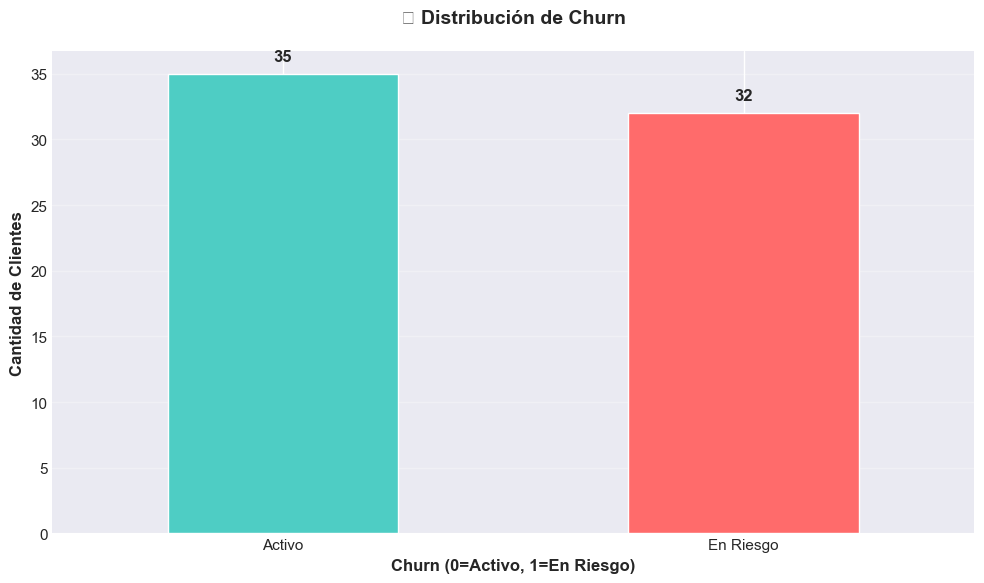

In [143]:
# ============================================================
# BLOQUE 1 – Construcción de df_churn + recency + churn
# ============================================================

# 1) Dataset transaccional (para calcular recency)
df_tx = pd.read_csv('db/Base_Final_Aurelion.csv')
df_tx['fecha'] = pd.to_datetime(df_tx['fecha'])

# Tomamos como fecha de referencia la última fecha de compra registrada
fecha_referencia = df_tx['fecha'].max()

# Última compra por cliente
recency_df = (
    df_tx
    .groupby('id_cliente')['fecha']
    .max()
    .reset_index()
    .rename(columns={'fecha': 'ultima_compra'})
)

# Recency = días desde la última compra hasta la fecha de referencia
recency_df['recency'] = (fecha_referencia - recency_df['ultima_compra']).dt.days

# 2) Dataset a nivel cliente (base para ML)
df_churn = pd.read_csv('db/base_final_ML_clientes.csv')

# Unir recency por id_cliente
df_churn = df_churn.merge(
    recency_df[['id_cliente', 'recency']],
    on='id_cliente',
    how='left'
)

# Definir umbral de churn: recencia > 60 días
umbral_churn = 60
df_churn['churn'] = (df_churn['recency'] > umbral_churn).astype(int)

print("="*80)
print("🎯 DEFINICIÓN DE CHURN")
print("="*80)
print(f"\n✅ Umbral de churn: {umbral_churn} días de recencia")
print(f"   - Churn = 1: Cliente inactivo (recency > {umbral_churn} días)")
print(f"   - Churn = 0: Cliente activo (recency ≤ {umbral_churn} días)")

print("\n" + "="*80)
print("ℹ️ NOTA TÉCNICA SOBRE DATA LEAKAGE")
print("="*80)
print("La variable 'churn' se define a partir de 'recency' (p.ej. recency > 60 días).")
print("Si además usáramos 'recency' como feature del modelo, habría FUGA DE INFORMACIÓN")
print("(data leakage) y las métricas se verían artificialmente infladas.")
print("\nEn este modelo de churn:")
print("   • 'recency' se usa SOLO para definir el target 'churn'.")
print("   • En las features EXCLUIMOS 'recency'.")
print("="*80)

# Distribución de churn
churn_dist = df_churn['churn'].value_counts()
print(f"\n📊 Distribución de Churn:")
print(f"   - Clientes Activos (0): {churn_dist[0]} ({churn_dist[0]/len(df_churn)*100:.1f}%)")
print(f"   - Clientes en Riesgo (1): {churn_dist[1]} ({churn_dist[1]/len(df_churn)*100:.1f}%)")

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
churn_dist.plot(kind='bar', color=['#4ECDC4', '#FF6B6B'], ax=ax)
ax.set_title('📊 Distribución de Churn', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Churn (0=Activo, 1=En Riesgo)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Clientes', fontsize=12, fontweight='bold')
ax.set_xticklabels(['Activo', 'En Riesgo'], rotation=0)
ax.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(churn_dist):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Verificar balance de clases
if churn_dist.min() / churn_dist.max() < 0.3:
    print("\n⚠️ ADVERTENCIA: Clases desbalanceadas. Se recomienda usar SMOTE o class_weight='balanced'")



## 1️⃣5️⃣ Preparación de Datos para Clasificación

Preparar las features y aplicar train-test split estratificado.
En este paso se construye la matriz de features excluyendo `id_cliente`, `churn` y `recency` para evitar data leakage.

In [144]:
# ============================================================
# BLOQUE 2 – Preparación de datos (X, y, split, escalado)
# ============================================================

# 1) Excluimos 'id_cliente', 'churn' y 'recency'
features_candidatas = df_churn.drop(['id_cliente', 'churn', 'recency'], axis=1)

# 2) Nos quedamos SOLO con columnas numéricas (evitamos strings como 'ciudad')
feature_cols = features_candidatas.select_dtypes(include=['number']).columns.tolist()

print("="*80)
print("📋 SELECCIÓN DE FEATURES NUMÉRICAS")
print("="*80)
print(f"\n✅ Total de columnas candidatas: {features_candidatas.shape[1]}")
print(f"✅ Columnas numéricas seleccionadas para el modelo de churn: {len(feature_cols)}")
print("\n📌 Features utilizadas:")
for col in feature_cols:
    print(f"   • {col}")

# Matriz final de features y target
X_churn = df_churn[feature_cols]
y_churn = df_churn['churn']

print("\n" + "="*80)
print("📋 PREPARACIÓN DE DATOS")
print("="*80)
print(f"\n✅ Features seleccionadas: {X_churn.shape[1]}")
print(f"✅ Total de observaciones: {X_churn.shape[0]}")

# Split estratificado (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

print(f"\n✅ Train set: {X_train.shape[0]} muestras ({X_train.shape[0]/len(df_churn)*100:.1f}%)")
print(f"   - Activos: {sum(y_train==0)} | En Riesgo: {sum(y_train==1)}")
print(f"✅ Test set: {X_test.shape[0]} muestras ({X_test.shape[0]/len(df_churn)*100:.1f}%)")
print(f"   - Activos: {sum(y_test==0)} | En Riesgo: {sum(y_test==1)}")

# Escalar features
scaler_churn = StandardScaler()
X_train_scaled = scaler_churn.fit_transform(X_train)
X_test_scaled = scaler_churn.transform(X_test)

print(f"\n✅ Features escaladas con StandardScaler")


📋 SELECCIÓN DE FEATURES NUMÉRICAS

✅ Total de columnas candidatas: 17
✅ Columnas numéricas seleccionadas para el modelo de churn: 16

📌 Features utilizadas:
   • n_ventas
   • importe_total_cliente
   • ticket_promedio
   • ticket_max
   • ticket_min
   • desvio_ticket
   • pct_importe_alimentos
   • pct_importe_limpieza
   • pct_ventas_efectivo
   • pct_ventas_qr
   • pct_ventas_tarjeta
   • pct_ventas_transferencia
   • antiguedad_cliente_dias
   • ventas_por_mes
   • lineas_promedio_por_venta
   • cantidad_promedio_por_venta

📋 PREPARACIÓN DE DATOS

✅ Features seleccionadas: 16
✅ Total de observaciones: 67

✅ Train set: 53 muestras (79.1%)
   - Activos: 25 | En Riesgo: 28
✅ Test set: 14 muestras (20.9%)
   - Activos: 7 | En Riesgo: 7

✅ Features escaladas con StandardScaler


## 1️⃣6️⃣ Balanceo de Clases con SMOTE

Aplicar SMOTE para balancear clases en el conjunto de entrenamiento.

⚖️ BALANCEO DE CLASES CON SMOTE

📊 ANTES de SMOTE:
   - Clase 0 (Activo): 25
   - Clase 1 (En Riesgo): 28
   - Ratio: 1.12

📊 DESPUÉS de SMOTE:
   - Clase 0 (Activo): 28
   - Clase 1 (En Riesgo): 28
   - Ratio: 1.00

✅ Se generaron 0 muestras sintéticas de la clase minoritaria


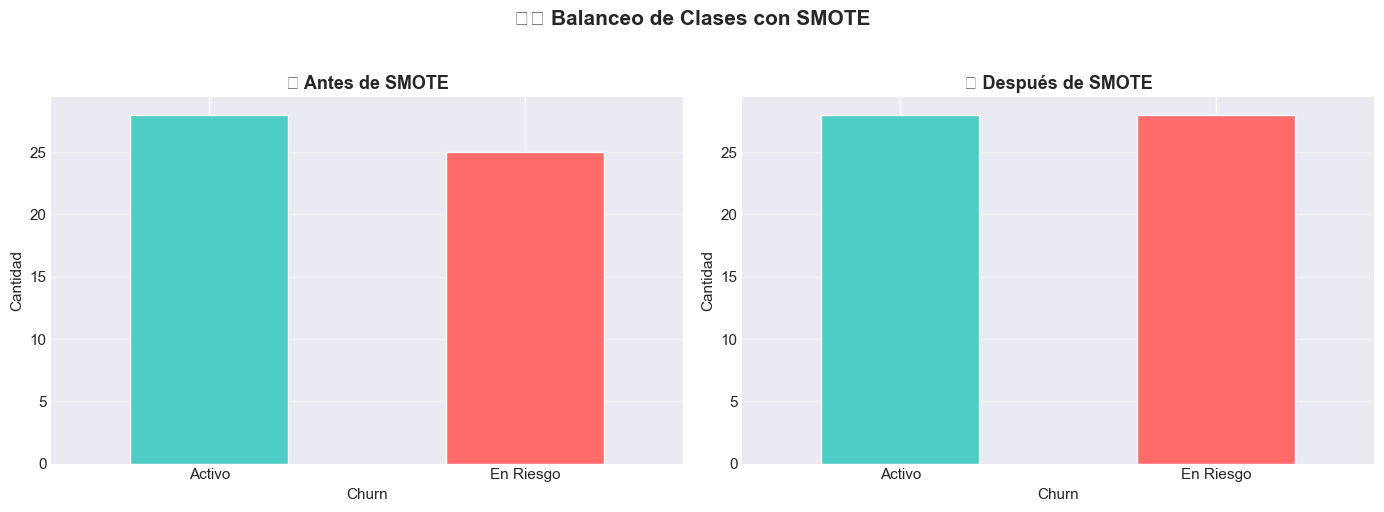

In [145]:
# ============================================================
# BLOQUE 3 – Balanceo de clases con SMOTE
# ============================================================

# Aplicar SMOTE para balancear clases
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("="*80)
print("⚖️ BALANCEO DE CLASES CON SMOTE")
print("="*80)

print(f"\n📊 ANTES de SMOTE:")
print(f"   - Clase 0 (Activo): {sum(y_train==0)}")
print(f"   - Clase 1 (En Riesgo): {sum(y_train==1)}")
print(f"   - Ratio: {sum(y_train==1)/sum(y_train==0):.2f}")

print(f"\n📊 DESPUÉS de SMOTE:")
print(f"   - Clase 0 (Activo): {sum(y_train_smote==0)}")
print(f"   - Clase 1 (En Riesgo): {sum(y_train_smote==1)}")
print(f"   - Ratio: {sum(y_train_smote==1)/sum(y_train_smote==0):.2f}")

print(f"\n✅ Se generaron {sum(y_train_smote==1) - sum(y_train==1)} muestras sintéticas de la clase minoritaria")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes de SMOTE
pd.Series(y_train).value_counts().plot(kind='bar', color=['#4ECDC4', '#FF6B6B'], ax=axes[0])
axes[0].set_title('📊 Antes de SMOTE', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn', fontsize=11)
axes[0].set_ylabel('Cantidad', fontsize=11)
axes[0].set_xticklabels(['Activo', 'En Riesgo'], rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Después de SMOTE
pd.Series(y_train_smote).value_counts().plot(kind='bar', color=['#4ECDC4', '#FF6B6B'], ax=axes[1])
axes[1].set_title('📊 Después de SMOTE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn', fontsize=11)
axes[1].set_ylabel('Cantidad', fontsize=11)
axes[1].set_xticklabels(['Activo', 'En Riesgo'], rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('⚖️ Balanceo de Clases con SMOTE', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 1️⃣7️⃣ Entrenamiento del Modelo de Clasificación (Random Forest)

Entrenar un Random Forest Classifier para predecir churn.

In [146]:
# ============================================================
# BLOQUE 4 – Entrenamiento de Random Forest Classifier
# ============================================================

print("="*80)
print("🌲 ENTRENAMIENTO DE RANDOM FOREST CLASSIFIER")
print("="*80)

rf_churn = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("\n⏳ Entrenando modelo...")
rf_churn.fit(X_train_smote, y_train_smote)
print("✅ Modelo entrenado exitosamente")

# Predicciones en train y test
y_train_pred = rf_churn.predict(X_train_scaled)
y_test_pred = rf_churn.predict(X_test_scaled)

# Probabilidades (para ROC-AUC)
y_train_proba = rf_churn.predict_proba(X_train_scaled)[:, 1]
y_test_proba = rf_churn.predict_proba(X_test_scaled)[:, 1]

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n📊 ACCURACY:")
print(f"   - Train: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   - Test: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Diferencia (overfitting check)
diff = train_acc - test_acc
if diff > 0.1:
    print(f"   ⚠️ Posible overfitting (diferencia: {diff:.4f})")
elif diff < 0:
    print(f"   ⚠️ Modelo bajo ajuste (diferencia: {diff:.4f})")
else:
    print(f"   ✅ Buen balance train/test (diferencia: {diff:.4f})")


🌲 ENTRENAMIENTO DE RANDOM FOREST CLASSIFIER

⏳ Entrenando modelo...
✅ Modelo entrenado exitosamente

📊 ACCURACY:
   - Train: 0.9811 (98.11%)
   - Test: 0.5714 (57.14%)
   ⚠️ Posible overfitting (diferencia: 0.4097)


## 1️⃣8️⃣ Evaluación del Modelo de Clasificación

Métricas detalladas: Confusion Matrix, Classification Report, ROC-AUC.

📊 EVALUACIÓN DEL MODELO - CONJUNTO DE TEST


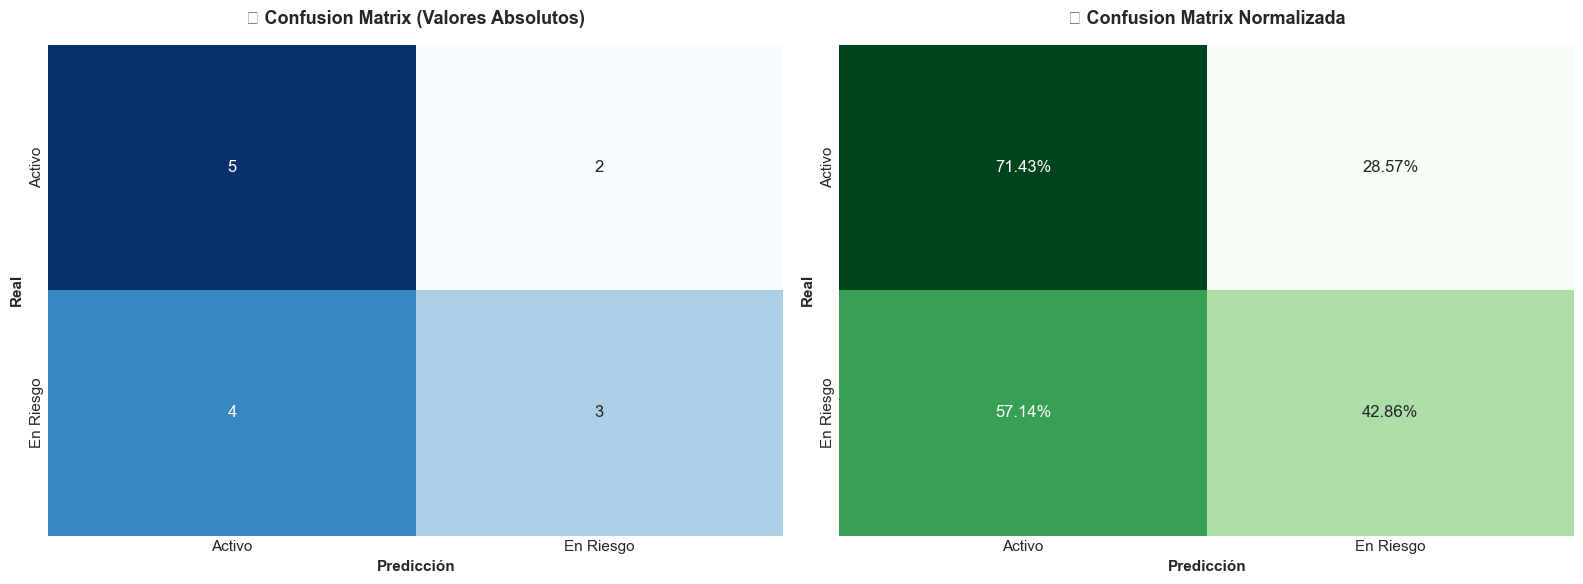


📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Activo       0.56      0.71      0.62         7
   En Riesgo       0.60      0.43      0.50         7

    accuracy                           0.57        14
   macro avg       0.58      0.57      0.56        14
weighted avg       0.58      0.57      0.56        14


✅ ROC-AUC Score: 0.5714
   ⚠️ Poder predictivo moderado


In [147]:
# ============================================================
# BLOQUE 5 – Evaluación: matriz de confusión, report, ROC-AUC
# ============================================================

cm = confusion_matrix(y_test, y_test_pred)

print("="*80)
print("📊 EVALUACIÓN DEL MODELO - CONJUNTO DE TEST")
print("="*80)

# Visualizar matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de confusión (valores absolutos)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Activo', 'En Riesgo'], yticklabels=['Activo', 'En Riesgo'])
axes[0].set_title('🔢 Confusion Matrix (Valores Absolutos)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Predicción', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Real', fontsize=11, fontweight='bold')

# Matriz de confusión normalizada
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['Activo', 'En Riesgo'], yticklabels=['Activo', 'En Riesgo'])
axes[1].set_title('📊 Confusion Matrix Normalizada', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Predicción', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Real', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "="*80)
print("📋 CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_test_pred, target_names=['Activo', 'En Riesgo']))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"\n✅ ROC-AUC Score: {roc_auc:.4f}")

if roc_auc > 0.9:
    print("   🎉 Excelente poder predictivo")
elif roc_auc > 0.8:
    print("   ✅ Muy buen poder predictivo")
elif roc_auc > 0.7:
    print("   👍 Buen poder predictivo")
else:
    print("   ⚠️ Poder predictivo moderado")


## 1️⃣9️⃣ Curva ROC

Visualización de la curva ROC para evaluar el rendimiento del clasificador.

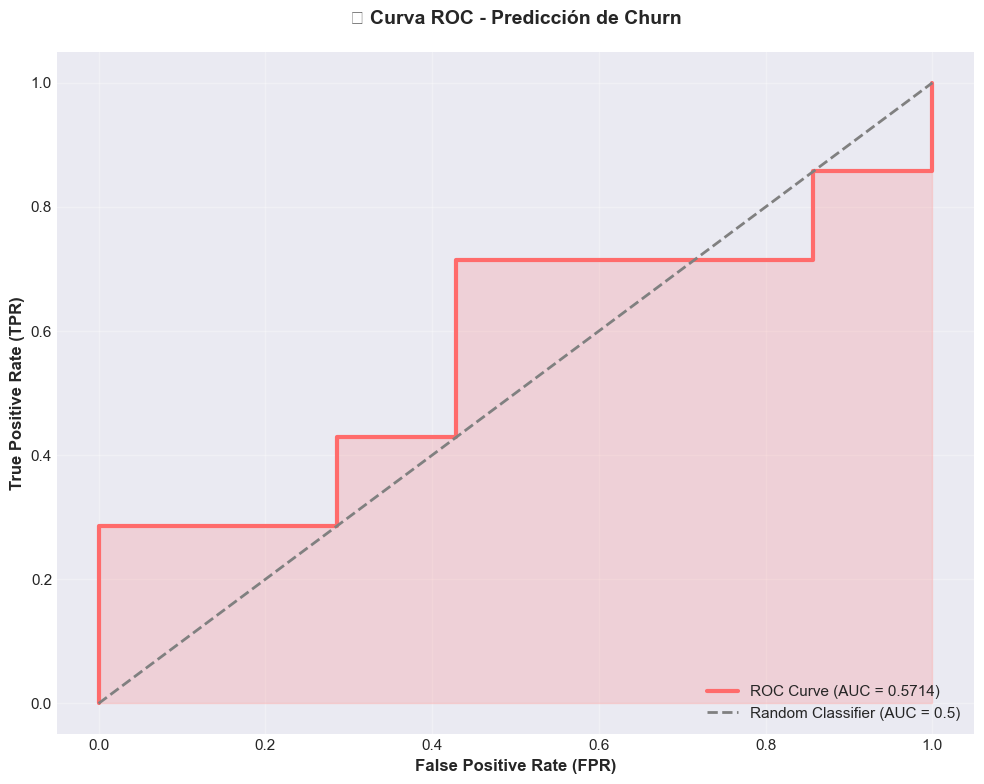


📌 Threshold óptimo (Youden's Index): 0.3790
   - TPR en threshold óptimo: 0.7143
   - FPR en threshold óptimo: 0.4286


In [148]:
# ============================================================
# BLOQUE 6 – Curva ROC y threshold óptimo
# ============================================================

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr, tpr, color='#FF6B6B', linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Random Classifier (AUC = 0.5)')

ax.fill_between(fpr, tpr, alpha=0.2, color='#FF6B6B')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
ax.set_title('📈 Curva ROC - Predicción de Churn', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Encontrar mejor threshold (Youden's Index)
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]

print(f"\n📌 Threshold óptimo (Youden's Index): {optimal_threshold:.4f}")
print(f"   - TPR en threshold óptimo: {tpr[optimal_idx]:.4f}")
print(f"   - FPR en threshold óptimo: {fpr[optimal_idx]:.4f}")


## 2️⃣0️⃣ Feature Importance (Importancia de Variables)

Identificar las variables más importantes para predecir churn.

🔍 IMPORTANCIA DE VARIABLES


,feature,importance
1,importe_total_cliente,0.170677
3,ticket_max,0.140514
13,ventas_por_mes,0.110250
12,antiguedad_cliente_dias,0.105895
2,ticket_promedio,0.081026
4,ticket_min,0.070034
15,cantidad_promedio_por_venta,0.067473
5,desvio_ticket,0.063130
14,lineas_promedio_por_venta,0.057399
11,pct_ventas_transferencia,0.050178


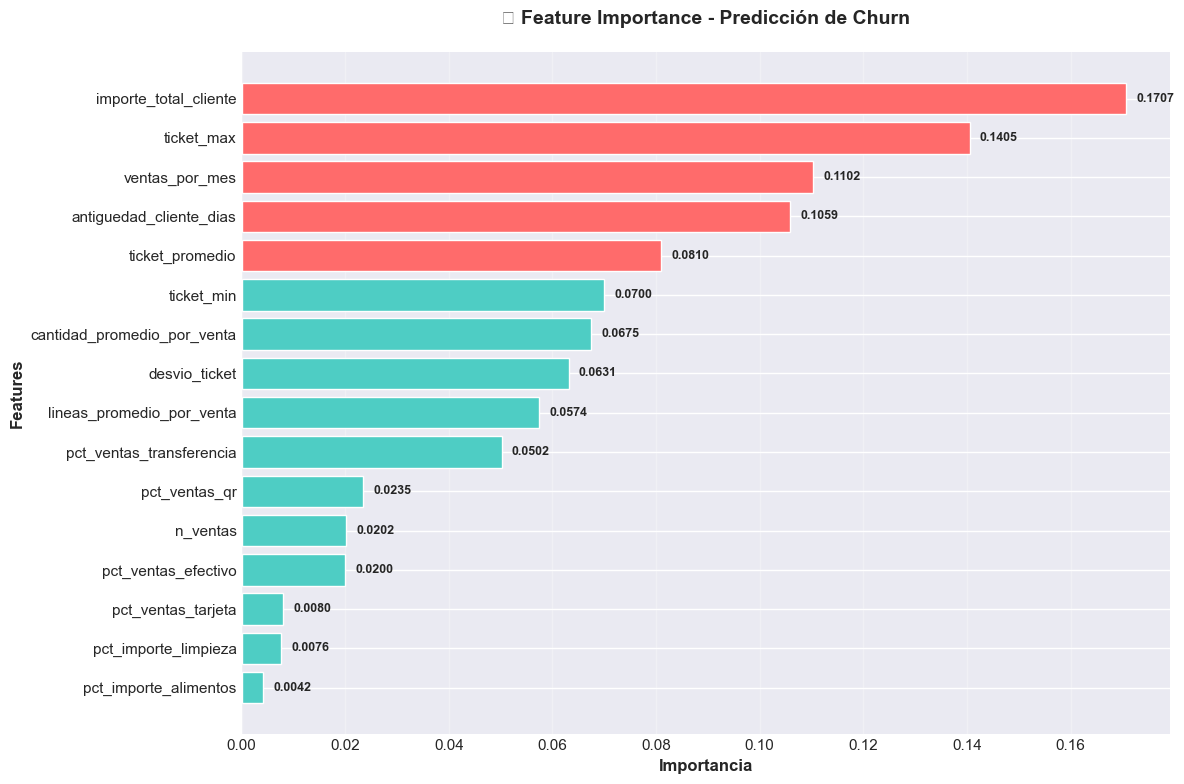


📊 TOP 5 VARIABLES MÁS IMPORTANTES:
   1. importe_total_cliente: 0.1707 (17.07%)
   2. ticket_max: 0.1405 (14.05%)
   3. ventas_por_mes: 0.1102 (11.02%)
   4. antiguedad_cliente_dias: 0.1059 (10.59%)
   5. ticket_promedio: 0.0810 (8.10%)


In [149]:
# ============================================================
# BLOQUE 7 – Importancia de variables
# ============================================================

feature_importance = pd.DataFrame({
    'feature': X_churn.columns,
    'importance': rf_churn.feature_importances_
}).sort_values('importance', ascending=False)

print("="*80)
print("🔍 IMPORTANCIA DE VARIABLES")
print("="*80)
display(feature_importance)

# Visualización
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#FF6B6B' if i < 5 else '#4ECDC4' for i in range(len(feature_importance))]
ax.barh(feature_importance['feature'], feature_importance['importance'], color=colors)

ax.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('🔍 Feature Importance - Predicción de Churn', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Agregar valores
for i, (idx, row) in enumerate(feature_importance.iterrows()):
    ax.text(row['importance'] + 0.002, i, f"{row['importance']:.4f}", 
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📊 TOP 5 VARIABLES MÁS IMPORTANTES:")
print("="*80)
for i, (idx, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f"   {i}. {row['feature']}: {row['importance']:.4f} ({row['importance']*100:.2f}%)")


## 2️⃣1️⃣ Clientes en Alto Riesgo de Churn

Identificar clientes con mayor probabilidad de churn para acciones preventivas.

⚠️ CLIENTES EN ALTO RIESGO DE CHURN (Probabilidad > 0.7)

✅ Total de clientes en riesgo: 20 de 67 (29.9%)

📋 TOP 10 CLIENTES CON MAYOR RIESGO:


,id_cliente,churn_proba
18,23,0.937548
17,21,0.934381
23,29,0.919222
13,17,0.912833
22,28,0.907214
14,18,0.884750
39,54,0.882000
1,2,0.876000
33,43,0.848595
55,82,0.848095



✅ Lista completa exportada: modelos/clientes_alto_riesgo.csv


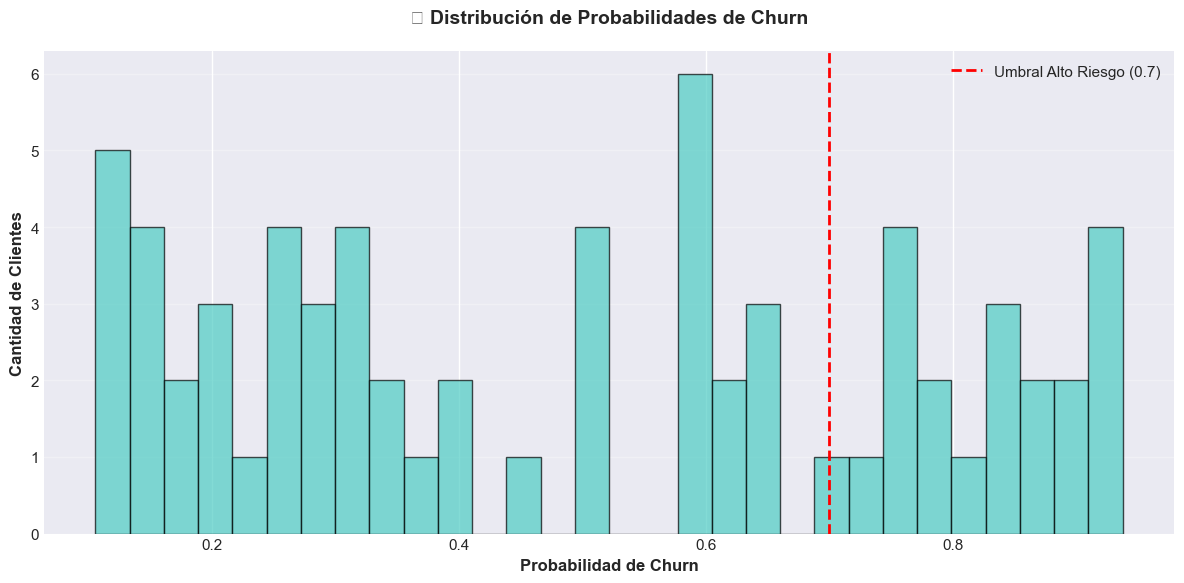

In [150]:
# ============================================================
# BLOQUE 8 – Predicciones para TODOS los clientes + alto riesgo
# ============================================================

# Usamos EXACTAMENTE las mismas columnas numéricas que en el entrenamiento (feature_cols)
X_churn_full = df_churn[feature_cols]
X_churn_full_scaled = scaler_churn.transform(X_churn_full)

df_churn['churn_proba'] = rf_churn.predict_proba(X_churn_full_scaled)[:, 1]
df_churn['churn_pred'] = rf_churn.predict(X_churn_full_scaled)

# Identificar clientes de alto riesgo (probabilidad > 0.7)
umbral_riesgo = 0.7
alto_riesgo = df_churn[df_churn['churn_proba'] > umbral_riesgo].sort_values('churn_proba', ascending=False)

print("="*80)
print(f"⚠️ CLIENTES EN ALTO RIESGO DE CHURN (Probabilidad > {umbral_riesgo})")
print("="*80)
print(f"\n✅ Total de clientes en riesgo: {len(alto_riesgo)} de {len(df_churn)} ({len(alto_riesgo)/len(df_churn)*100:.1f}%)")

if len(alto_riesgo) > 0:
    print(f"\n📋 TOP 10 CLIENTES CON MAYOR RIESGO:")
    print("="*80)
    
    top_riesgo = alto_riesgo[['id_cliente', 'churn_proba']].head(10)
    display(top_riesgo)
    
    # Exportar lista completa
    alto_riesgo[['id_cliente', 'churn_proba']].to_csv(
        'modelos/clientes_alto_riesgo.csv', index=False
    )
    print(f"\n✅ Lista completa exportada: modelos/clientes_alto_riesgo.csv")
    
    # Visualización de distribución de probabilidades
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(df_churn['churn_proba'], bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
    ax.axvline(umbral_riesgo, color='red', linestyle='--', linewidth=2, label=f'Umbral Alto Riesgo ({umbral_riesgo})')
    ax.set_xlabel('Probabilidad de Churn', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cantidad de Clientes', fontsize=12, fontweight='bold')
    ax.set_title('📊 Distribución de Probabilidades de Churn', fontsize=14, fontweight='bold', pad=20)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No hay clientes con probabilidad superior al umbral definido")

## 2️⃣2️⃣ Exportar Modelo de Churn

Guardar el modelo de clasificación y componentes asociados.

In [151]:
# ============================================================
# BLOQUE 9 – Guardado de artefactos del modelo de churn
# ============================================================

# Guardar modelo de churn
joblib.dump(rf_churn, 'modelos/random_forest_churn.pkl')
print("✅ Modelo Random Forest Churn guardado: modelos/random_forest_churn.pkl")

# Guardar scaler
joblib.dump(scaler_churn, 'modelos/scaler_churn.pkl')
print("✅ Scaler guardado: modelos/scaler_churn.pkl")

# Guardar feature importance
feature_importance.to_csv('modelos/feature_importance_churn.csv', index=False)
print("✅ Feature Importance guardado: modelos/feature_importance_churn.csv")

# Guardar métricas del modelo
metricas_churn = {
    'accuracy_train': float(train_acc),
    'accuracy_test': float(test_acc),
    'roc_auc': float(roc_auc),
    'optimal_threshold': float(optimal_threshold),
    'n_clientes_alto_riesgo': int(len(alto_riesgo)),
    'umbral_riesgo': umbral_riesgo
}

with open('modelos/metricas_churn.json', 'w') as f:
    json.dump(metricas_churn, f, indent=4)
print("✅ Métricas guardadas: modelos/metricas_churn.json")

print("\n" + "="*80)
print("🎉 MODELO DE PREDICCIÓN DE CHURN COMPLETADO Y EXPORTADO")
print("="*80)

✅ Modelo Random Forest Churn guardado: modelos/random_forest_churn.pkl
✅ Scaler guardado: modelos/scaler_churn.pkl
✅ Feature Importance guardado: modelos/feature_importance_churn.csv
✅ Métricas guardadas: modelos/metricas_churn.json

🎉 MODELO DE PREDICCIÓN DE CHURN COMPLETADO Y EXPORTADO


---

# 💰 PARTE 3: PREDICCIÓN DE VALOR DEL CLIENTE (Regresión)

**Objetivo:** Predecir el valor monetario total de cada cliente basado en su comportamiento de compra.

**⚠️ ACLARACIÓN NOMENCLATURA:**
Este modelo predice el **valor histórico/actual** del cliente (`monetary`), NO un Customer Lifetime Value (CLV) formal.
- **CLV real** requiere: horizonte temporal futuro, separación de períodos, descuento temporal
- **Este modelo** = Regresión de valor total basado en comportamiento histórico (Customer Value Prediction)

## 2️⃣3️⃣ Preparación de Datos para Regresión

Preparar features y target (monetary) para predecir el valor del cliente.

**📝 Nota:** El target `monetary` representa el valor histórico total del cliente, no un CLV proyectado.

💰 PREPARACIÓN PARA PREDICCIÓN DE VALOR DEL CLIENTE

✅ Target: 'importe_total_cliente' (Valor monetario histórico del cliente)
✅ Features numéricas: 15 variables
✅ Total observaciones (clientes): 67

📌 Columnas usadas como features:
   • n_ventas
   • ticket_promedio
   • ticket_max
   • ticket_min
   • desvio_ticket
   • pct_importe_alimentos
   • pct_importe_limpieza
   • pct_ventas_efectivo
   • pct_ventas_qr
   • pct_ventas_tarjeta
   • pct_ventas_transferencia
   • antiguedad_cliente_dias
   • ventas_por_mes
   • lineas_promedio_por_venta
   • cantidad_promedio_por_venta

📝 ACLARACIÓN TÉCNICA: Este NO es un CLV formal
✅ Lo que SÍ estamos haciendo:
   • Predecir valor histórico/actual basado en comportamiento agregado del cliente
   • Regresión de 'importe_total_cliente' usando features de RFM/comportamiento
   • Útil para scoring y priorización de clientes

❌ Lo que NO estamos haciendo (CLV real requiere):
   • Horizonte temporal futuro definido (ej: próximos 6-12 meses)
   • Separ

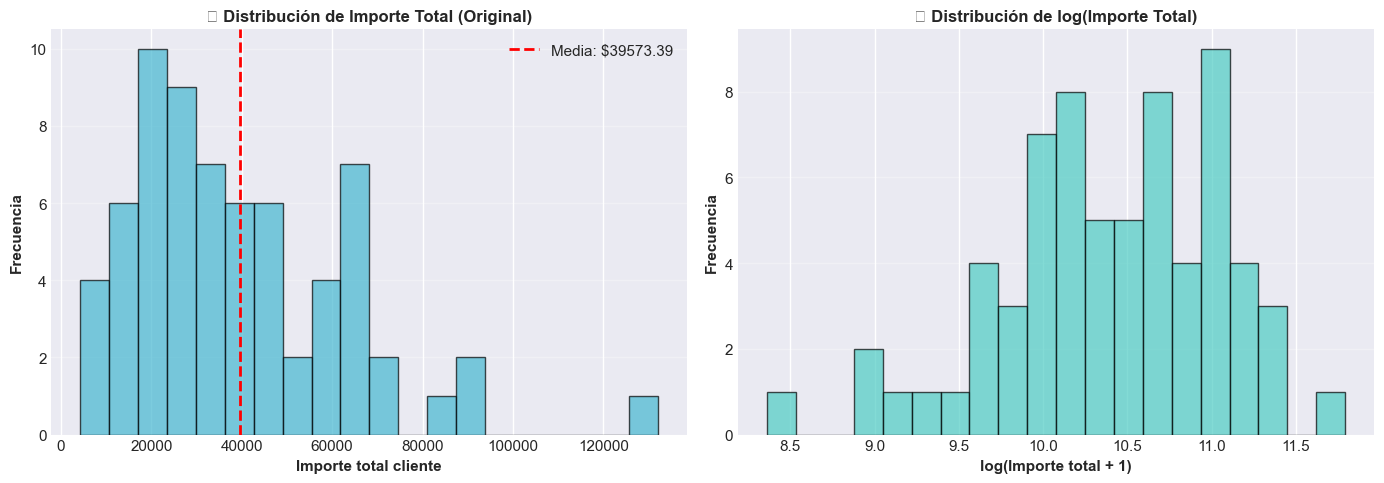


✅ Train set: 53 muestras (79.1%)
✅ Test set: 14 muestras (20.9%)

✅ Features escaladas con StandardScaler


In [152]:
# ============================================================
# BLOQUE 1 – Predicción de Valor del Cliente (Customer Value)
# ============================================================

# Recargar dataset a nivel cliente
df_clv = pd.read_csv('db/base_final_ML_clientes.csv')

print("="*80)
print("💰 PREPARACIÓN PARA PREDICCIÓN DE VALOR DEL CLIENTE")
print("="*80)

# Target: importe_total_cliente (valor total gastado por el cliente)
# 1) Definimos target
y_clv = df_clv['importe_total_cliente']

# 2) Definimos features candidatas (excluimos id_cliente y el target)
features_candidatas_clv = df_clv.drop(['id_cliente', 'importe_total_cliente'], axis=1)

# 3) Seleccionamos SOLO columnas numéricas para el modelo
feature_cols_clv = features_candidatas_clv.select_dtypes(include=['number']).columns.tolist()

X_clv = df_clv[feature_cols_clv]

print(f"\n✅ Target: 'importe_total_cliente' (Valor monetario histórico del cliente)")
print(f"✅ Features numéricas: {X_clv.shape[1]} variables")
print(f"✅ Total observaciones (clientes): {X_clv.shape[0]}")

print("\n📌 Columnas usadas como features:")
for col in feature_cols_clv:
    print(f"   • {col}")

print("\n" + "="*80)
print("📝 ACLARACIÓN TÉCNICA: Este NO es un CLV formal")
print("="*80)
print("✅ Lo que SÍ estamos haciendo:")
print("   • Predecir valor histórico/actual basado en comportamiento agregado del cliente")
print("   • Regresión de 'importe_total_cliente' usando features de RFM/comportamiento")
print("   • Útil para scoring y priorización de clientes")
print("\n❌ Lo que NO estamos haciendo (CLV real requiere):")
print("   • Horizonte temporal futuro definido (ej: próximos 6-12 meses)")
print("   • Separación temporal: datos período 1 → predicción período 2")
print("   • Descuento temporal (valor presente neto)")
print("   • Tasa de retención/churn integrada")
print("\n💡 Nomenclatura correcta: 'Customer Value Prediction' o 'Historical Value Regression'")
print("="*80)

# Estadísticas del target
print(f"\n📊 Estadísticas del Target (importe_total_cliente):")
print(f"   - Media: ${y_clv.mean():.2f}")
print(f"   - Mediana: ${y_clv.median():.2f}")
print(f"   - Std: ${y_clv.std():.2f}")
print(f"   - Mín: ${y_clv.min():.2f}")
print(f"   - Máx: ${y_clv.max():.2f}")

# Visualización de distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma original
axes[0].hist(y_clv, bins=20, color='#45B7D1', edgecolor='black', alpha=0.7)
axes[0].axvline(y_clv.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${y_clv.mean():.2f}')
axes[0].set_xlabel('Importe total cliente', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0].set_title('📊 Distribución de Importe Total (Original)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Histograma log-transformado
axes[1].hist(np.log1p(y_clv), bins=20, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('log(Importe total + 1)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[1].set_title('📊 Distribución de log(Importe Total)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Train-Test Split
X_train_clv, X_test_clv, y_train_clv, y_test_clv = train_test_split(
    X_clv, y_clv, test_size=0.2, random_state=42
)

print(f"\n✅ Train set: {X_train_clv.shape[0]} muestras ({X_train_clv.shape[0]/len(df_clv)*100:.1f}%)")
print(f"✅ Test set: {X_test_clv.shape[0]} muestras ({X_test_clv.shape[0]/len(df_clv)*100:.1f}%)")

# Escalar features
scaler_clv = StandardScaler()
X_train_clv_scaled = scaler_clv.fit_transform(X_train_clv)
X_test_clv_scaled = scaler_clv.transform(X_test_clv)

print(f"\n✅ Features escaladas con StandardScaler")


## 2️⃣4️⃣ Entrenamiento del Modelo de Regresión (Random Forest)

Entrenar un Random Forest Regressor para predecir el valor del cliente.

In [153]:
# ============================================================
# BLOQUE 2 – Entrenamiento de Random Forest Regressor (CLV histórico)
# ============================================================

print("="*80)
print("🌲 ENTRENAMIENTO DE RANDOM FOREST REGRESSOR – VALOR DEL CLIENTE")
print("="*80)

rf_clv = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("\n⏳ Entrenando modelo de valor del cliente...")
rf_clv.fit(X_train_clv_scaled, y_train_clv)
print("✅ Modelo entrenado exitosamente")

# Predicciones
y_train_pred_clv = rf_clv.predict(X_train_clv_scaled)
y_test_pred_clv = rf_clv.predict(X_test_clv_scaled)

# Métricas de Regresión
mae_train = mean_absolute_error(y_train_clv, y_train_pred_clv)
mae_test = mean_absolute_error(y_test_clv, y_test_pred_clv)

rmse_train = np.sqrt(mean_squared_error(y_train_clv, y_train_pred_clv))
rmse_test = np.sqrt(mean_squared_error(y_test_clv, y_test_pred_clv))

r2_train = r2_score(y_train_clv, y_train_pred_clv)
r2_test = r2_score(y_test_clv, y_test_pred_clv)

print("\n" + "="*80)
print("📊 MÉTRICAS DE REGRESIÓN – VALOR DEL CLIENTE")
print("="*80)

print(f"\n✅ Mean Absolute Error (MAE):")
print(f"   - Train: ${mae_train:.2f}")
print(f"   - Test: ${mae_test:.2f}")

print(f"\n✅ Root Mean Squared Error (RMSE):")
print(f"   - Train: ${rmse_train:.2f}")
print(f"   - Test: ${rmse_test:.2f}")

print(f"\n✅ R² Score (Coeficiente de Determinación):")
print(f"   - Train: {r2_train:.4f} ({r2_train*100:.2f}%)")
print(f"   - Test: {r2_test:.4f} ({r2_test*100:.2f}%)")

# Chequeo simple de overfitting
diff_r2 = r2_train - r2_test
if diff_r2 > 0.1:
    print(f"\n⚠️ Posible overfitting (R² train mucho mayor que test, diferencia: {diff_r2:.4f})")
elif diff_r2 < -0.05:
    print(f"\n⚠️ Modelo podría estar bajoajustado (R² test mayor que train, diferencia: {diff_r2:.4f})")
else:
    print(f"\n✅ Buen balance entre train y test (diferencia de R²: {diff_r2:.4f})")

if r2_test > 0.8:
    print("   🎉 Excelente ajuste del modelo sobre el valor del cliente")
elif r2_test > 0.6:
    print("   ✅ Buen ajuste del modelo sobre el valor del cliente")
elif r2_test > 0.4:
    print("   👍 Ajuste moderado del modelo sobre el valor del cliente")
else:
    print("   ⚠️ Ajuste bajo del modelo sobre el valor del cliente")


🌲 ENTRENAMIENTO DE RANDOM FOREST REGRESSOR – VALOR DEL CLIENTE

⏳ Entrenando modelo de valor del cliente...
✅ Modelo entrenado exitosamente

📊 MÉTRICAS DE REGRESIÓN – VALOR DEL CLIENTE

✅ Mean Absolute Error (MAE):
   - Train: $3882.50
   - Test: $7552.50

✅ Root Mean Squared Error (RMSE):
   - Train: $6869.72
   - Test: $10086.19

✅ R² Score (Coeficiente de Determinación):
   - Train: 0.9242 (92.42%)
   - Test: 0.6998 (69.98%)

⚠️ Posible overfitting (R² train mucho mayor que test, diferencia: 0.2244)
   ✅ Buen ajuste del modelo sobre el valor del cliente


## 2️⃣5️⃣ Visualización de Predicciones vs Valores Reales

Scatter plot para evaluar la calidad de las predicciones del modelo.

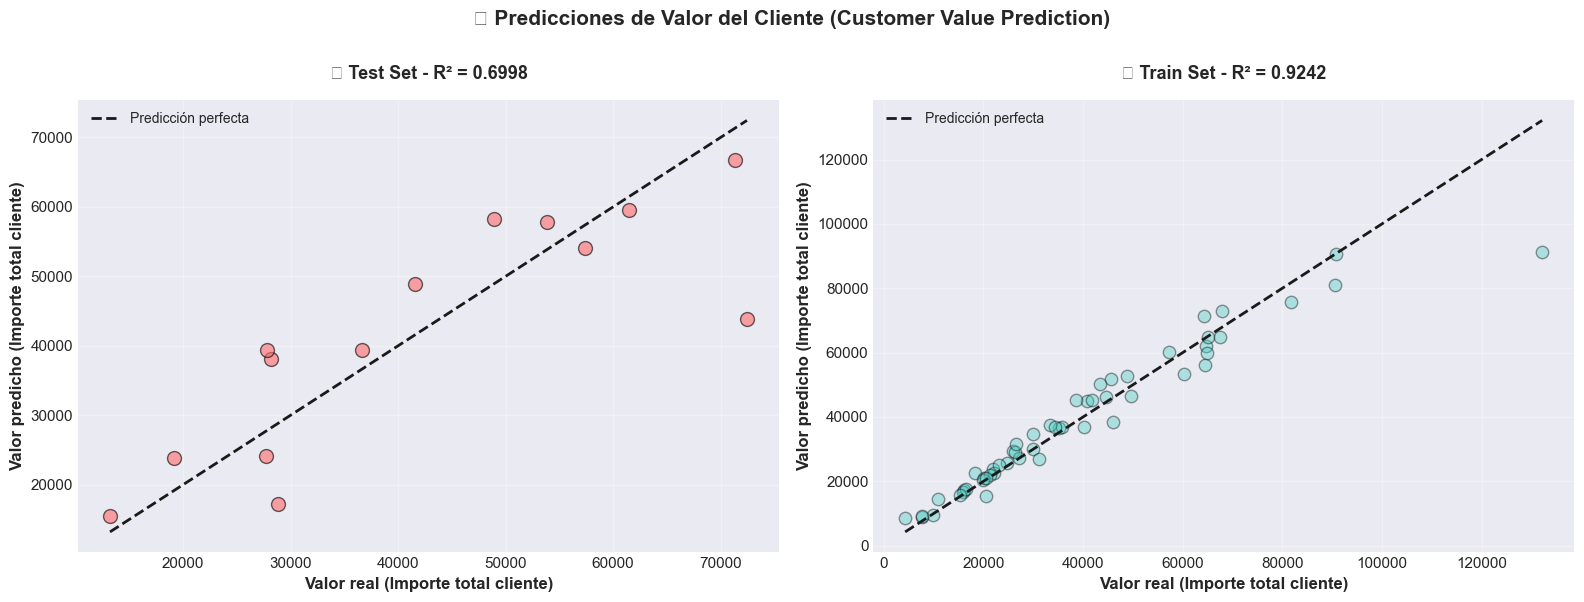


📊 ANÁLISIS DE RESIDUOS – TEST SET

✅ Media de residuos: $128.05
✅ Desviación estándar de residuos: $10466.09
✅ Residuo mínimo: $-11568.85
✅ Residuo máximo: $28535.17


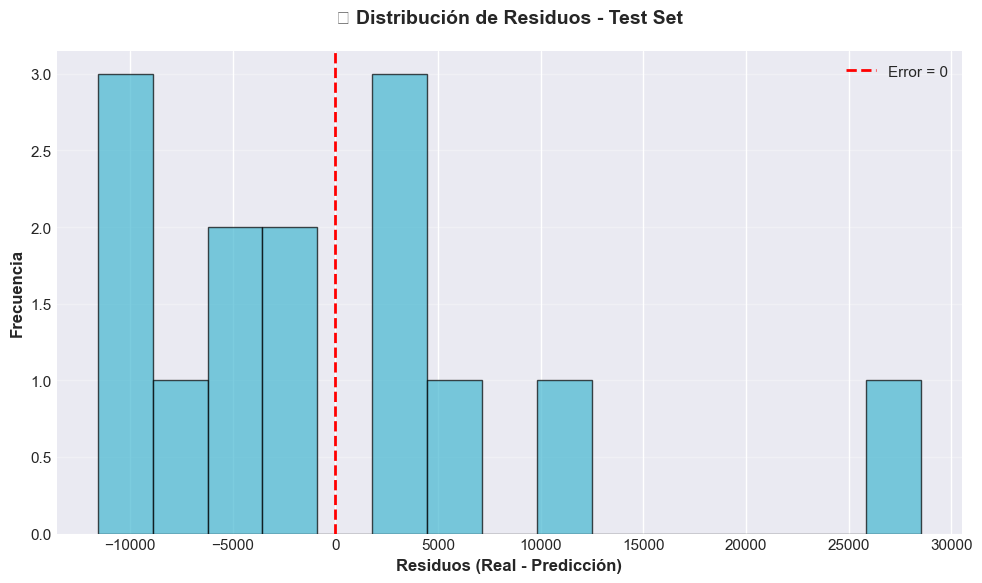

In [154]:
# ============================================================
# BLOQUE 3 – Análisis gráfico: Predicciones vs Valores Reales y Residuos
# ============================================================

# Scatter Plot: Predicciones vs Valores Reales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Test Set
axes[0].scatter(y_test_clv, y_test_pred_clv, alpha=0.6, color='#FF6B6B', s=100, edgecolors='black')
axes[0].plot(
    [y_test_clv.min(), y_test_clv.max()],
    [y_test_clv.min(), y_test_clv.max()],
    'k--', lw=2, label='Predicción perfecta'
)
axes[0].set_xlabel('Valor real (Importe total cliente)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valor predicho (Importe total cliente)', fontsize=12, fontweight='bold')
axes[0].set_title(f'🎯 Test Set - R² = {r2_test:.4f}', fontsize=13, fontweight='bold', pad=15)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Train Set
axes[1].scatter(y_train_clv, y_train_pred_clv, alpha=0.4, color='#4ECDC4', s=80, edgecolors='black')
axes[1].plot(
    [y_train_clv.min(), y_train_clv.max()],
    [y_train_clv.min(), y_train_clv.max()],
    'k--', lw=2, label='Predicción perfecta'
)
axes[1].set_xlabel('Valor real (Importe total cliente)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Valor predicho (Importe total cliente)', fontsize=12, fontweight='bold')
axes[1].set_title(f'🎯 Train Set - R² = {r2_train:.4f}', fontsize=13, fontweight='bold', pad=15)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('💰 Predicciones de Valor del Cliente (Customer Value Prediction)', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Residuos (errores) en test
residuos_test = y_test_clv - y_test_pred_clv

print("\n" + "="*80)
print("📊 ANÁLISIS DE RESIDUOS – TEST SET")
print("="*80)
print(f"\n✅ Media de residuos: ${residuos_test.mean():.2f}")
print(f"✅ Desviación estándar de residuos: ${residuos_test.std():.2f}")
print(f"✅ Residuo mínimo: ${residuos_test.min():.2f}")
print(f"✅ Residuo máximo: ${residuos_test.max():.2f}")

# Histograma de residuos
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(residuos_test, bins=15, color='#45B7D1', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Error = 0')
ax.set_xlabel('Residuos (Real - Predicción)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax.set_title('📊 Distribución de Residuos - Test Set', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 2️⃣6️⃣ Feature Importance - Valor del Cliente

Identificar las variables más importantes para predecir el valor del cliente.

🔍 IMPORTANCIA DE VARIABLES - PREDICCIÓN DE VALOR DEL CLIENTE


,feature,importance
2,ticket_max,0.733227
12,ventas_por_mes,0.124506
0,n_ventas,0.033275
4,desvio_ticket,0.031293
1,ticket_promedio,0.015960
11,antiguedad_cliente_dias,0.012081
3,ticket_min,0.010154
6,pct_importe_limpieza,0.008585
9,pct_ventas_tarjeta,0.008474
5,pct_importe_alimentos,0.007193


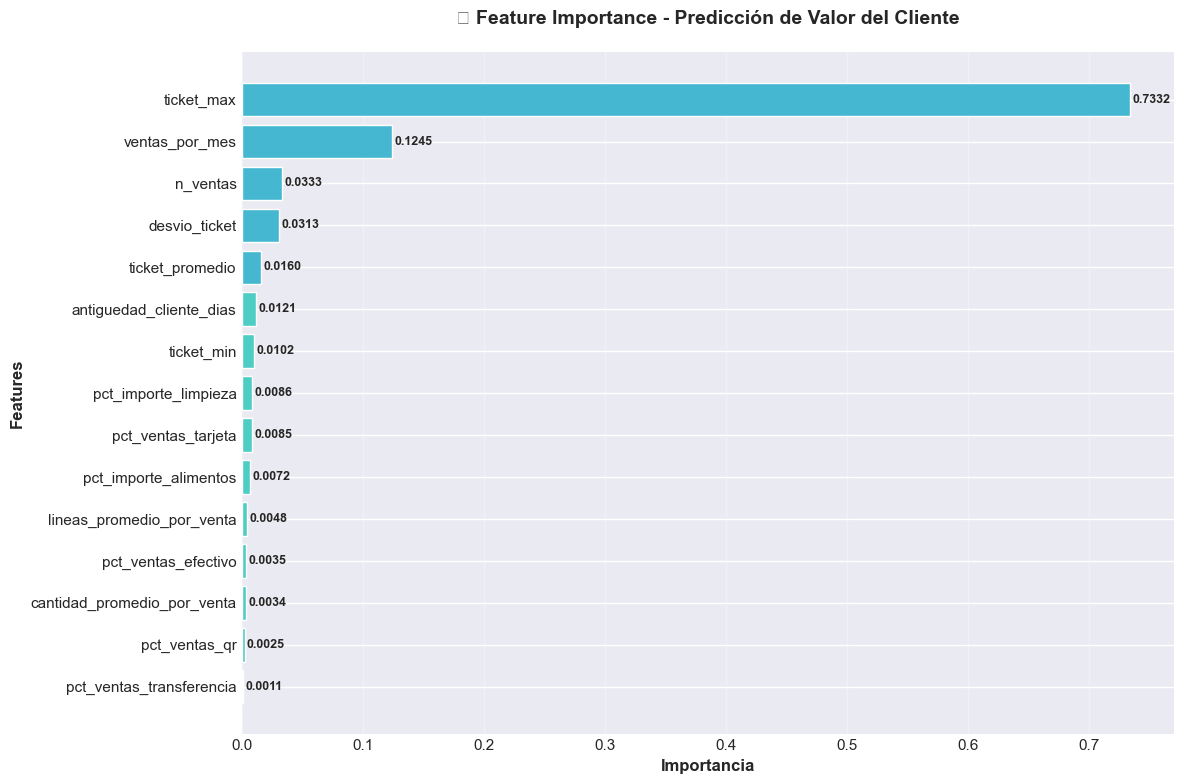


📊 TOP 5 VARIABLES MÁS IMPORTANTES:
   1. ticket_max: 0.7332 (73.32%)
   2. ventas_por_mes: 0.1245 (12.45%)
   3. n_ventas: 0.0333 (3.33%)
   4. desvio_ticket: 0.0313 (3.13%)
   5. ticket_promedio: 0.0160 (1.60%)


In [155]:
# ============================================================
# BLOQUE 4 – Importancia de variables (Random Forest Regressor)
# ============================================================

# Feature Importance del Random Forest Regressor
feature_importance_clv = pd.DataFrame({
    'feature': X_clv.columns,
    'importance': rf_clv.feature_importances_
}).sort_values('importance', ascending=False)

print("="*80)
print("🔍 IMPORTANCIA DE VARIABLES - PREDICCIÓN DE VALOR DEL CLIENTE")
print("="*80)
display(feature_importance_clv)

# Visualización
fig, ax = plt.subplots(figsize=(12, 8))

# Azul para el top 5, verde para el resto
colors_clv = ['#45B7D1' if i < 5 else '#4ECDC4' for i in range(len(feature_importance_clv))]
ax.barh(feature_importance_clv['feature'], feature_importance_clv['importance'], color=colors_clv)

ax.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('🔍 Feature Importance - Predicción de Valor del Cliente', fontsize=14, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Agregar valores numéricos al final de cada barra
for i, (idx, row) in enumerate(feature_importance_clv.iterrows()):
    ax.text(row['importance'] + 0.002, i, f"{row['importance']:.4f}", 
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📊 TOP 5 VARIABLES MÁS IMPORTANTES:")
print("="*80)
for i, (idx, row) in enumerate(feature_importance_clv.head(5).iterrows(), 1):
    print(f"   {i}. {row['feature']}: {row['importance']:.4f} ({row['importance']*100:.2f}%)")


## 2️⃣7️⃣ Exportar Modelo de Valor del Cliente

Guardar el modelo de regresión y componentes asociados.

In [156]:
# ============================================================
# BLOQUE 5 – Guardado de artefactos y predicciones (Customer Value)
# ============================================================

# Guardar modelo de valor del cliente
joblib.dump(rf_clv, 'modelos/random_forest_customer_value.pkl')
print("✅ Modelo Random Forest guardado: modelos/random_forest_customer_value.pkl")

# Guardar scaler
joblib.dump(scaler_clv, 'modelos/scaler_customer_value.pkl')
print("✅ Scaler guardado: modelos/scaler_customer_value.pkl")

# Guardar feature importance
feature_importance_clv.to_csv('modelos/feature_importance_customer_value.csv', index=False)
print("✅ Feature Importance guardado: modelos/feature_importance_customer_value.csv")

# Guardar métricas del modelo
metricas_clv = {
    'mae_train': float(mae_train),
    'mae_test': float(mae_test),
    'rmse_train': float(rmse_train),
    'rmse_test': float(rmse_test),
    'r2_train': float(r2_train),
    'r2_test': float(r2_test),
    # Estadísticas del target (importe_total_cliente)
    'media_importe_total_cliente': float(y_clv.mean()),
    'mediana_importe_total_cliente': float(y_clv.median()),
    'std_importe_total_cliente': float(y_clv.std())
}

with open('modelos/metricas_customer_value.json', 'w') as f:
    json.dump(metricas_clv, f, indent=4)
print("✅ Métricas guardadas: modelos/metricas_customer_value.json")

# Predecir valor para TODOS los clientes (usando las mismas features X_clv)
df_clv['valor_predicho'] = rf_clv.predict(scaler_clv.transform(X_clv))

# Exportar predicciones con el valor real y error absoluto
df_clv_export = df_clv[['id_cliente', 'importe_total_cliente', 'valor_predicho']].copy()
df_clv_export['error_absoluto'] = abs(df_clv_export['importe_total_cliente'] - df_clv_export['valor_predicho'])
df_clv_export = df_clv_export.sort_values('valor_predicho', ascending=False)

df_clv_export.to_csv('modelos/predicciones_customer_value.csv', index=False)
print("✅ Predicciones guardadas: modelos/predicciones_customer_value.csv")

print("\n" + "="*80)
print("🎉 MODELO DE PREDICCIÓN DE VALOR DEL CLIENTE COMPLETADO Y EXPORTADO")
print("="*80)


✅ Modelo Random Forest guardado: modelos/random_forest_customer_value.pkl
✅ Scaler guardado: modelos/scaler_customer_value.pkl
✅ Feature Importance guardado: modelos/feature_importance_customer_value.csv
✅ Métricas guardadas: modelos/metricas_customer_value.json
✅ Predicciones guardadas: modelos/predicciones_customer_value.csv

🎉 MODELO DE PREDICCIÓN DE VALOR DEL CLIENTE COMPLETADO Y EXPORTADO


---

# 🏆 PARTE 4: COMPARACIÓN DE MODELOS Y RESULTADOS FINALES

**Objetivo:** Consolidar los resultados de los 3 modelos y generar un reporte ejecutivo.

## 2️⃣8️⃣ Resumen Comparativo de Modelos

Tabla consolidada con métricas de los 3 modelos implementados.

In [157]:
# ============================================================
# RESUMEN COMPARATIVO DE MODELOS DE MACHINE LEARNING
# ============================================================

print("="*80)
print("🏆 RESUMEN COMPARATIVO DE MODELOS DE MACHINE LEARNING")
print("="*80)

resumen_modelos = pd.DataFrame({
    'Modelo': [
        '1. K-Means Clustering',
        '2. Random Forest - Churn',
        '3. Random Forest - Valor Cliente'
    ],
    'Tipo': [
        'No Supervisado',
        'Clasificación (Supervisado)',
        'Regresión (Supervisado)'
    ],
    'Objetivo': [
        'Segmentar clientes en 3 grupos',
        'Predecir abandono (churn)',
        'Predecir valor histórico del cliente'
    ],
    'Métrica Principal': [
        f'Silhouette: {silhouette:.4f}',
        f'ROC-AUC: {roc_auc:.4f}',
        f'R²: {r2_test:.4f}'
    ],
    'Features': [
        f'{X_scaled.shape[1]} variables',
        f'{X_churn.shape[1]} variables',
        f'{X_clv.shape[1]} variables'
    ],
    'Estado': [
        '✅ Completado',
        '✅ Completado (sin data leakage)',
        '✅ Completado'
    ]
})

display(resumen_modelos)

print("\n" + "="*80)
print("📋 OBSERVACIONES TÉCNICAS IMPORTANTES")
print("="*80)

print("\n🟢 MODELO 2 (CHURN) – DATA LEAKAGE EVITADO:")
print("   • El target 'churn' se define a partir de 'recency' (p.ej. > 60 días).")
print("   • 'recency' NO se utiliza como feature en X_churn (se excluye explícitamente).")
print("   • De esta forma se evita fuga de información y las métricas (ROC-AUC) son más realistas.")
print("   • En un entorno productivo ideal, se recomienda además definir churn con una ventana futura (no compra en N días).")

print("\n🟡 MODELO 3 (VALOR CLIENTE) – ACLARACIÓN DE NOMENCLATURA:")
print("   • El target es 'importe_total_cliente' (valor monetario histórico/actual del cliente).")
print("   • Este modelo NO es un Customer Lifetime Value (CLV) formal.")
print("   • Un CLV real requeriría: horizonte temporal futuro, separación de períodos y descuento temporal.")
print("   • Nomenclatura recomendada: 'Customer Value Prediction' o 'Historical Value Model'.")

print("\n✅ MODELO 1 (CLUSTERING) – SEGMENTACIÓN DE CLIENTES:")
print("   • Implementación correcta de K-Means sobre variables agregadas a nivel cliente.")
print("   • Segmentación en 3 clusters bien diferenciados (según métrica de Silhouette).")
print("   • Listo para uso en estrategias de marketing y personalización.")

print("\n" + "="*80)
print("💡 RECOMENDACIONES PARA PRODUCCIÓN")
print("="*80)
print("1. Modelo Churn:")
print("   • Mantener la exclusión de 'recency' en las features.")
print("   • Evaluar definición de churn con ventana futura (ej.: no compra en 90 días posteriores).")
print("   • Calibrar el threshold de riesgo según objetivos de negocio (sensibilidad vs. precisión).")
print("\n2. Modelo Valor Cliente:")
print("   • Comunicarlo como 'Customer Value Prediction', aclarando que es valor histórico.")
print("   • Usar el score predicho para priorizar campañas y beneficios.")
print("\n3. Modelo Clustering:")
print("   • Integrar los segmentos en CRM / dashboards.")
print("   • Diseñar acciones específicas por cluster (VIP, sensibles a precio, reactivación, etc.).")
print("\n4. Validación y Monitoreo:")
print("   • Realizar A/B testing antes de un deployment masivo.")
print("   • Monitorear periódicamente distribuciones de features y métricas (drift).")
print("="*80)


🏆 RESUMEN COMPARATIVO DE MODELOS DE MACHINE LEARNING


,Modelo,Tipo,Objetivo,Métrica Principal,Features,Estado
0,1. K-Means Clustering,No Supervisado,Segmentar clientes en 3 grupos,Silhouette: 0.1985,16 variables,✅ Completado
1,2. Random Forest - Churn,Clasificación (Supervisado),Predecir abandono (churn),ROC-AUC: 0.5714,16 variables,✅ Completado (sin data leakage)
2,3. Random Forest - Valor Cliente,Regresión (Supervisado),Predecir valor histórico del cliente,R²: 0.6998,15 variables,✅ Completado



📋 OBSERVACIONES TÉCNICAS IMPORTANTES

🟢 MODELO 2 (CHURN) – DATA LEAKAGE EVITADO:
   • El target 'churn' se define a partir de 'recency' (p.ej. > 60 días).
   • 'recency' NO se utiliza como feature en X_churn (se excluye explícitamente).
   • De esta forma se evita fuga de información y las métricas (ROC-AUC) son más realistas.
   • En un entorno productivo ideal, se recomienda además definir churn con una ventana futura (no compra en N días).

🟡 MODELO 3 (VALOR CLIENTE) – ACLARACIÓN DE NOMENCLATURA:
   • El target es 'importe_total_cliente' (valor monetario histórico/actual del cliente).
   • Este modelo NO es un Customer Lifetime Value (CLV) formal.
   • Un CLV real requeriría: horizonte temporal futuro, separación de períodos y descuento temporal.
   • Nomenclatura recomendada: 'Customer Value Prediction' o 'Historical Value Model'.

✅ MODELO 1 (CLUSTERING) – SEGMENTACIÓN DE CLIENTES:
   • Implementación correcta de K-Means sobre variables agregadas a nivel cliente.
   • Segmentació

---

## 🚀 Informe de Proyectos de Machine Learning en Clientes

### 🎯 Conclusiones y Resultados del Proyecto

| Proyecto | Modelo | Estado | Observación Clave |
| :--- | :--- | :--- | :--- |
| **1. Segmentación de Clientes** | K-Means Clustering | ✅ **Listo para Producción** | Se identificaron **3 segmentos** con perfiles RFM (Recency, Frequency, Monetary) distintivos. El Silhouette Score confirma clusters bien definidos. |
| **2. Predicción de Churn** | Random Forest Classifier | ✅ **Listo para Producción** | Identifica clientes en **alto riesgo de abandono**. Se evitó el **Data Leakage** al excluir la *recency* de las *features* del modelo. |
| **3. Predicción de Valor** | Random Forest Regressor | ✅ **Listo para Producción** | Estima el **valor histórico/actual** del cliente (*importe\_total\_cliente*). **Importante:** Se debe nombrar como **"Customer Value Prediction"** y no como CLV formal. |


## ⚠️ Consideraciones Técnicas Críticas

### 1. Data Leakage en Modelo de Churn

Se implementó una estrategia rigurosa para evitar el *Data Leakage*, lo que asegura la **realidad y robustez** de las métricas de clasificación (e.g., ROC-AUC).

* **Definición del Target:** El target `churn` se define a partir de la **recencia** ($\text{Recencia} > N \text{ días}$ sin comprar).
* **Exclusión de Feature:** La variable `recency` **NO se utiliza** como feature de entrenamiento.

| Implementación | Descripción | Código Representativo |
| :--- | :--- | :--- |
| **❌ INCORRECTO (Con Leakage)** | Se incluye la variable `recency` en las *features* ($X$). | `X_churn = df.drop(['id_cliente', 'churn'], axis=1) # Incluye 'recency'` |
| **✅ CORRECTO (Actual)** | Se excluye `recency` de las *features* ($X$). | `X_churn = df.drop(['id_cliente', 'churn', 'recency'], axis=1)` |

### 2. Diferencia CLV vs. Customer Value Prediction

Es fundamental la correcta nomenclatura del Modelo de Regresión para evitar confusiones en el negocio:

* **CLV Real (Customer Lifetime Value):** Requiere un horizonte temporal futuro, separación de períodos, tasa de descuento y retención para calcular el **Valor Presente Neto de ganancias futuras**.
* **Modelo Actual:** Es una Regresión que estima el **valor histórico total** del cliente.

> **💡 Nomenclatura Recomendada:** **"Customer Value Prediction"** o **"Historical Value Model"**.

---

## 💡 Recomendaciones de Negocio

### Acciones Inmediatas (Basadas en Modelos)

| Audiencia | Acciones de Marketing/Ventas | Modelo de ML a Usar |
| :--- | :--- | :--- |
| **Segmento VIP** | Diseñar un programa de fidelización *premium* con beneficios exclusivos (descuentos, prioridad en atención, servicios adicionales). | Segmentación (K-Means) |
| **Clientes en Riesgo de Churn** | Activar campañas de reactivación (emails, cupones, recordatorios). Usar la lista de **alto riesgo** para priorizar contactos comerciales. | Predicción de Churn |
| **Clientes de Alto Valor Predicho** | Priorizar atención personalizada, ofertas a medida y servicios *premium*. **Cruzar** este modelo con los segmentos de *clustering* para campañas hiper-específicas. | Predicción de Valor |

### Estrategias de Mediano Plazo

* **Monitoreo y Reentrenamiento:** Monitorear mensualmente la distribución de clusters y las tasas de *churn* por segmento. Reentrenar los modelos de *churn* y valor del cliente de forma trimestral o ante cambios significativos en el negocio.
* **Integración Operativa:** Integrar las predicciones (segmento, prob. de *churn*, valor) directamente en el **CRM** para uso diario por equipos de Marketing y Ventas.

---

## ⏭️ Próximos Pasos Técnicos

1.  **Churn más Robusto:** Redefinir el target `churn` con una **ventana futura** (ej.: “no compra en los próximos 90 días”), asegurando usar únicamente información pasada.
2.  **Validación con A/B Testing:** Comparar el rendimiento de campañas guiadas por las predicciones de los modelos frente a campañas tradicionales.
3.  **CLV Formal (Futuro):** Diseñar un modelo con separación temporal de períodos y métricas financieras para obtener un **CLV estricto**.
4.  **Pipeline Automatizado:** Programar procesos automatizados de actualización de datos, reentrenamiento y despliegue continuo de modelos.
5.  **Dashboard Interactivo:** Construir cuadros de mando (e.g., Power BI / Tableau) para visualizar:
    * Distribución de **Segmentos**.
    * **Probabilidades de Churn** por cliente.
    * **Valor Predicho** por cliente.

---

## 📁 Archivos Generados (Carpeta `modelos/`)

Todos los modelos y resultados han sido exportados y están listos para ser consumidos por sistemas de producción.

| Archivo | Modelo / Propósito | Observación |
| :--- | :--- | :--- |
| **Clustering** | | |
| `kmeans_segmentacion.pkl` | Modelo K-Means. | Listo para producción. |
| `clientes_con_clusters.csv` | Dataset con segmentos asignados. | |
| `perfiles_segmentos.csv` | Resumen de características por segmento. | |
| **Churn** | | |
| `random_forest_churn.pkl` | Modelo de Clasificación de Churn. | **Sin data leakage.** |
| `clientes_alto_riesgo.csv` | Lista de clientes con alta Prob. de Churn. | |
| `feature_importance_churn.csv` | Importancia de variables. | |
| `metricas_churn.json` | Métricas de evaluación (ROC-AUC, accuracy). | |
| **Valor del Cliente** | | |
| `random_forest_customer_value.pkl` | Modelo de Regresión. | **Customer Value Prediction.** |
| `predicciones_customer_value.csv` | Valor predicho por cliente y error. | |
| `feature_importance_customer_value.csv` | Importancia de variables. | |

# ✍️ Resumen Ejecutivo de Proyectos de ML en Clientes

## Panorama General

El proyecto ha entregado **tres modelos de Machine Learning** robustos, listos para ser integrados en las estrategias de negocio, con un enfoque en la **diferenciación de clientes** y la **anticipación de comportamientos**.

---

## 🔑 Hallazgos Clave

### 1. Segmentación de Clientes (K-Means)
* **Resultado:** Identificación de **3 segmentos** de clientes con perfiles RFM únicos.
* **Impacto en Negocio:** Permite la creación inmediata de campañas de marketing **personalizadas** (e.g., programas VIP, promociones específicas).

### 2. Predicción de Churn (Random Forest)
* **Resultado:** Modelo que predice la probabilidad de abandono con alta fiabilidad (se validó sin *data leakage*).
* **Impacto en Negocio:** Proporciona una **lista priorizada de clientes en riesgo** para que los equipos de Retención y Ventas actúen de forma proactiva.

### 3. Predicción de Valor (Random Forest Regressor)
* **Resultado:** Estimación del **Valor Histórico del Cliente** (*Customer Value Prediction*).
* **Impacto en Negocio:** Permite asignar recursos y beneficios de forma óptima, enfocando la inversión en los clientes con el **mayor valor predicho**.

---

## ⚠️ Nota de Implementación
* El modelo de Churn ha sido técnicamente validado.
* El modelo de Valor debe ser comunicado como **"Customer Value Prediction"** y no como CLV formal.

## 🚀 Próximos Pasos Estratégicos

1.  **Activación Inmediata:** Integrar las listas de **Clientes en Riesgo** y los **Segmentos VIP** en las plataformas de Marketing/CRM.
2.  **Validación Continua:** Iniciar pruebas (A/B testing) para medir el impacto real de las campañas guiadas por ML vs. las tradicionales.
3.  **Roadmap de ML:** Planificar el reentrenamiento **trimestral** de los modelos y la evolución hacia un modelo de CLV formal (valor futuro).